In [1]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load data in different data frames
bitcoin_df = pd.read_csv('../data/bitcoin_price.csv', index_col='Date', parse_dates=True)


coffee_df = pd.read_csv('../data/Coffee Shop Sales.csv')
coffee_df['date'] = coffee_df['transaction_date'] + '-' +  coffee_df['transaction_time']
coffee_df.drop(['transaction_date', 'transaction_time'], axis=1, inplace=True)
coffee_df['date'] = pd.to_datetime(coffee_df['date'], format = "mixed")
coffee_df.set_index('date', inplace=True)


complaints_df = pd.read_csv('../data/weekly_customer_complaints.csv', index_col='week', parse_dates=True)

C:\Users\Siddhant\AppData\Local\Temp\ipykernel_26036\232057677.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  coffee_df = pd.read_csv('../data/Coffee Shop Sales.csv')


In [ ]:
print(bitcoin_df.head())
bitcoin_df.info()

                  Open        High         Low       Close   Adj Close  \
Date                                                                     
2014-09-17  465.864014  468.174011  452.421997  457.334015  457.334015   
2014-09-18  456.859985  456.859985  413.104004  424.440002  424.440002   
2014-09-19  424.102997  427.834991  384.532013  394.795990  394.795990   
2014-09-20  394.673004  423.295990  389.882996  408.903992  408.903992   
2014-09-21  408.084991  412.425995  393.181000  398.821014  398.821014   

              Volume  
Date                  
2014-09-17  21056800  
2014-09-18  34483200  
2014-09-19  37919700  
2014-09-20  36863600  
2014-09-21  26580100  
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3392 entries, 2014-09-17 to 2023-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       3392 non-null   float64
 1   High       3392 non-null   float64
 2   Low        3392 non-null   floa

In [ ]:
coffee_df.head()

,transaction_id,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
date,,,,,,,,,
2023-01-01 07:06:11,1,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
2023-01-01 07:08:56,2,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2023-01-01 07:14:04,3,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
2023-01-01 07:20:24,4,1,5,Lower Manhattan,,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
2023-01-01 07:22:41,5,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [ ]:
# complaints_df['complaints']=complaints_df['complaints'].str.replace(',','').astype(float) line for data transformation
print(complaints_df.head())
complaints_df.info()

           complaints discount_rate  small_commercial_event  \
week                                                          
2018-01-01      1,750        37.26%                       1   
2018-01-08      1,701        35.38%                       0   
2018-01-15      1,711        36.22%                       1   
2018-01-22      1,443        38.33%                       1   
2018-01-29      1,397        36.34%                       0   

            medium_commercial_event  big_commercial_event  
week                                                       
2018-01-01                        0                     0  
2018-01-08                        0                     0  
2018-01-15                        0                     0  
2018-01-22                        0                     0  
2018-01-29                        0                     0  
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 261 entries, 2018-01-01 to 2022-12-26
Data columns (total 5 columns):
 #   Column    

# For Bitcoin Data

In [ ]:
bitcoin_df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [ ]:
# preprocessing
bitcoin_df['Year'] = bitcoin_df.index.year
bitcoin_df['Month'] = bitcoin_df.index.month


### 1. Bar Plots

Text(0.5, 1.0, 'Opening Price of Bitcoin Every Year')

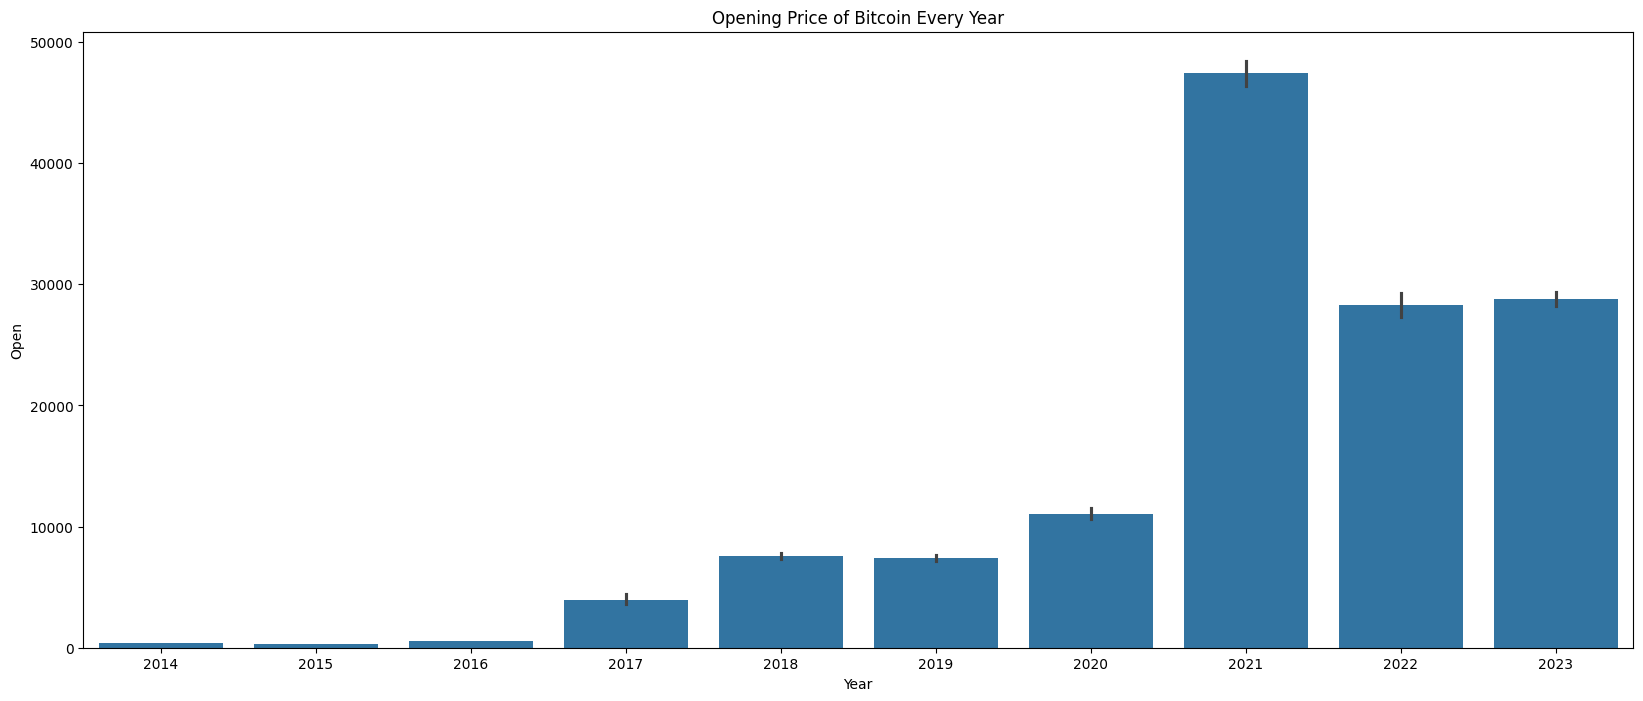

In [ ]:
plt.figure(figsize=(20,8))
sns.barplot(bitcoin_df, x='Year', y='Open')
plt.title('Opening Price of Bitcoin Every Year')

Text(0.5, 1.0, 'Closing Price of Bitcoin Every Year')

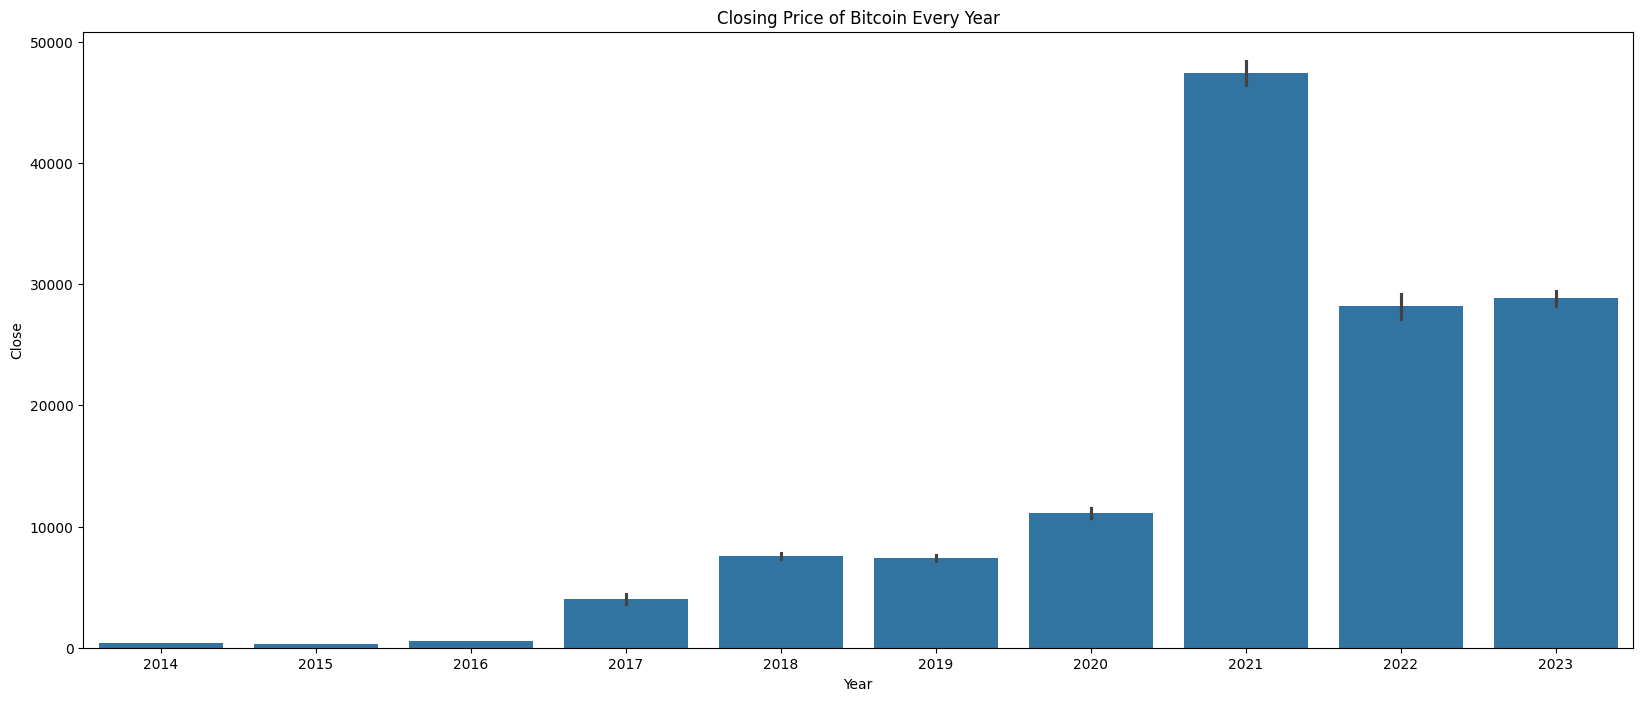

In [ ]:
plt.figure(figsize=(20,8))
sns.barplot(bitcoin_df, x='Year', y='Close')
plt.title('Closing Price of Bitcoin Every Year')

Text(0.5, 1.0, 'Opening Price every Month every Year')

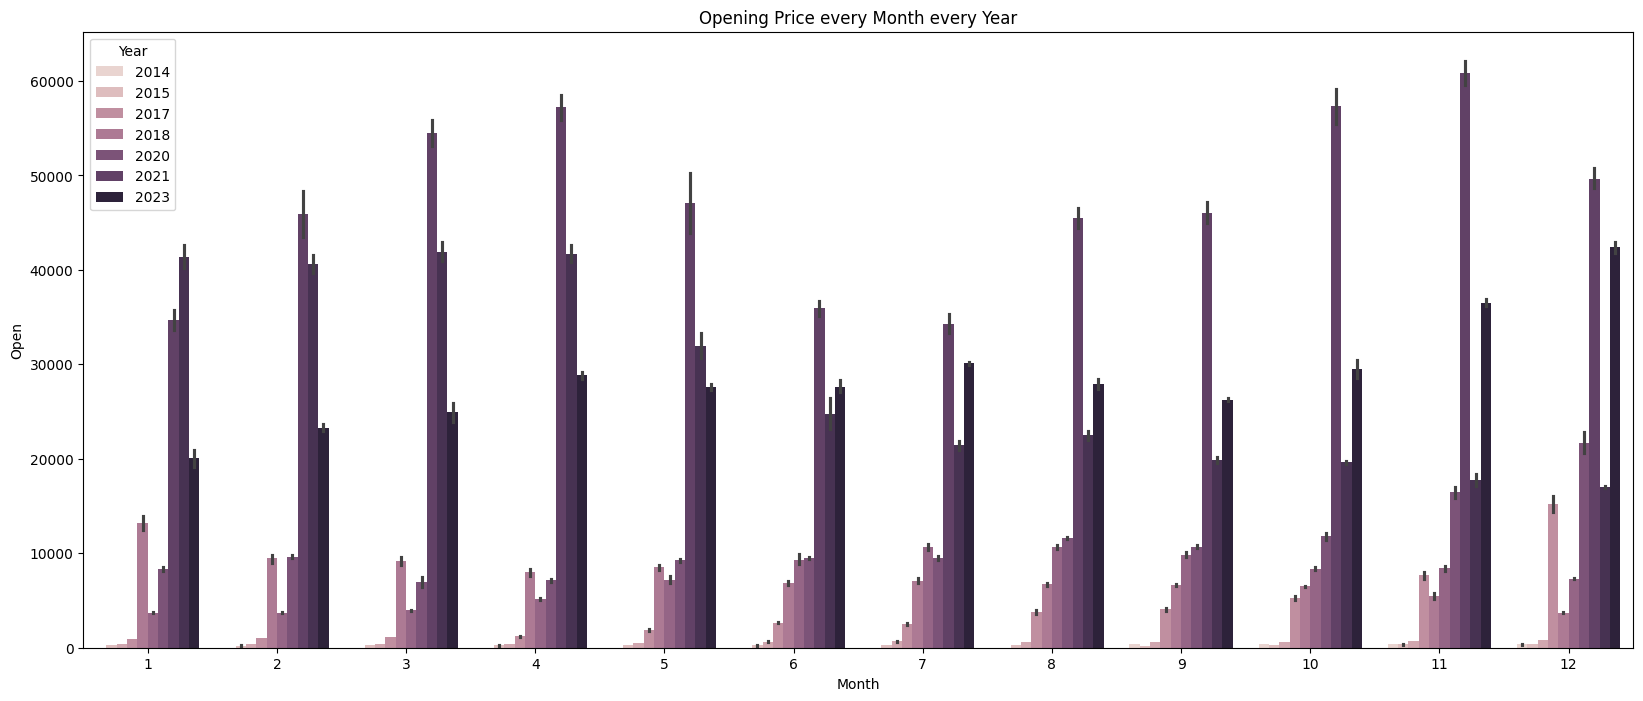

In [ ]:
# Monthly Opening Price of all the Years from 2014 - 2023

plt.figure(figsize=(20,8))
sns.barplot(bitcoin_df, x='Month', y='Open', hue='Year')
plt.title('Opening Price every Month every Year')

Now I will try to break it down into every year ka data month wise for all the prices

In [ ]:
bitcoin_df.head()
# columns = Open | High | Low | Close

,Open,High,Low,Close,Adj Close,Volume,Year,Month
Date,,,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800,2014,9
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200,2014,9
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700,2014,9
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600,2014,9
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100,2014,9


C:\Users\Siddhant\AppData\Local\Temp\ipykernel_26036\4079088223.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(20,8))


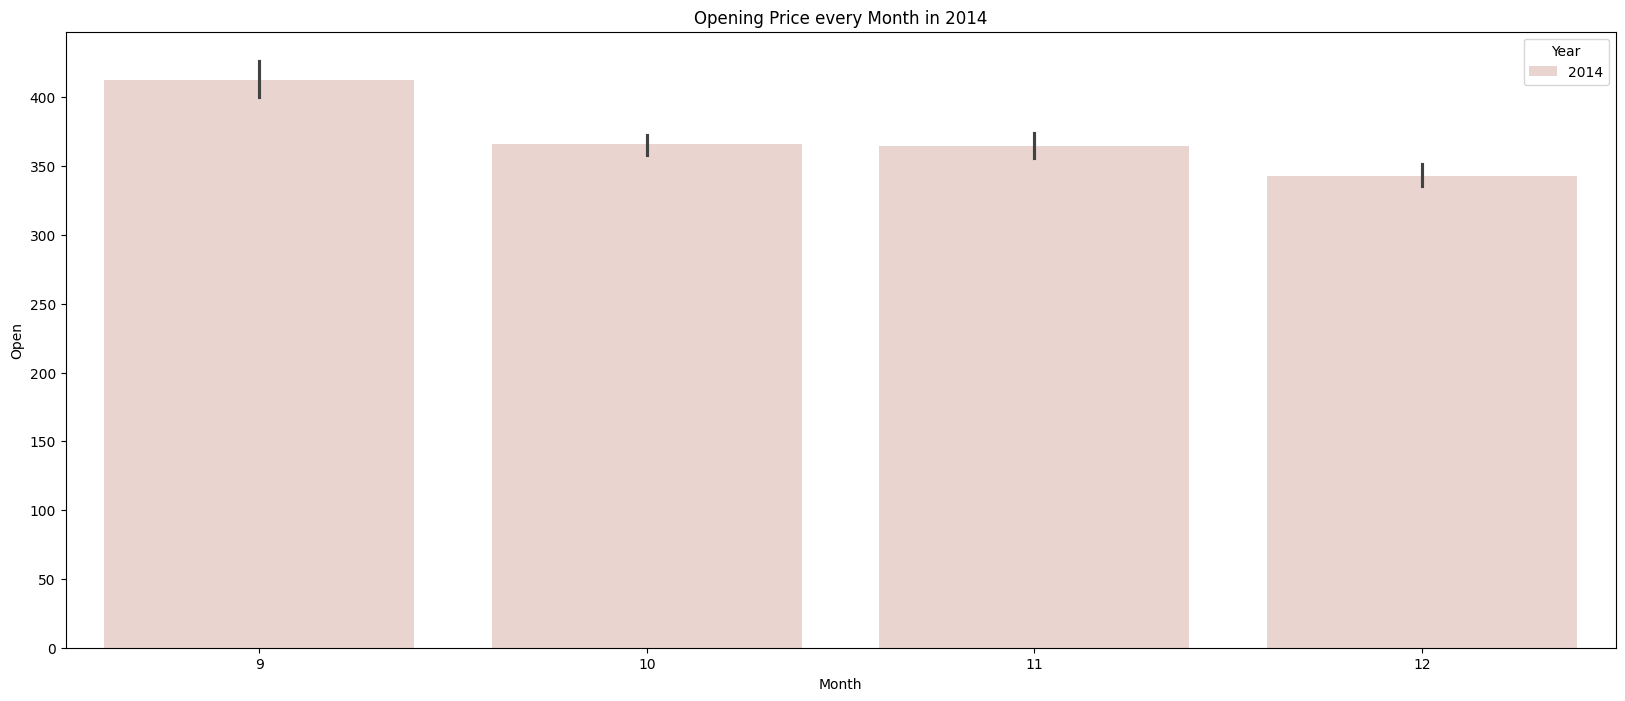

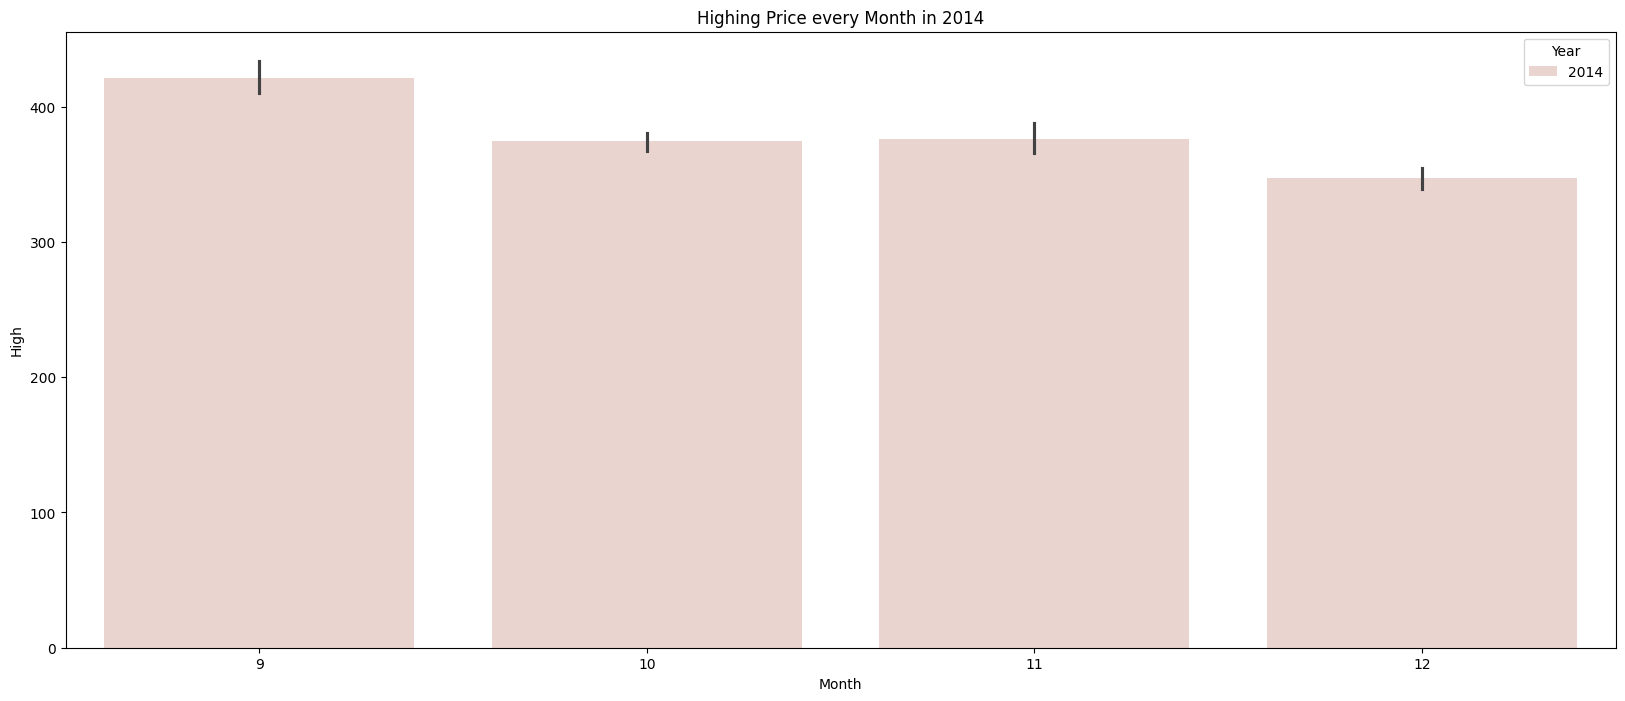

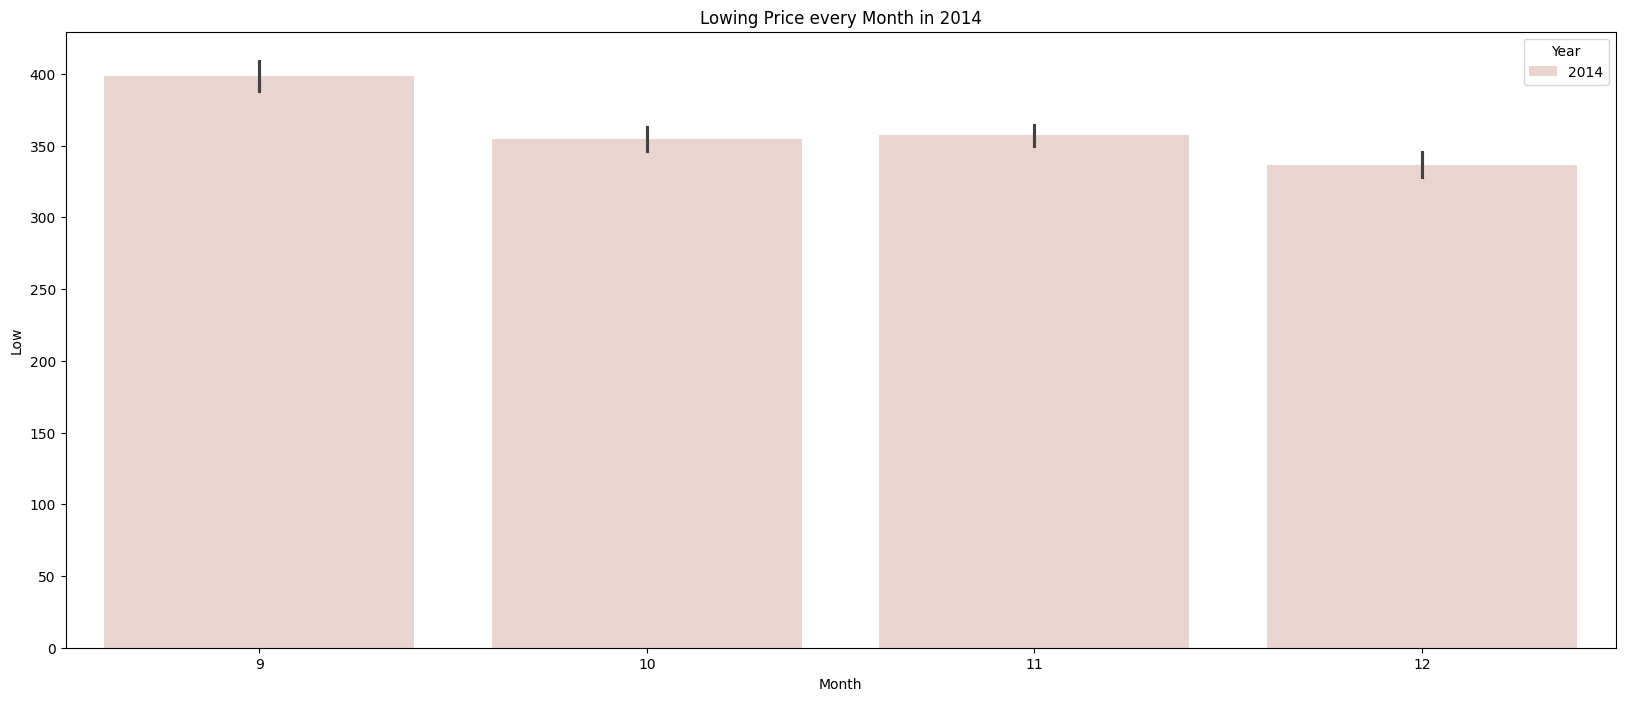

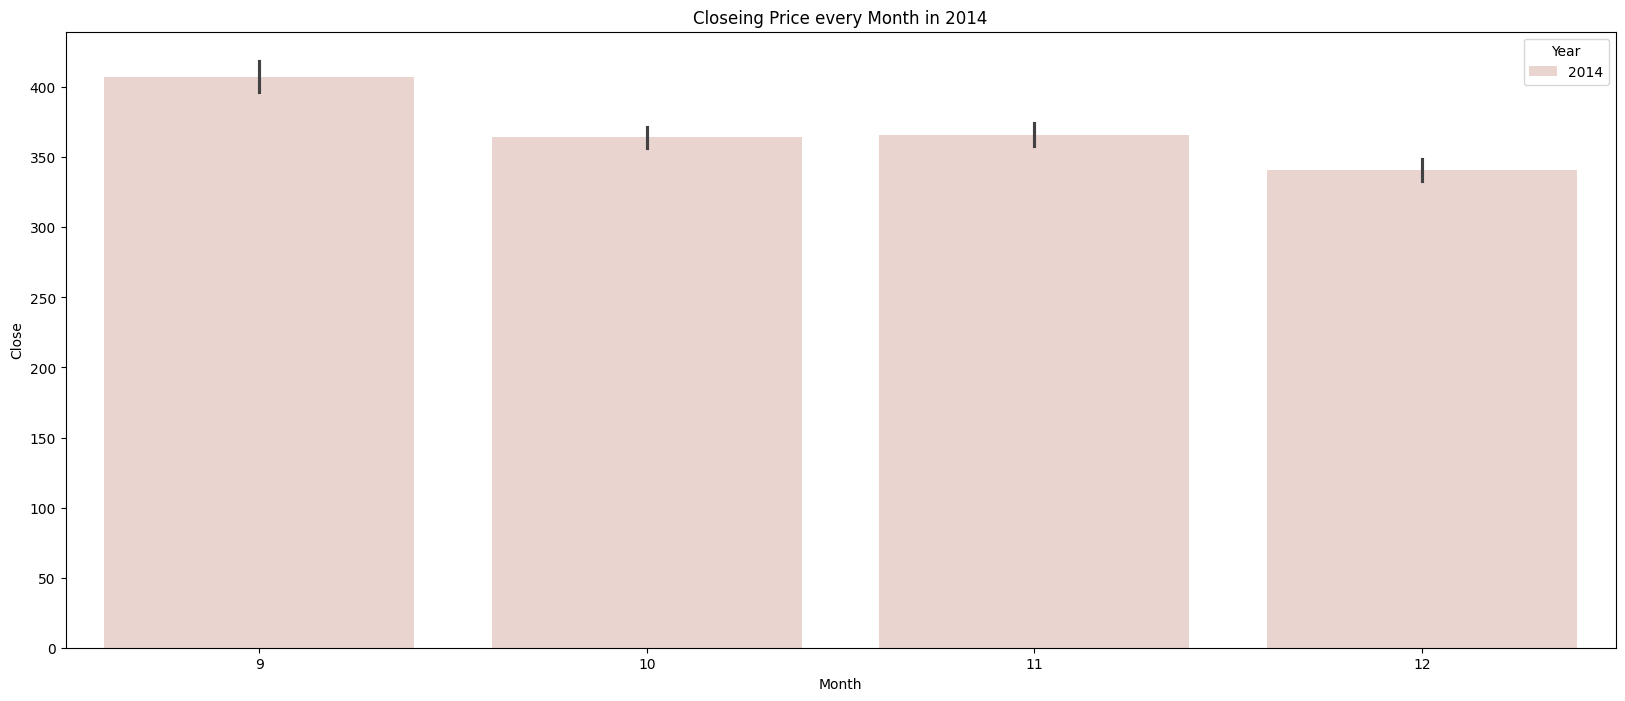

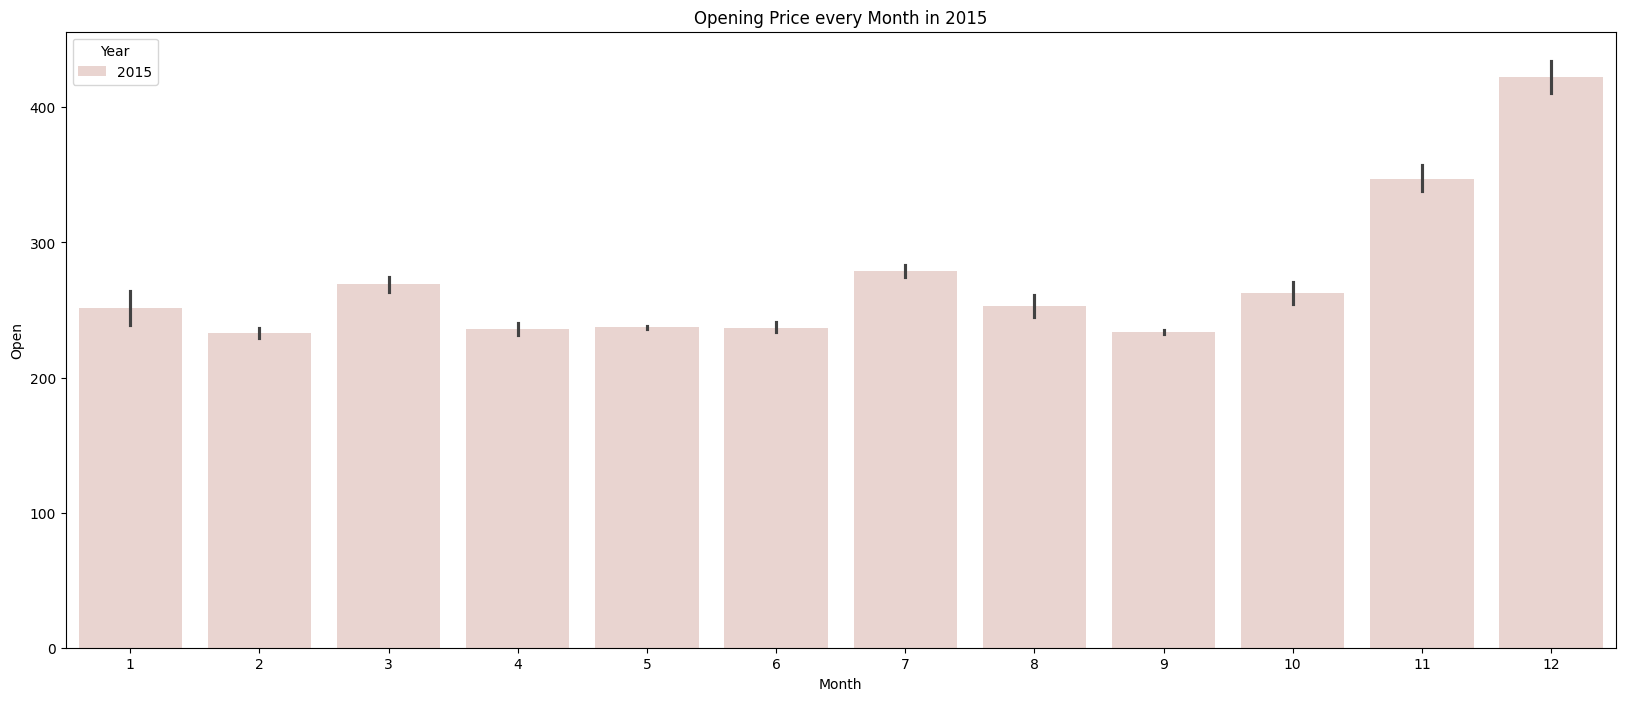

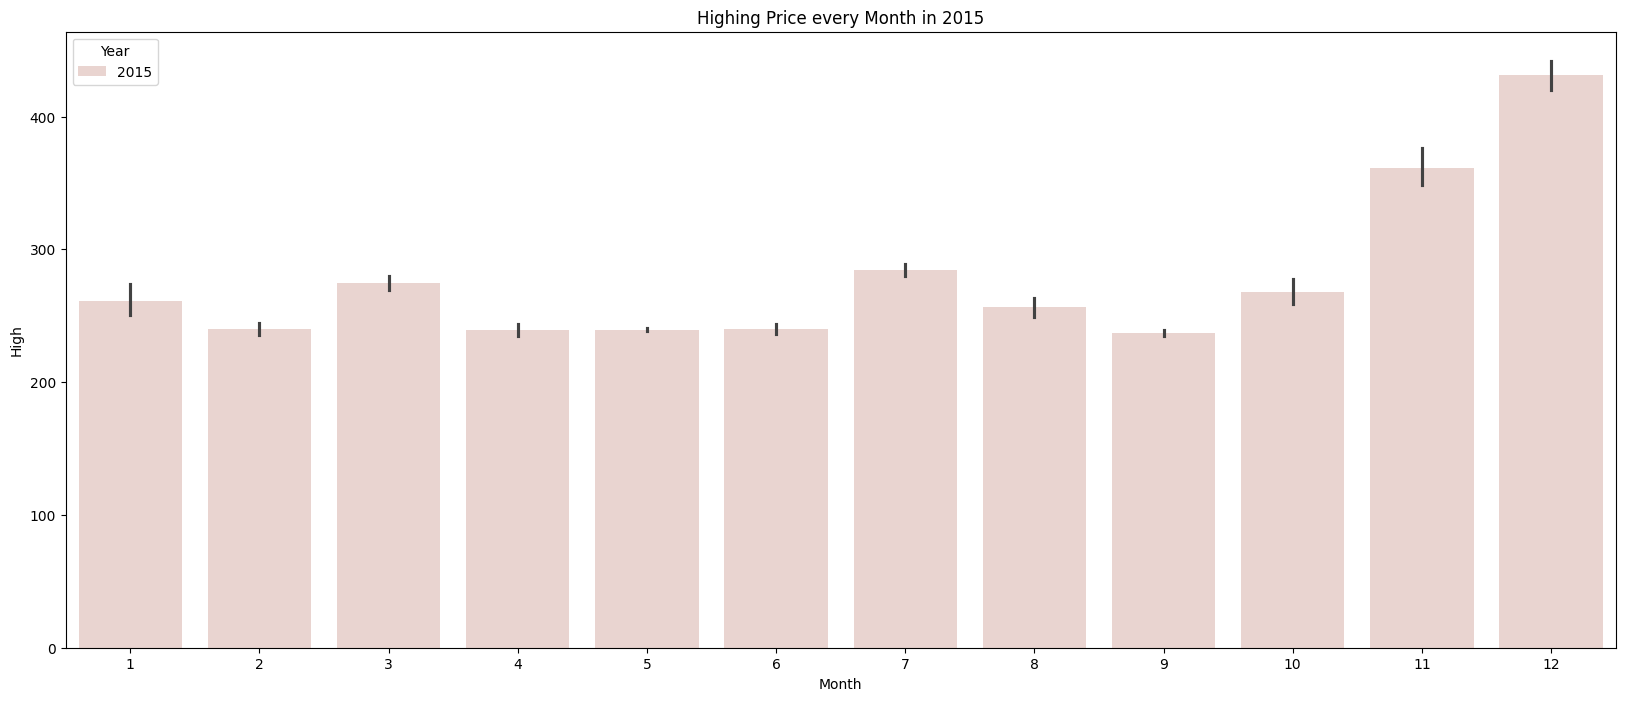

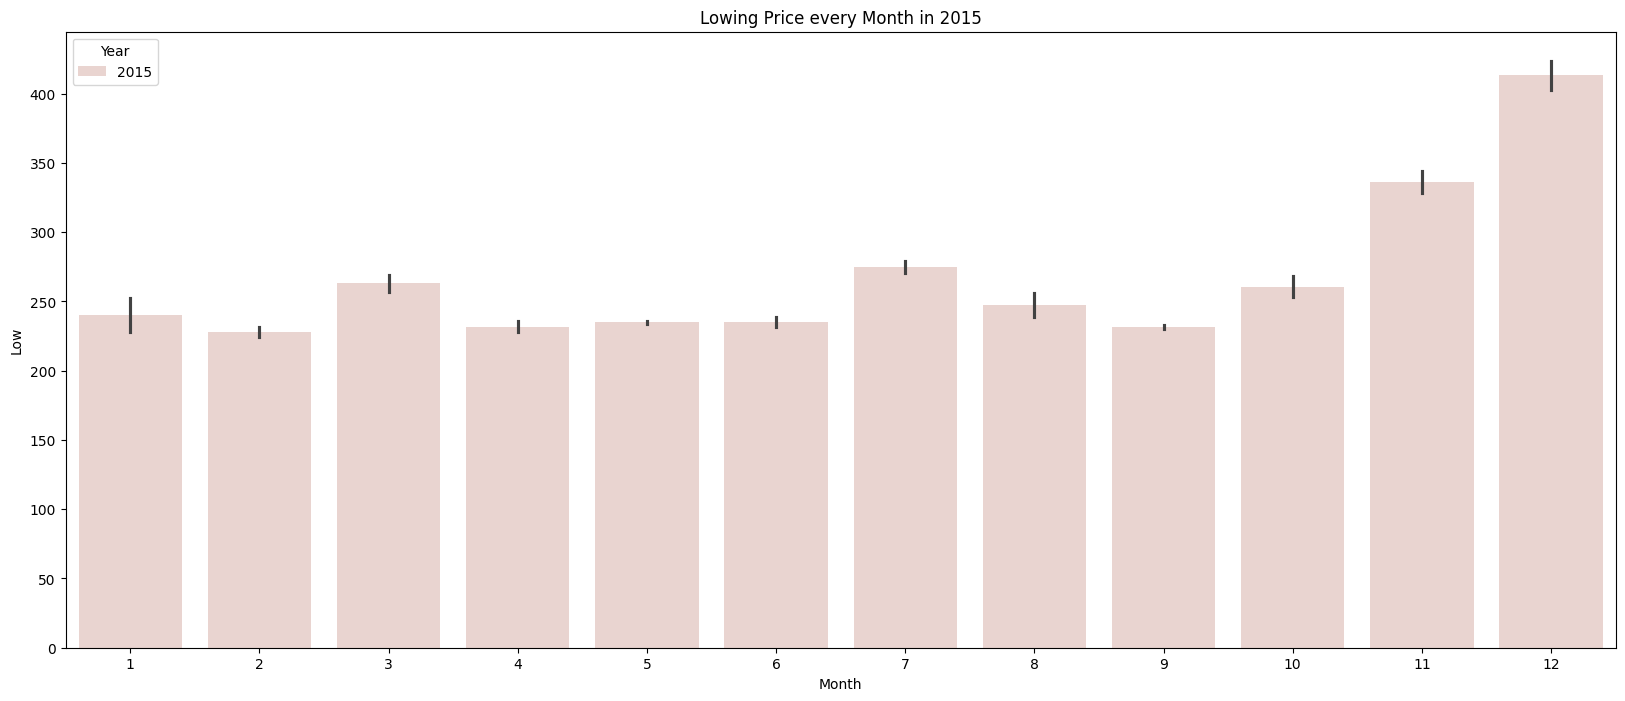

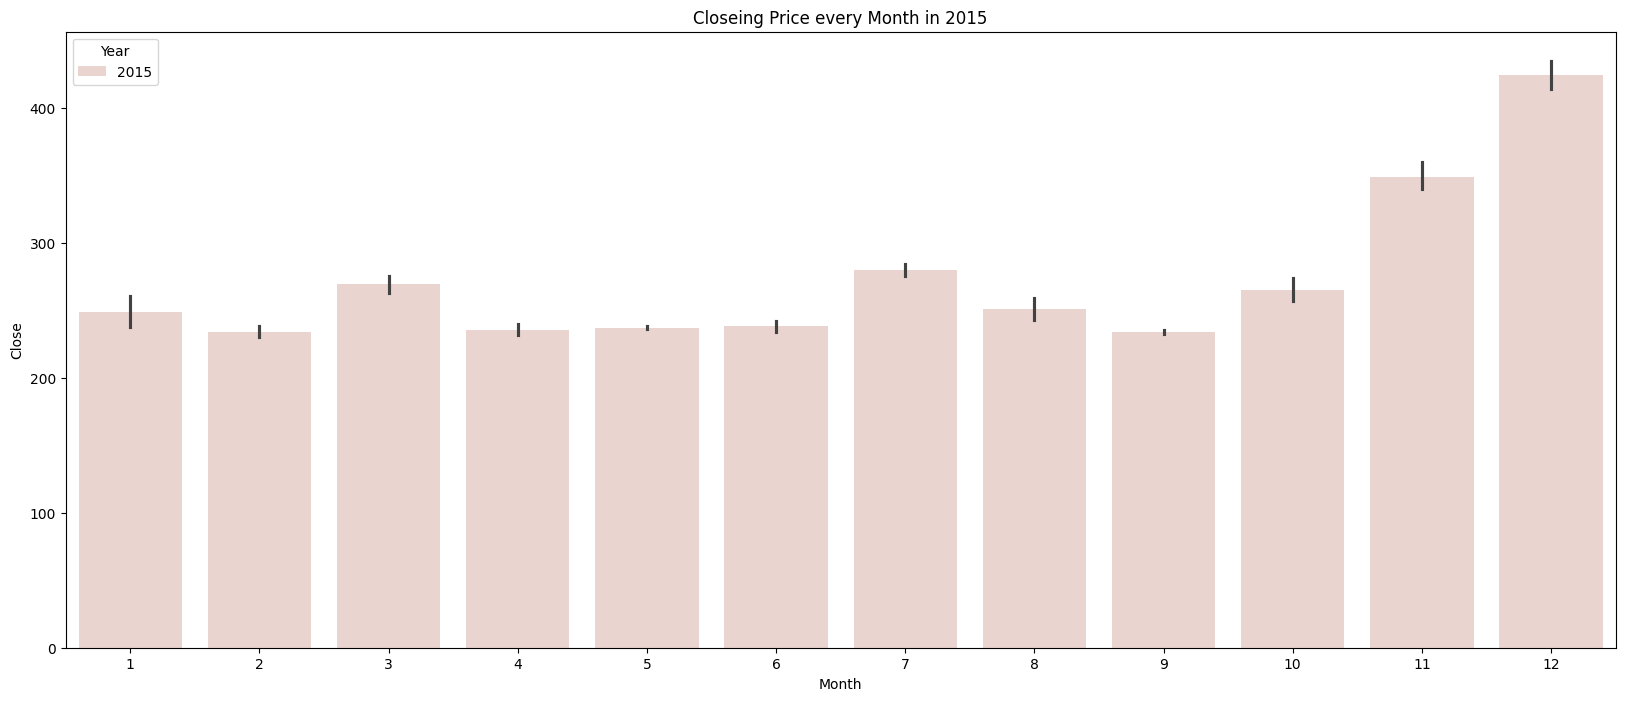

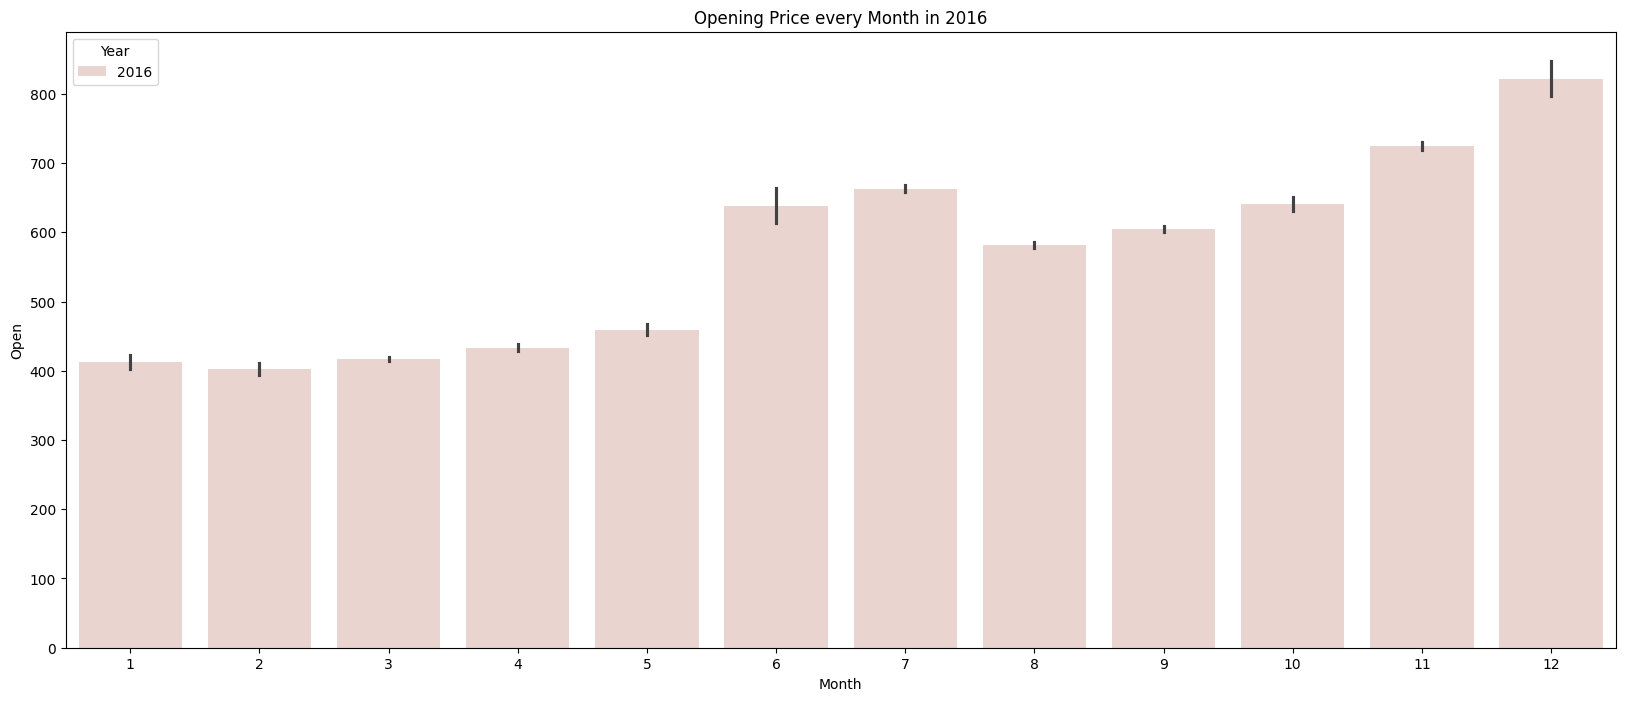

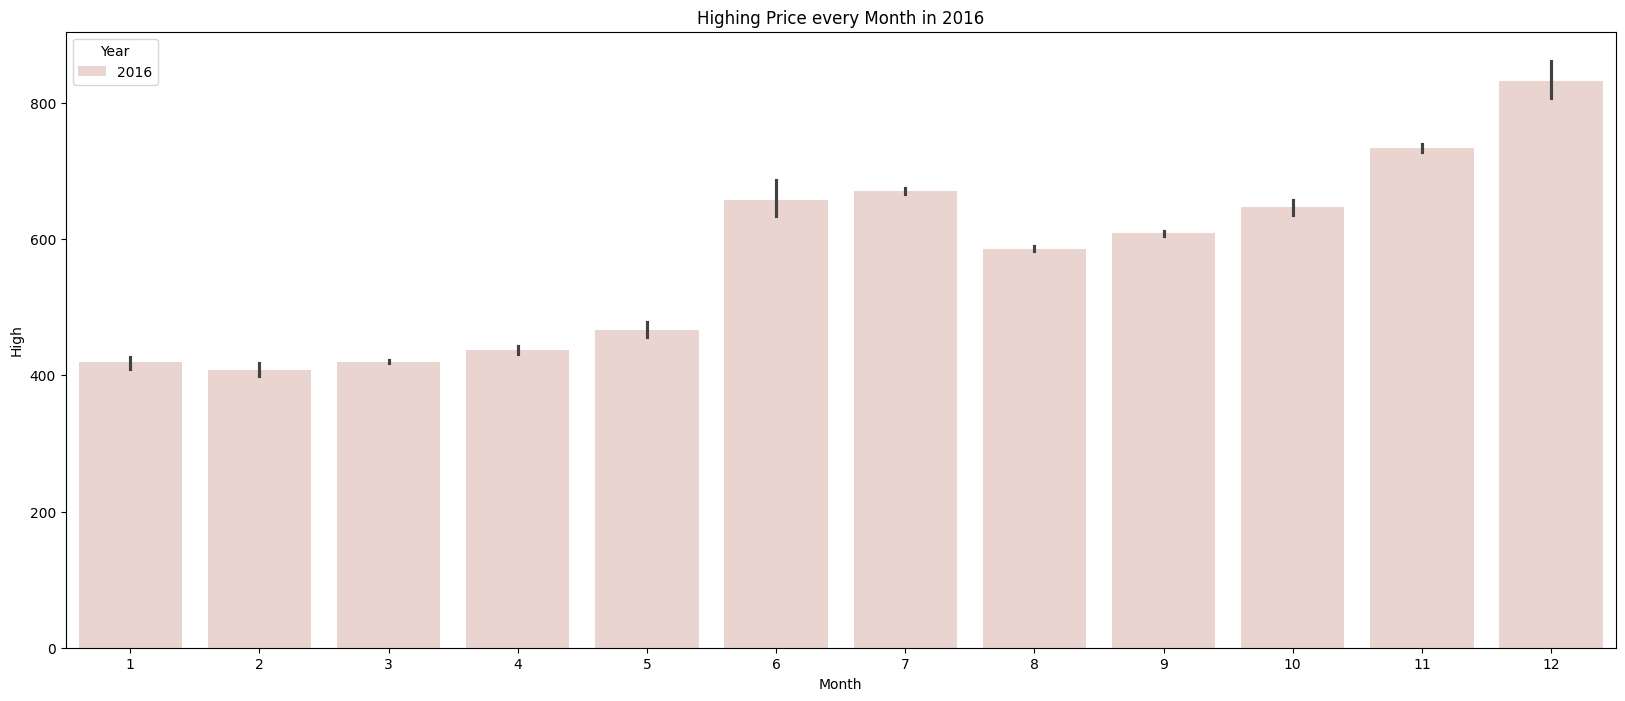

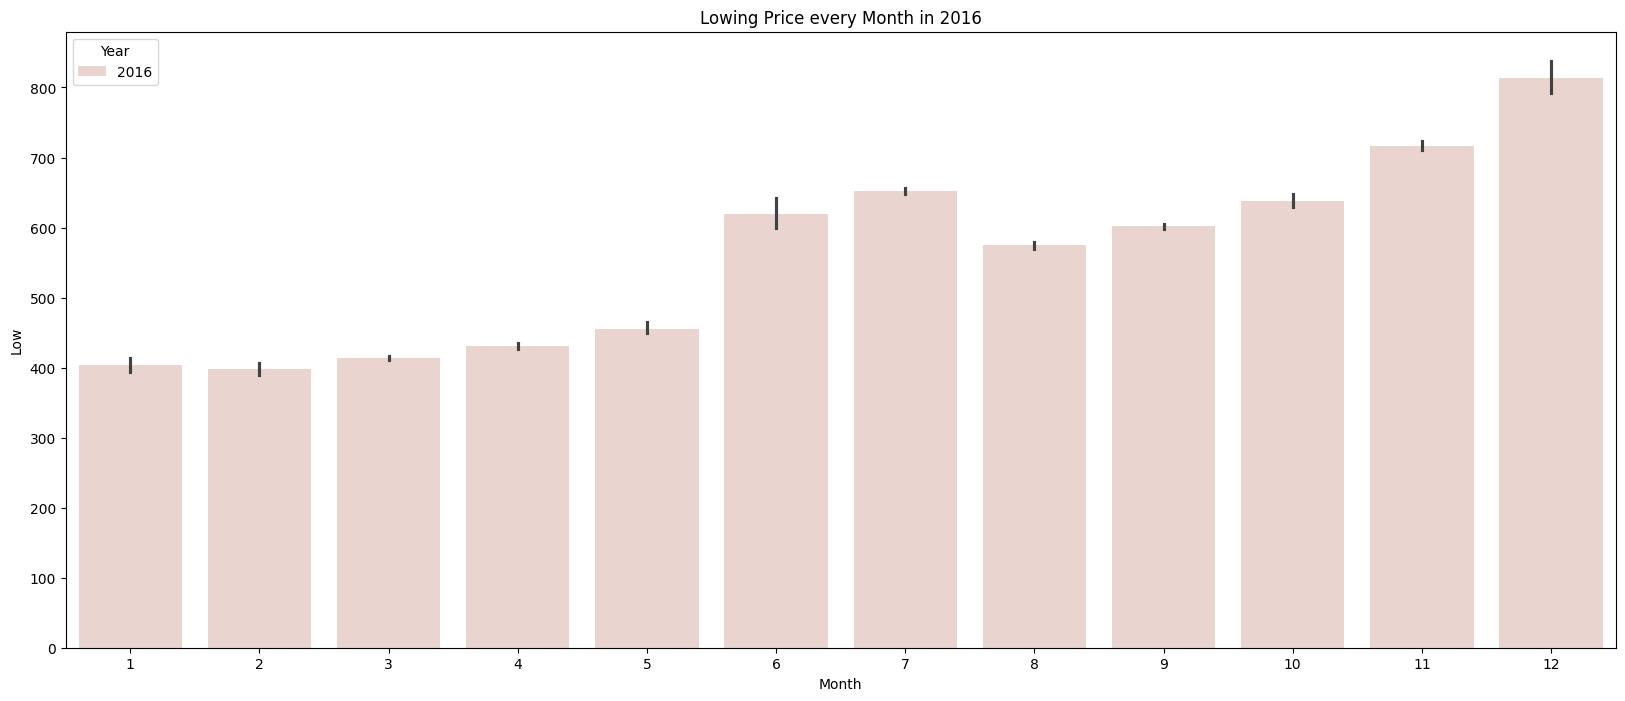

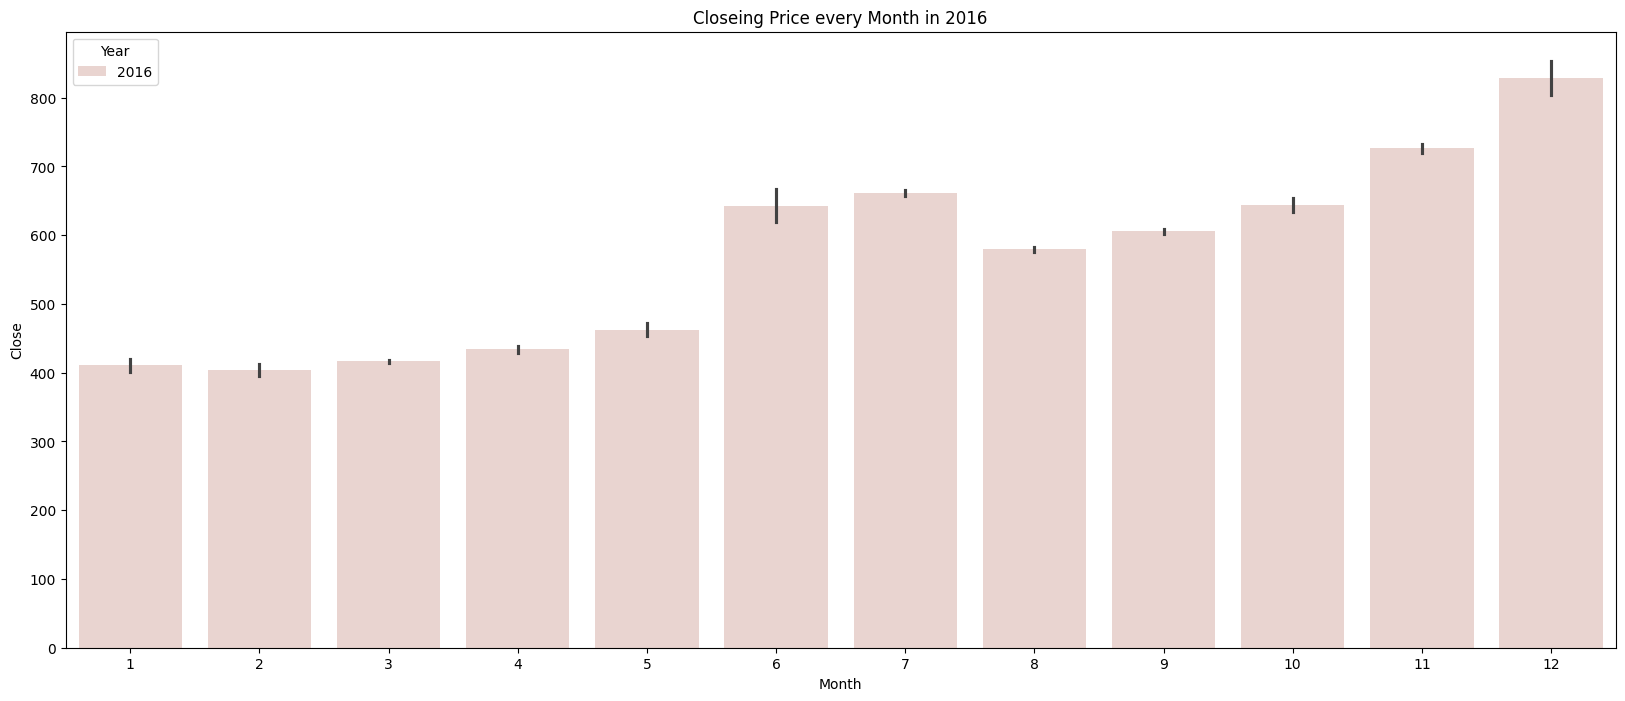

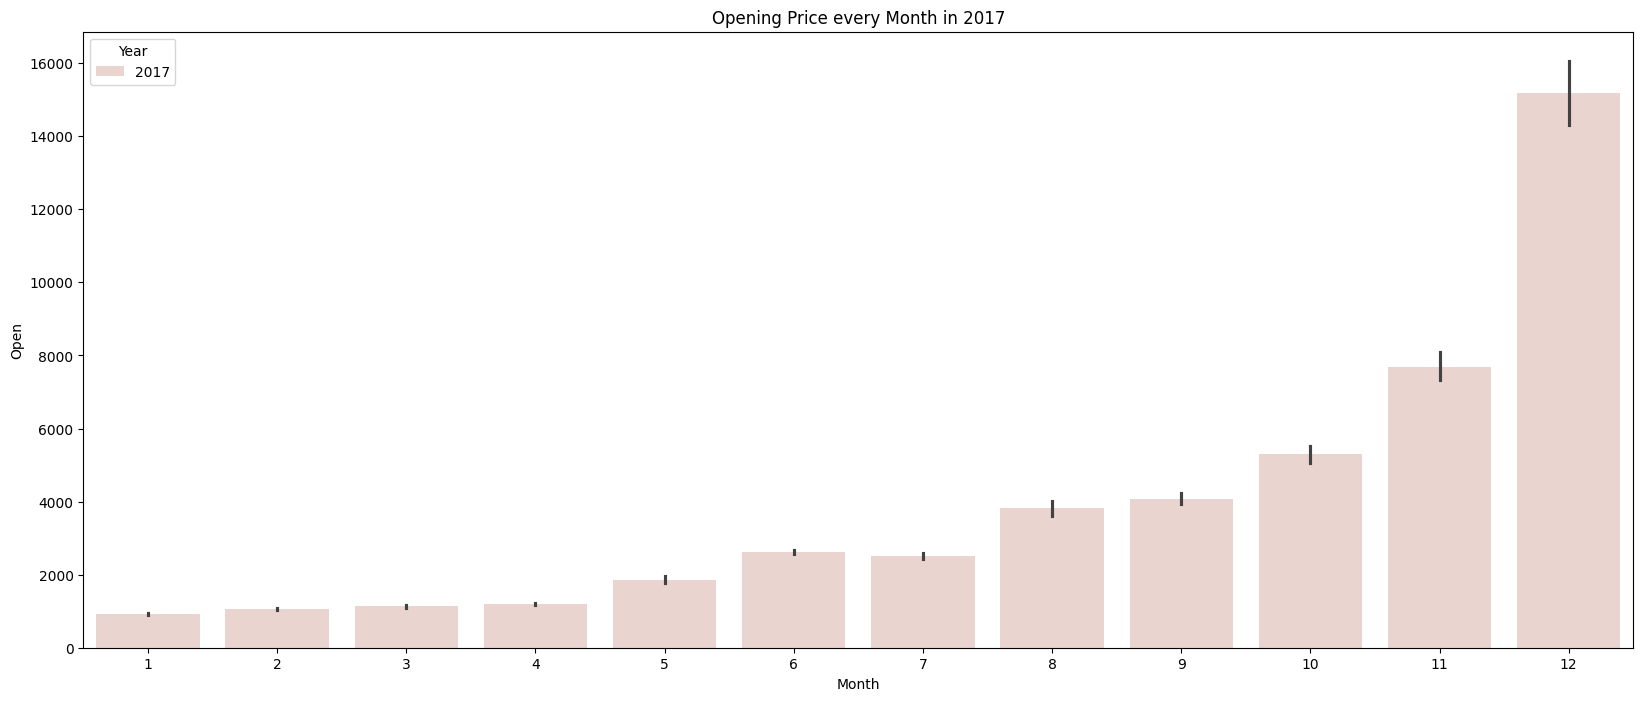

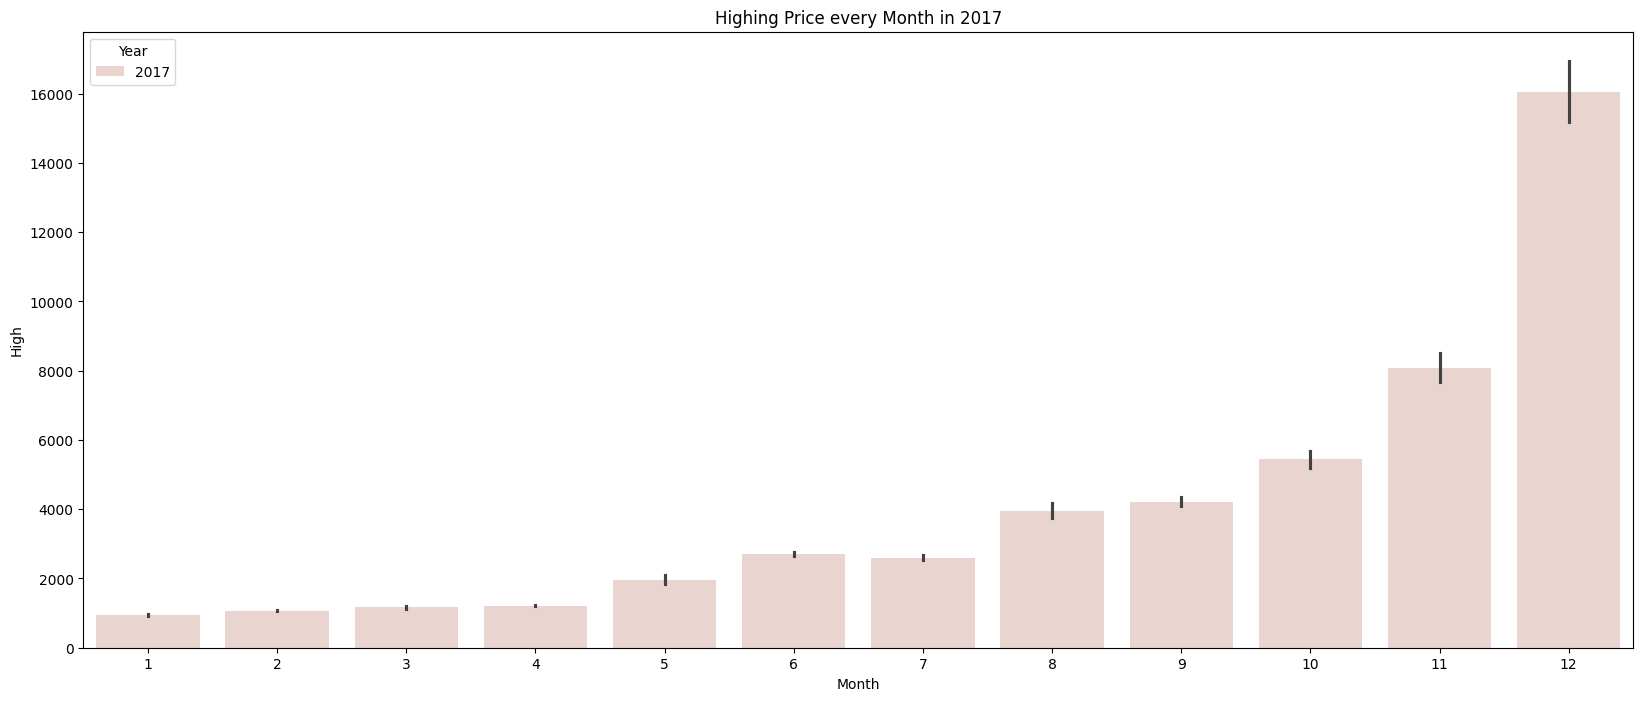

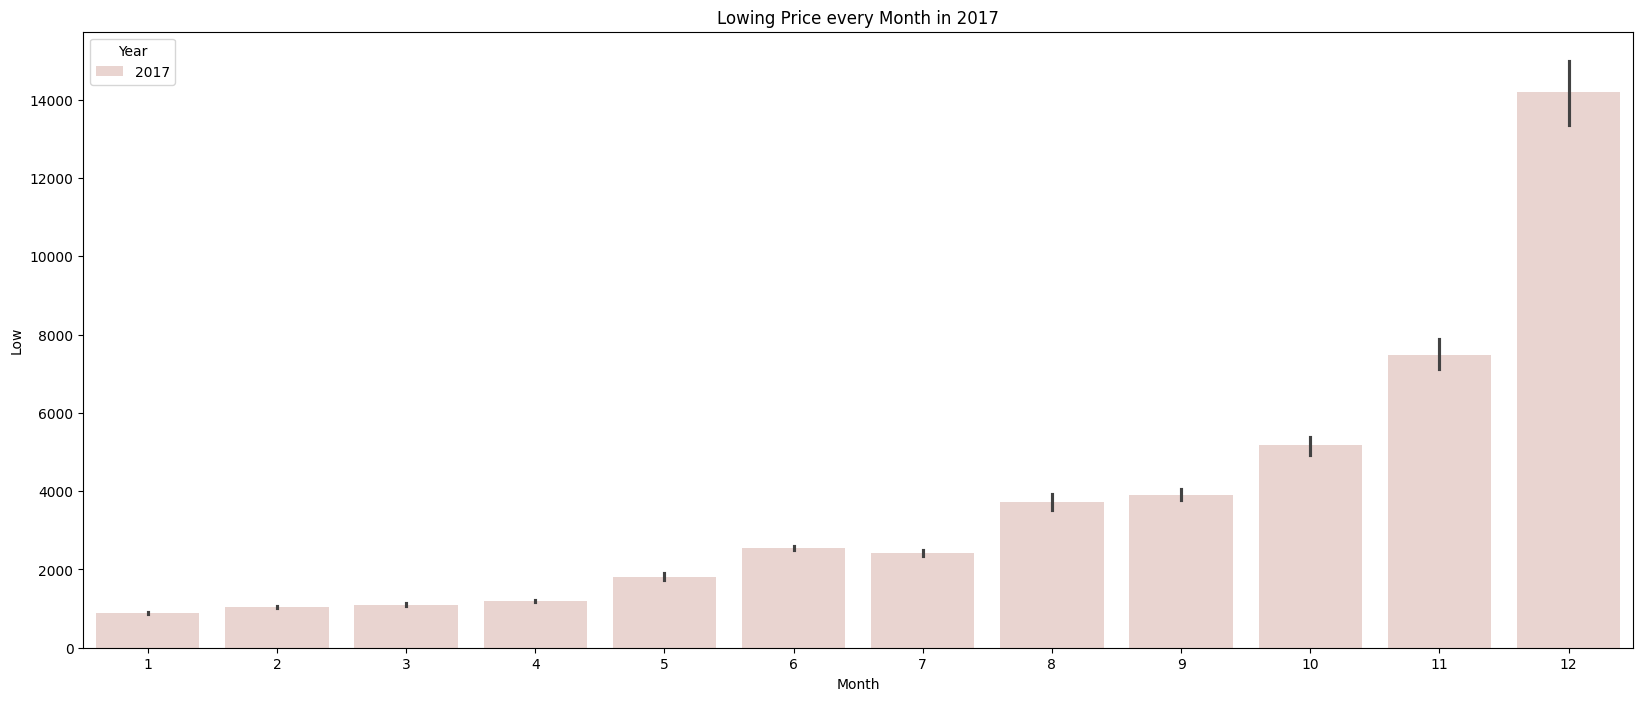

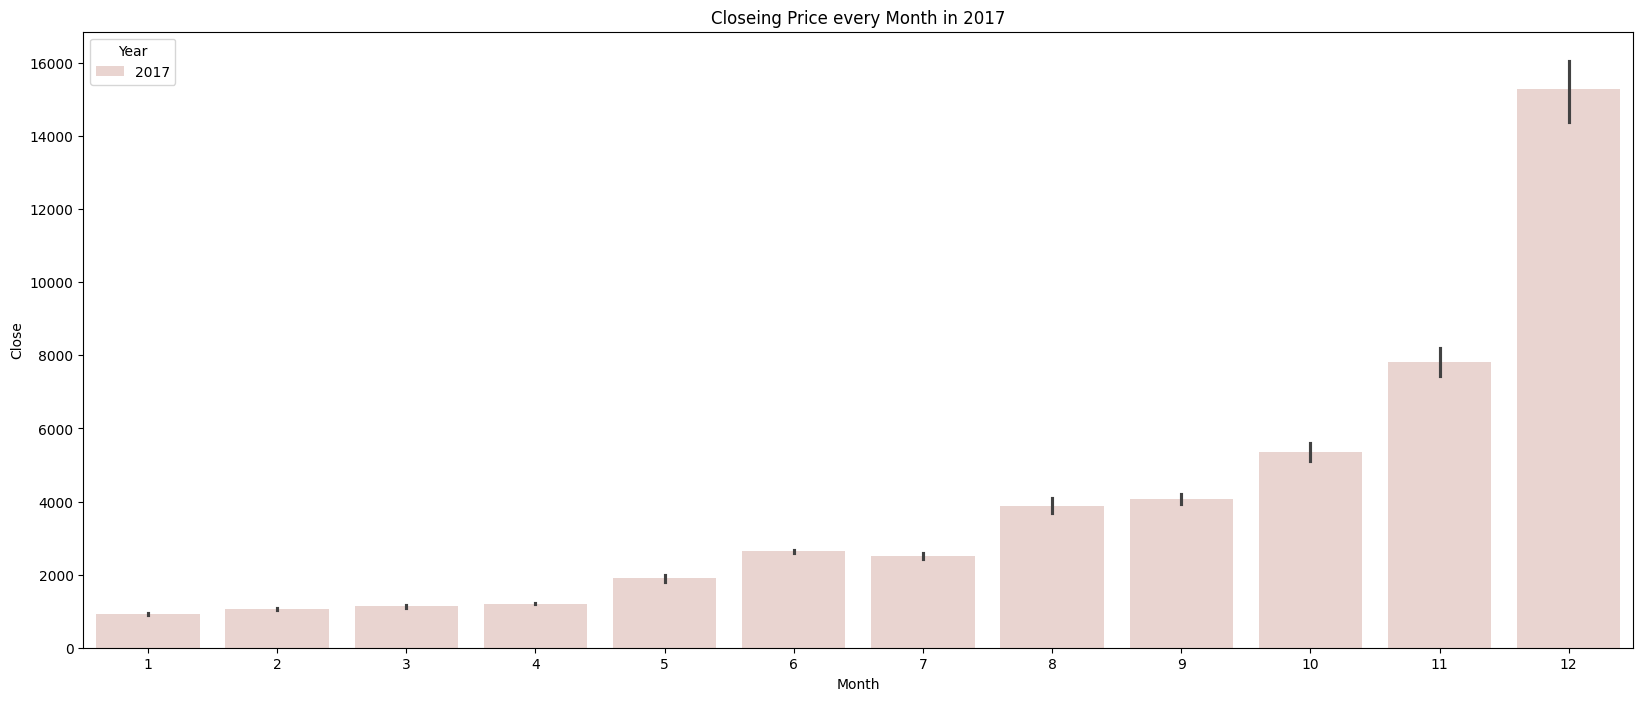

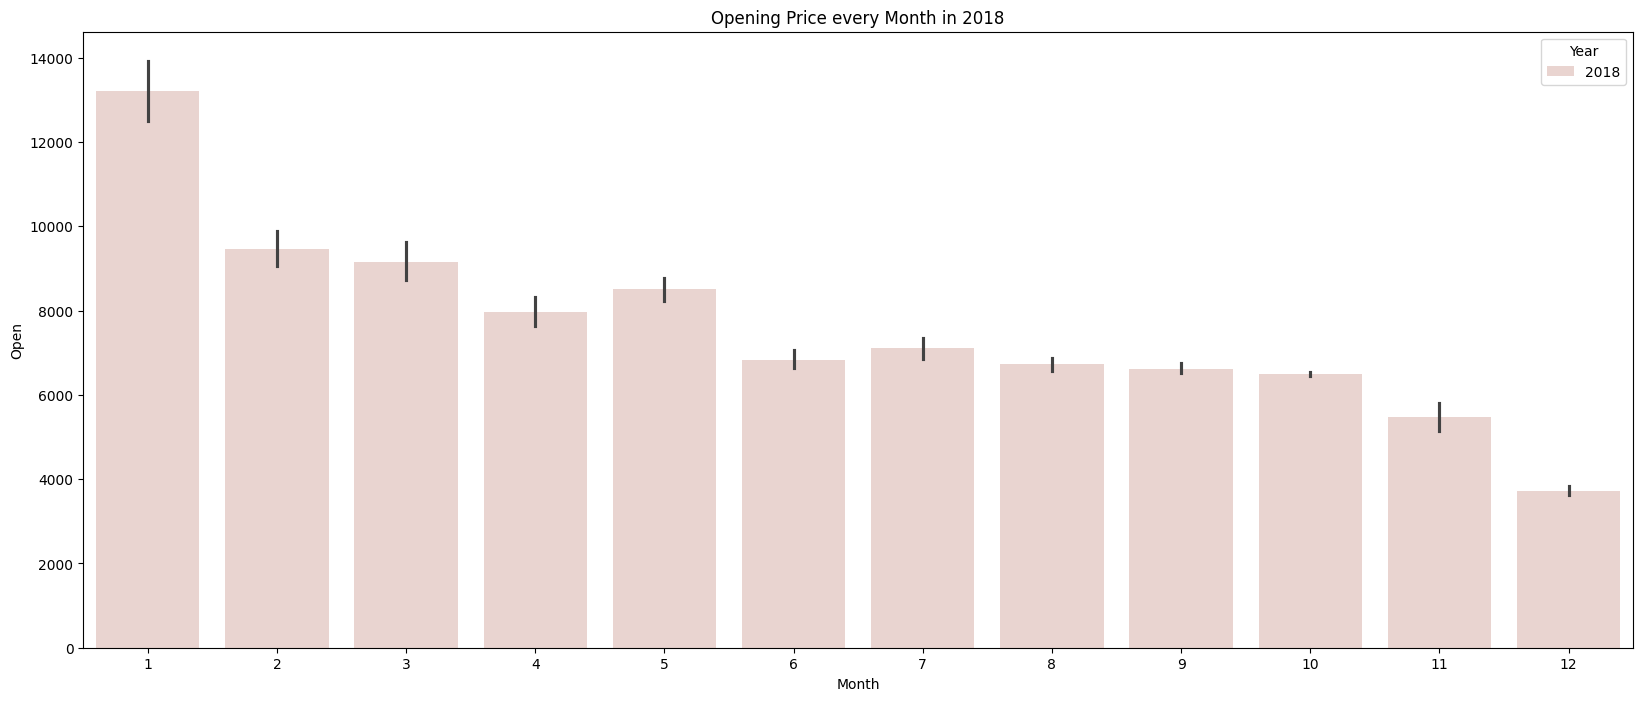

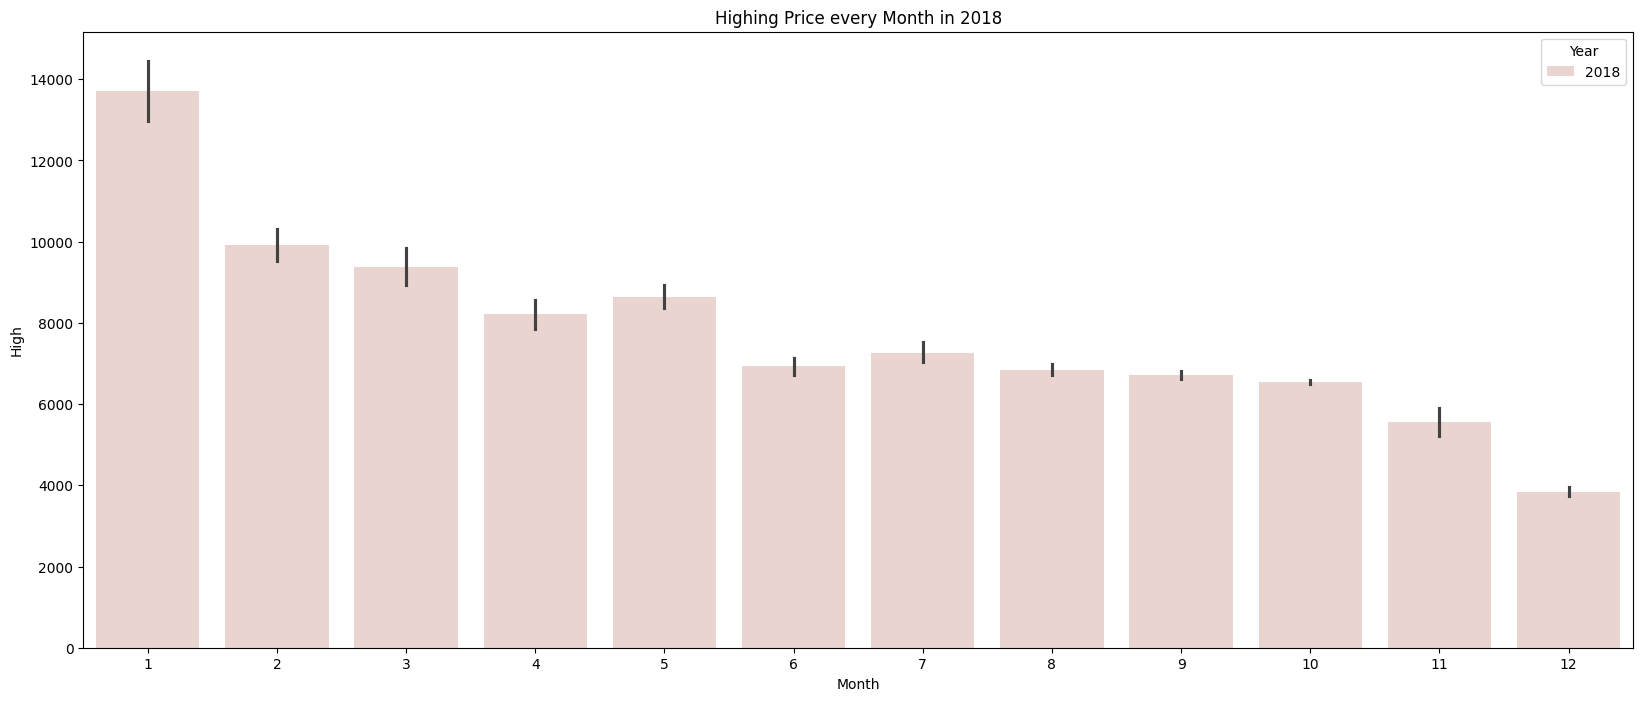

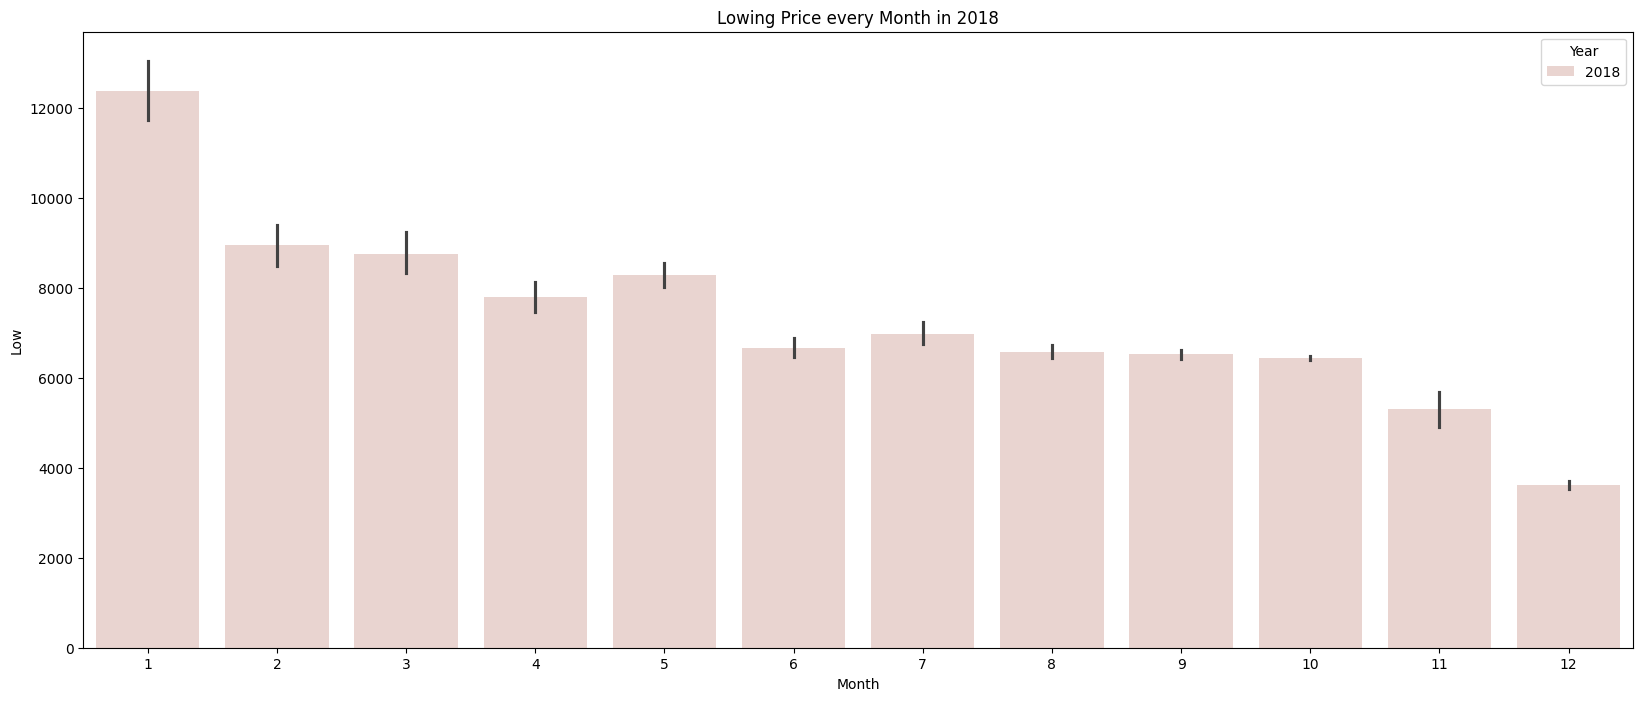

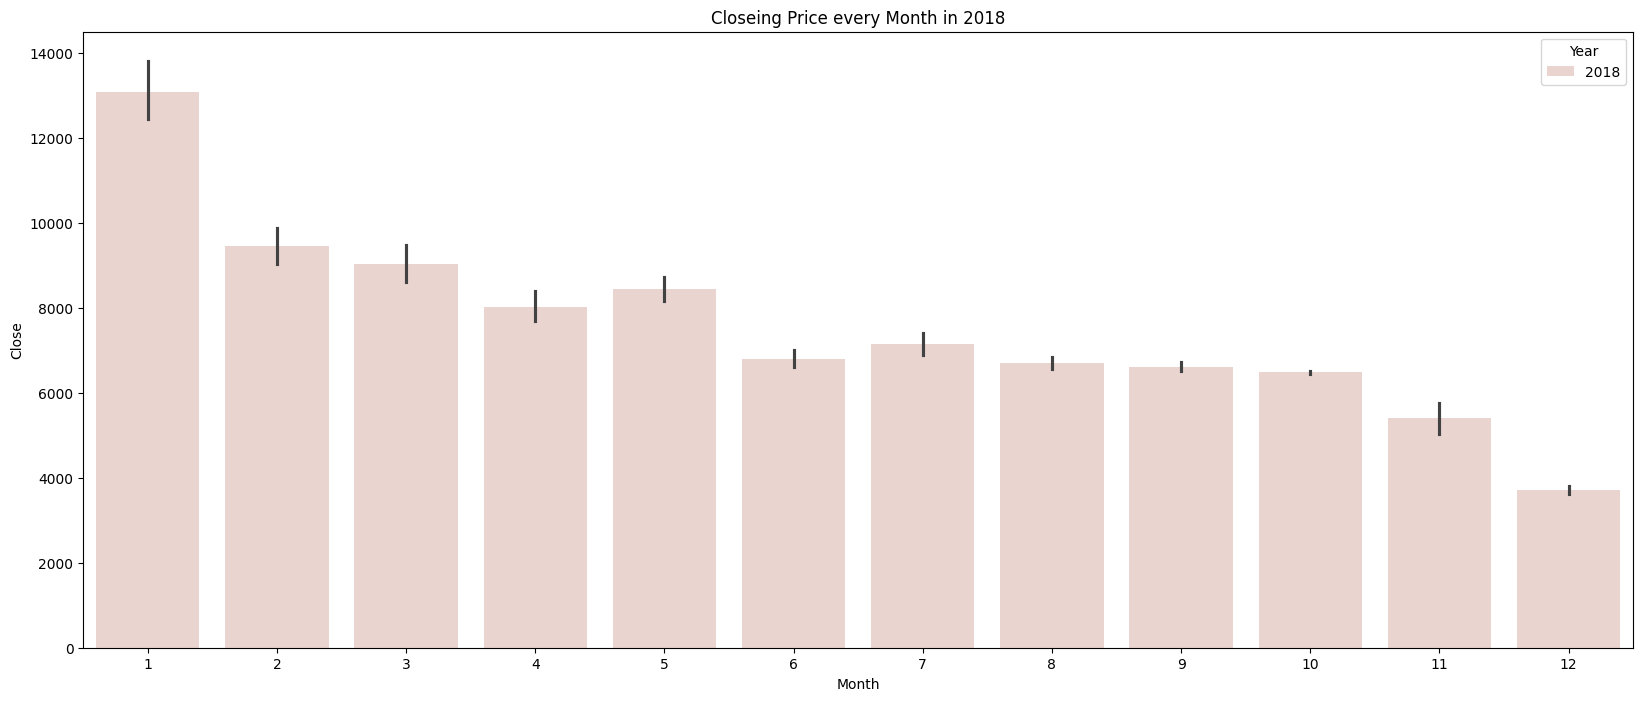

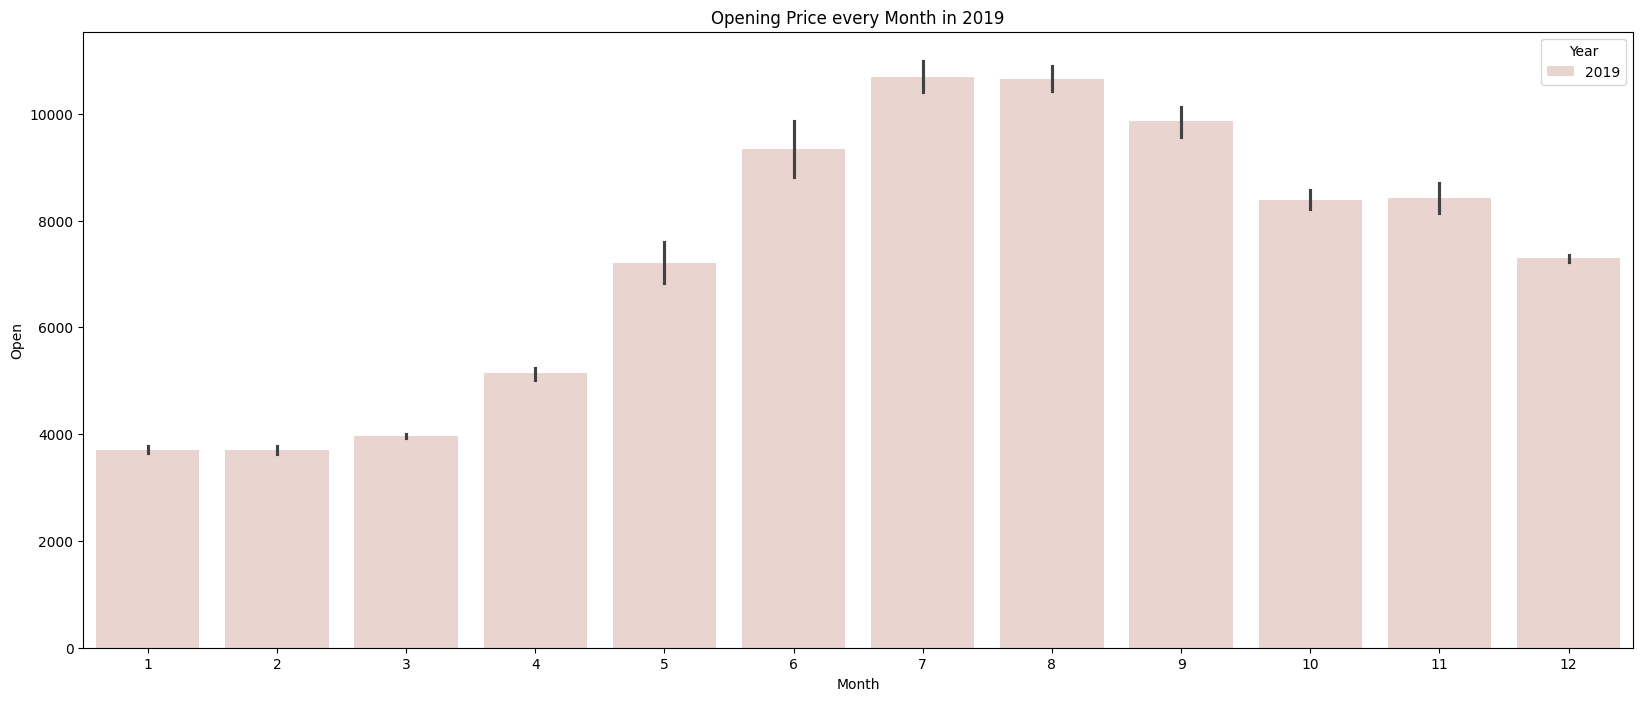

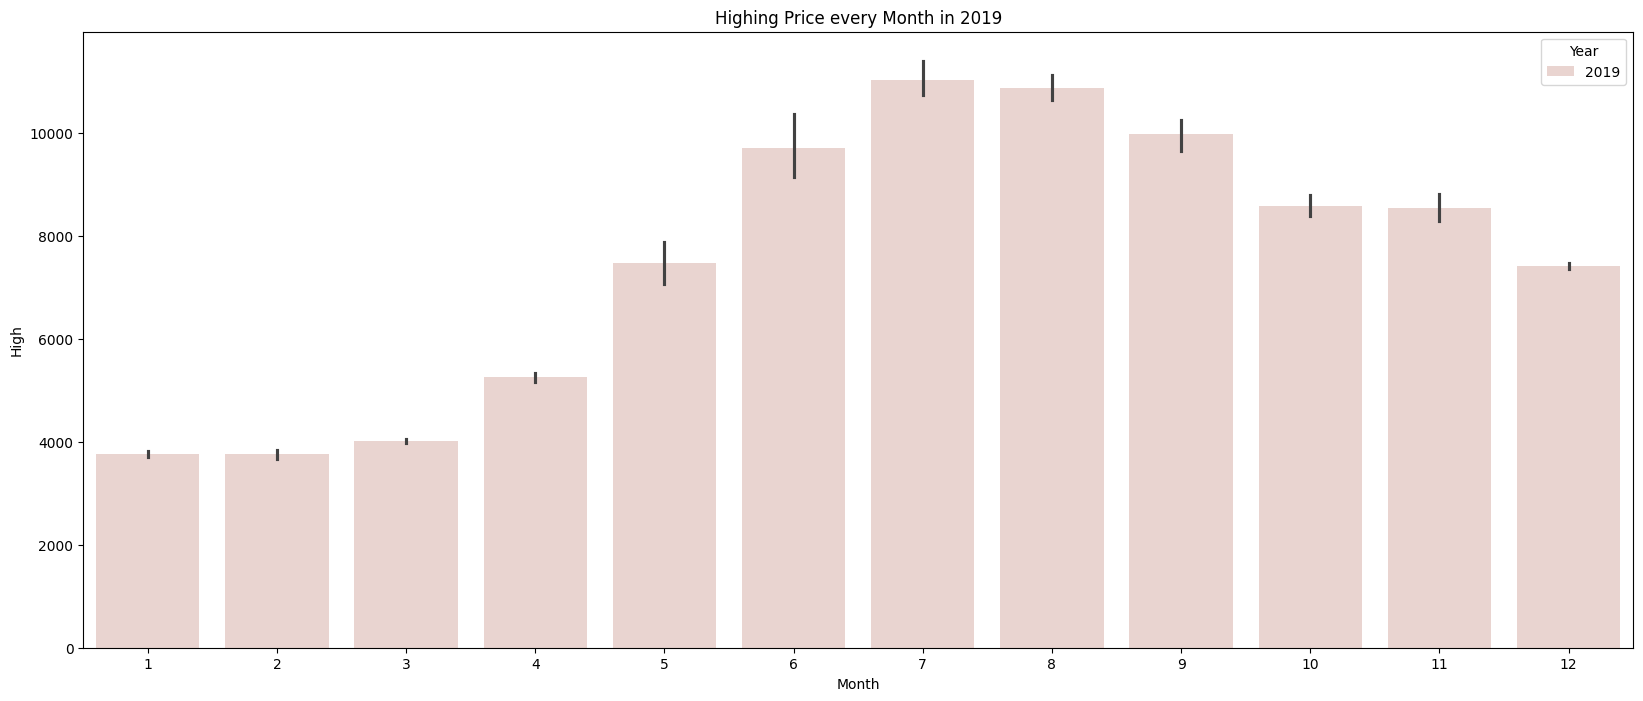

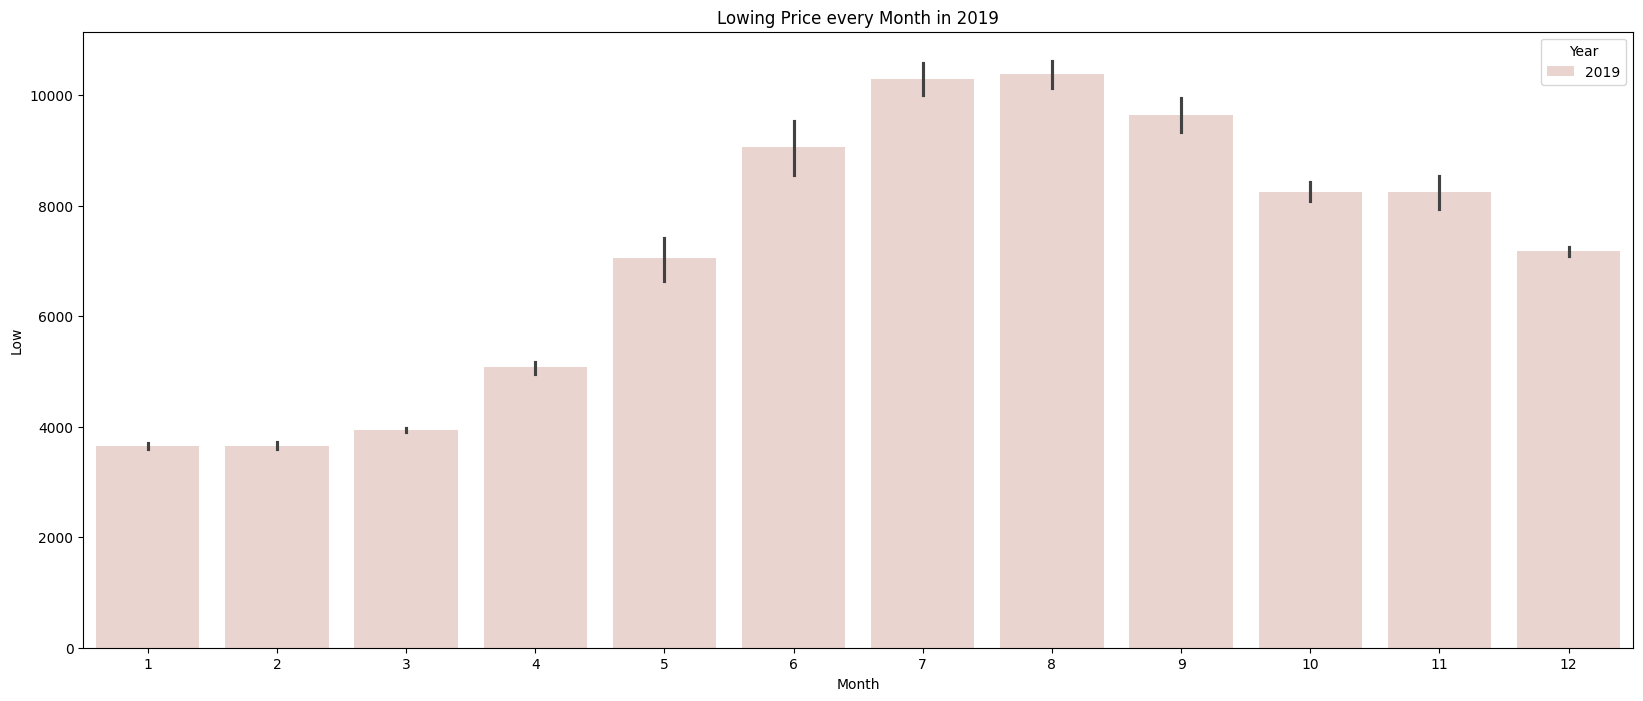

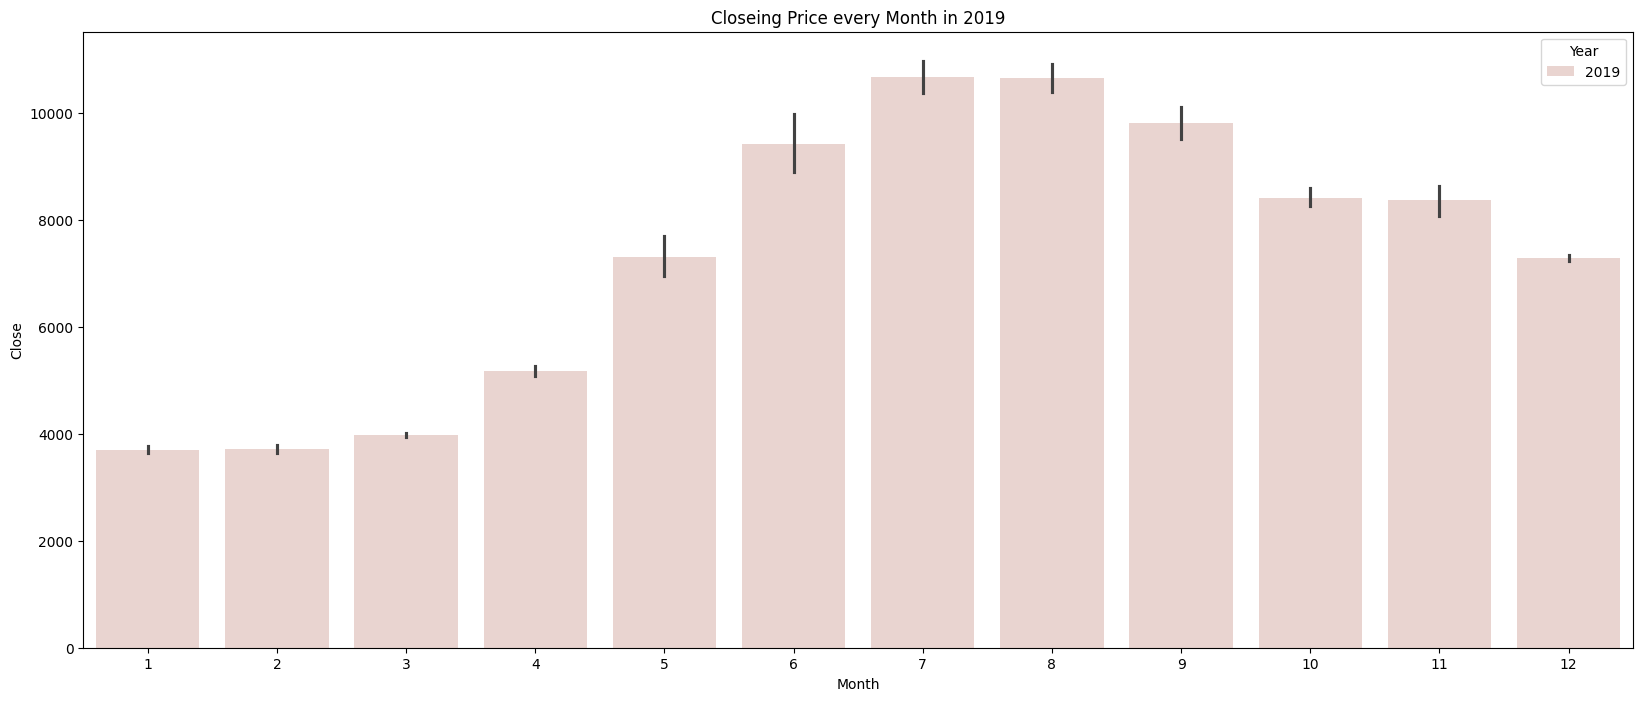

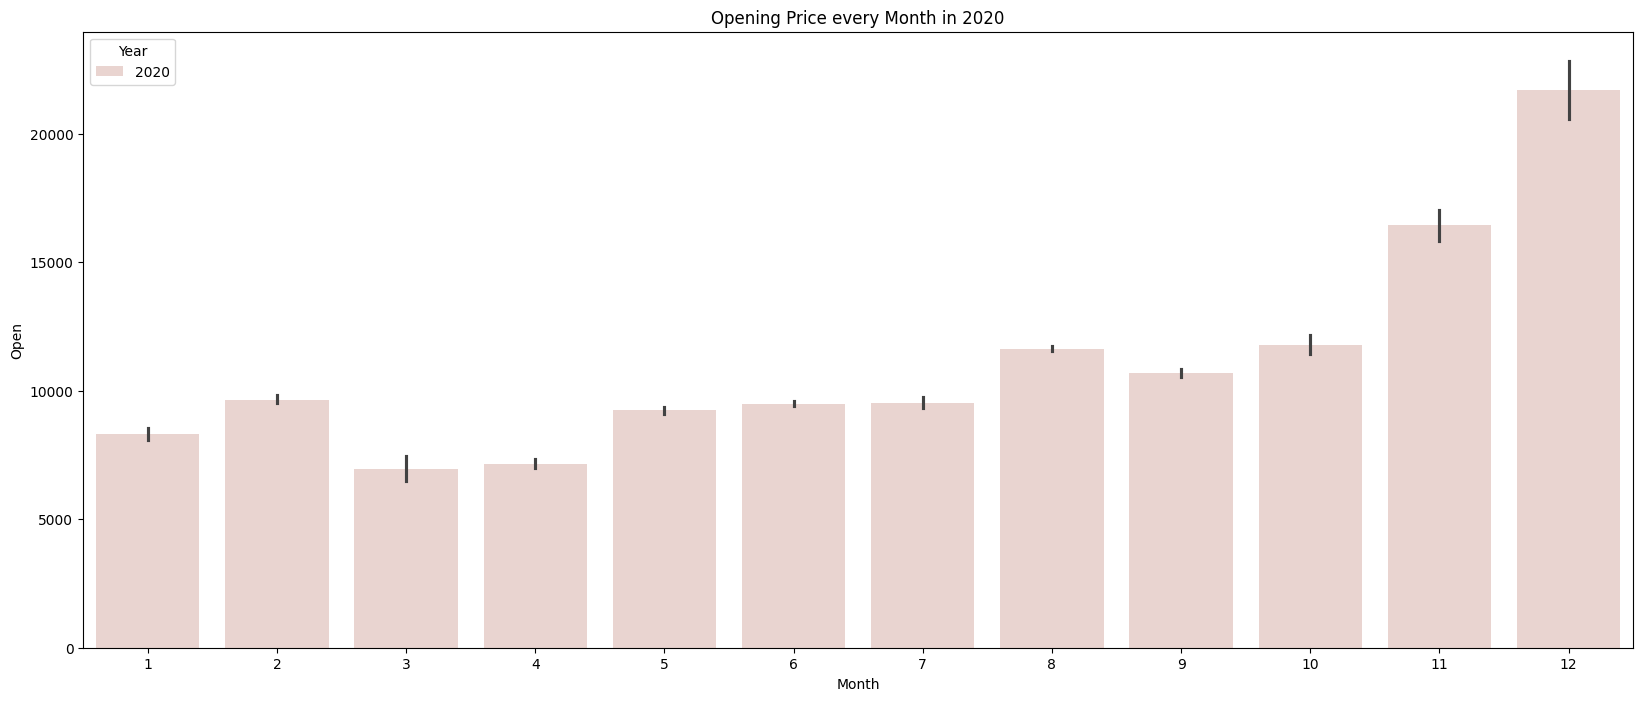

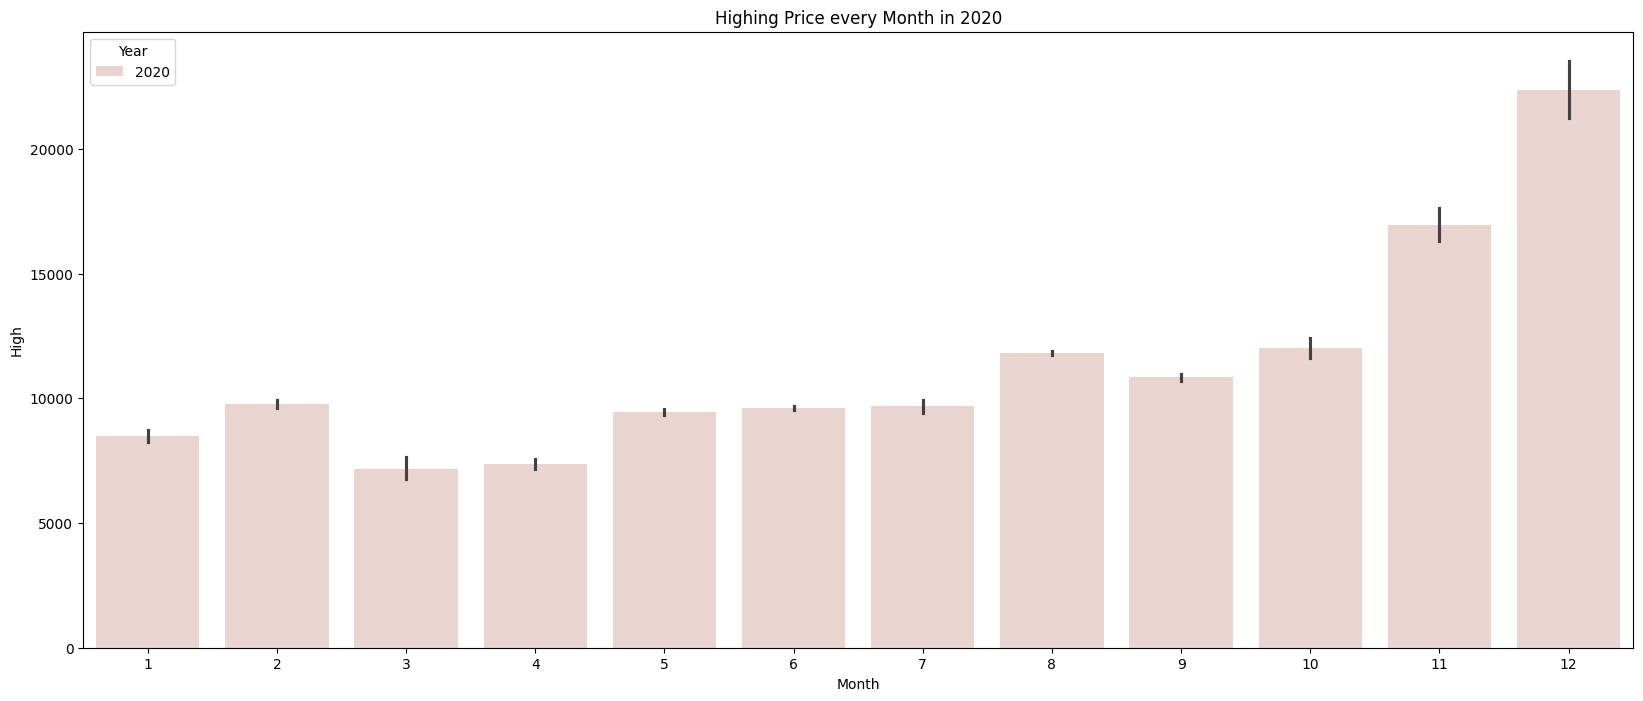

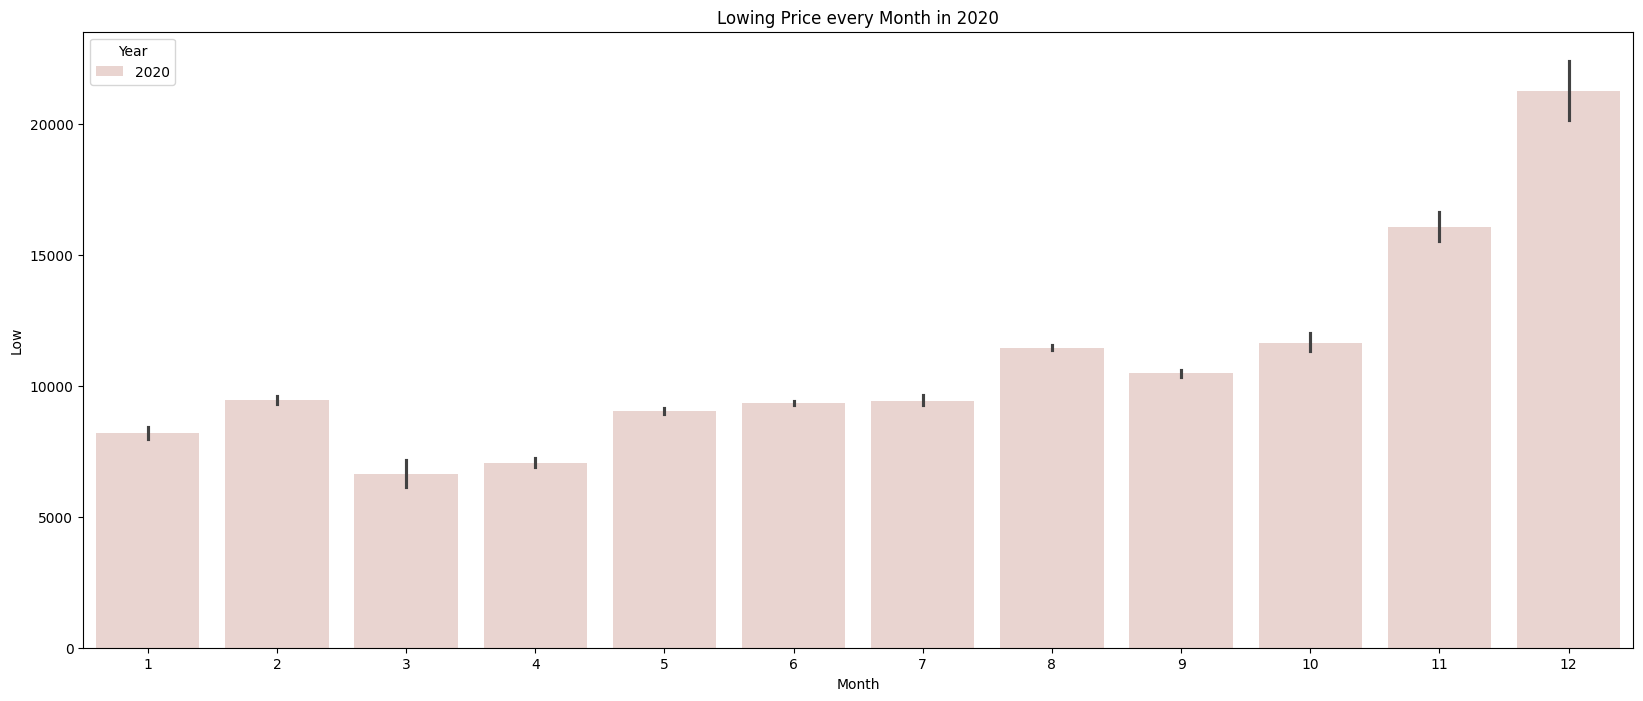

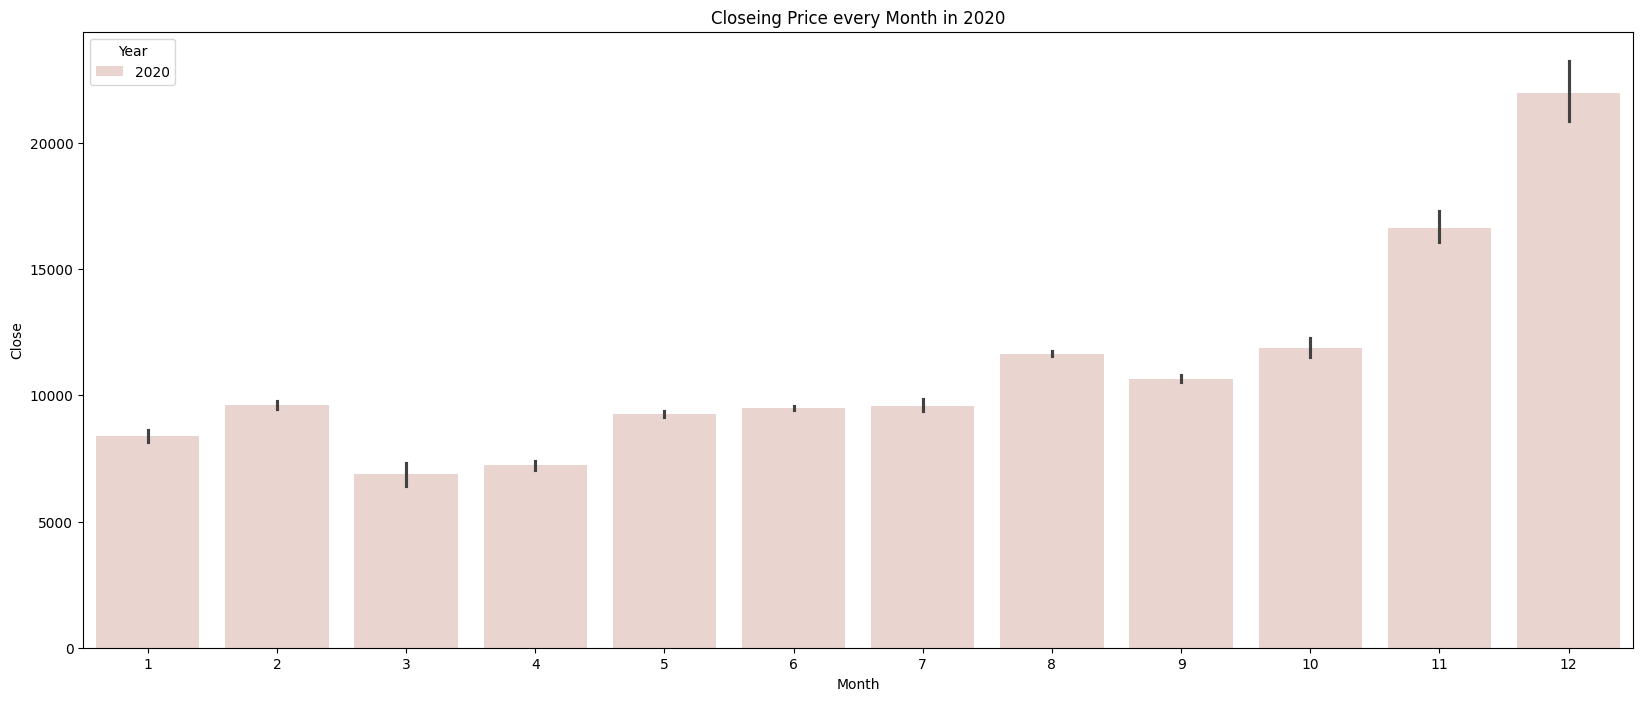

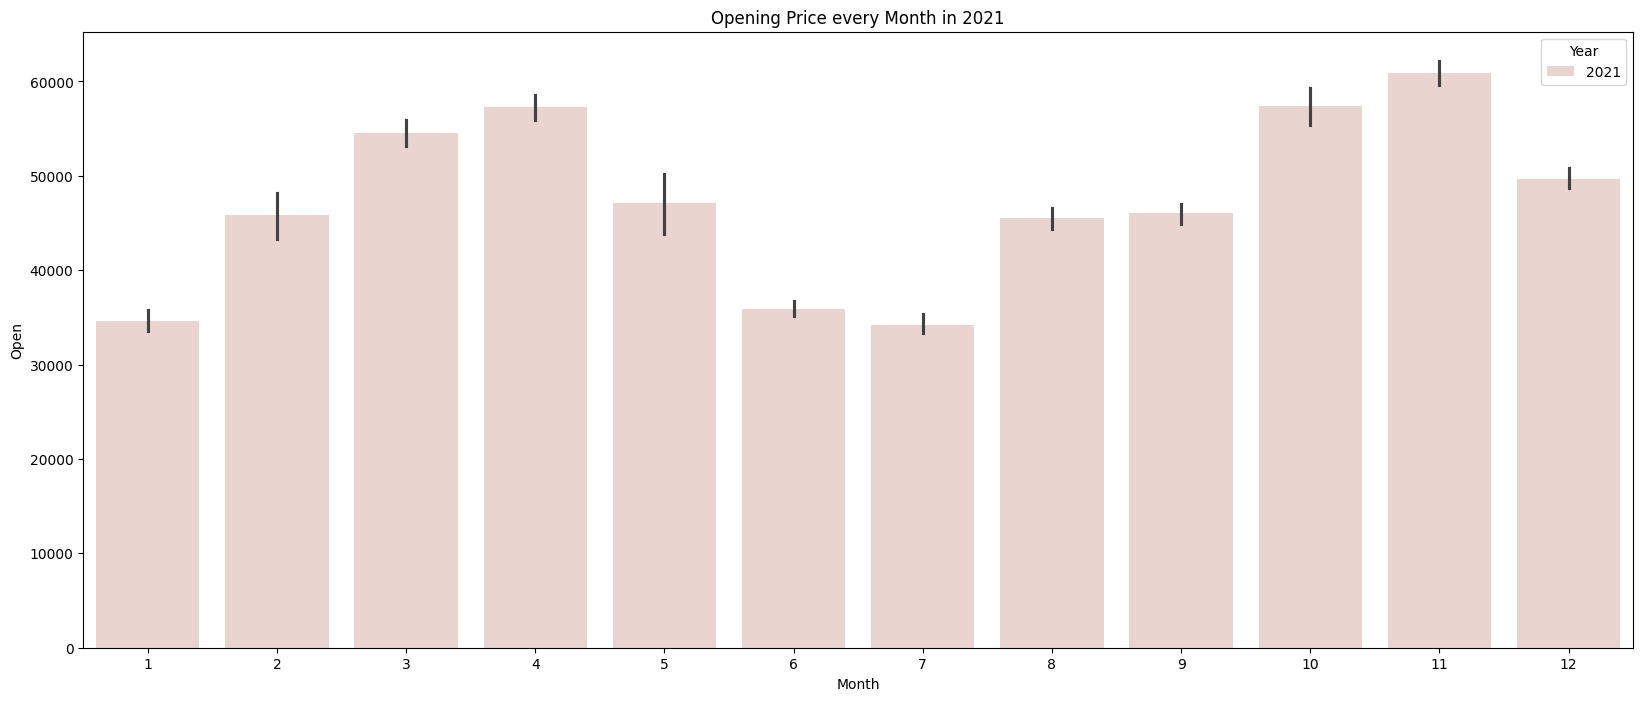

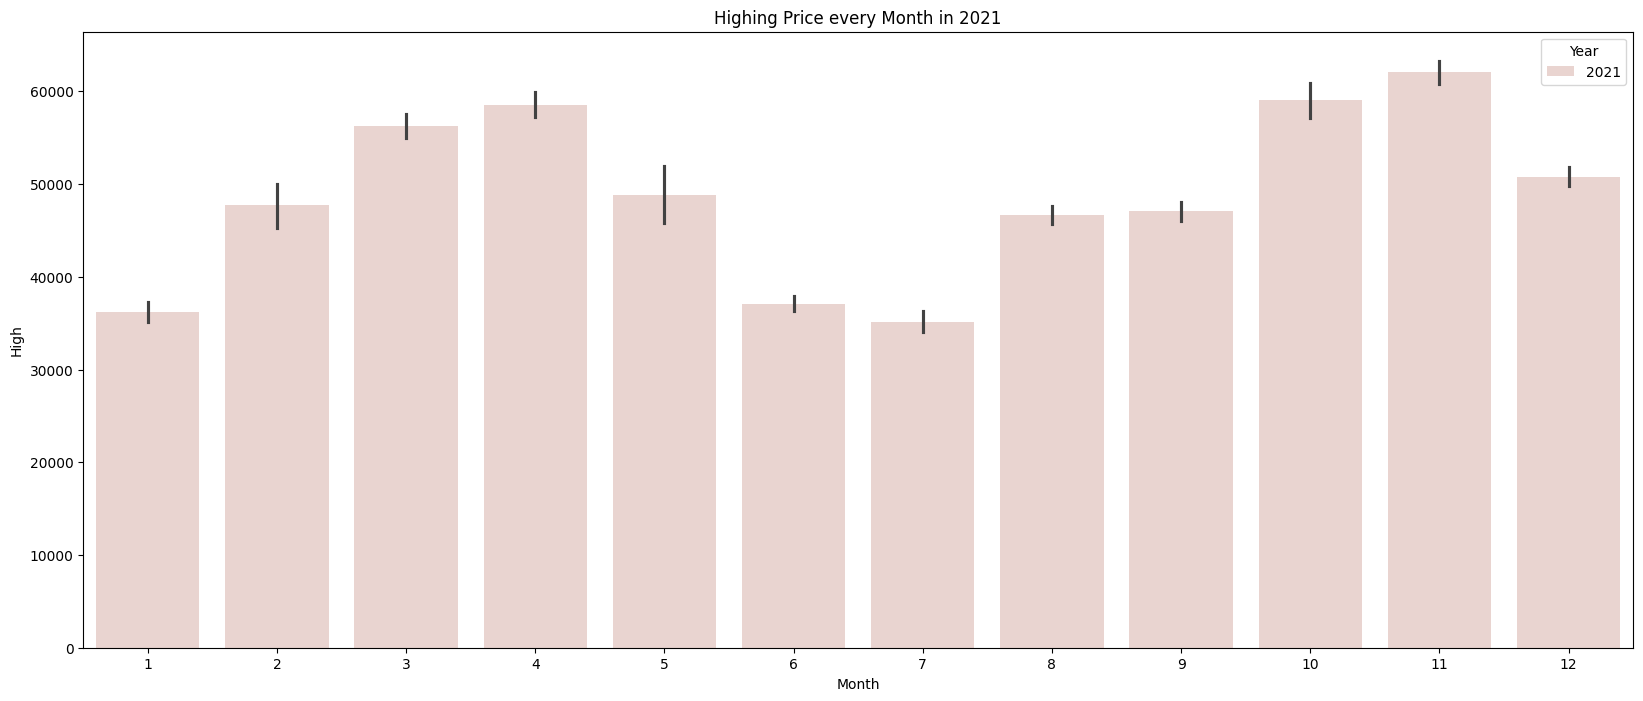

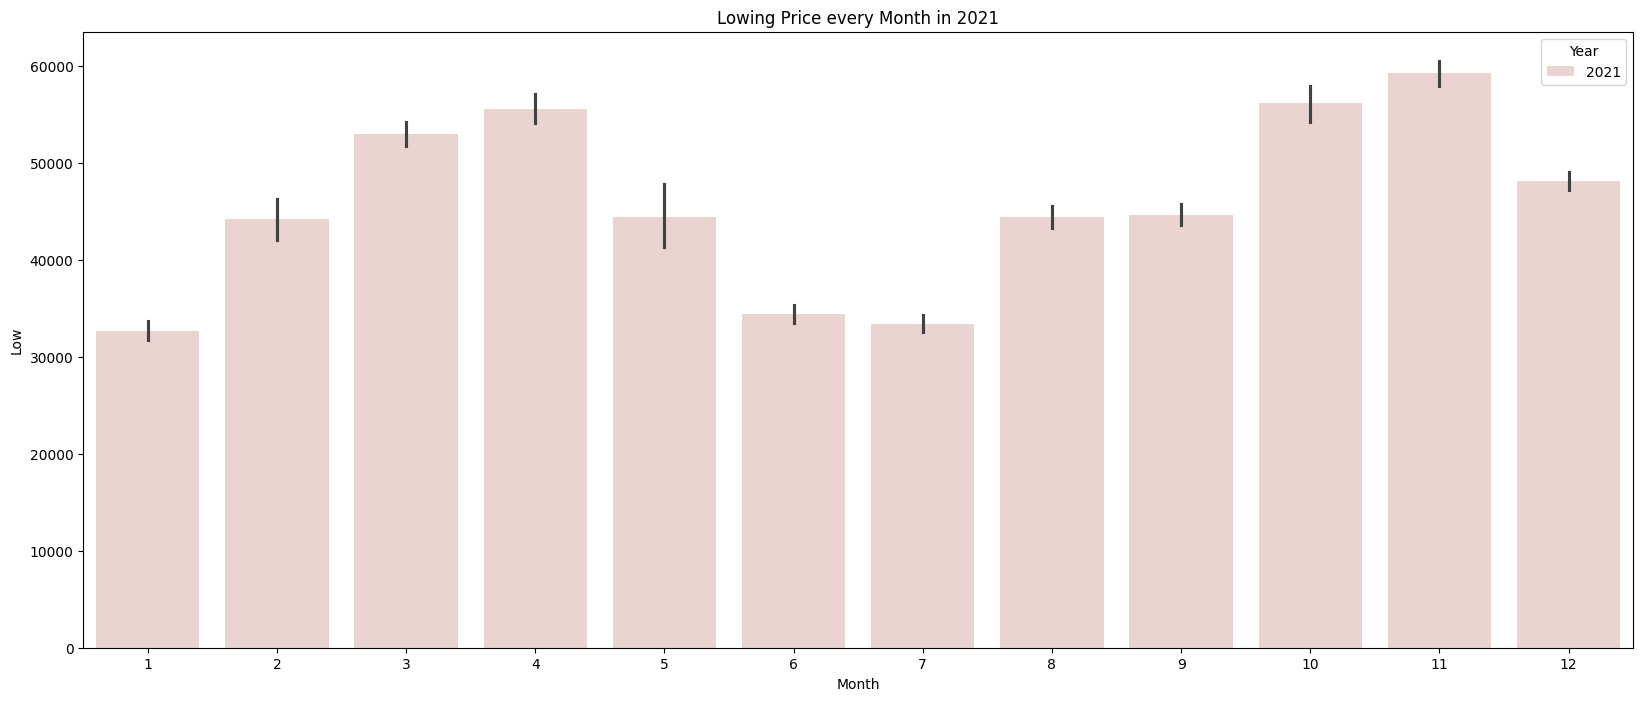

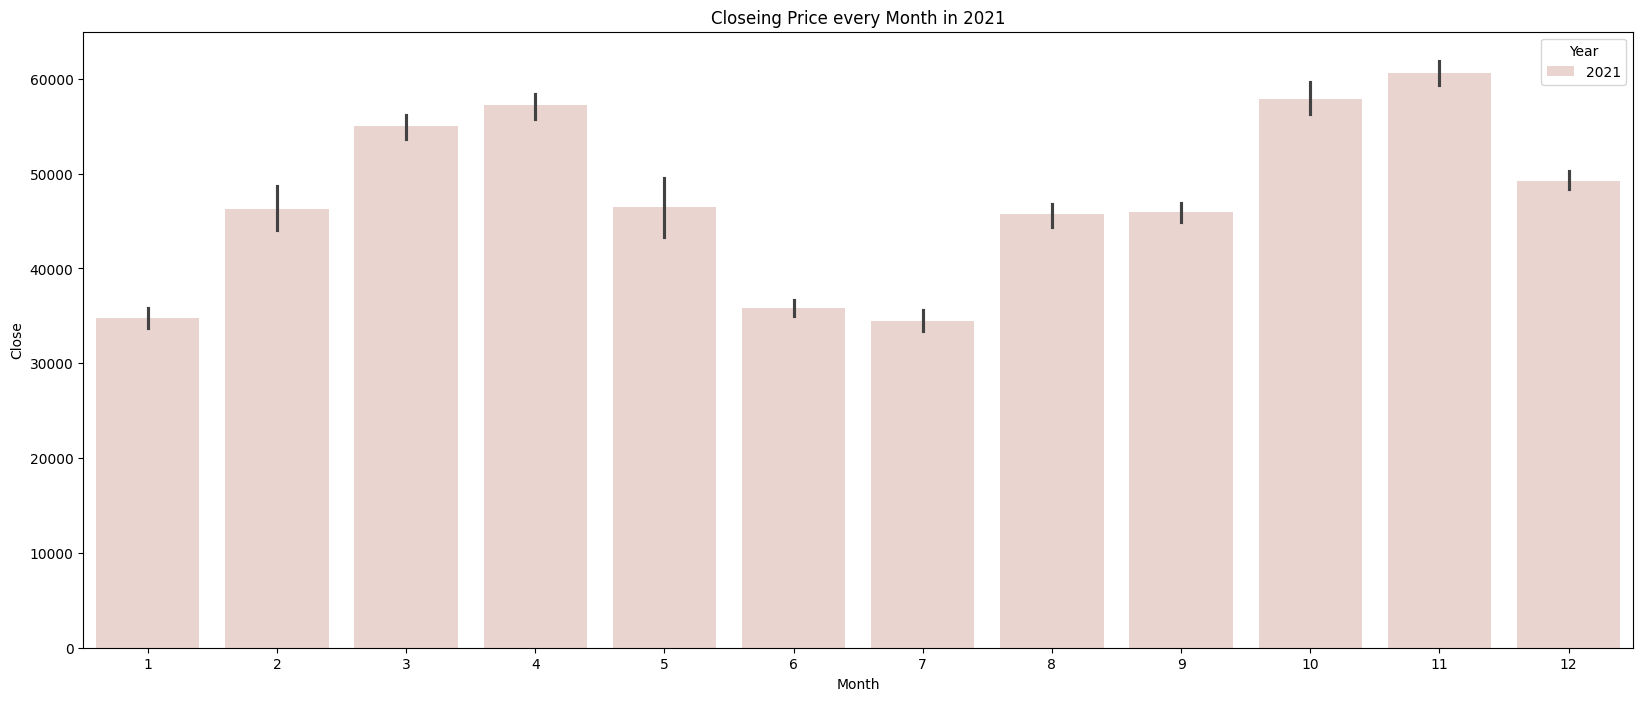

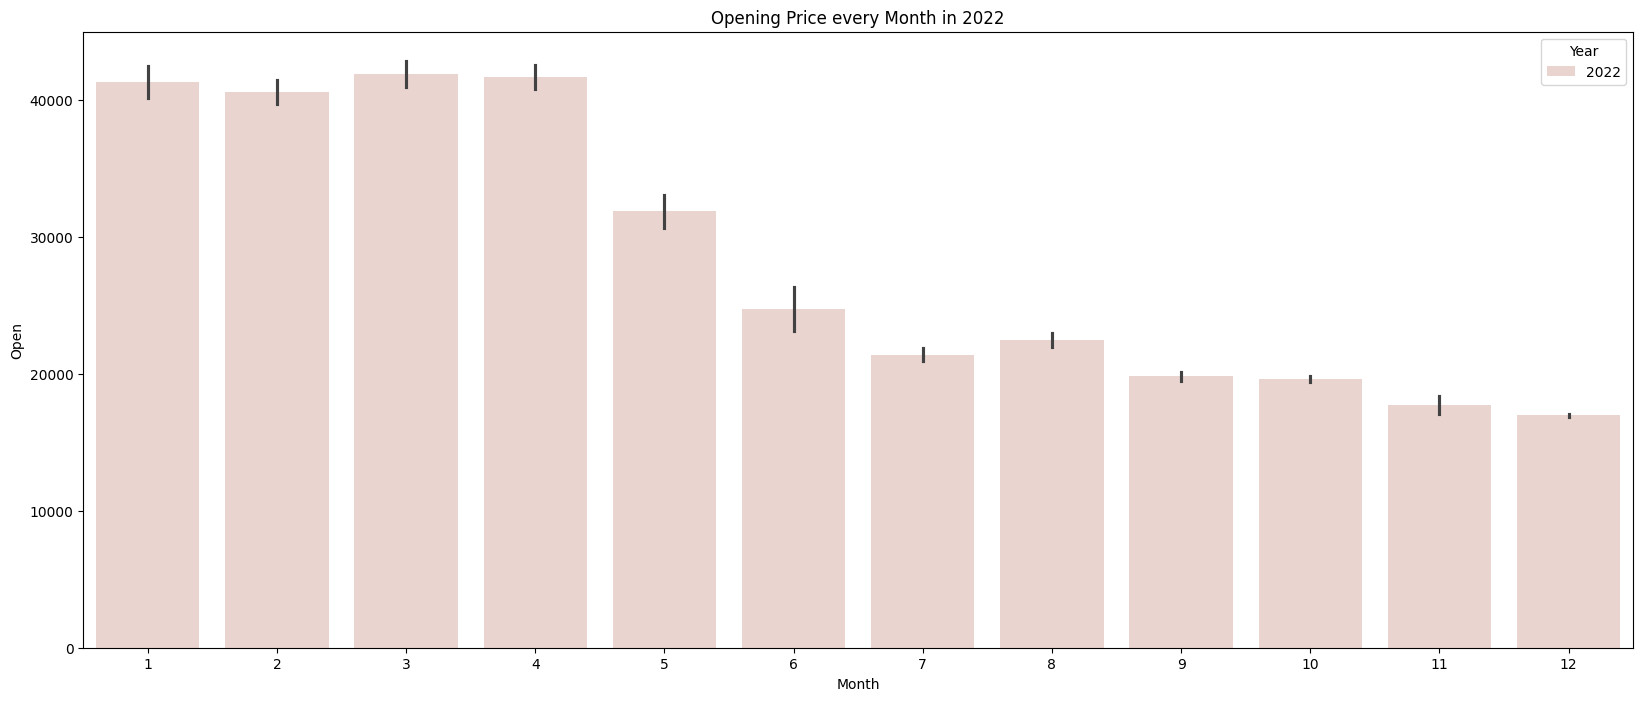

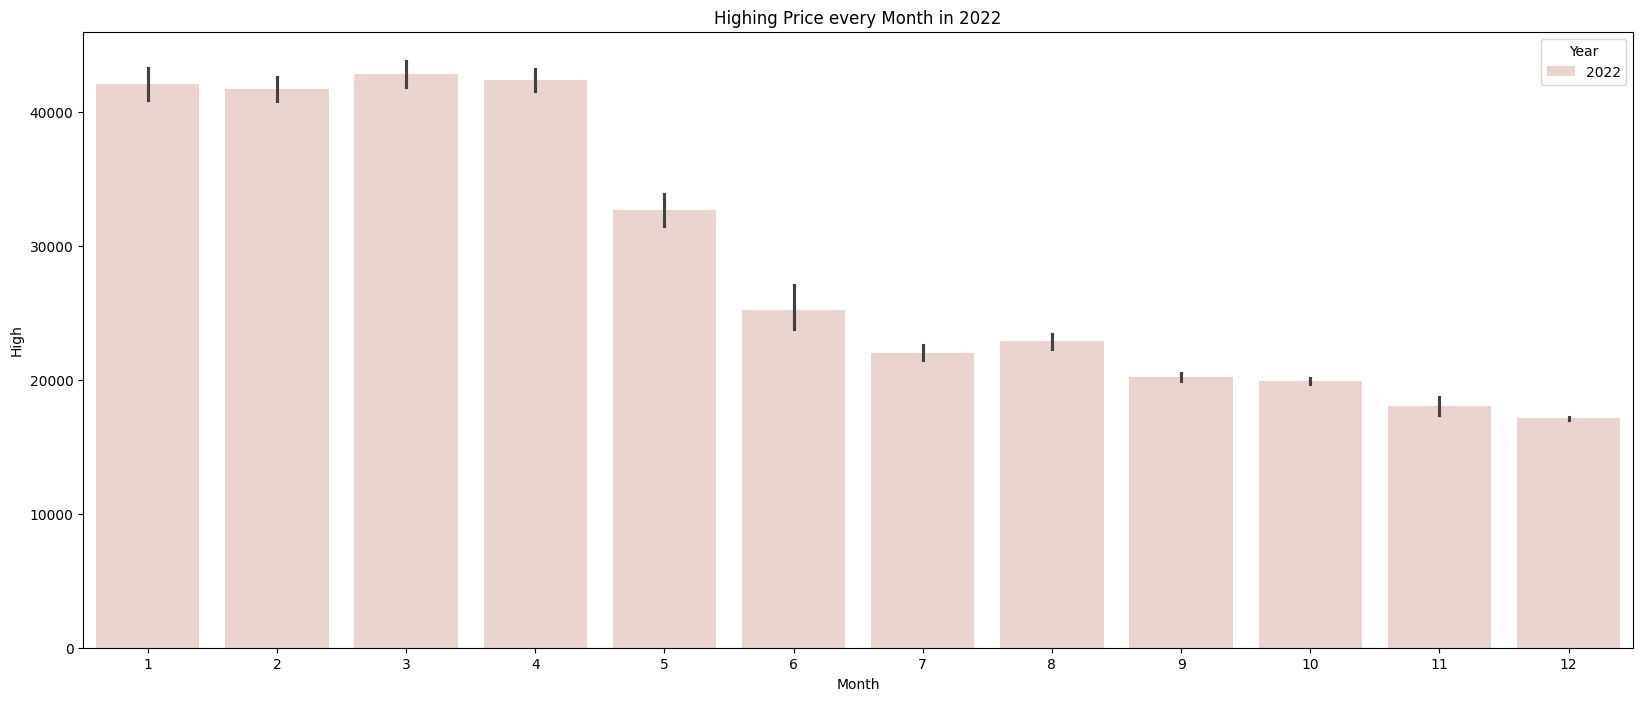

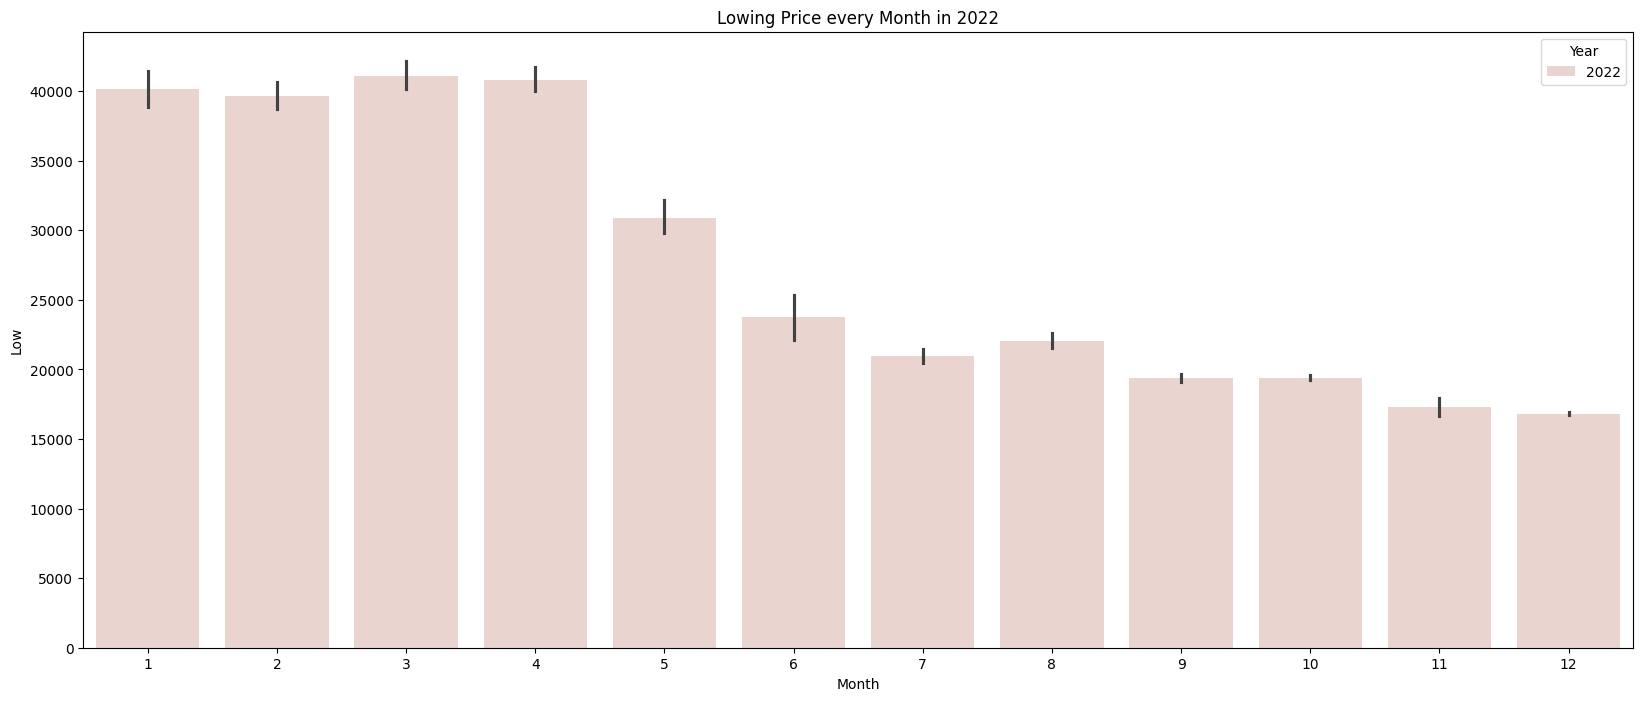

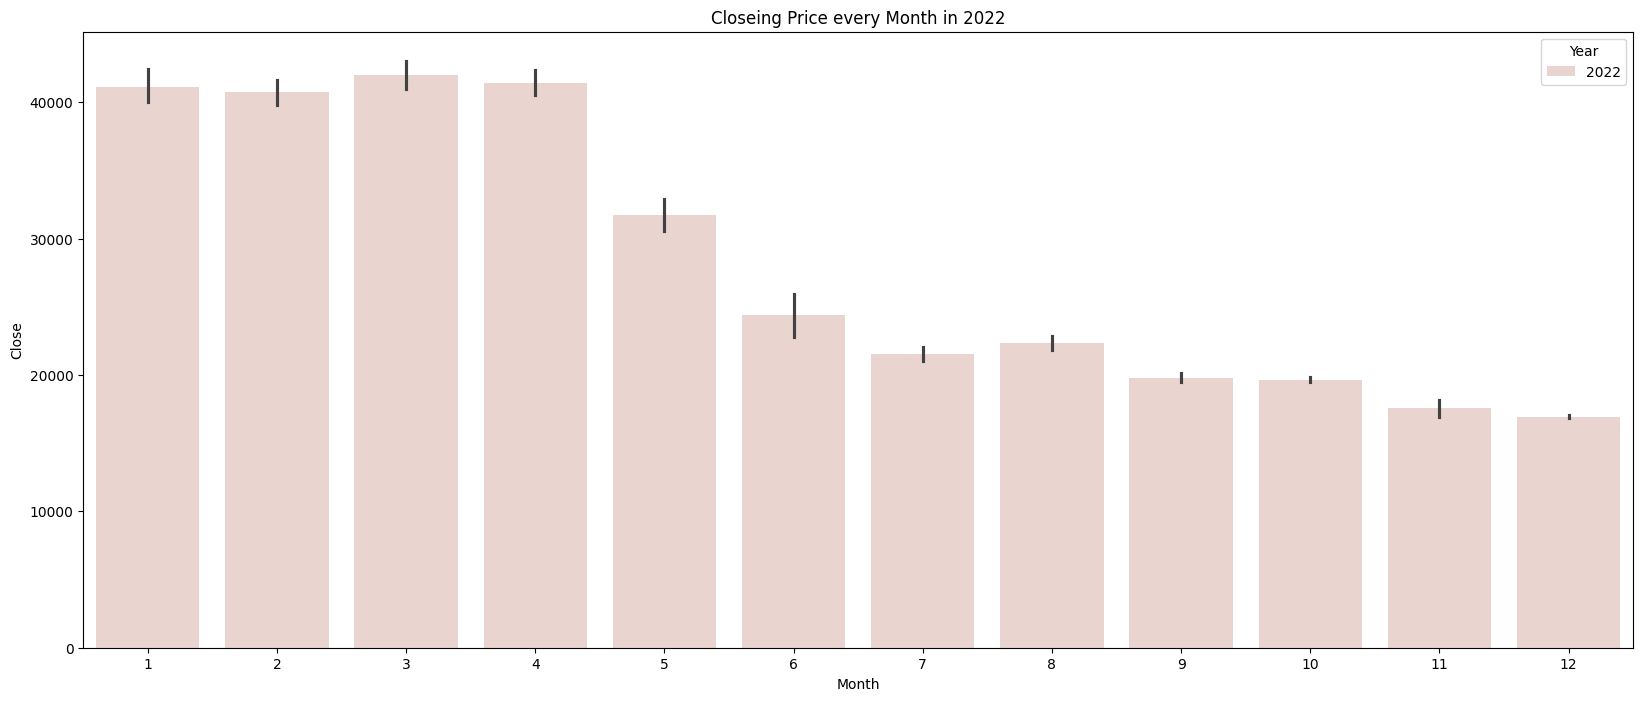

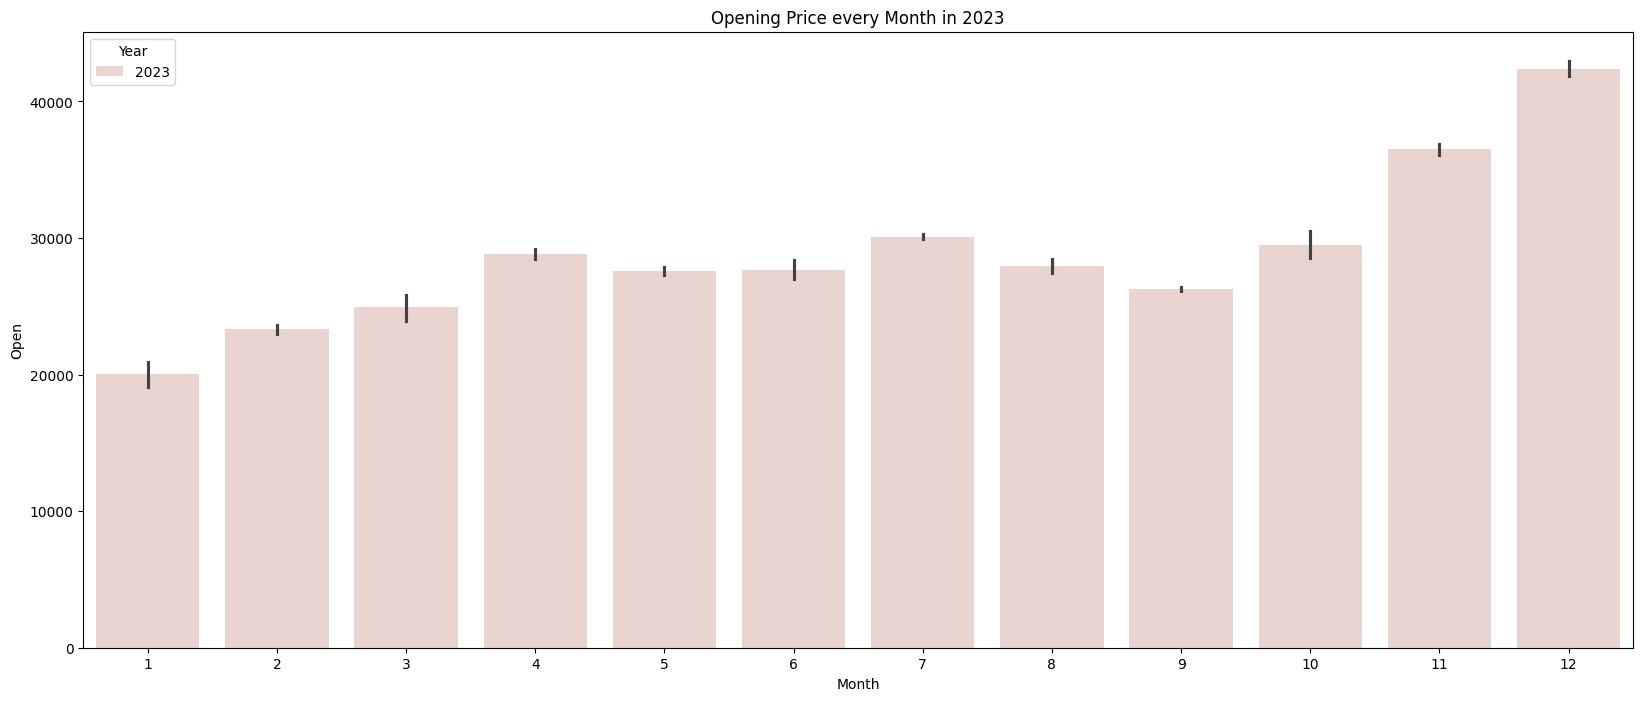

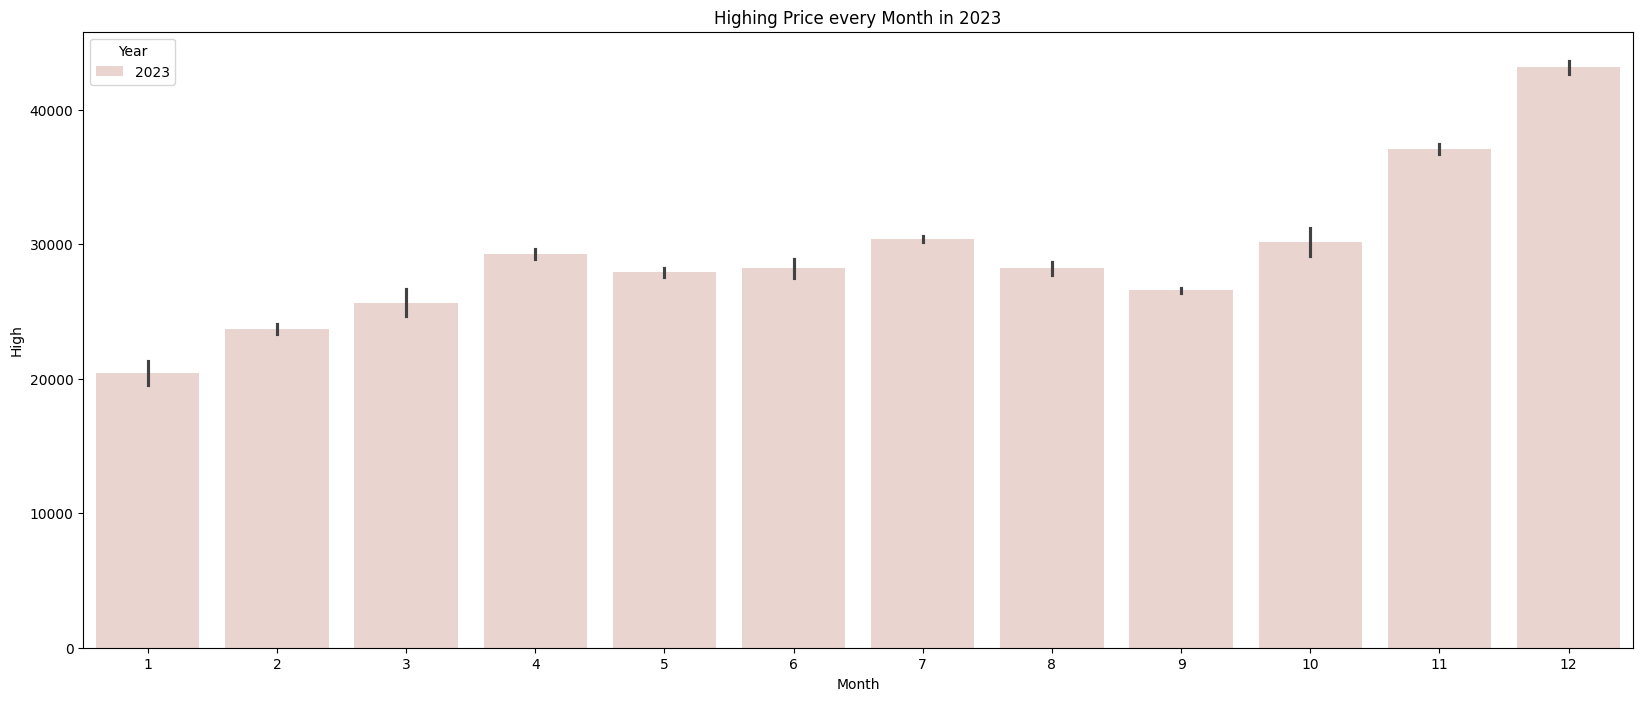

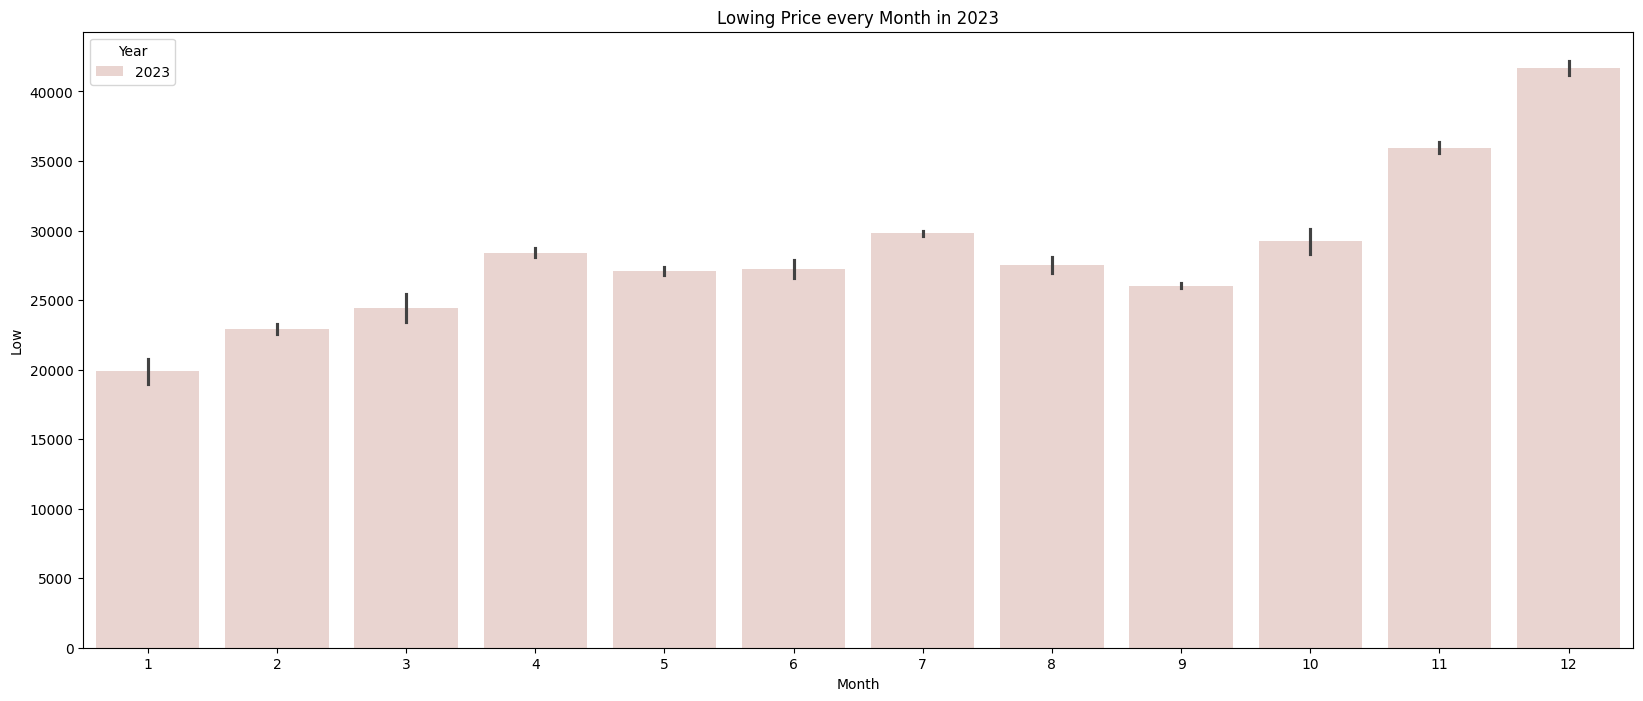

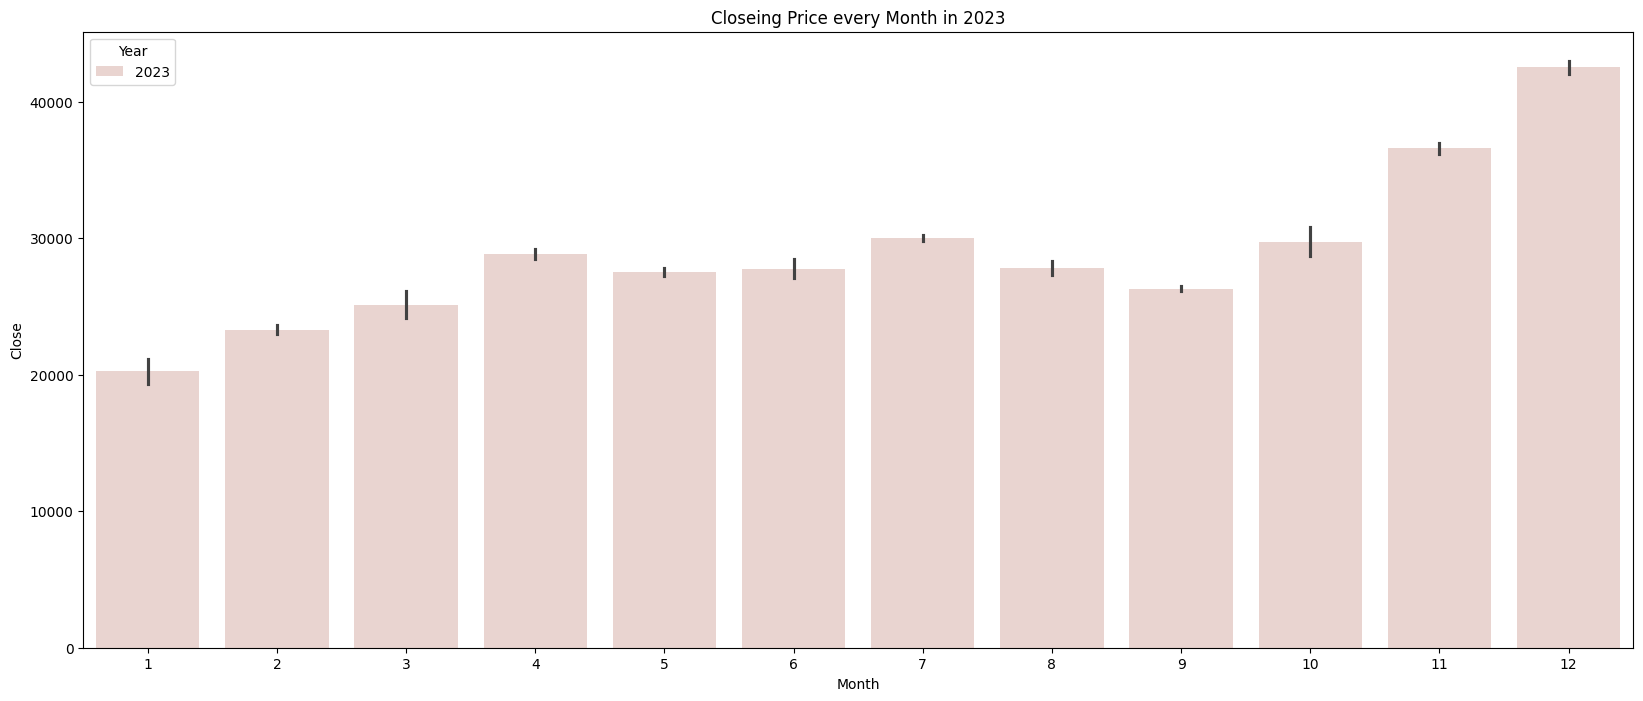

In [ ]:
bitcoin_df[bitcoin_df['Year'] == 2014]
columns = ['Open' , 'High' , 'Low' , 'Close']

for i in range(2014,2024):
    for j in range(0,4):
        plt.figure(figsize=(20,8))
        sns.barplot(bitcoin_df[bitcoin_df['Year'] == i], x='Month', y=columns[j], hue='Year')
        plt.title(f'{columns[j]}ing Price every Month in {i}')

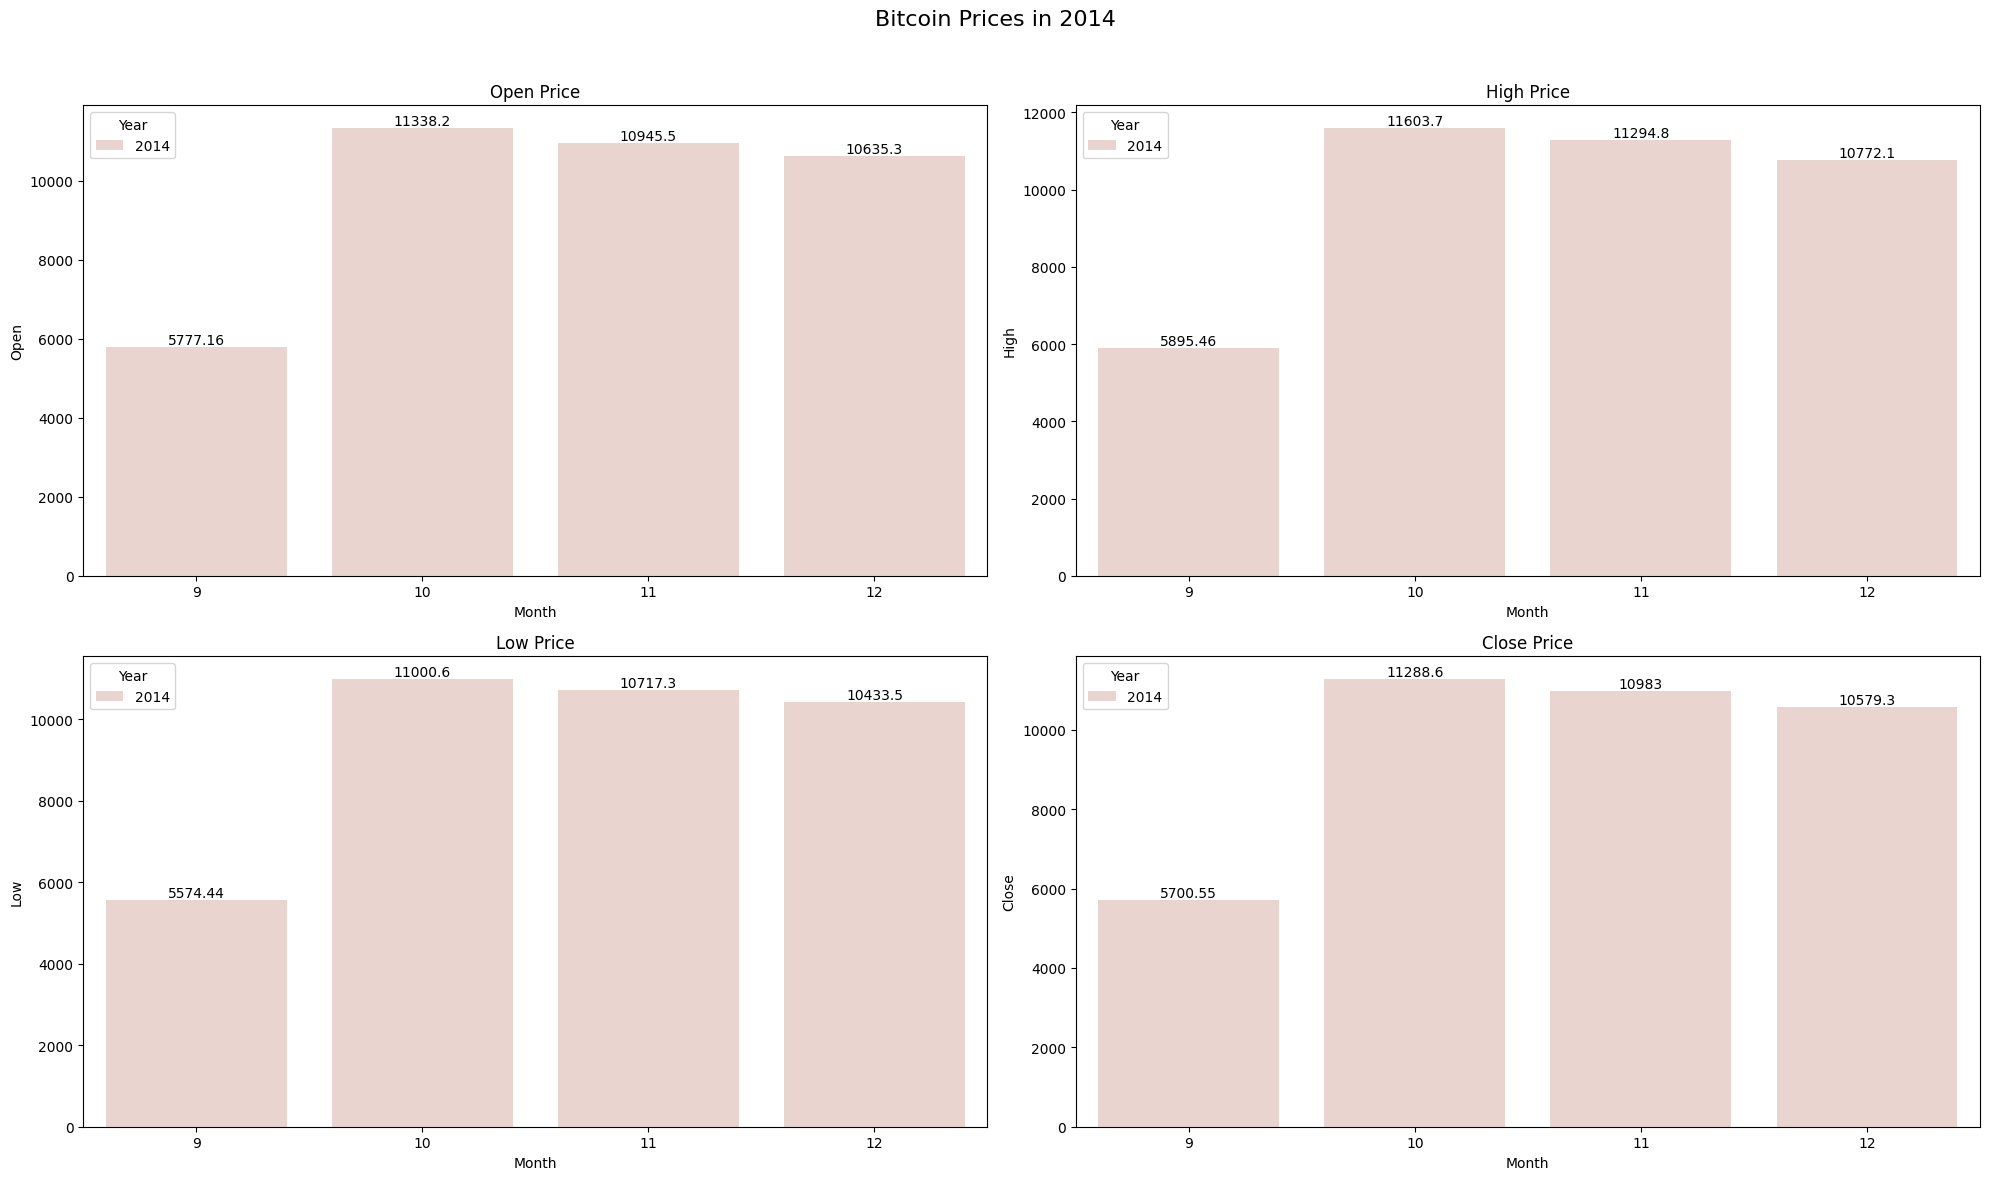

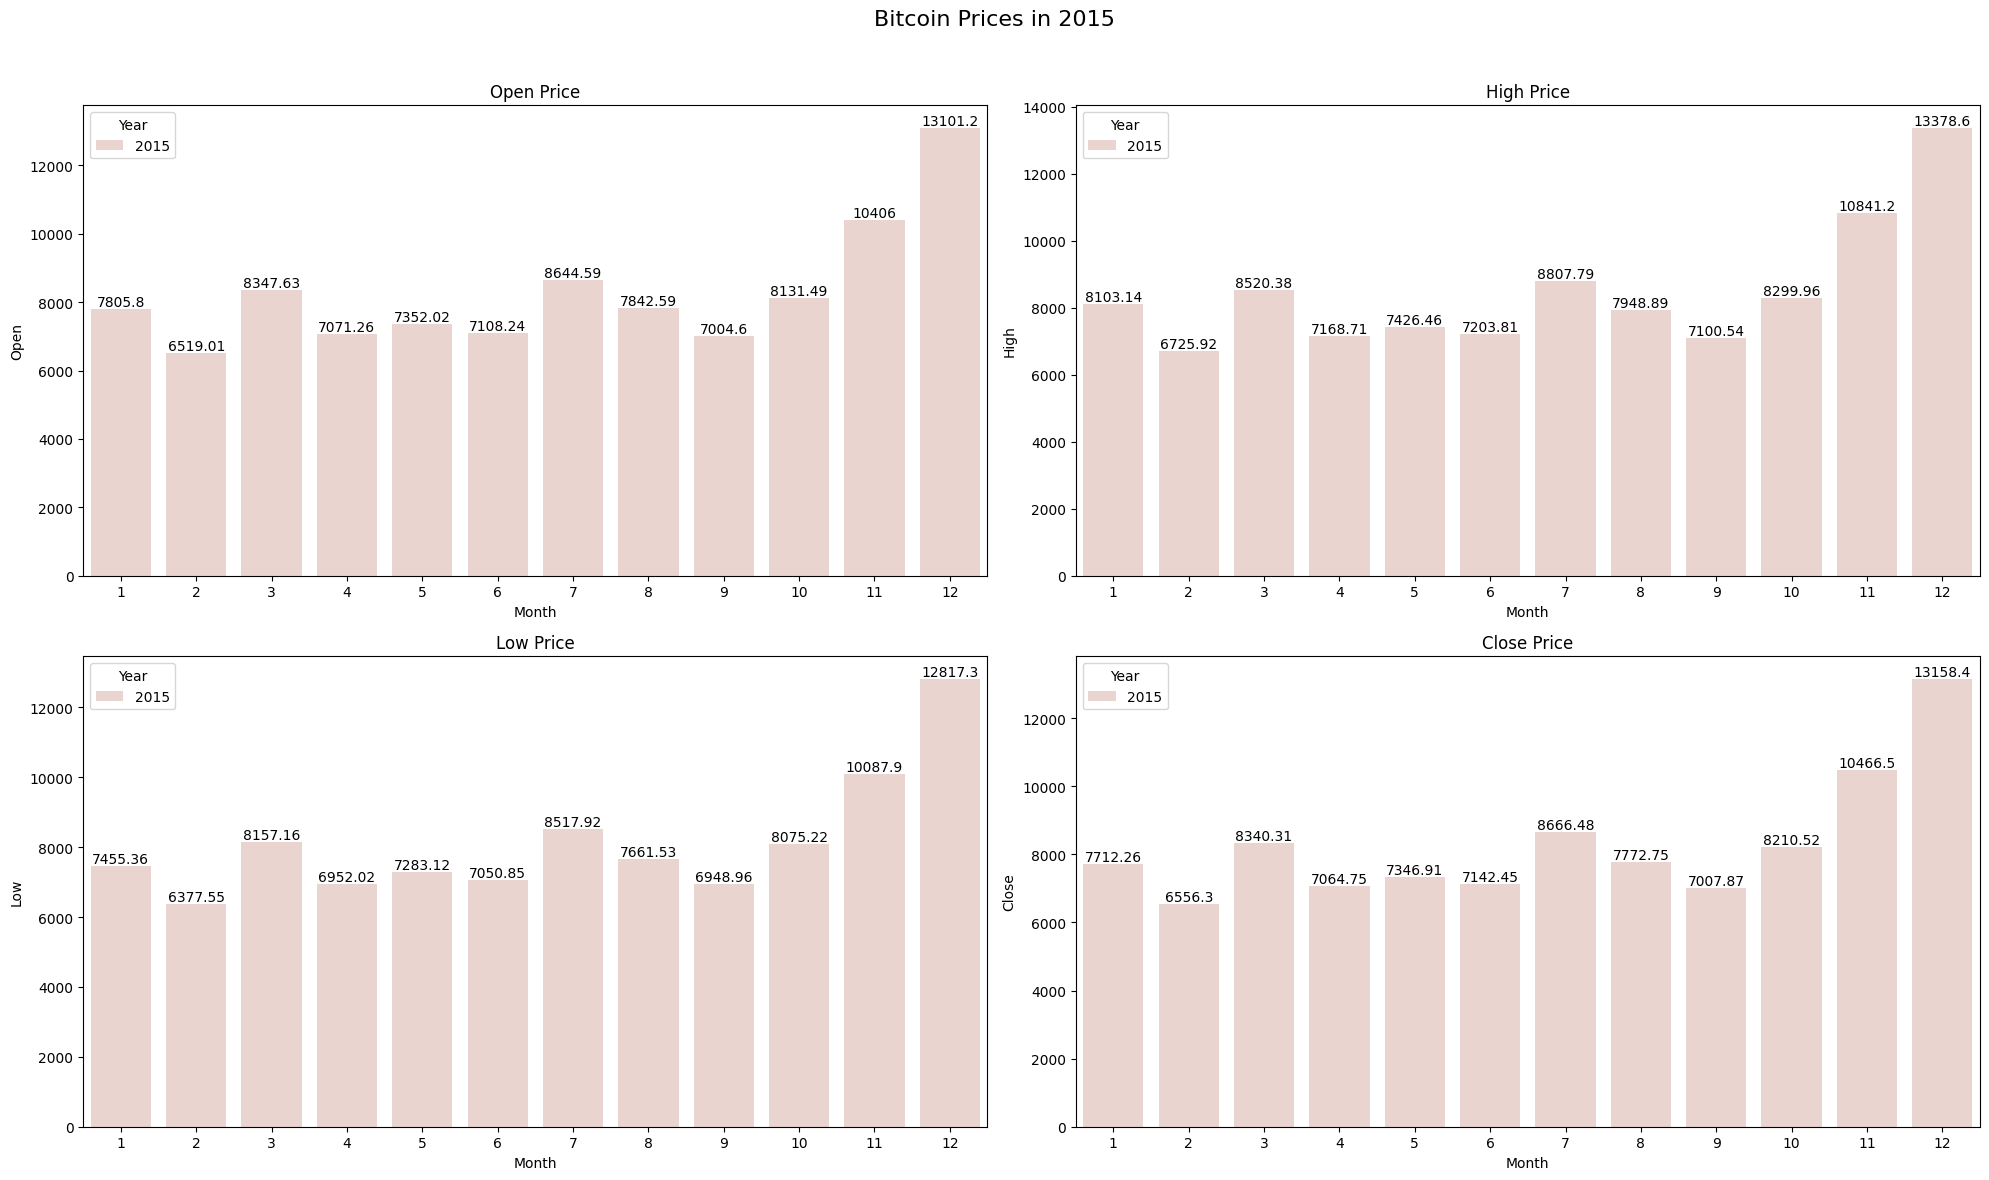

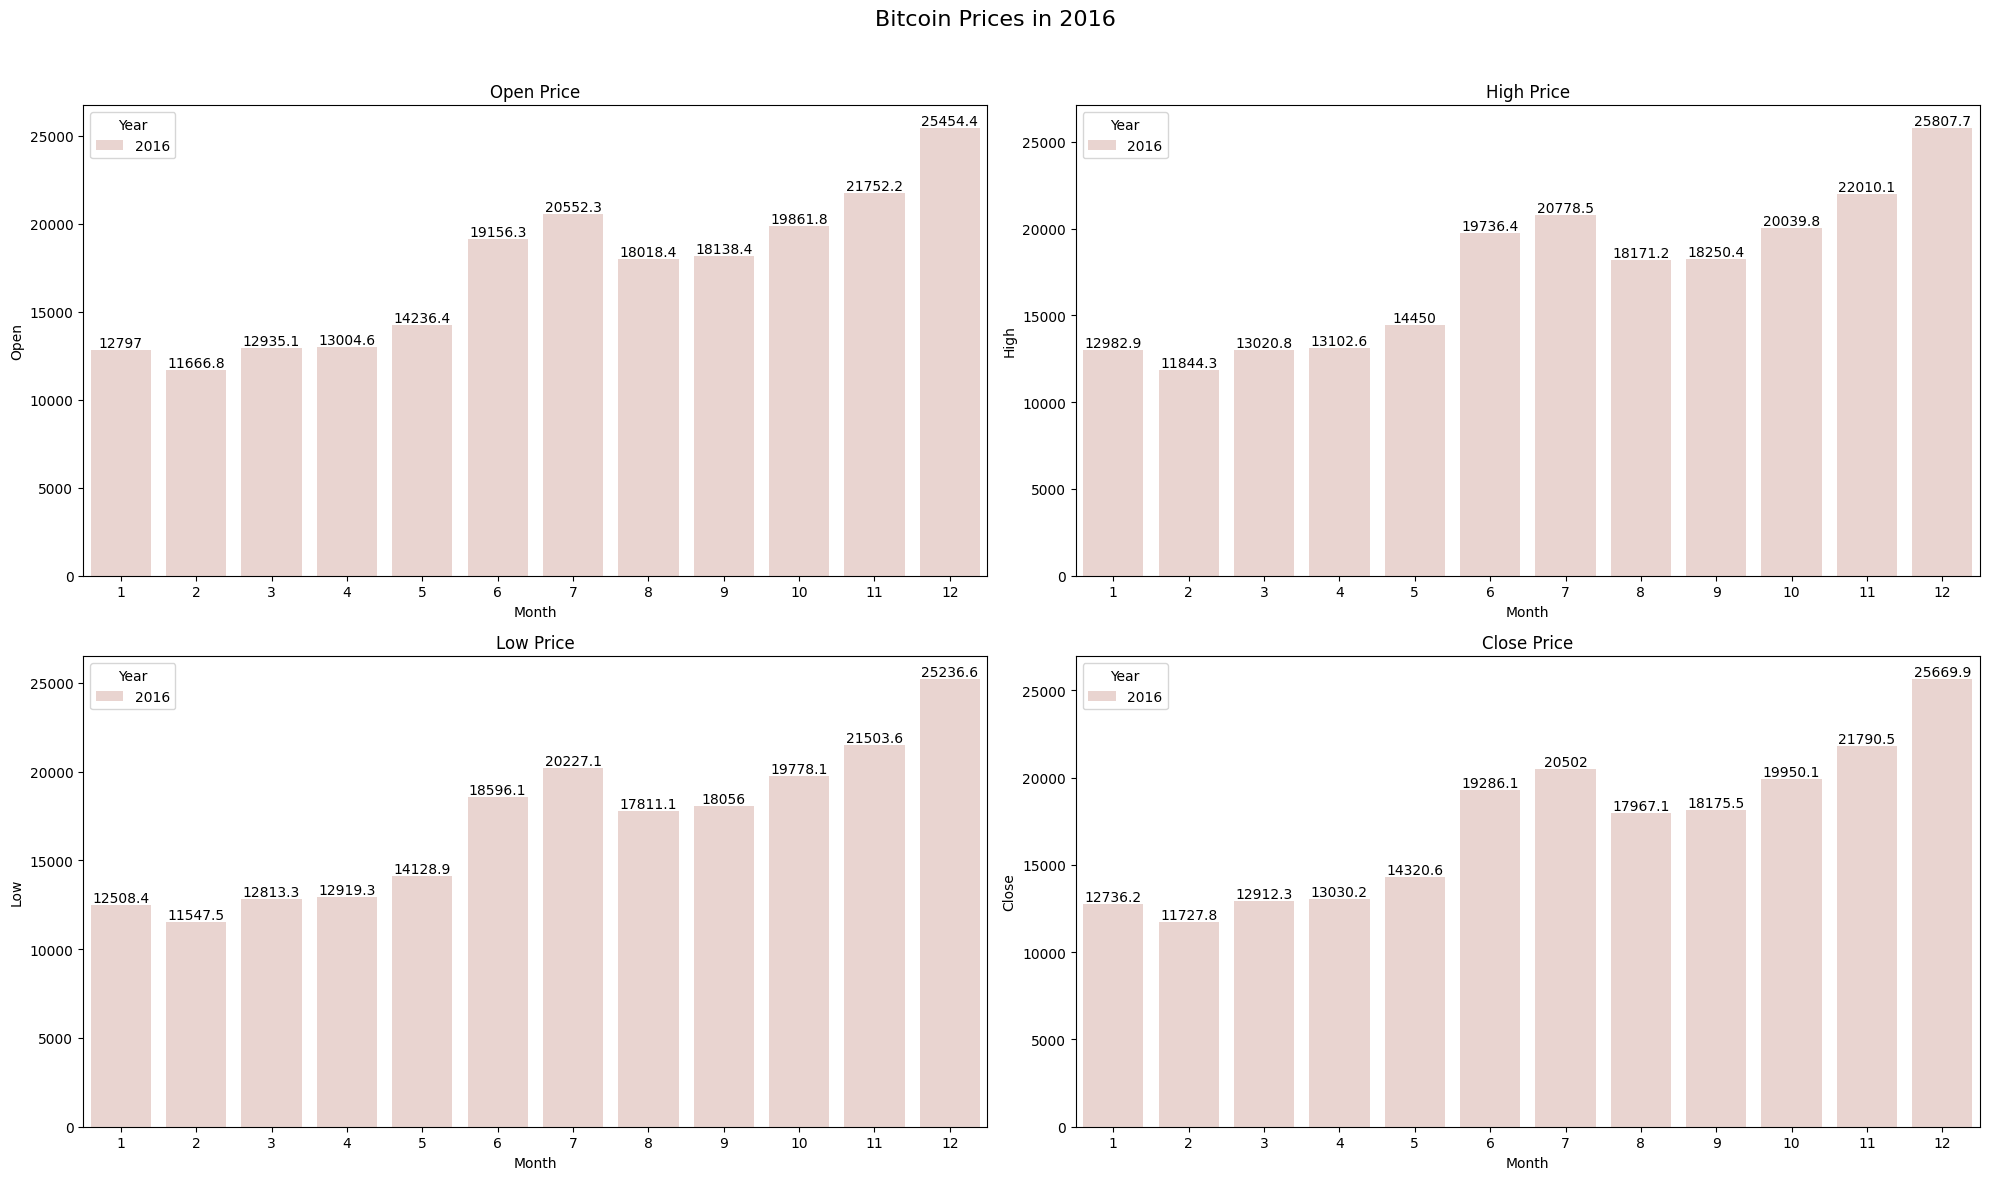

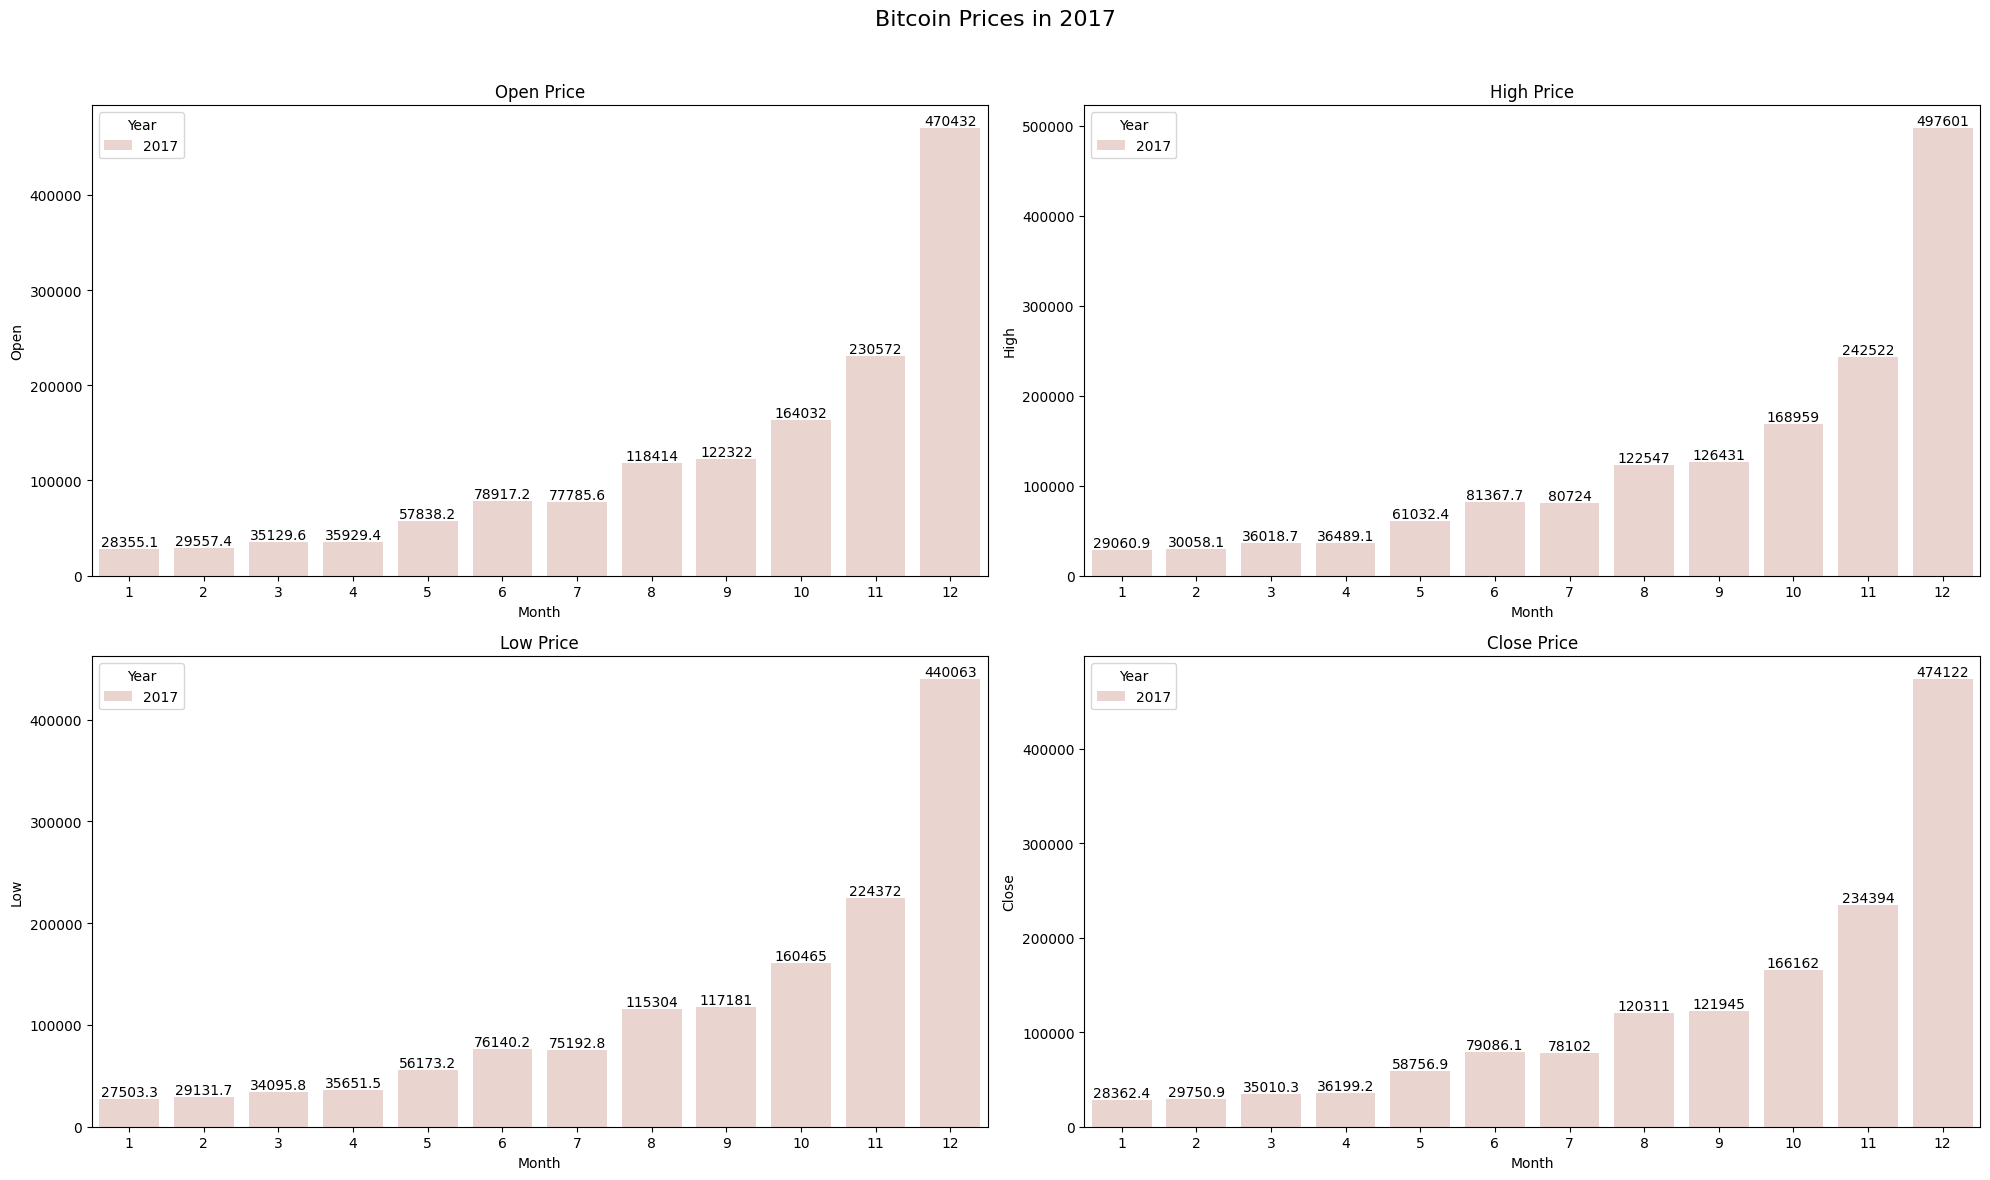

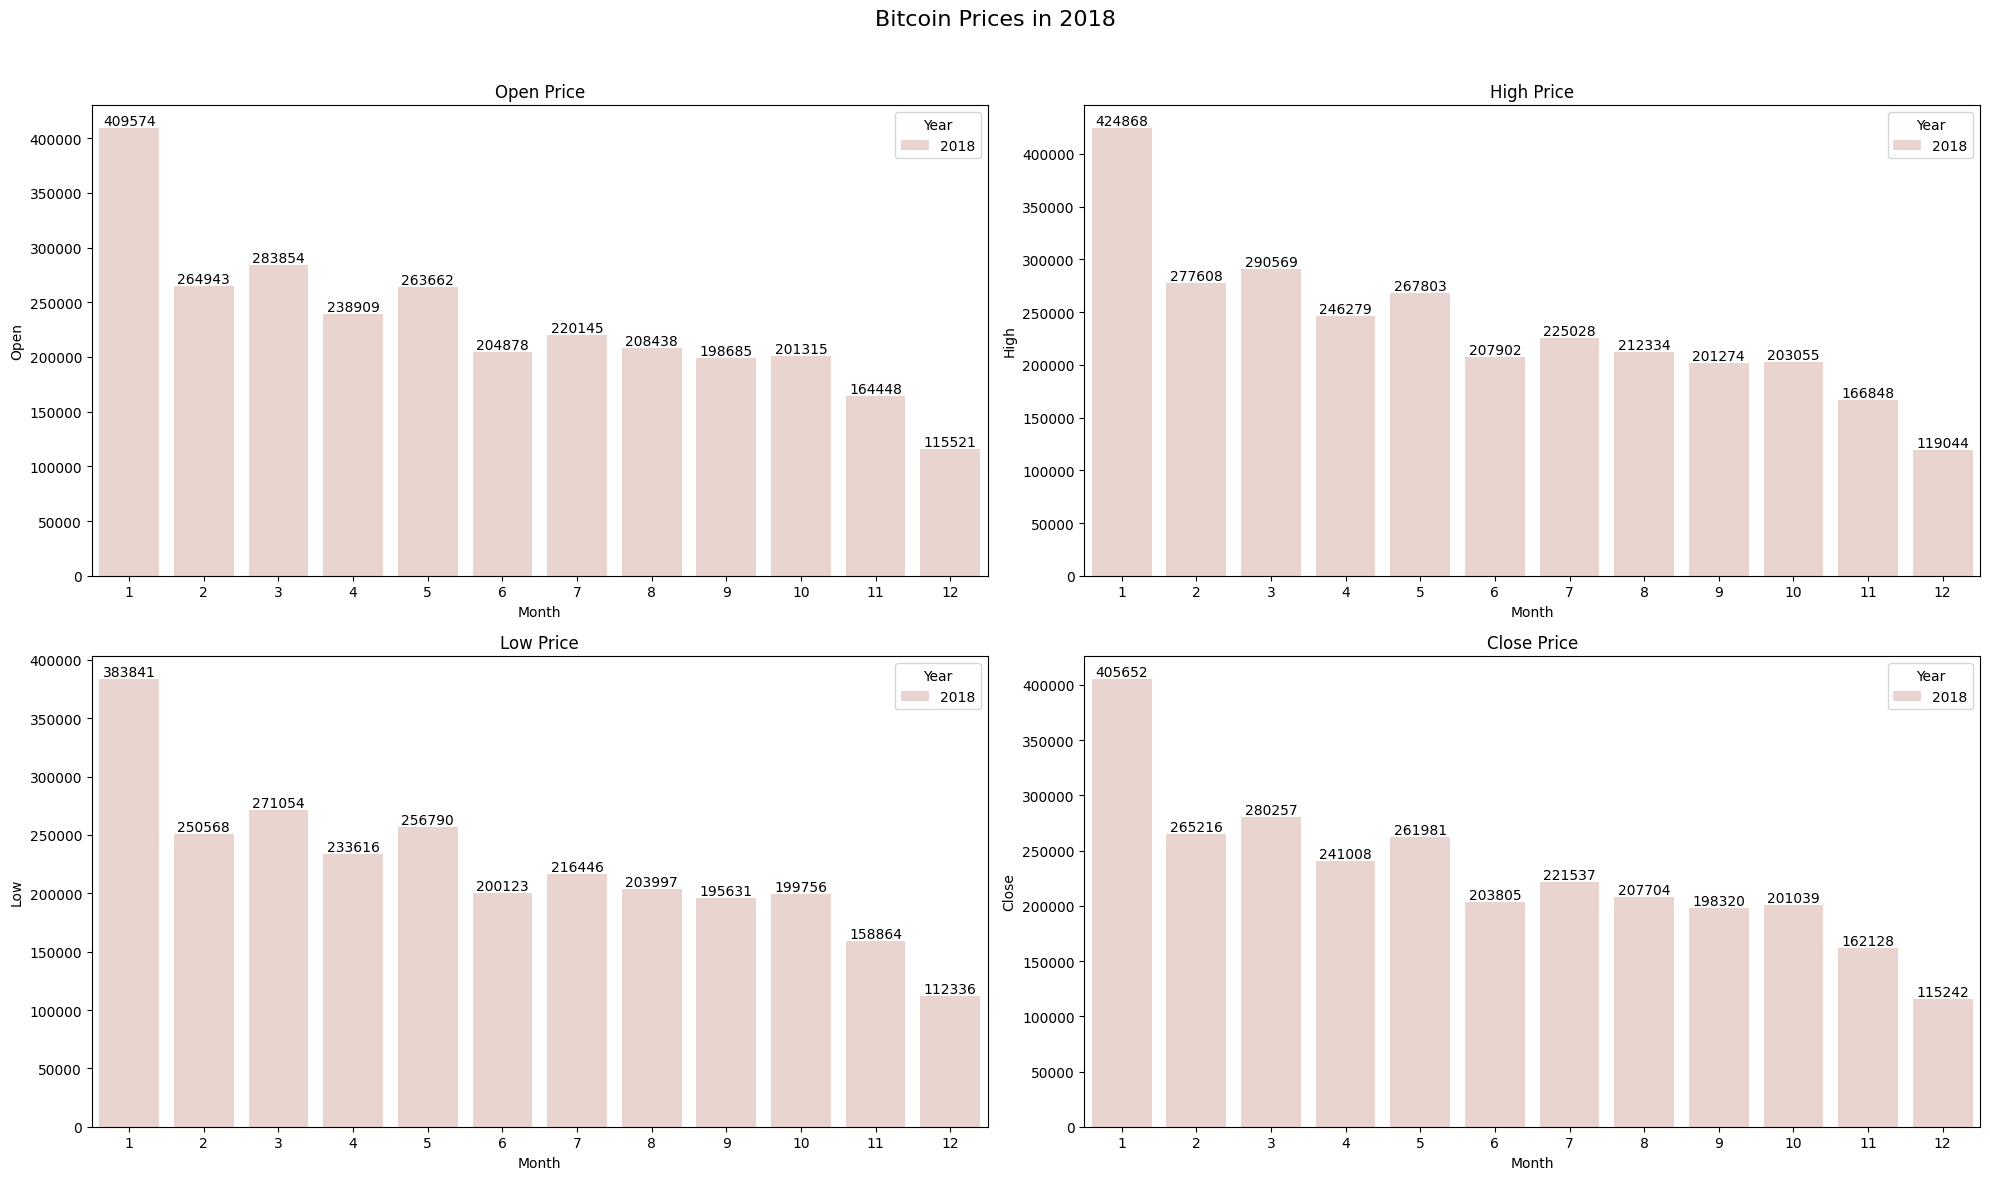

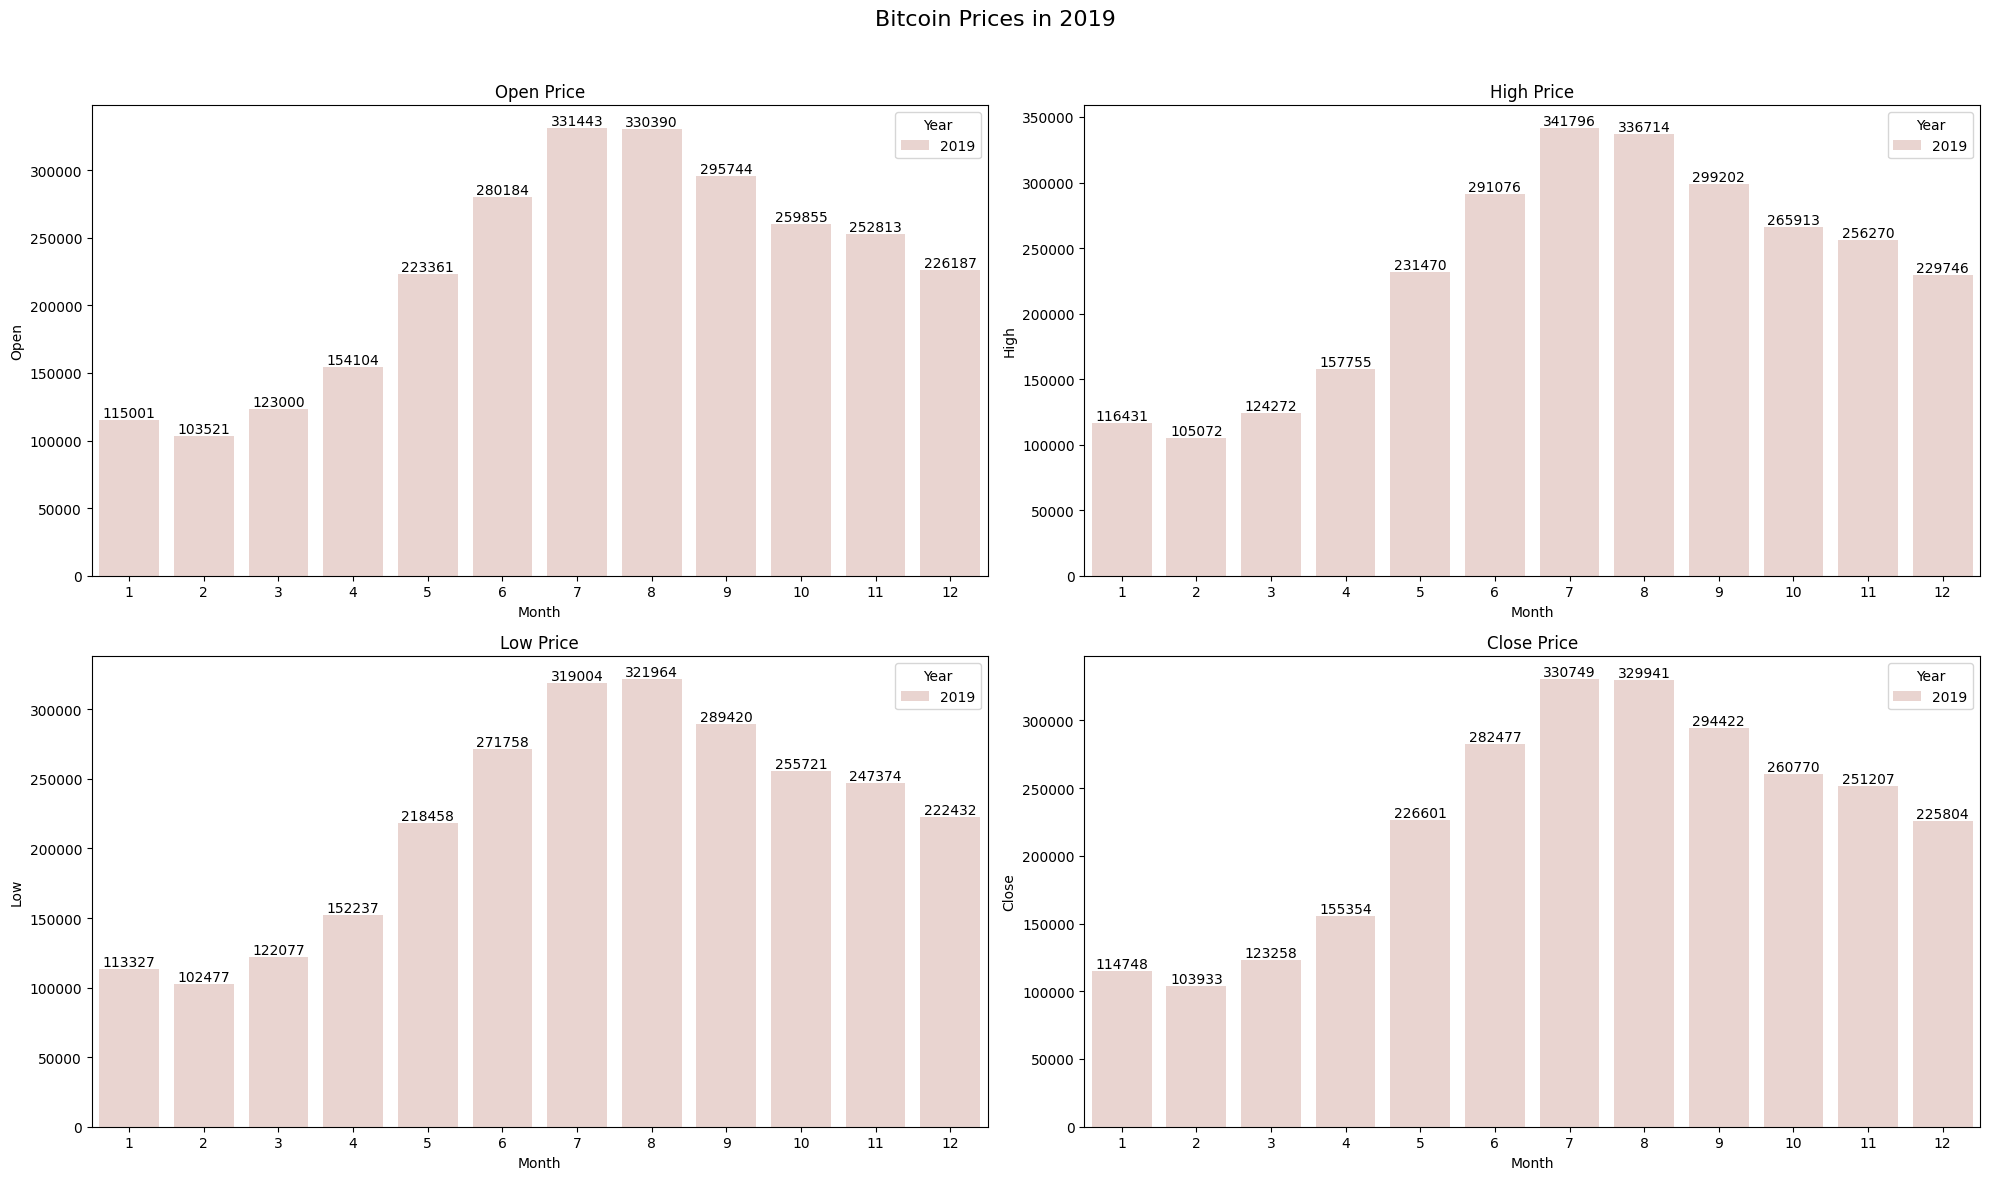

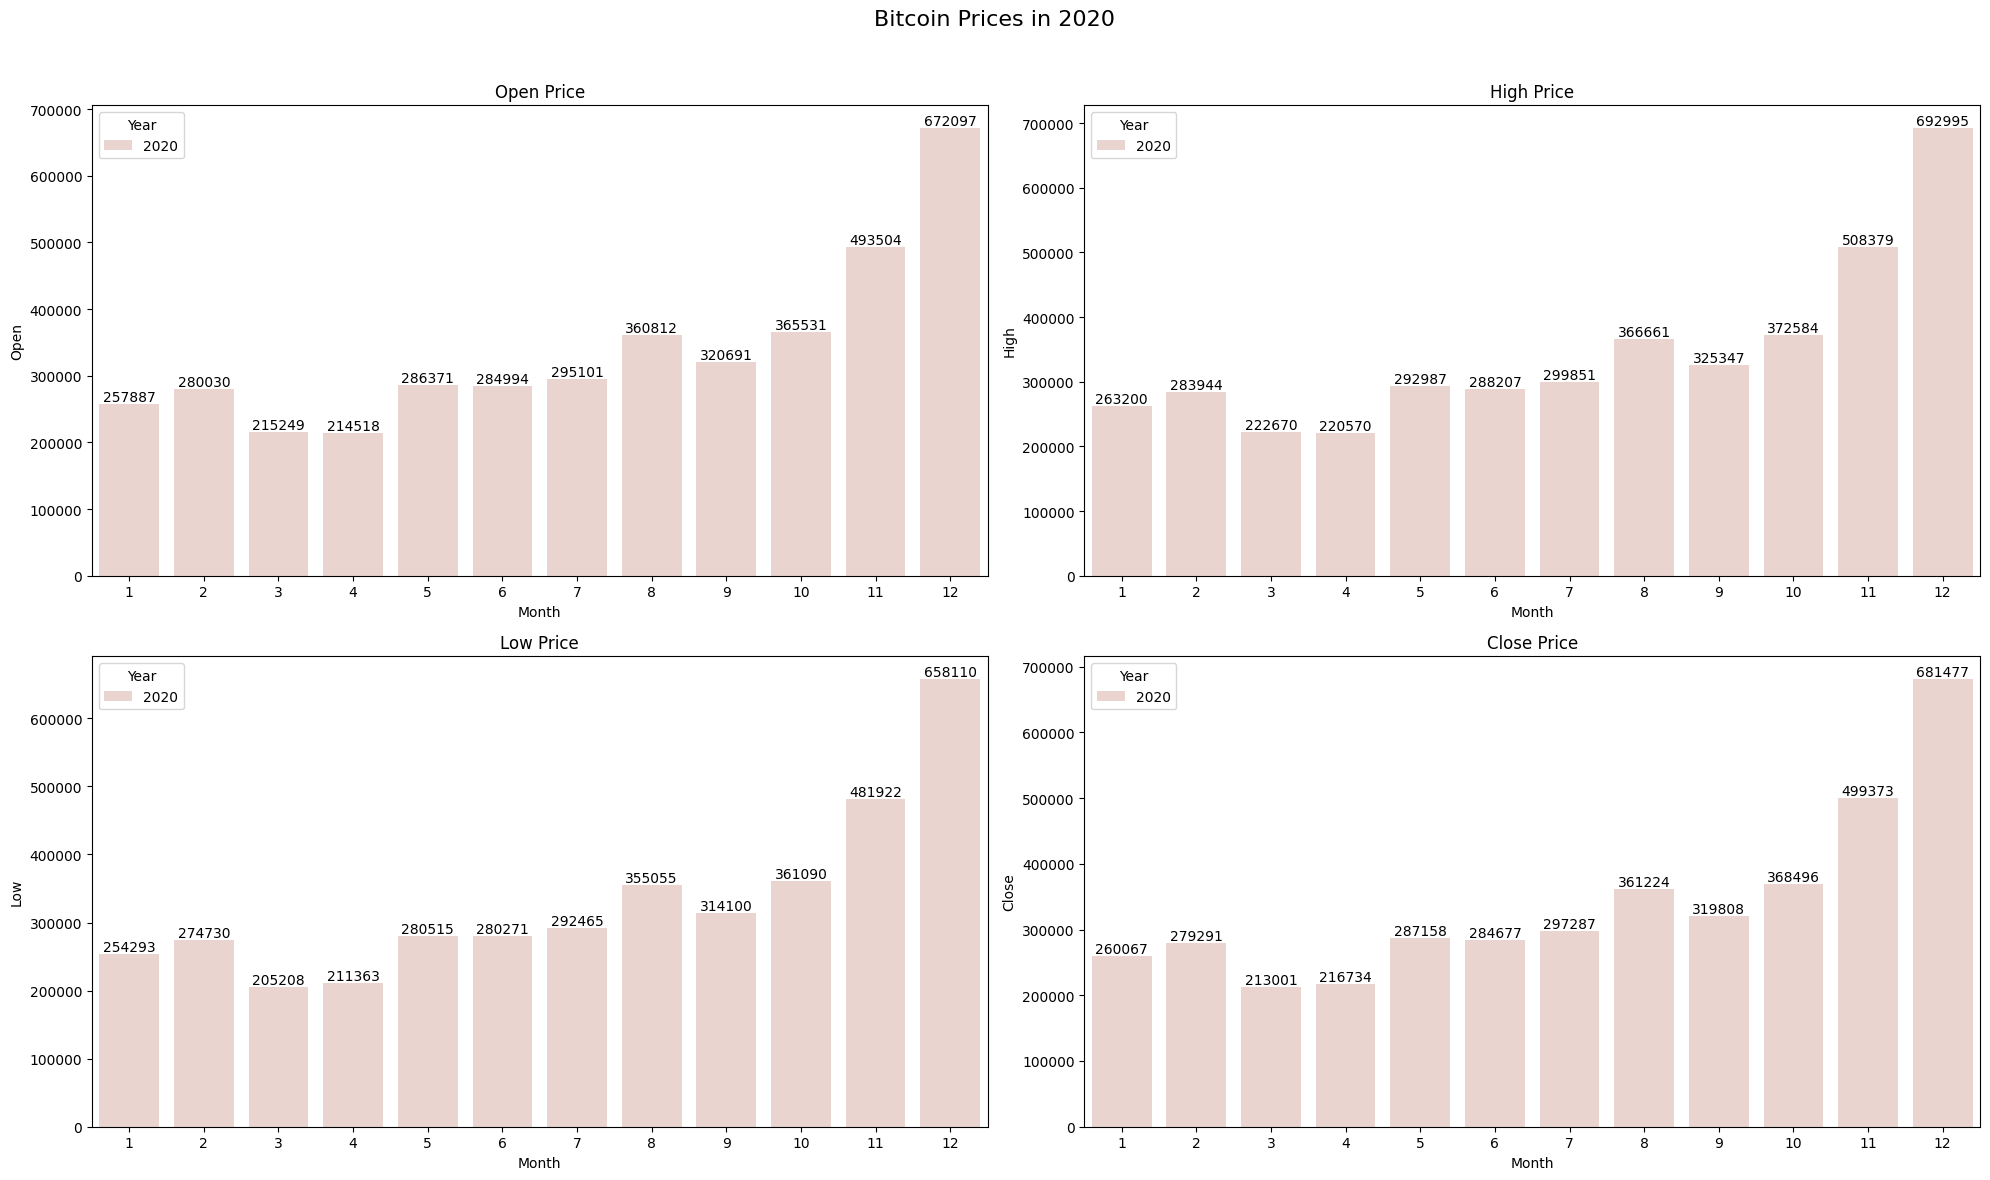

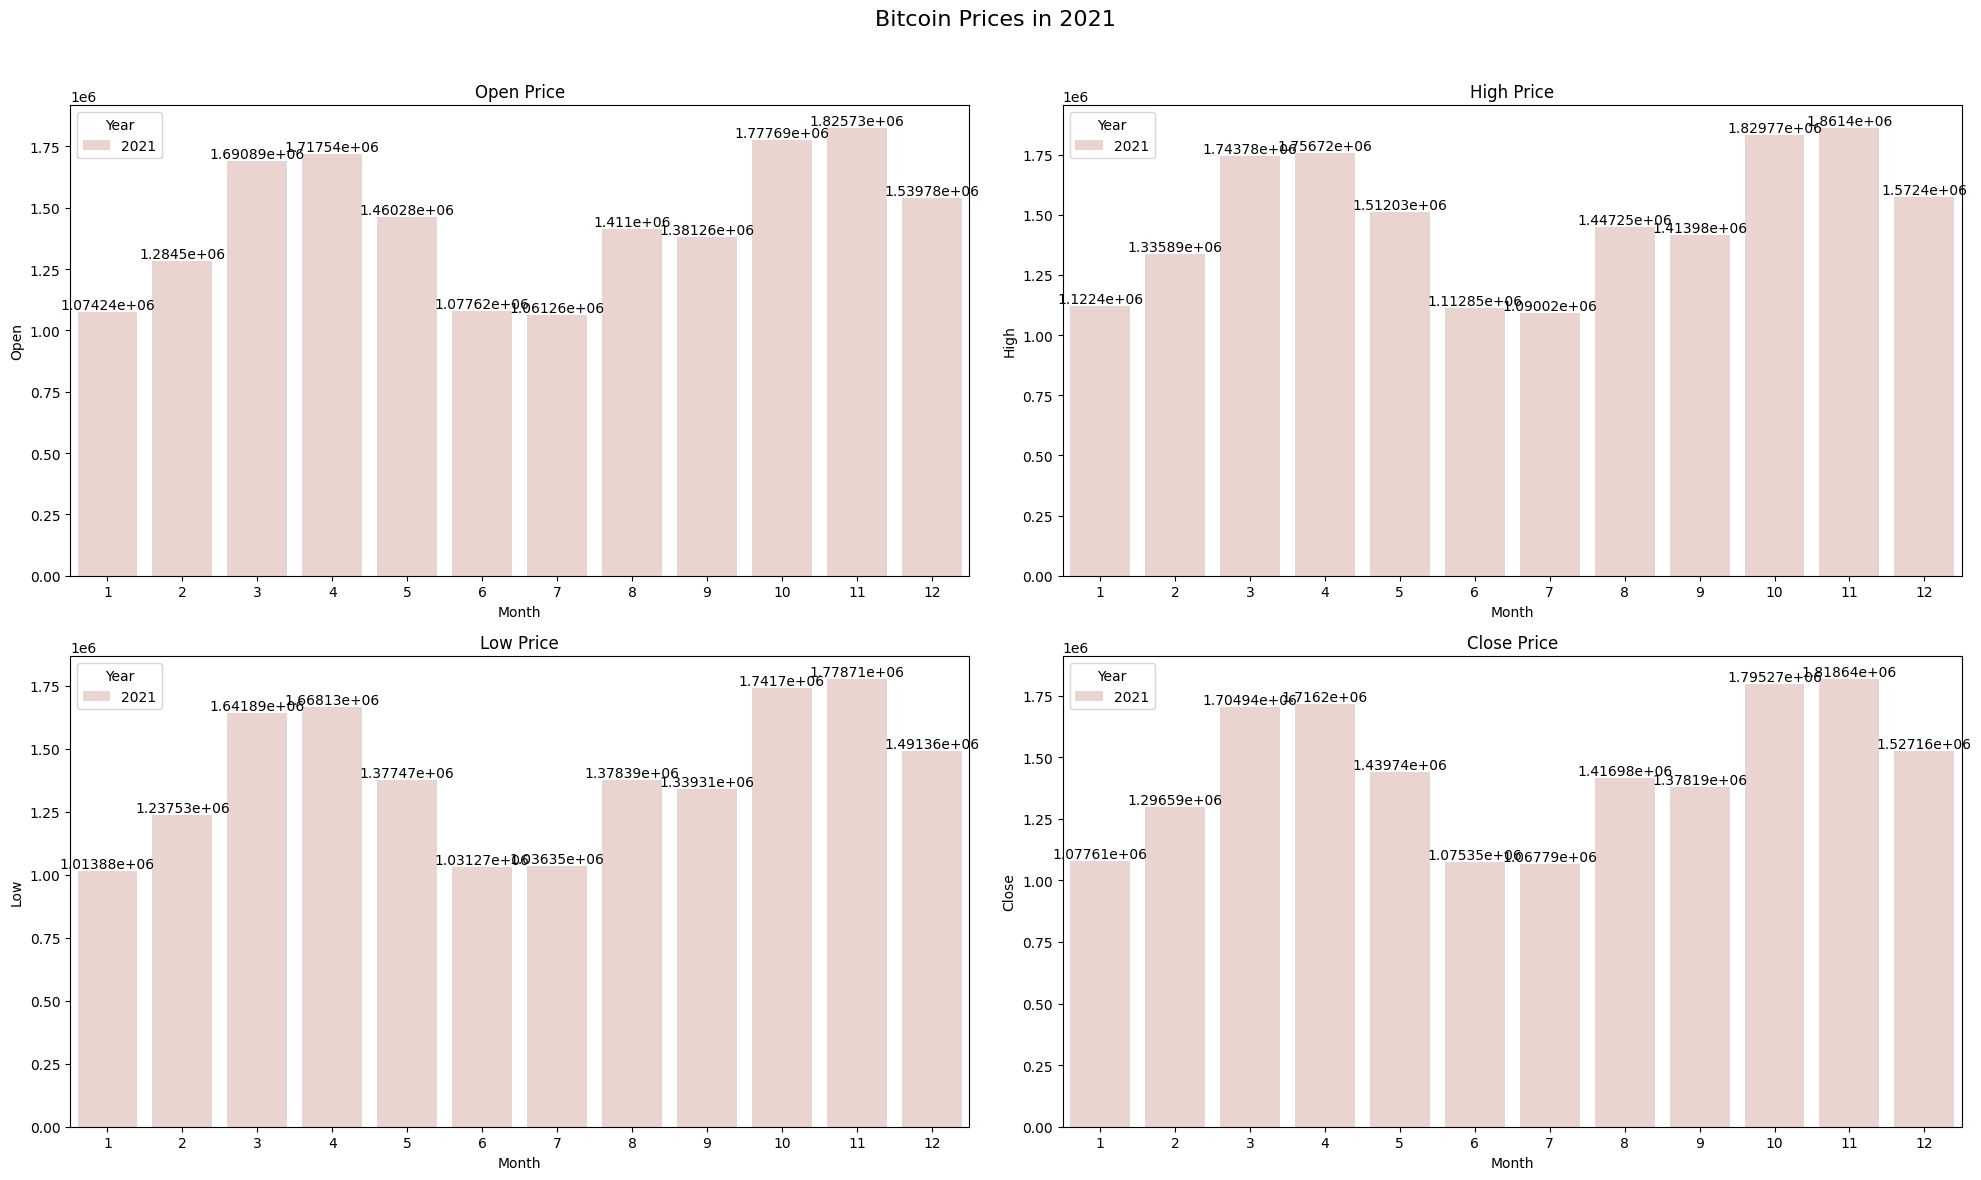

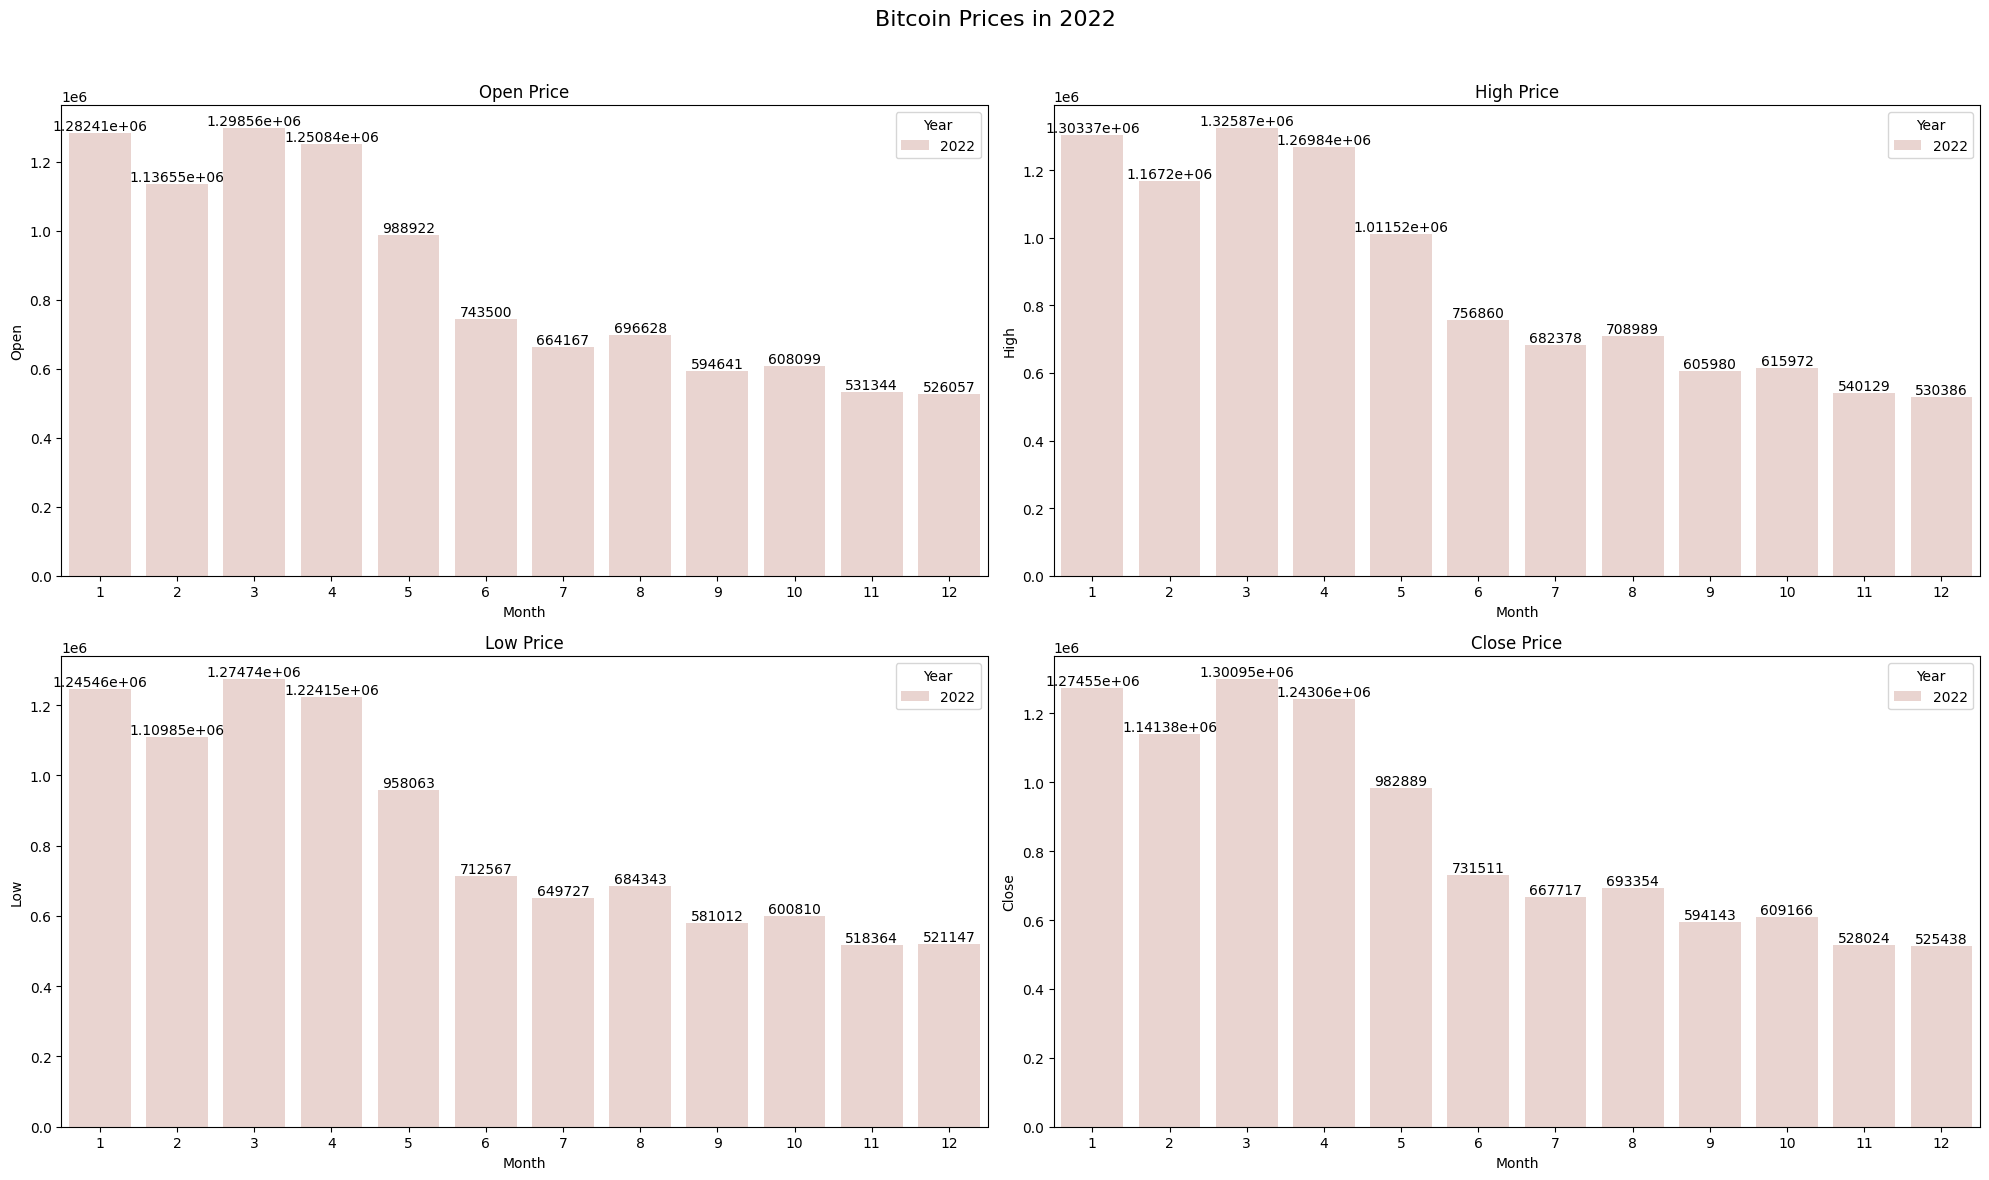

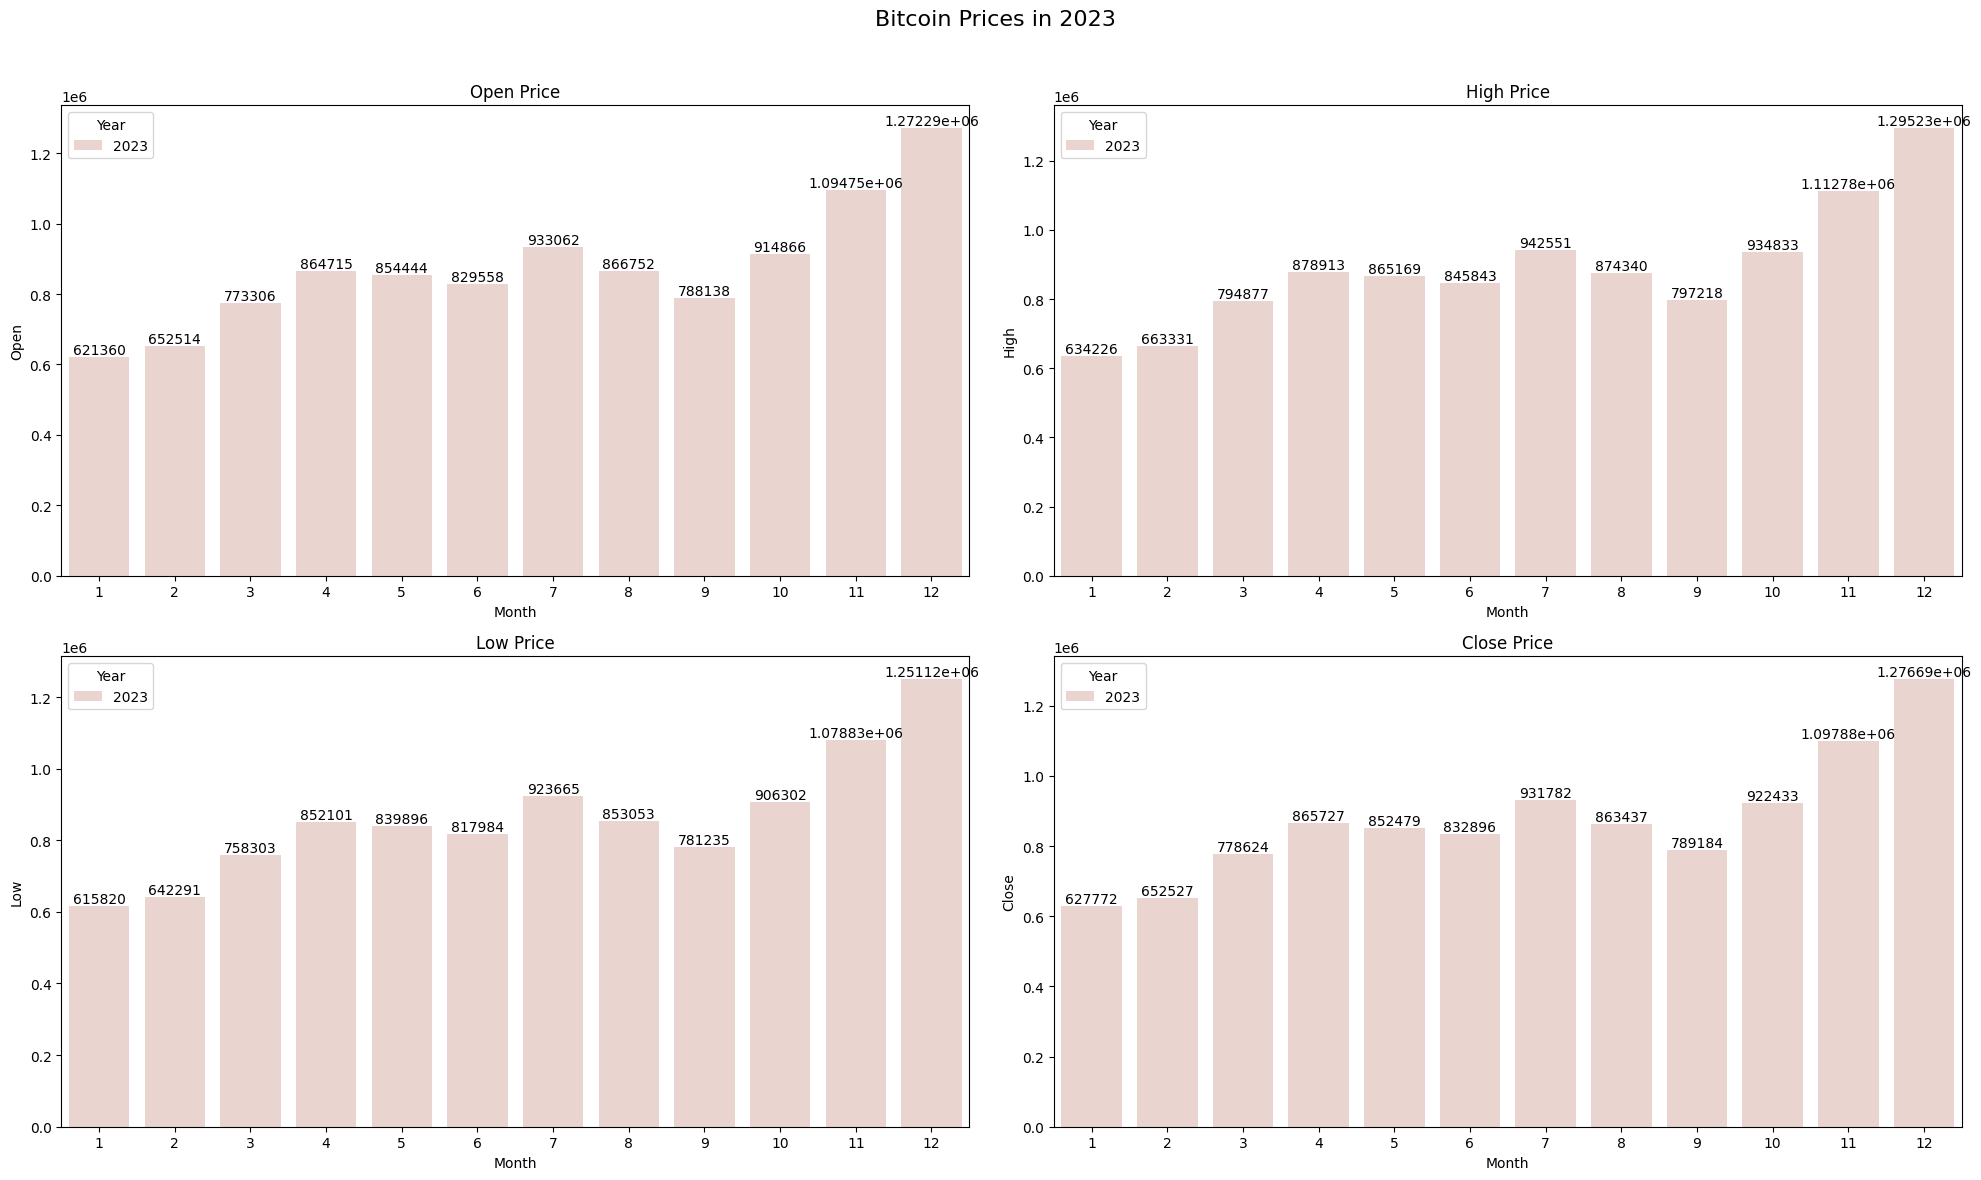

In [ ]:
columns = ['Open', 'High', 'Low', 'Close']

for i in range(2014, 2024):
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))  # 2x2 grid of subplots
    fig.suptitle(f'Bitcoin Prices in {i}', fontsize=16)

    for j, ax in enumerate(axes.flatten()):
        sns.barplot(data=bitcoin_df[bitcoin_df['Year'] == i], x='Month', y=columns[j], hue='Year', ax=ax, errorbar=None, estimator="sum")
        ax.set_title(f'{columns[j]} Price')
        ax.bar_label(ax.containers[0], fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit titles
    plt.show()

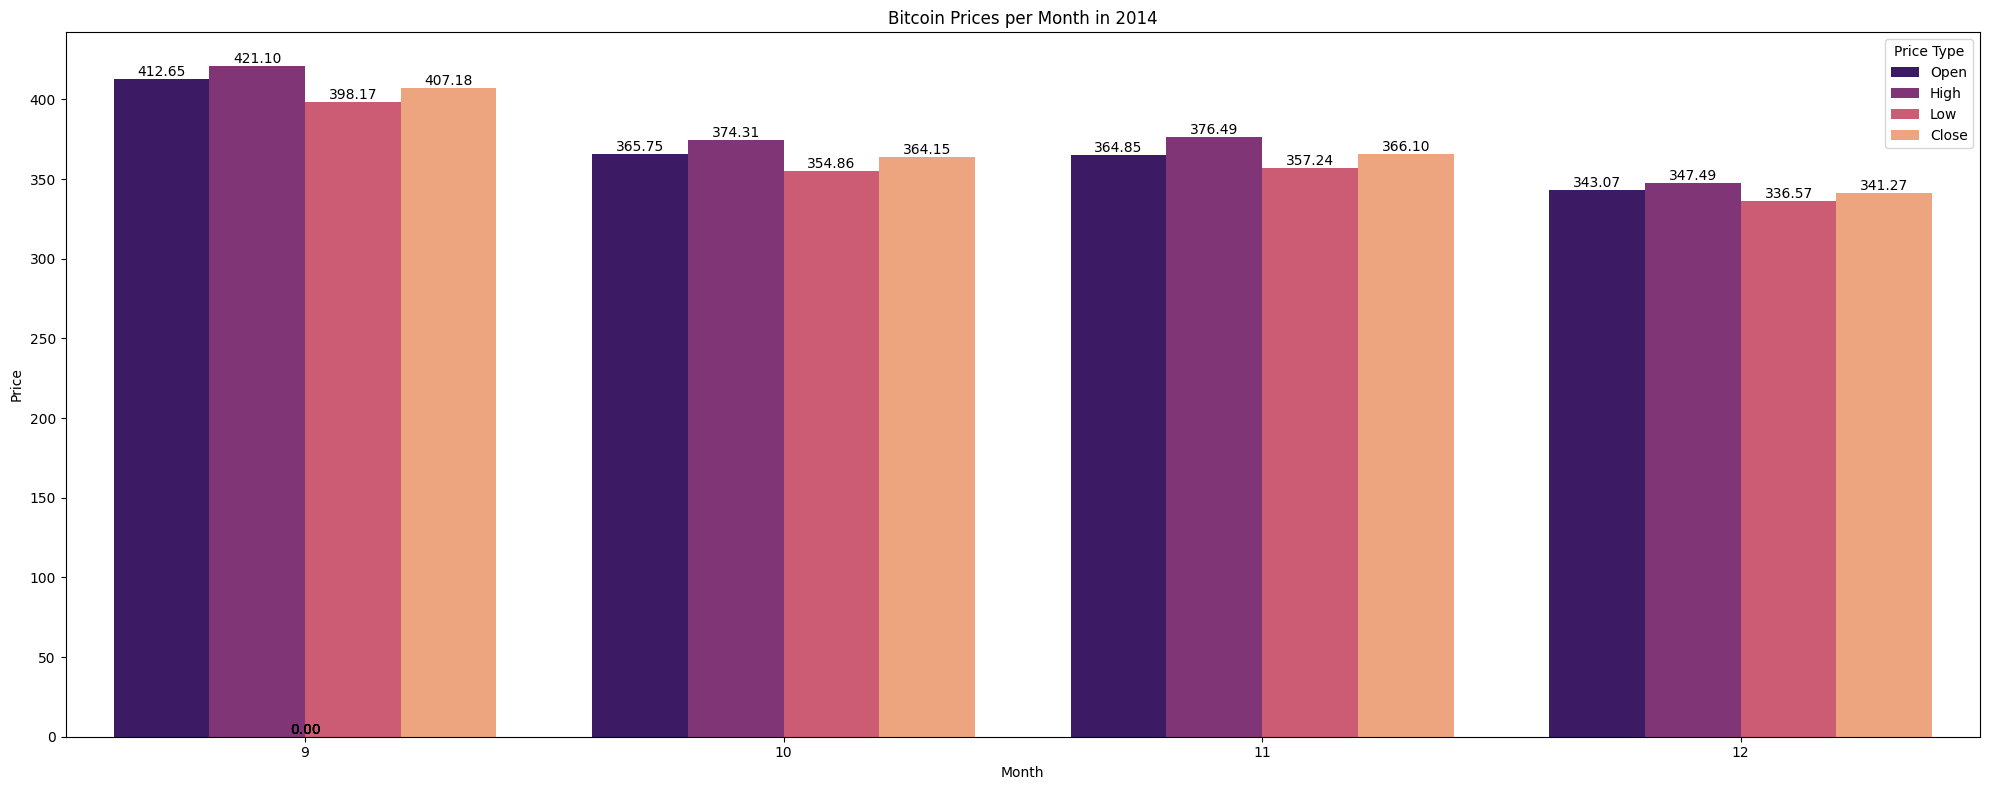

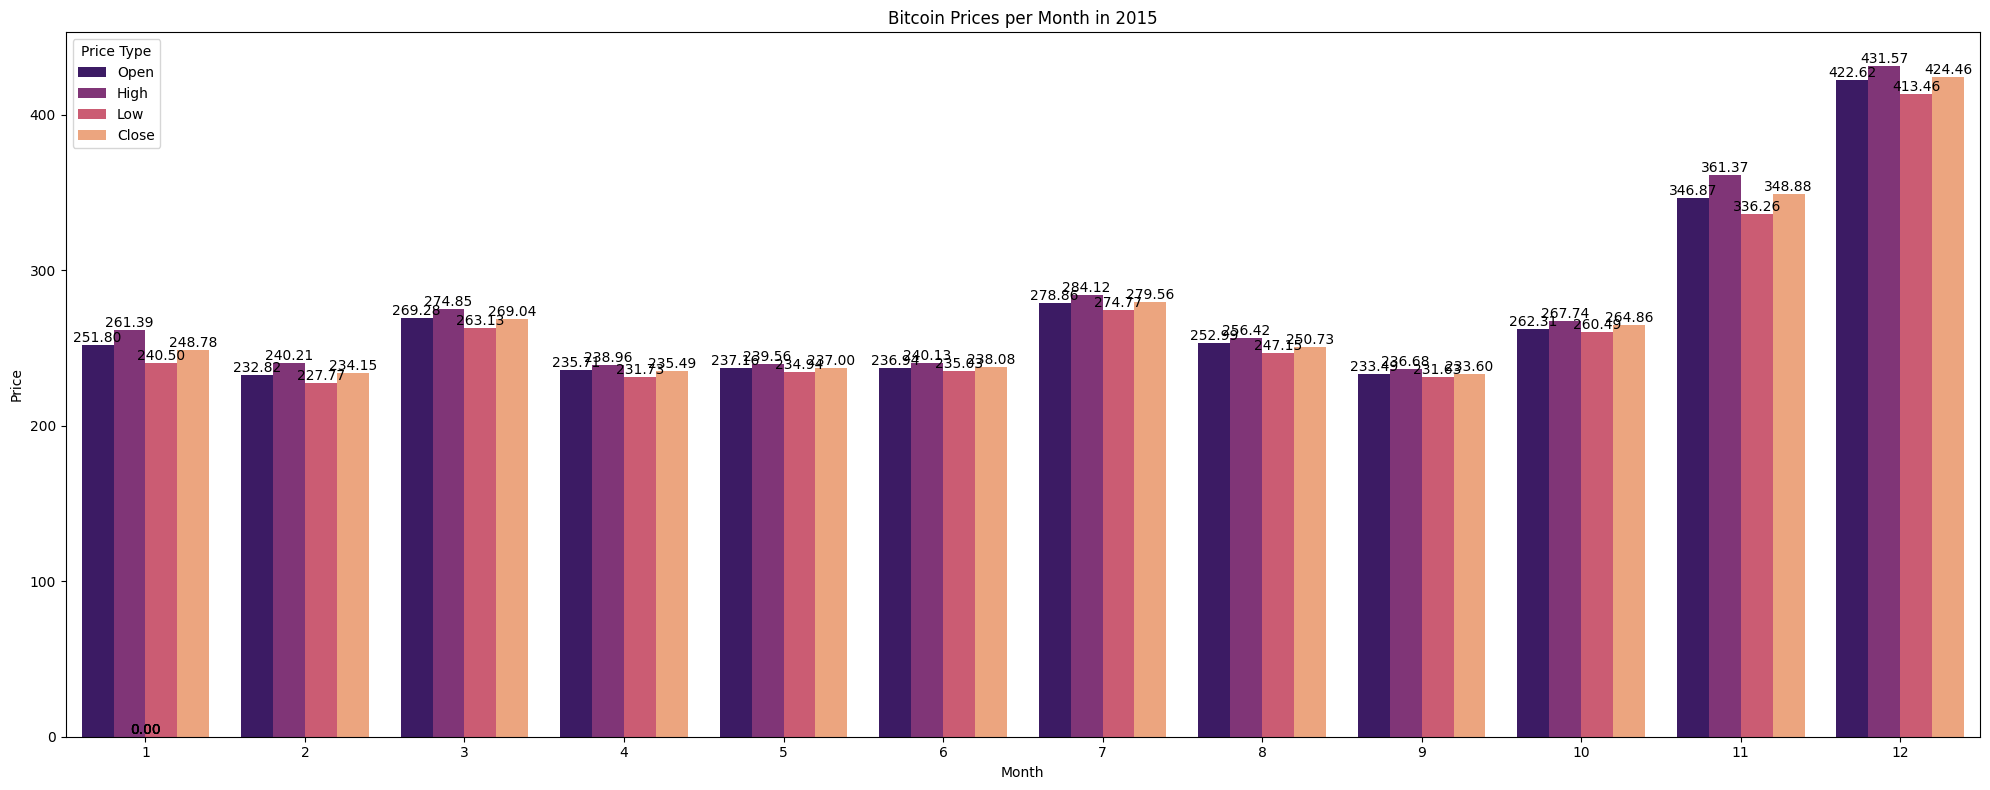

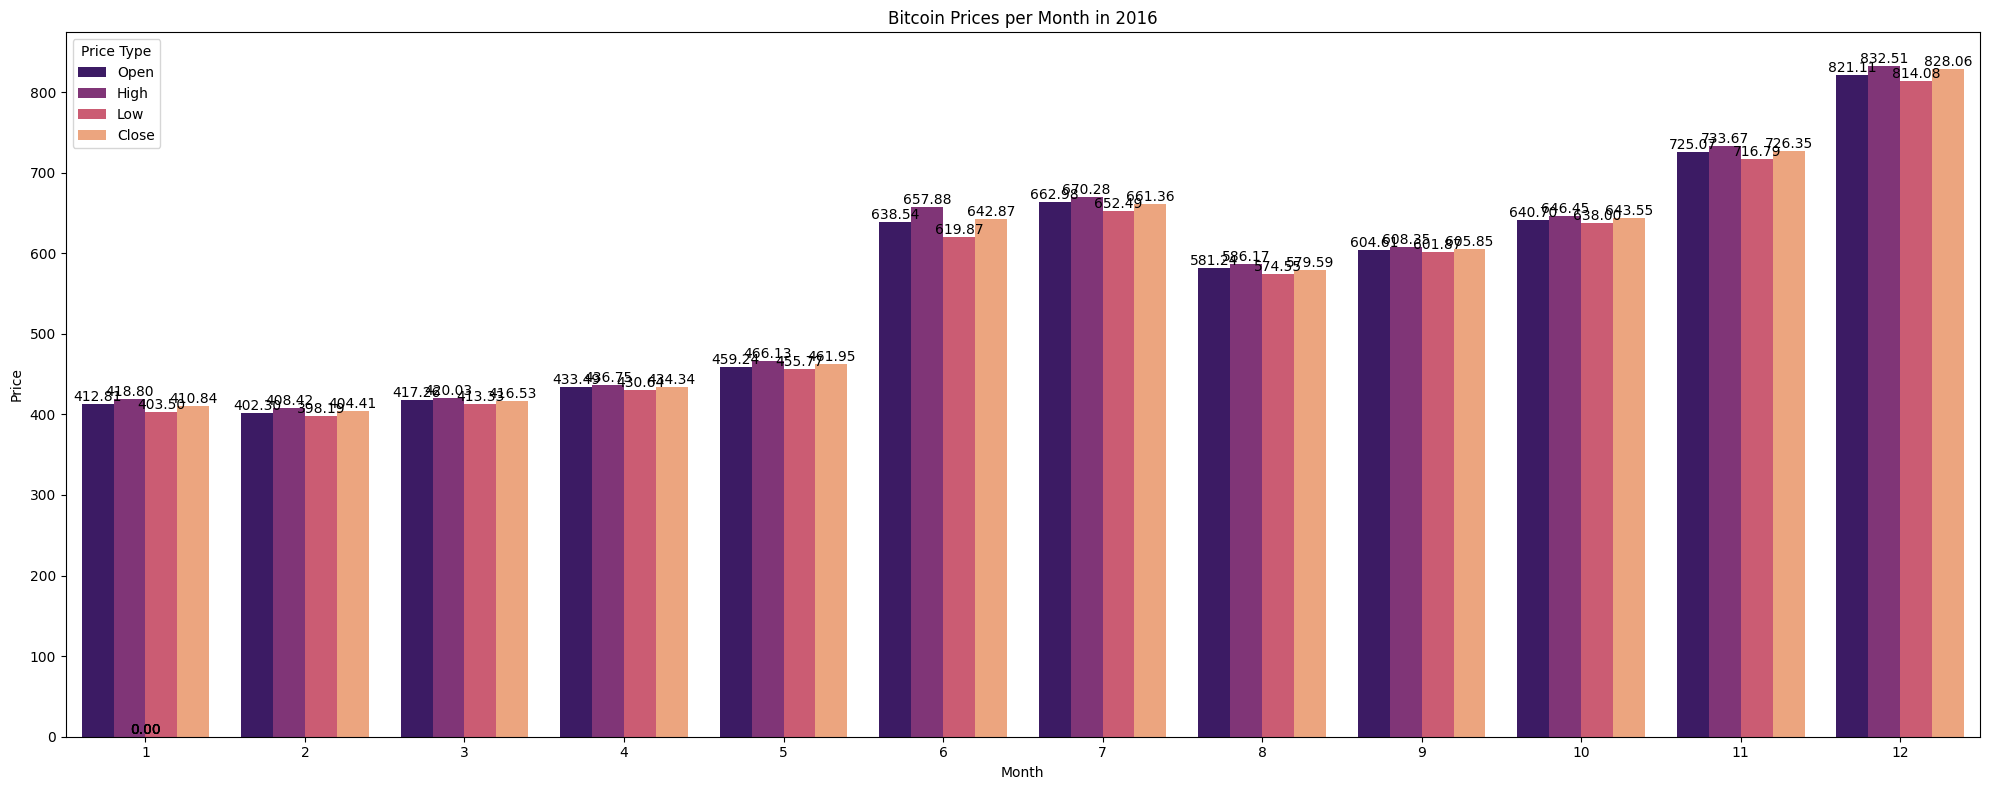

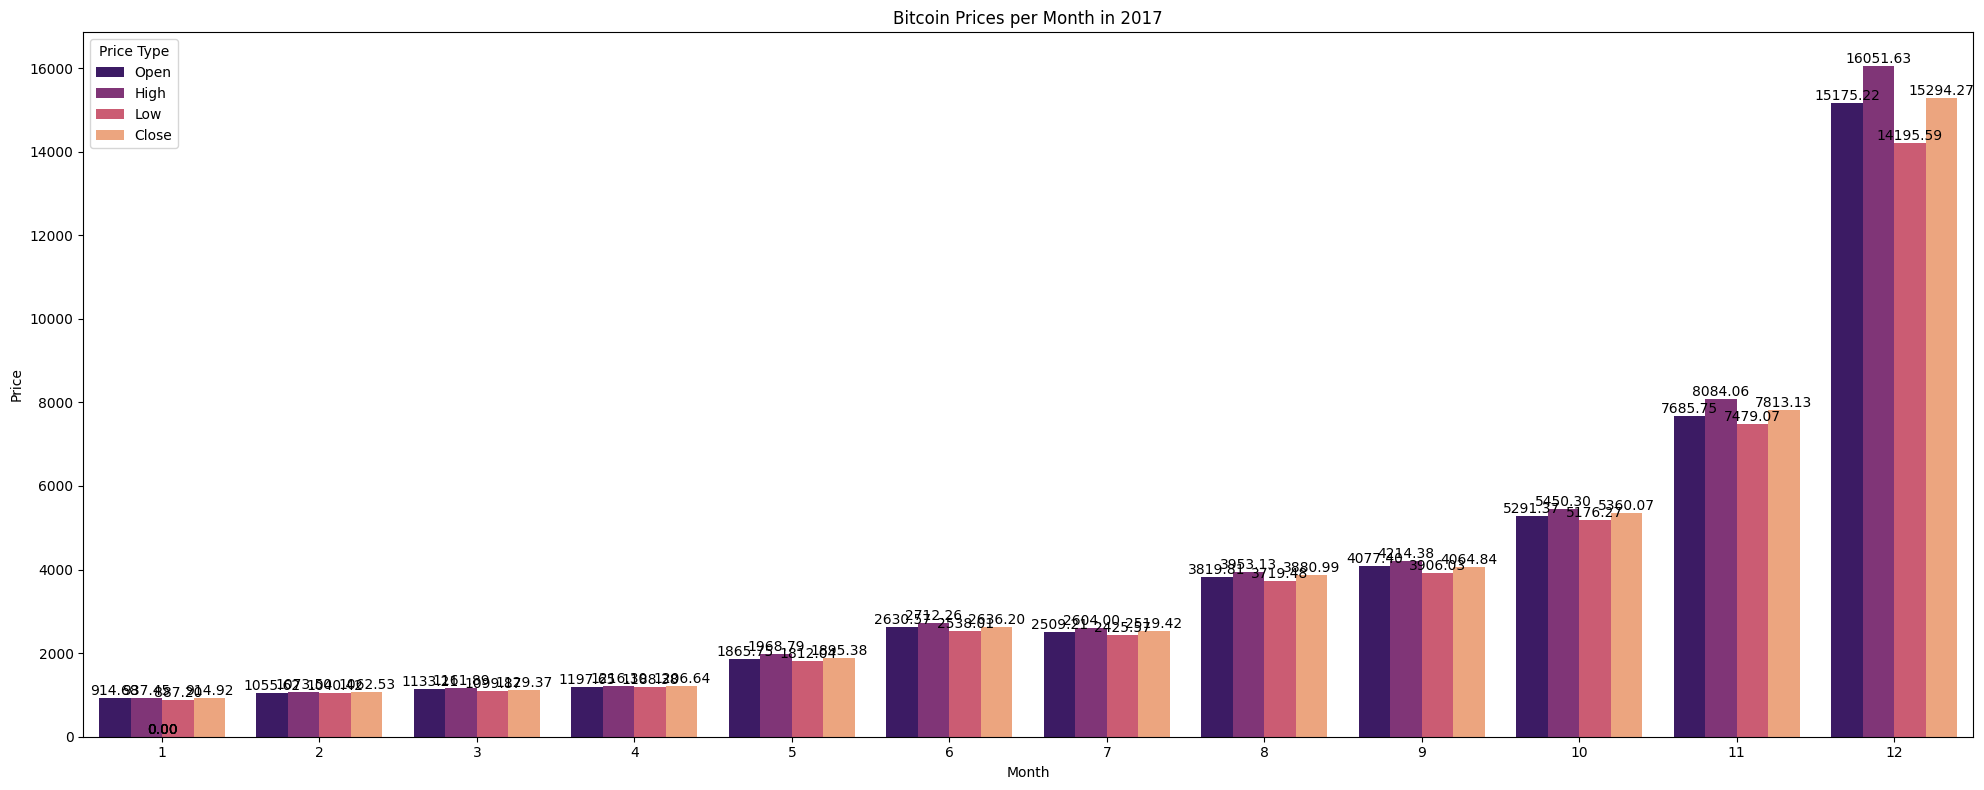

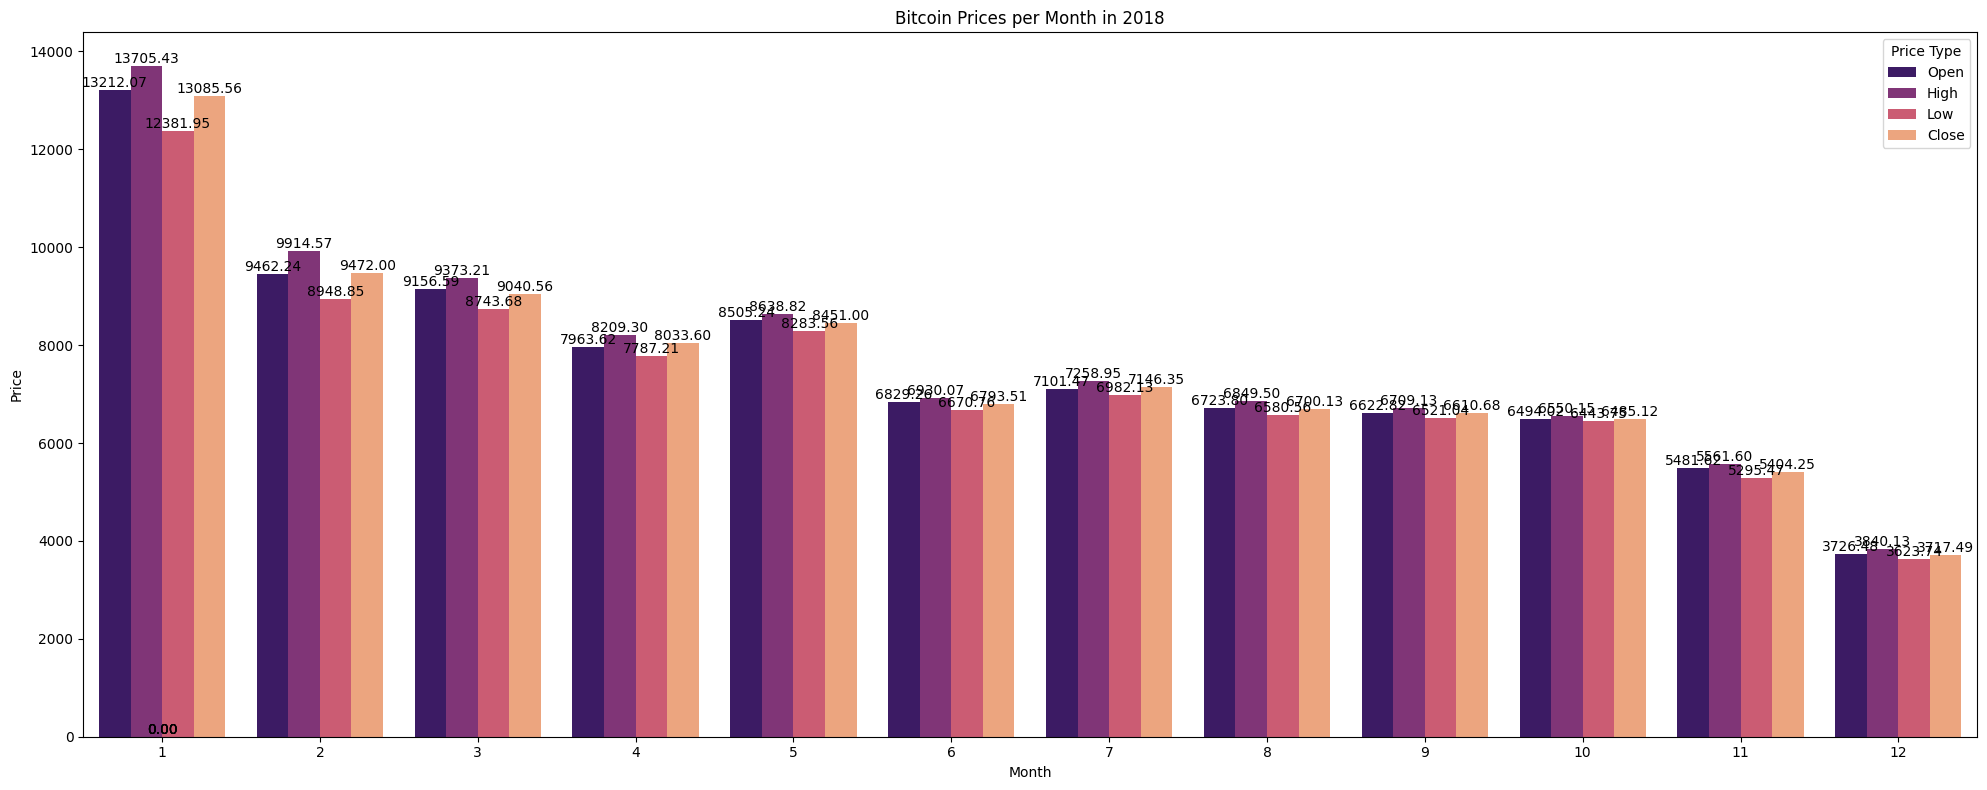

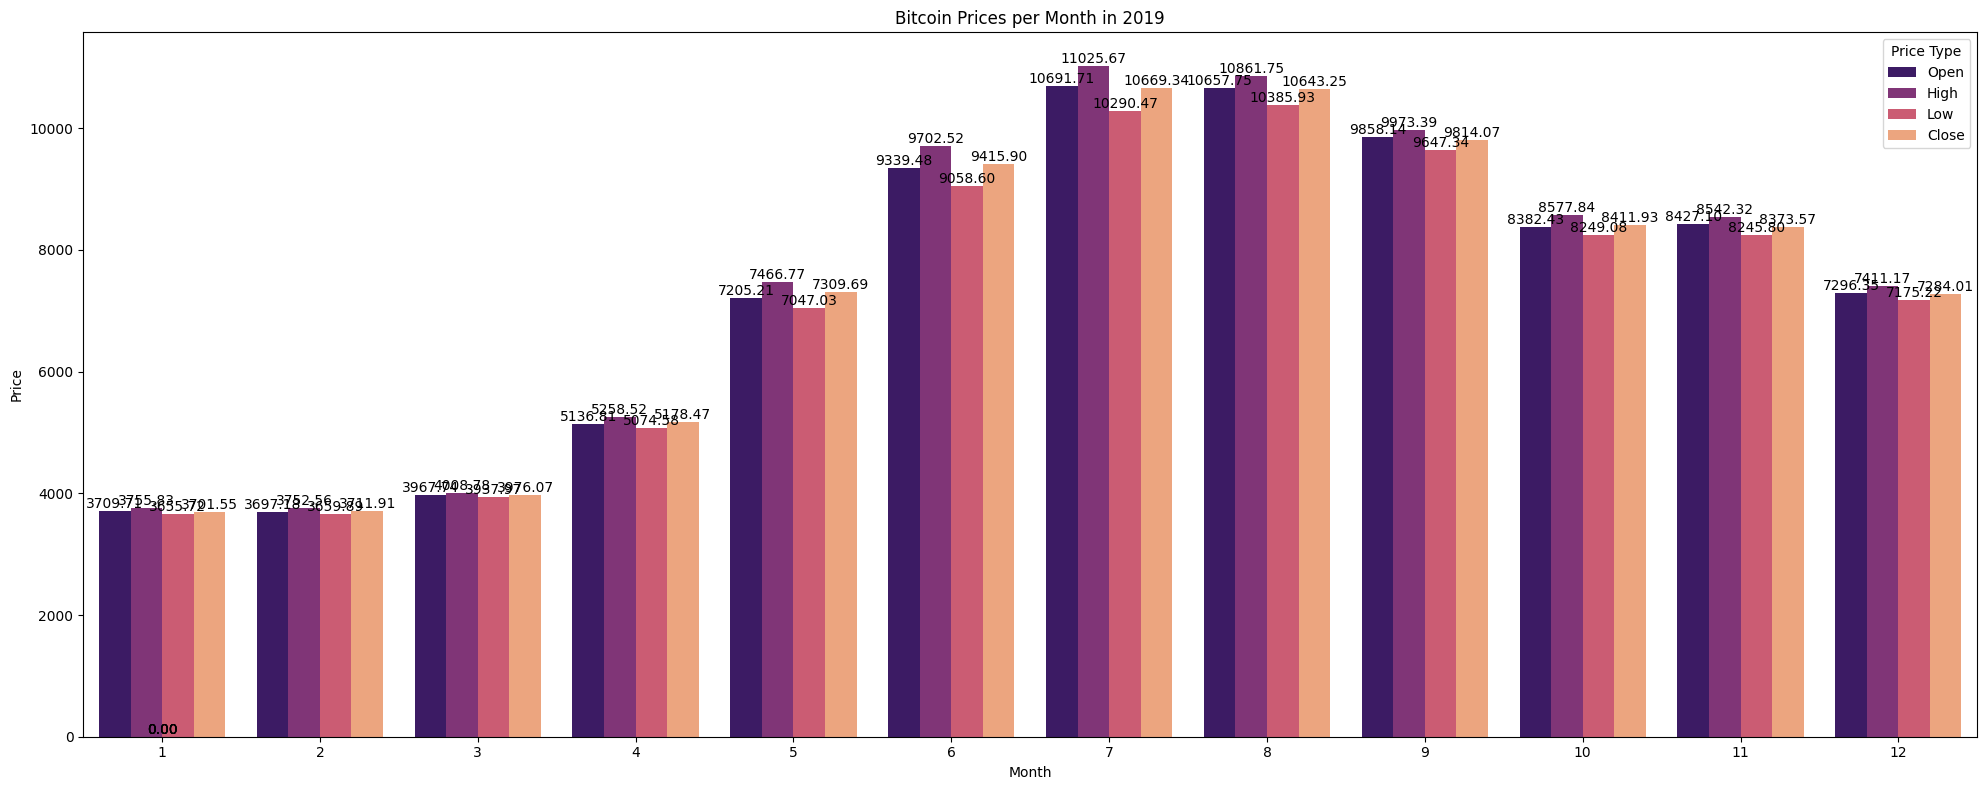

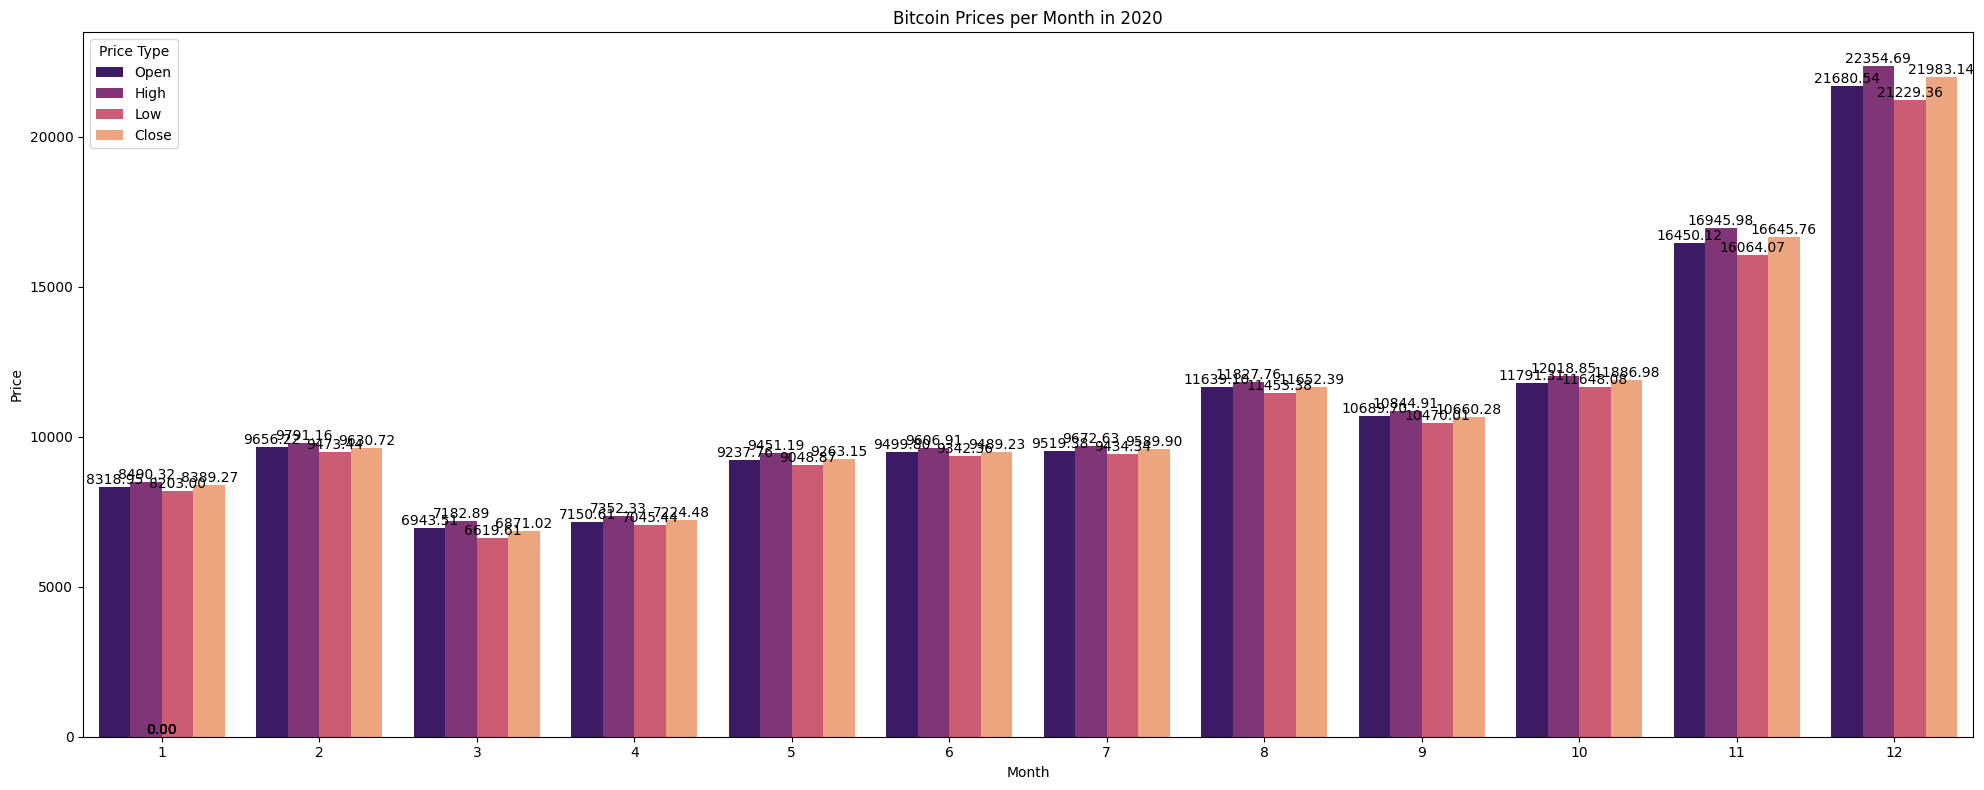

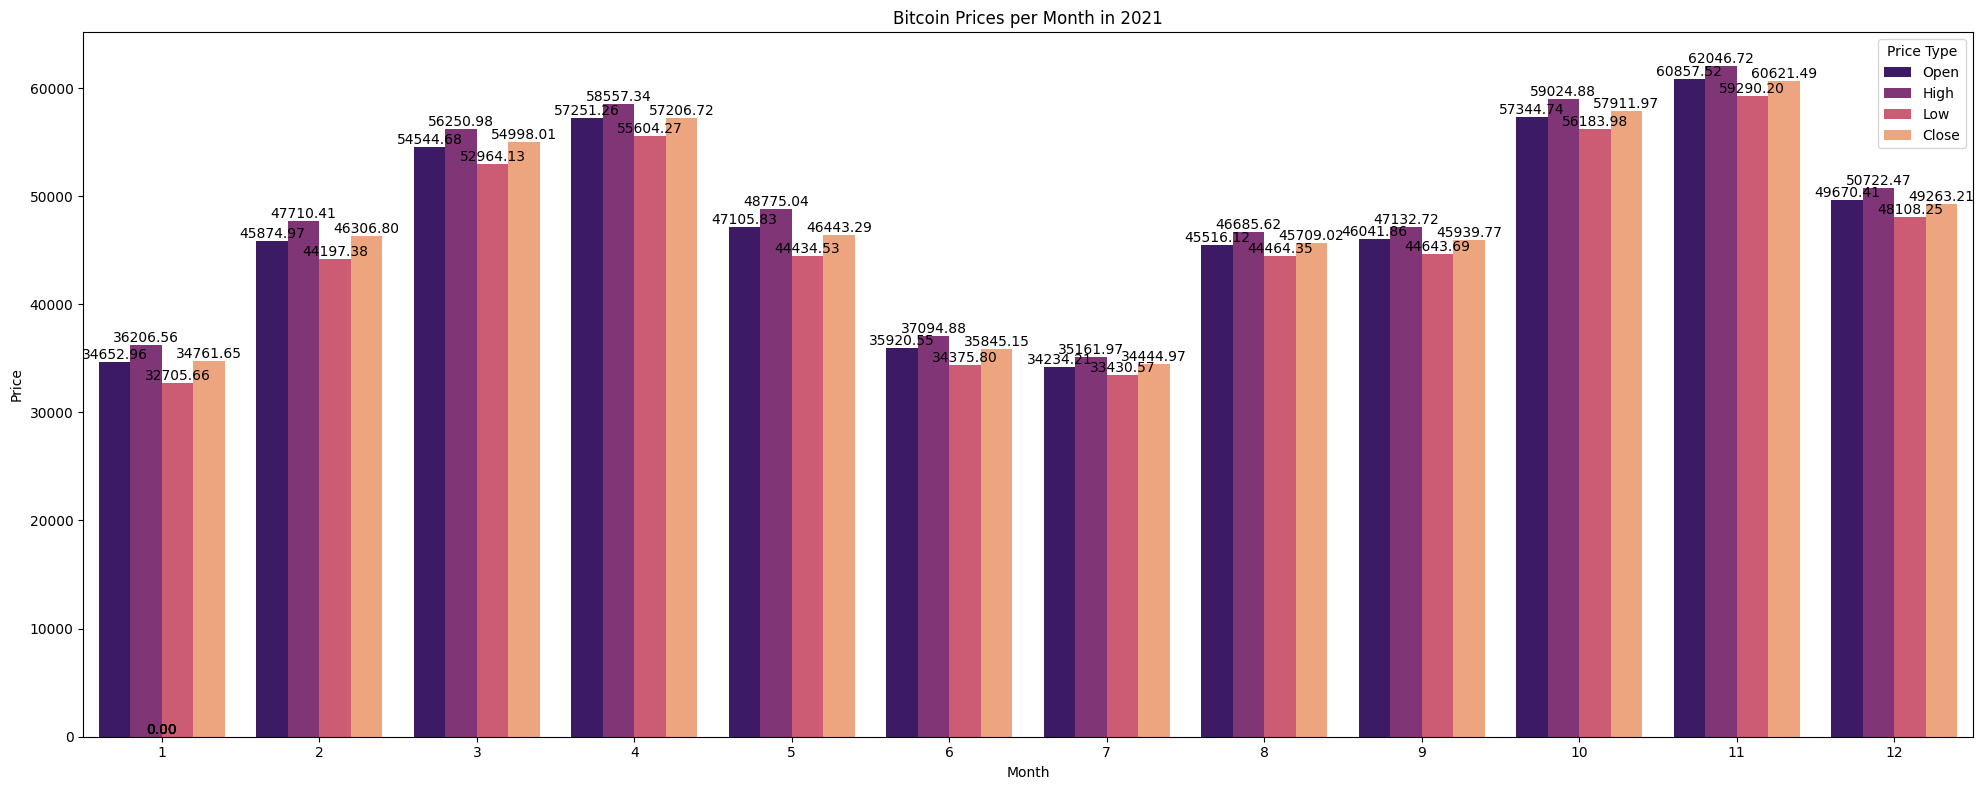

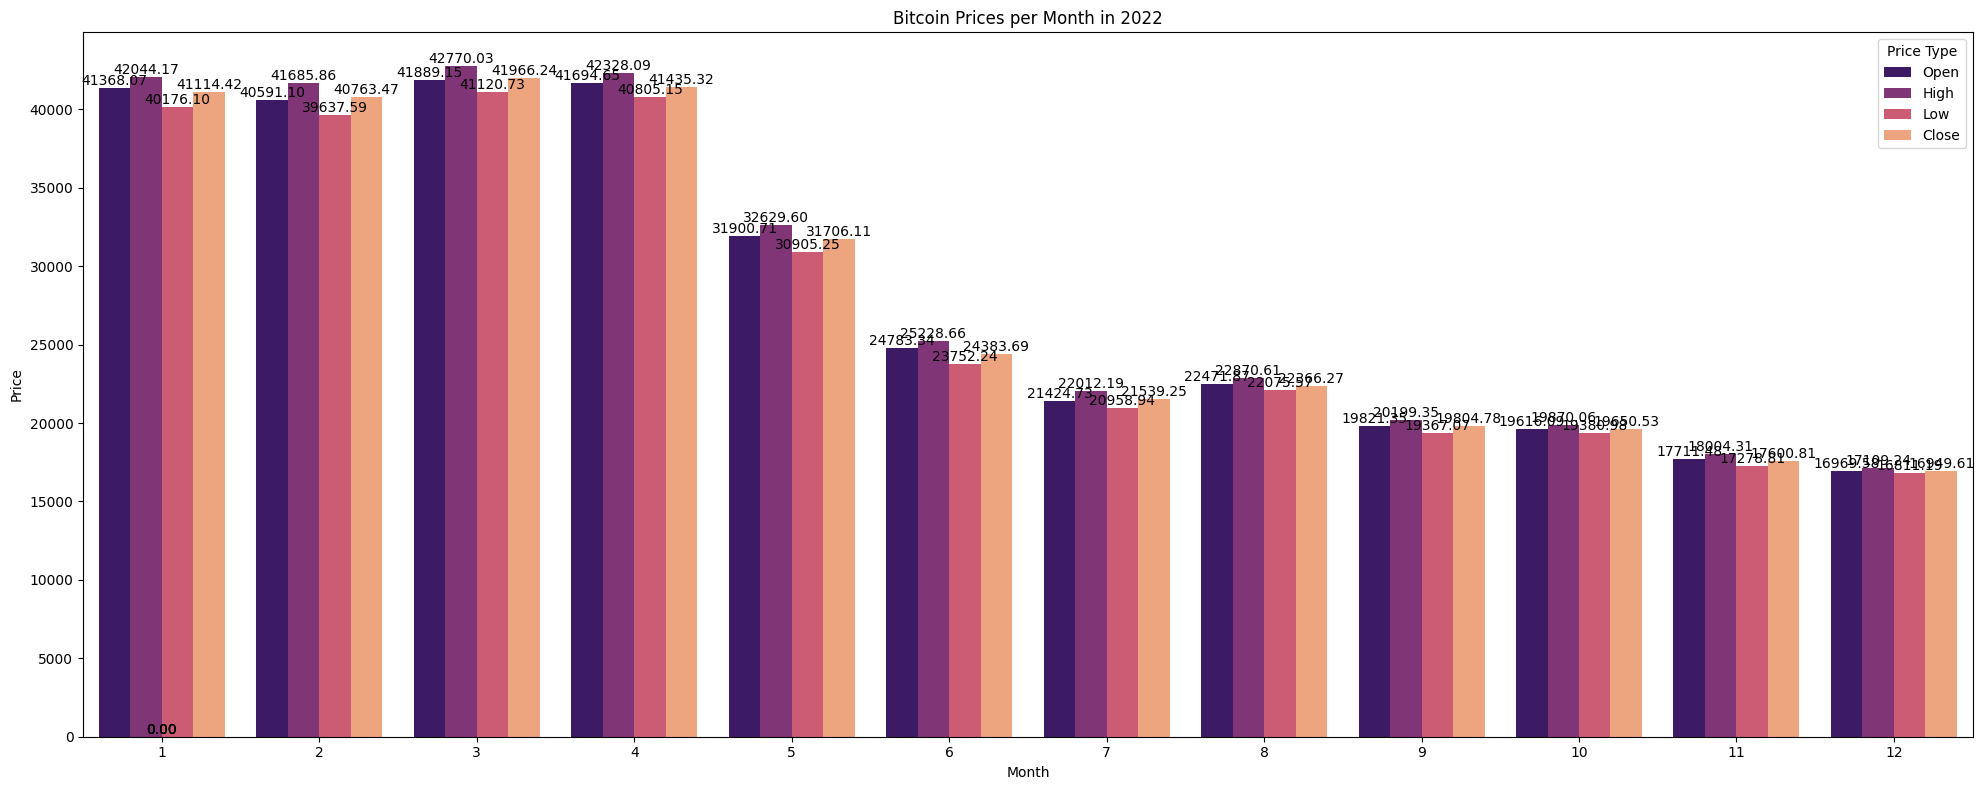

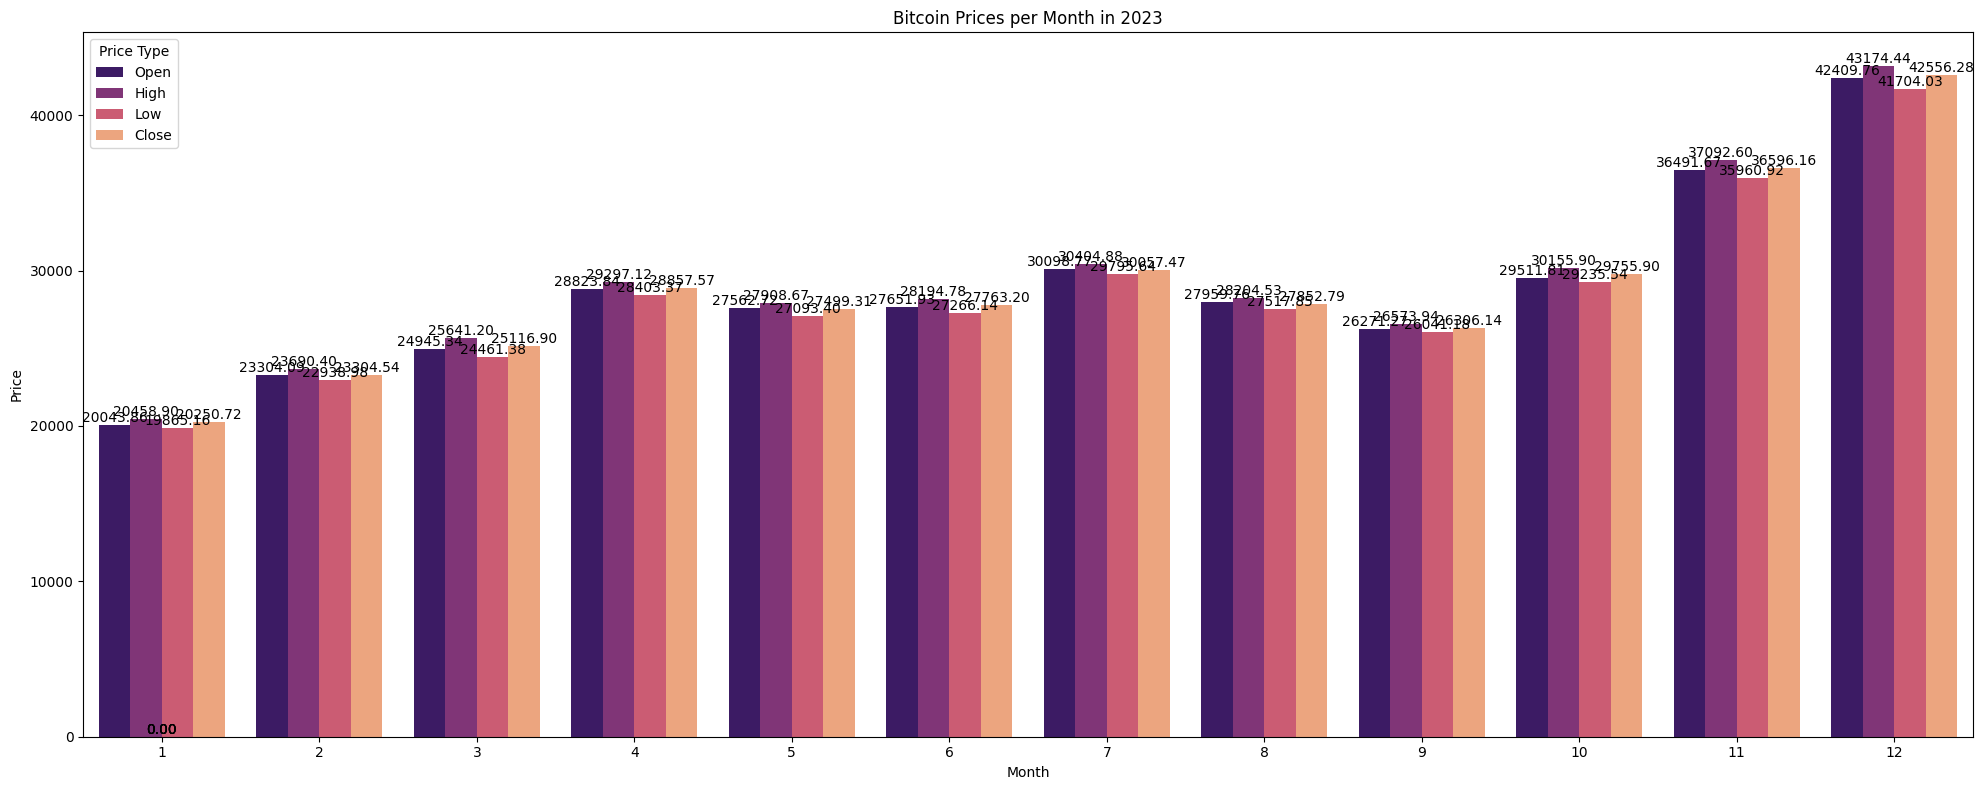

In [ ]:
columns = ['Open', 'High', 'Low', 'Close']

for i in range(2014, 2024):
    plt.figure(figsize=(20,8))
    df_year = bitcoin_df[bitcoin_df['Year'] == i]

    df_melted = df_year.melt(id_vars=['Month'], value_vars=columns,
                             var_name='Price Type', value_name='Value')

    ax = sns.barplot(data=df_melted, x='Month', y='Value', hue='Price Type', palette='magma', errorbar=None)

    # Add bar labels on top
    for bar in ax.patches:
        height = bar.get_height()
        if not pd.isna(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=10,
                color='black'
            )

    plt.title(f'Bitcoin Prices per Month in {i}')
    plt.xlabel('Month')
    plt.ylabel('Price')
    plt.legend(title='Price Type')
    plt.tight_layout()
    plt.show()

In [ ]:
# take average of all columns
bitcoin_df['Avg'] = bitcoin_df['Open'] + bitcoin_df['High'] + bitcoin_df['Low'] + bitcoin_df['Close']
bitcoin_df.head()
bitcoin_df['Avg'] = bitcoin_df['Avg']/4
bitcoin_df.head()

,Open,High,Low,Close,Adj Close,Volume,Year,Month,Avg
Date,,,,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800,2014,9,460.948509
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200,2014,9,437.815994
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700,2014,9,407.816498
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600,2014,9,404.188995
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100,2014,9,403.128250


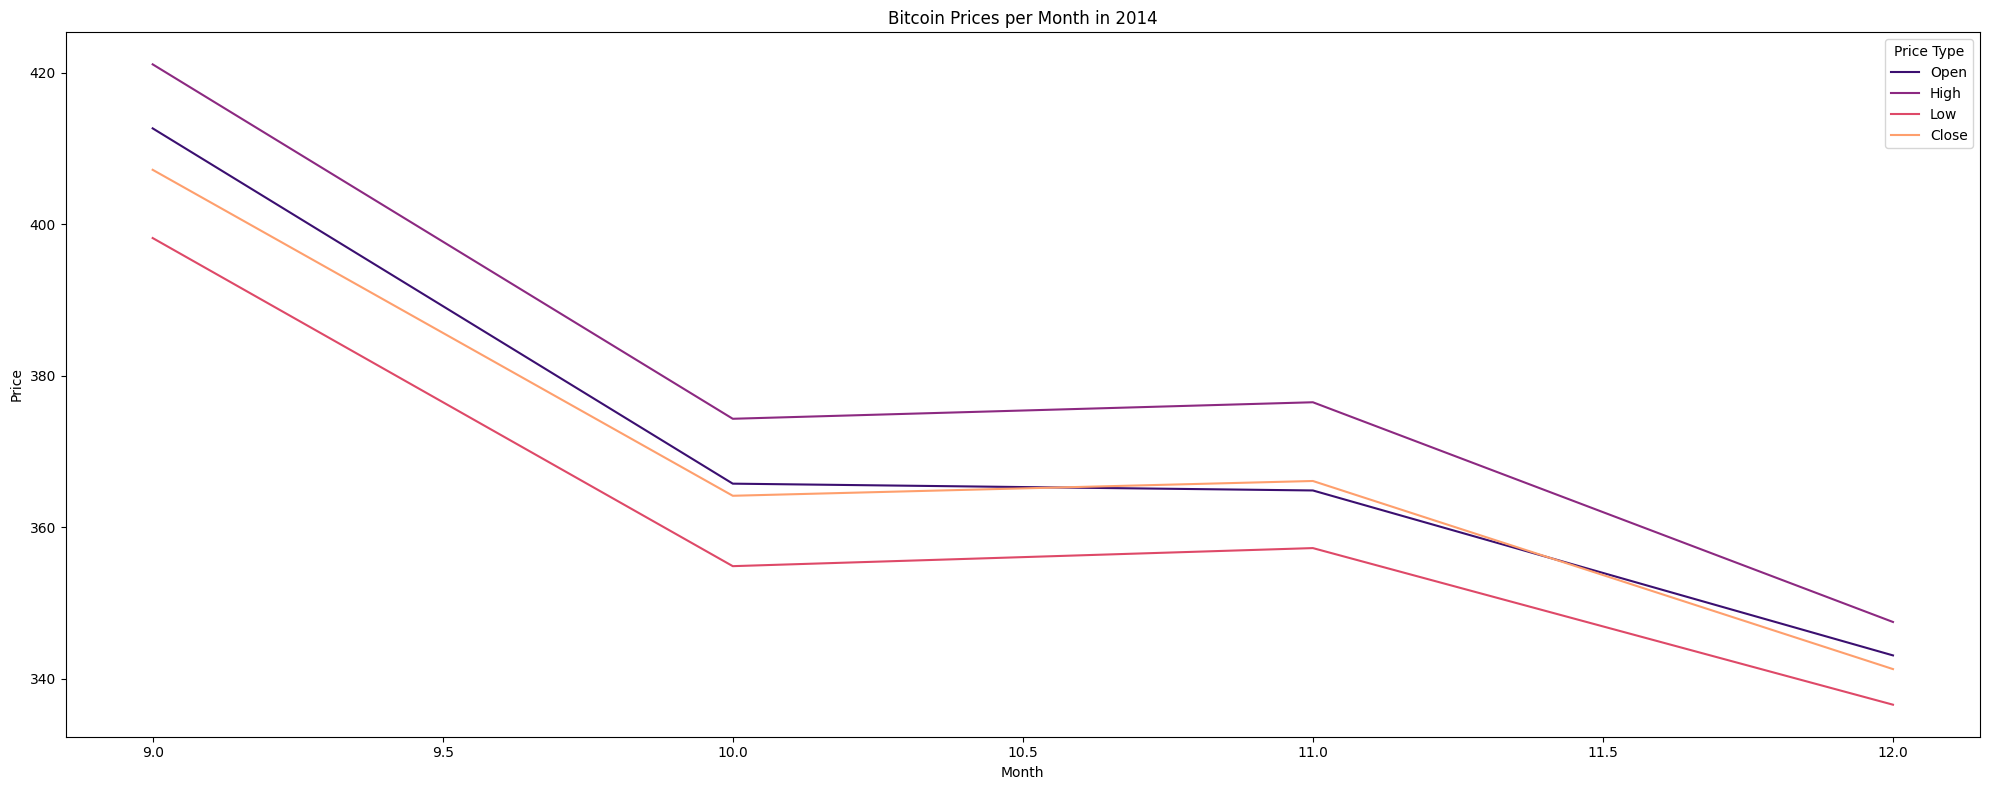

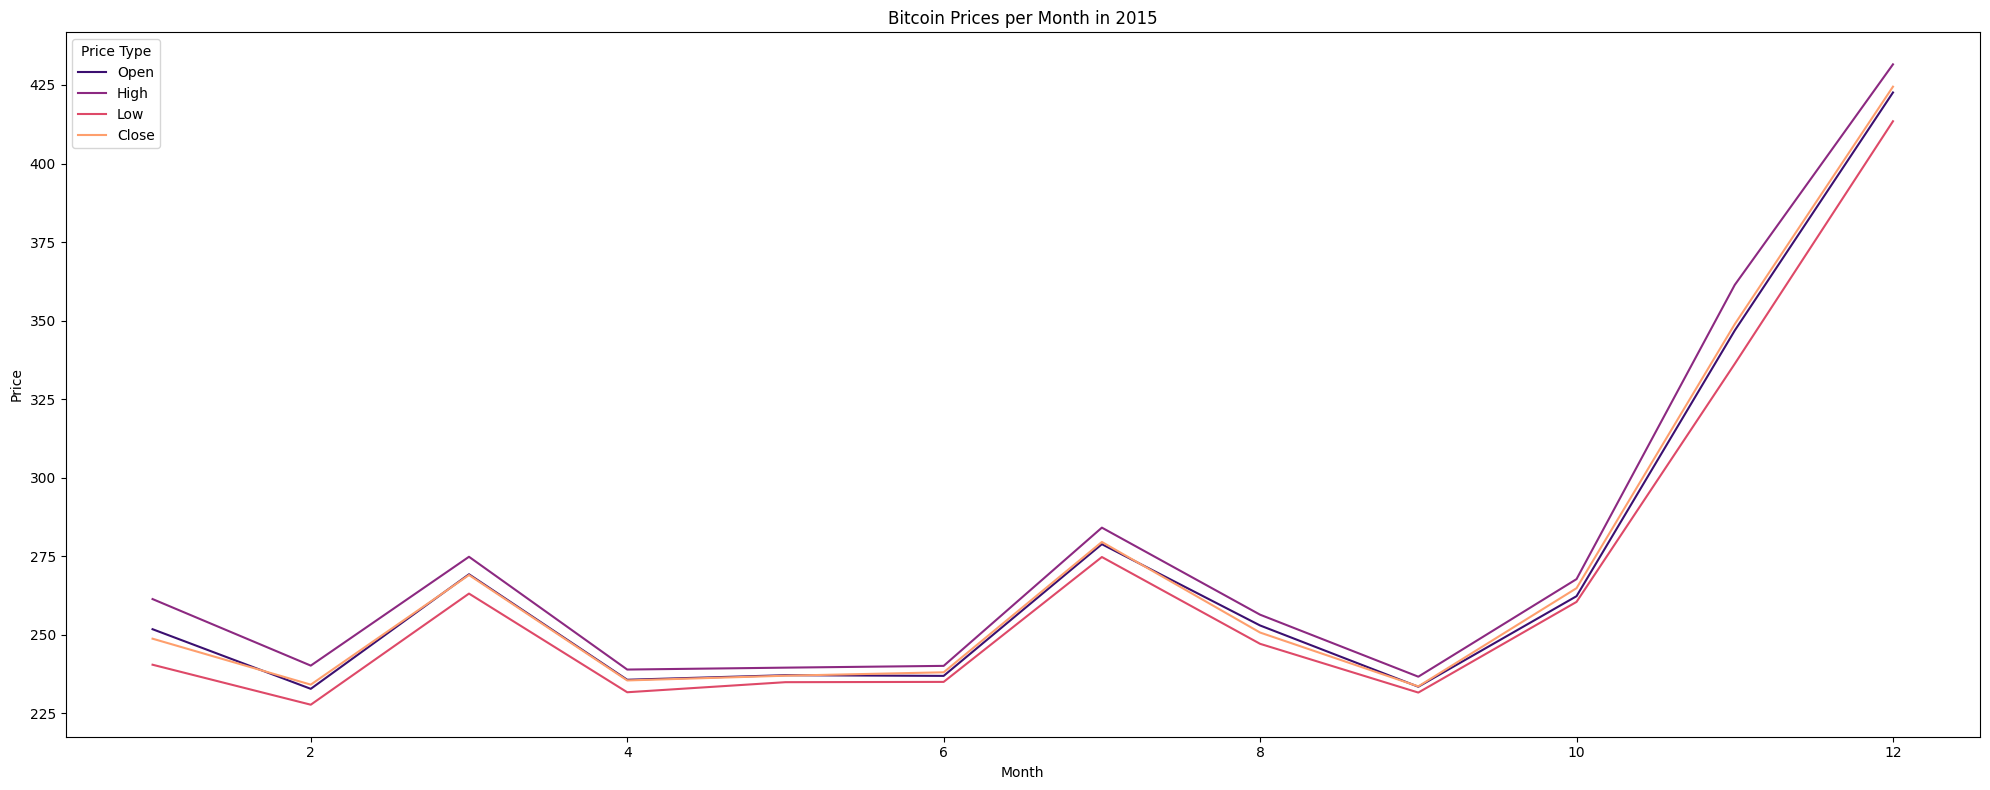

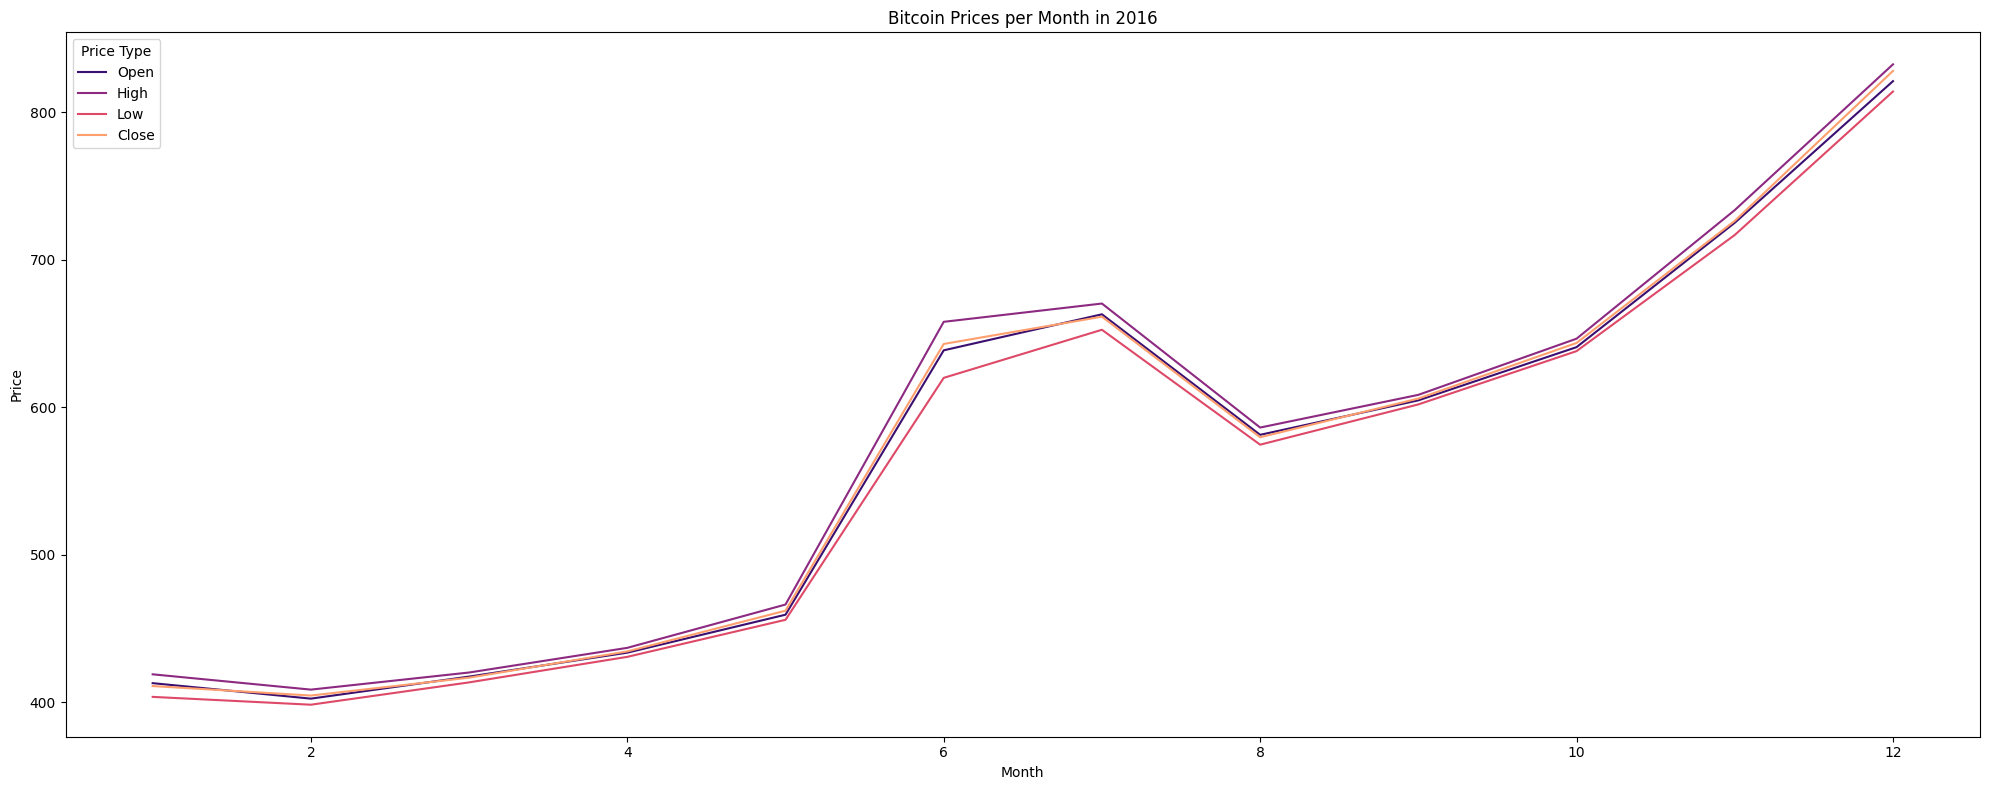

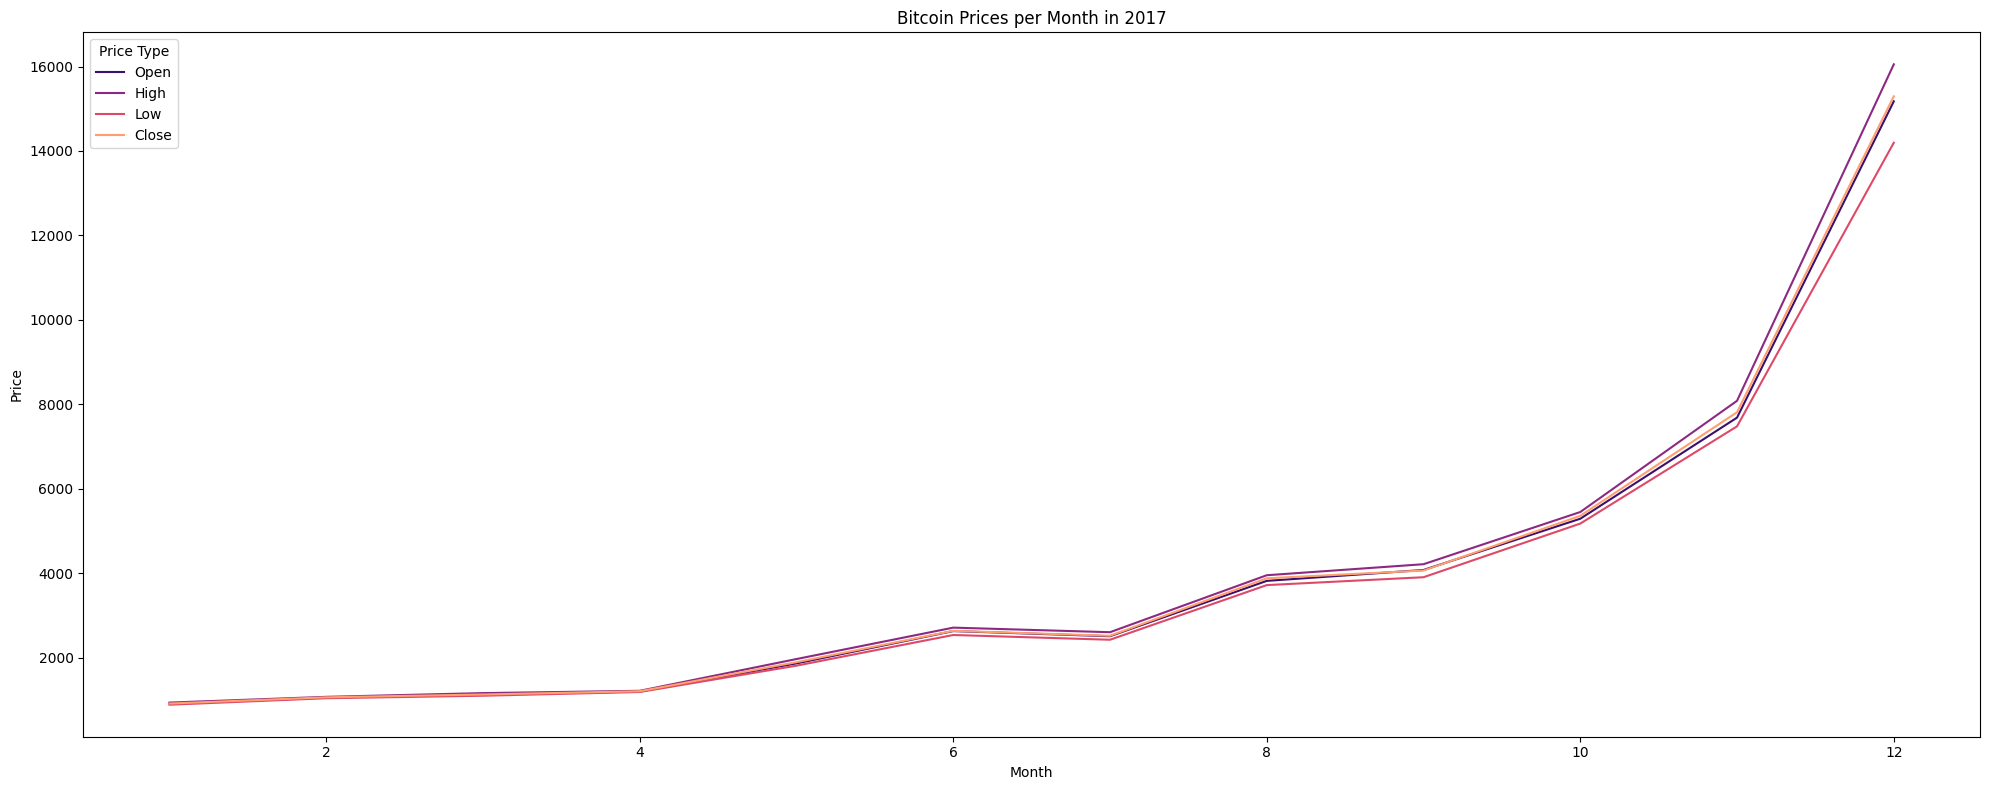

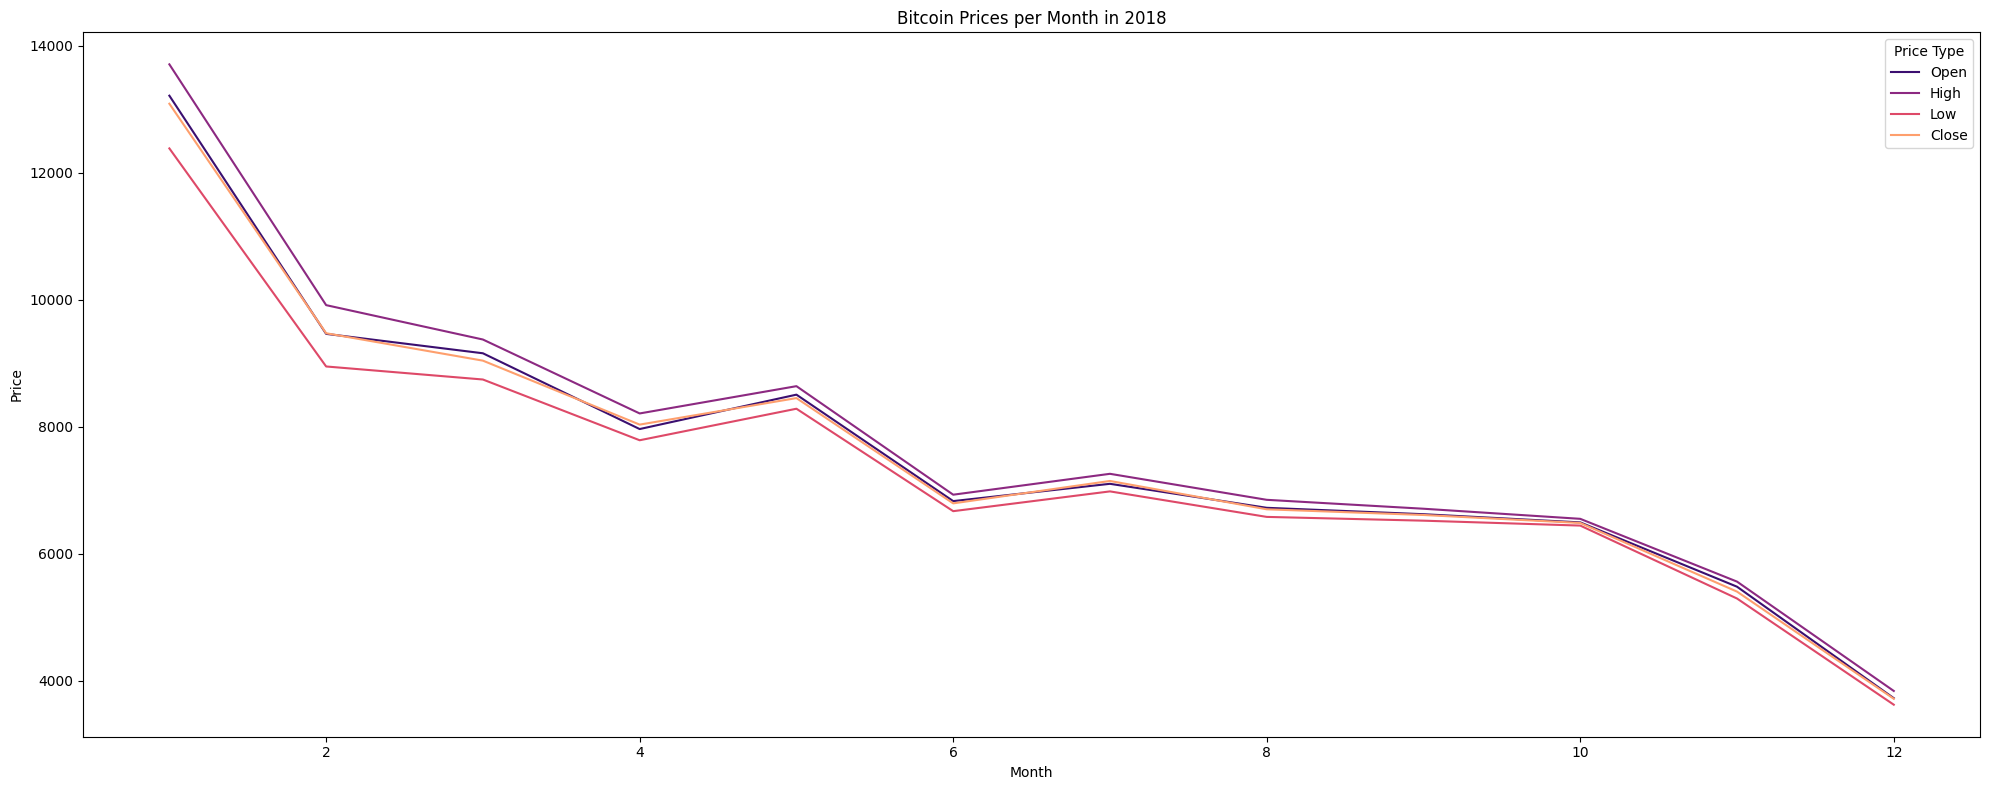

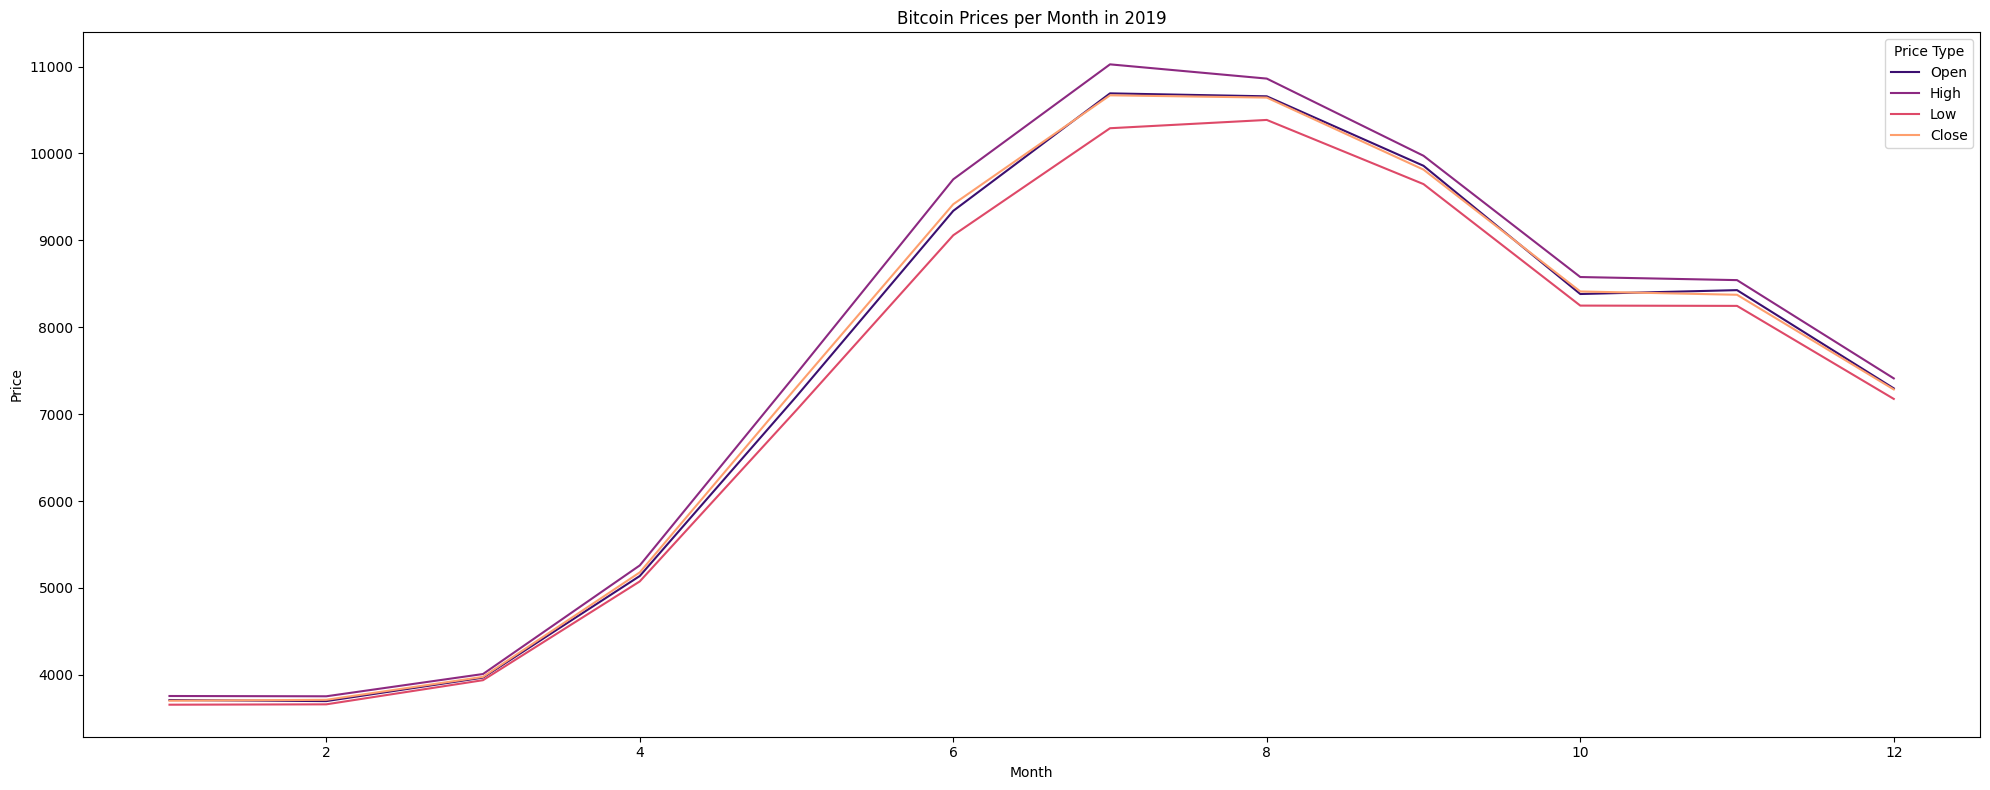

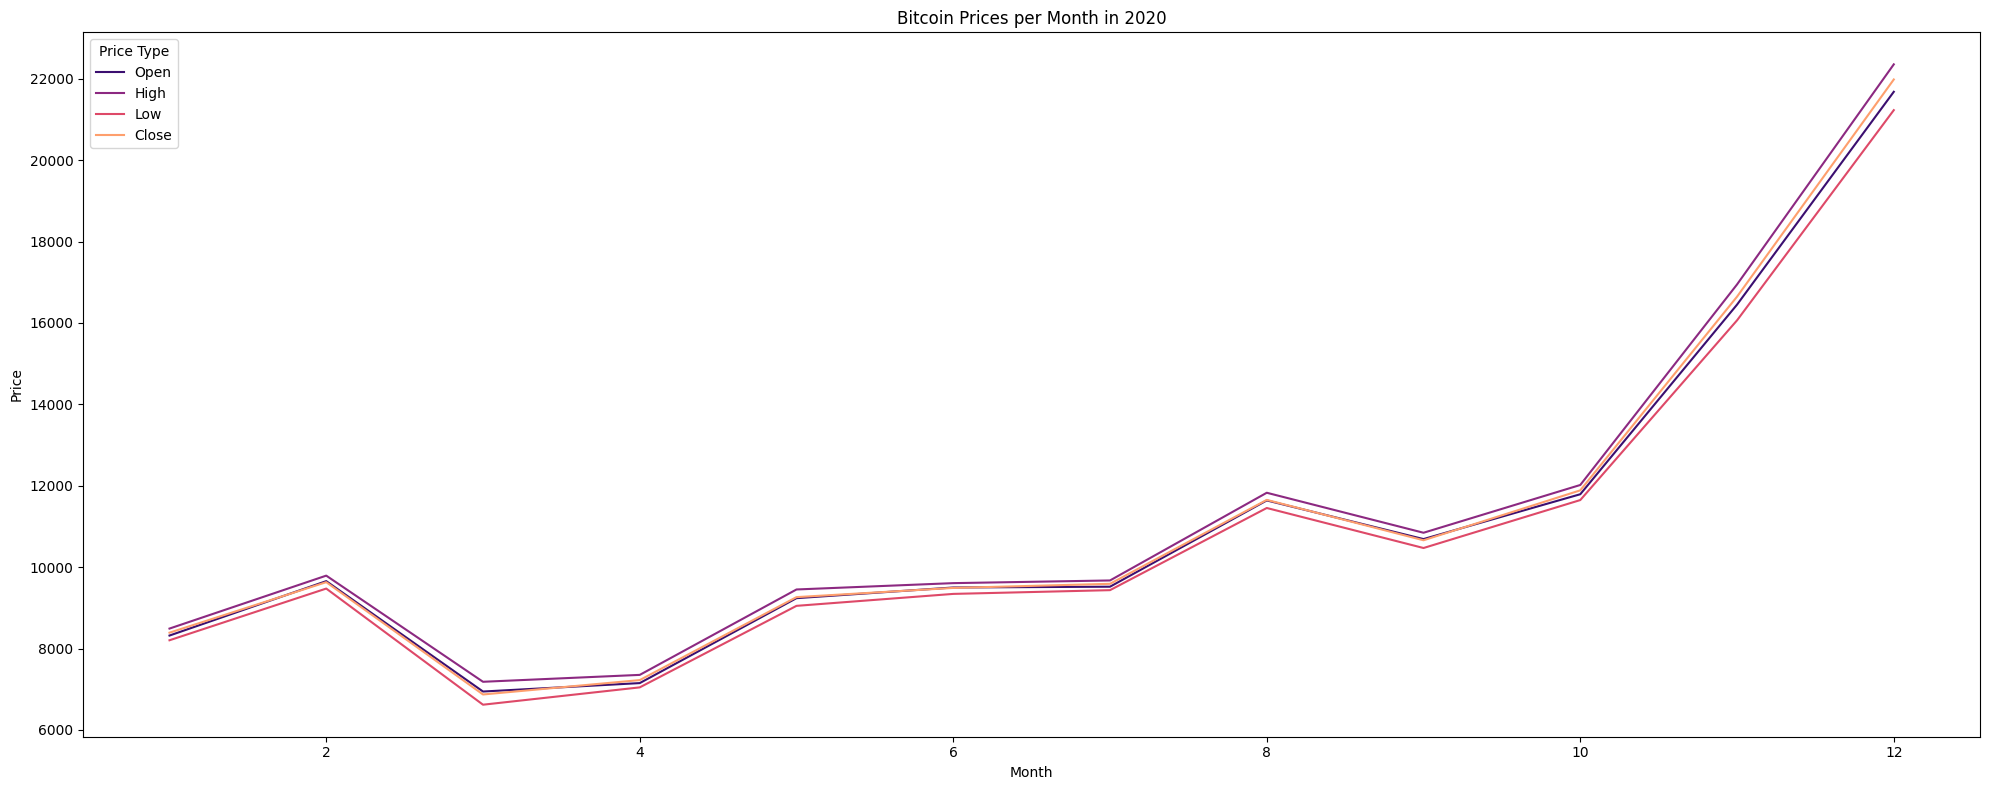

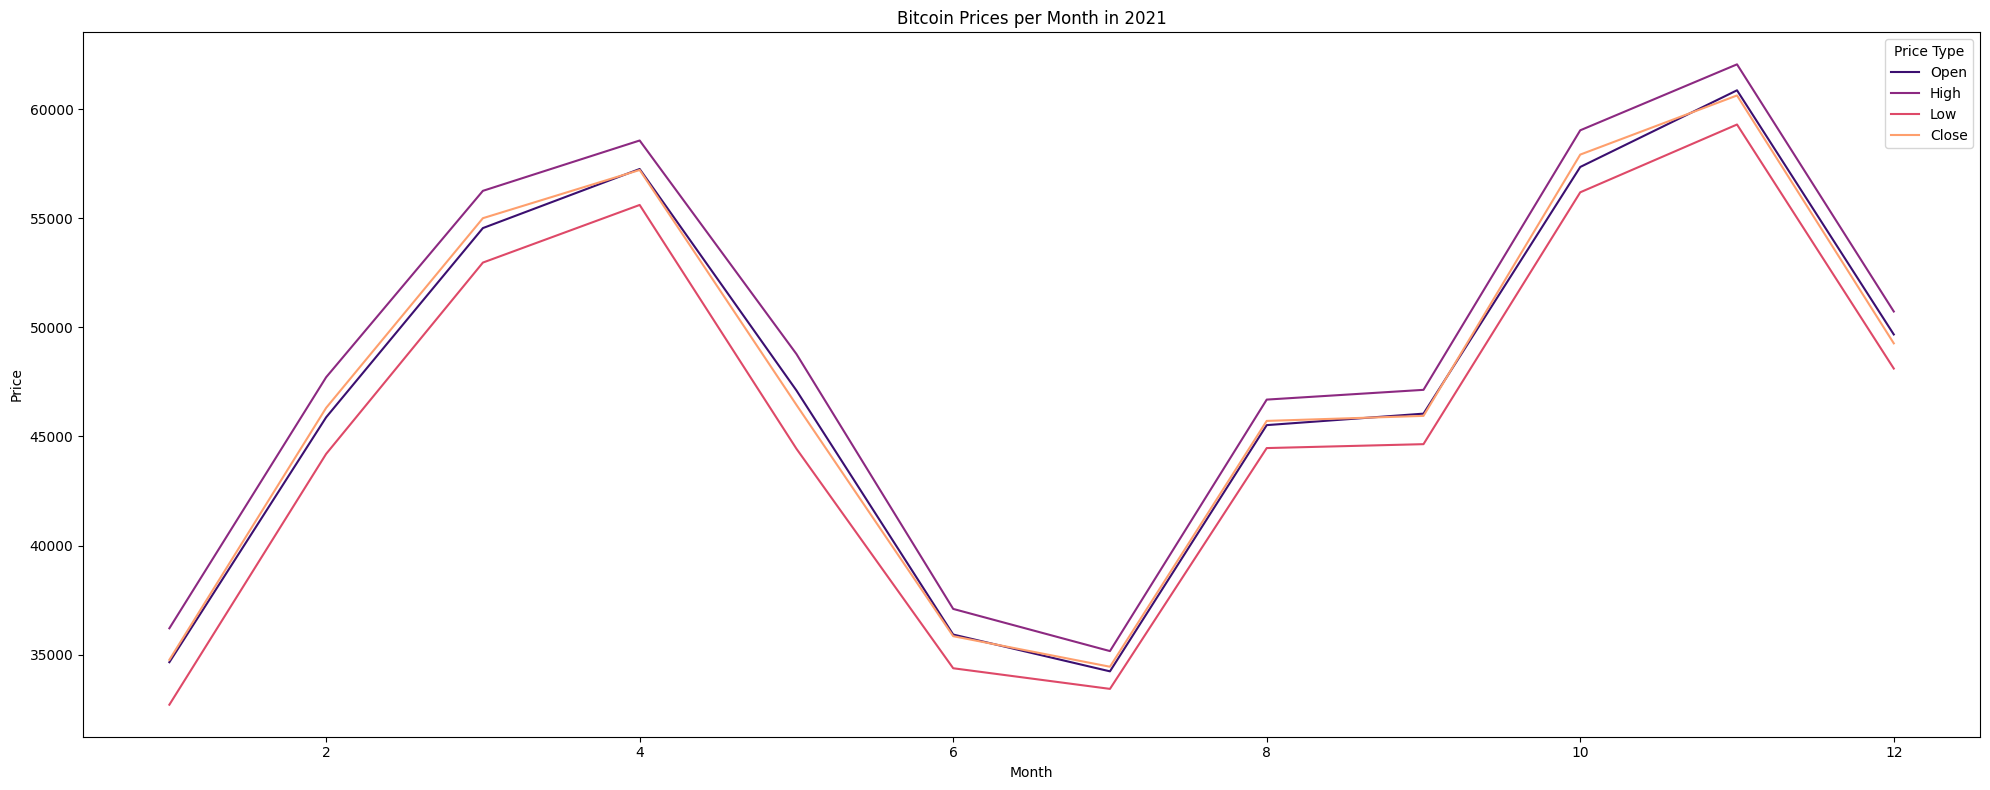

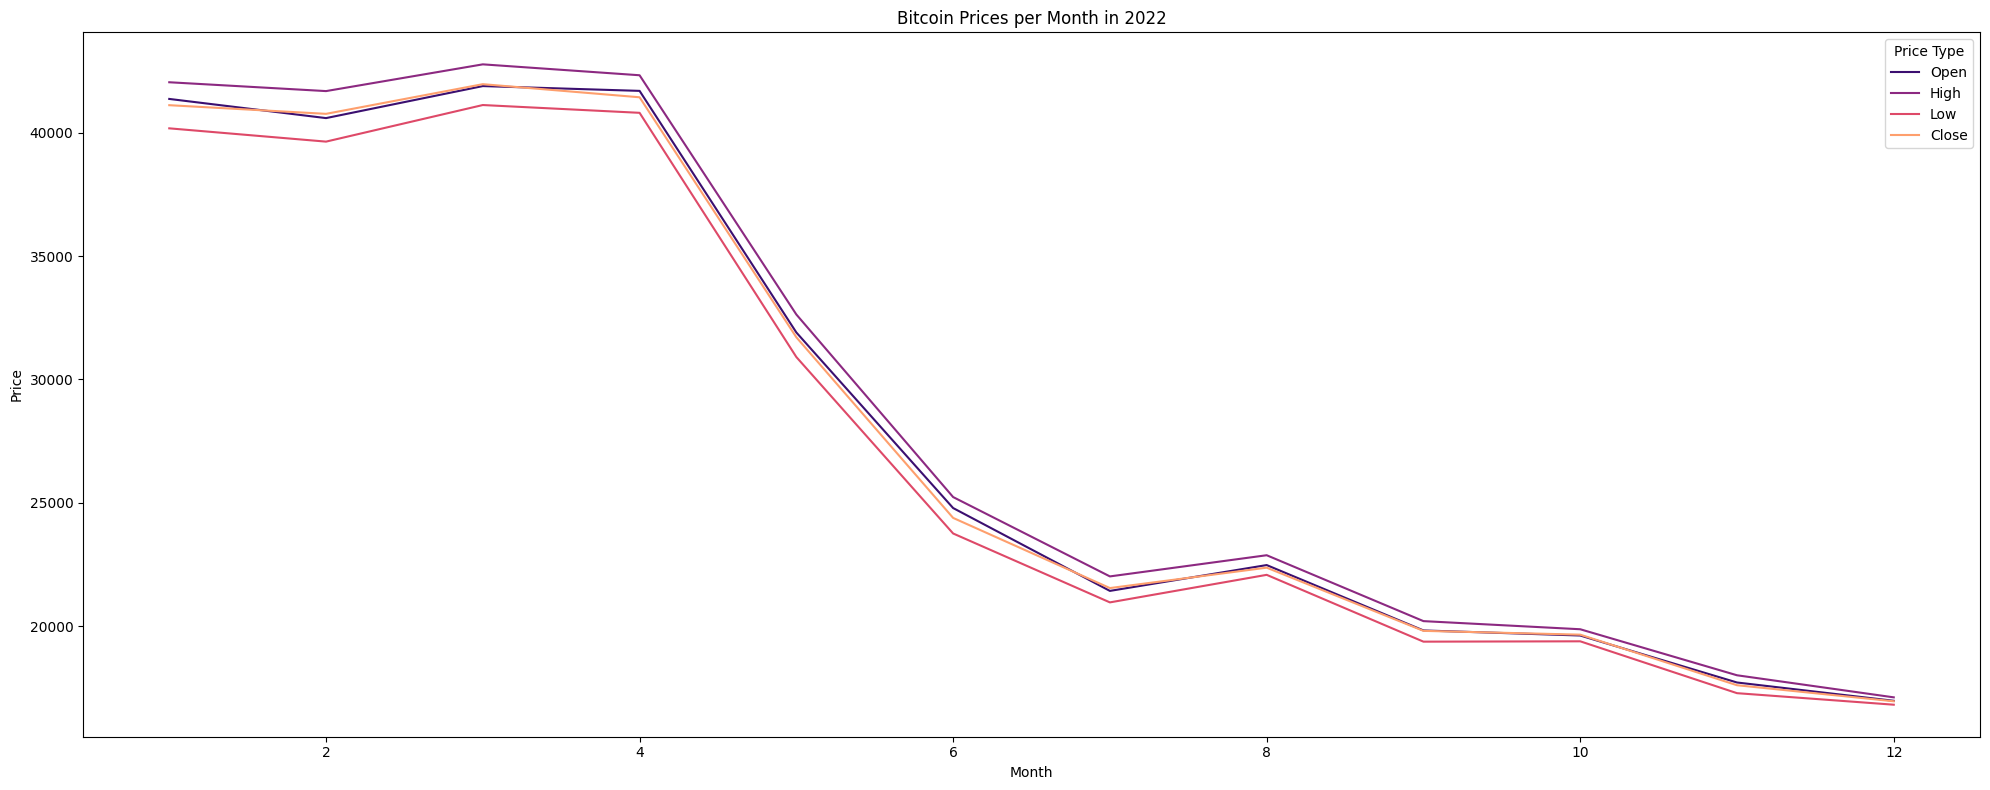

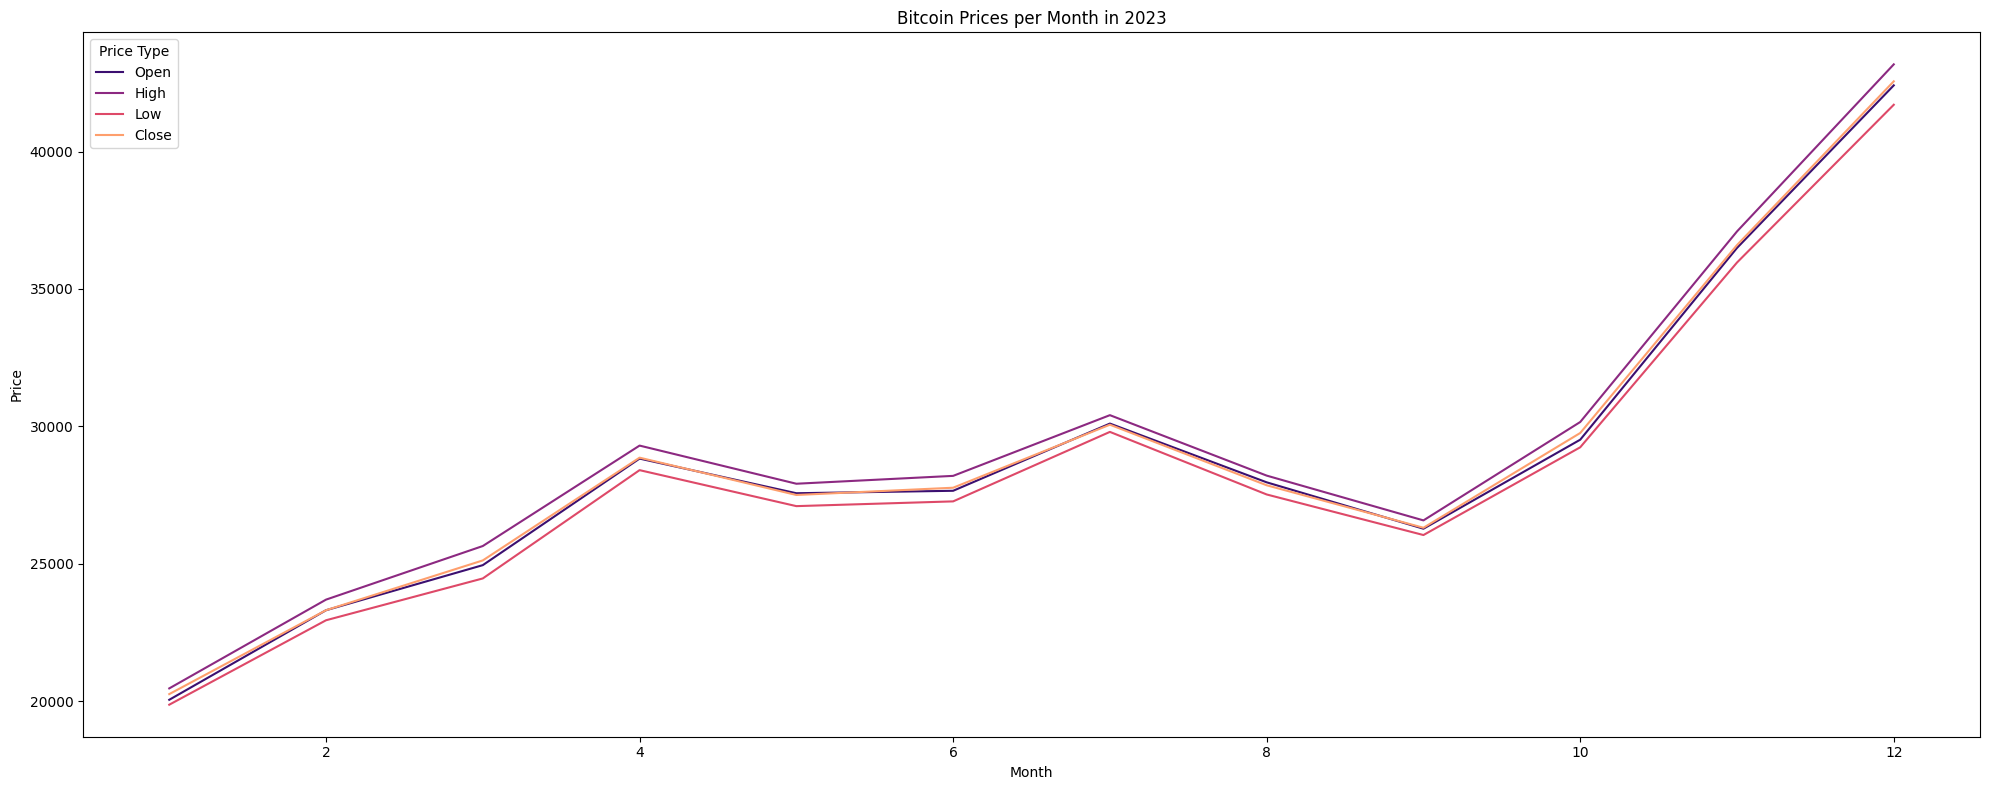

In [ ]:
# Line PLot
columns = ['Open', 'High', 'Low', 'Close']

for i in range(2014, 2024):
    plt.figure(figsize=(20,8))
    df_year = bitcoin_df[bitcoin_df['Year'] == i]

    df_melted = df_year.melt(id_vars=['Month'], value_vars=columns,
                             var_name='Price Type', value_name='Value')

    ax = sns.lineplot(data=df_melted, x='Month', y='Value', hue='Price Type', palette='magma', errorbar=None)
    
    for bar in ax.patches:
        height = bar.get_height()
        if not pd.isna(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=10,
                color='black'
            )

    plt.title(f'Bitcoin Prices per Month in {i}')
    plt.xlabel('Month')
    plt.ylabel('Price')
    plt.legend(title='Price Type')
    plt.tight_layout()
    plt.show()

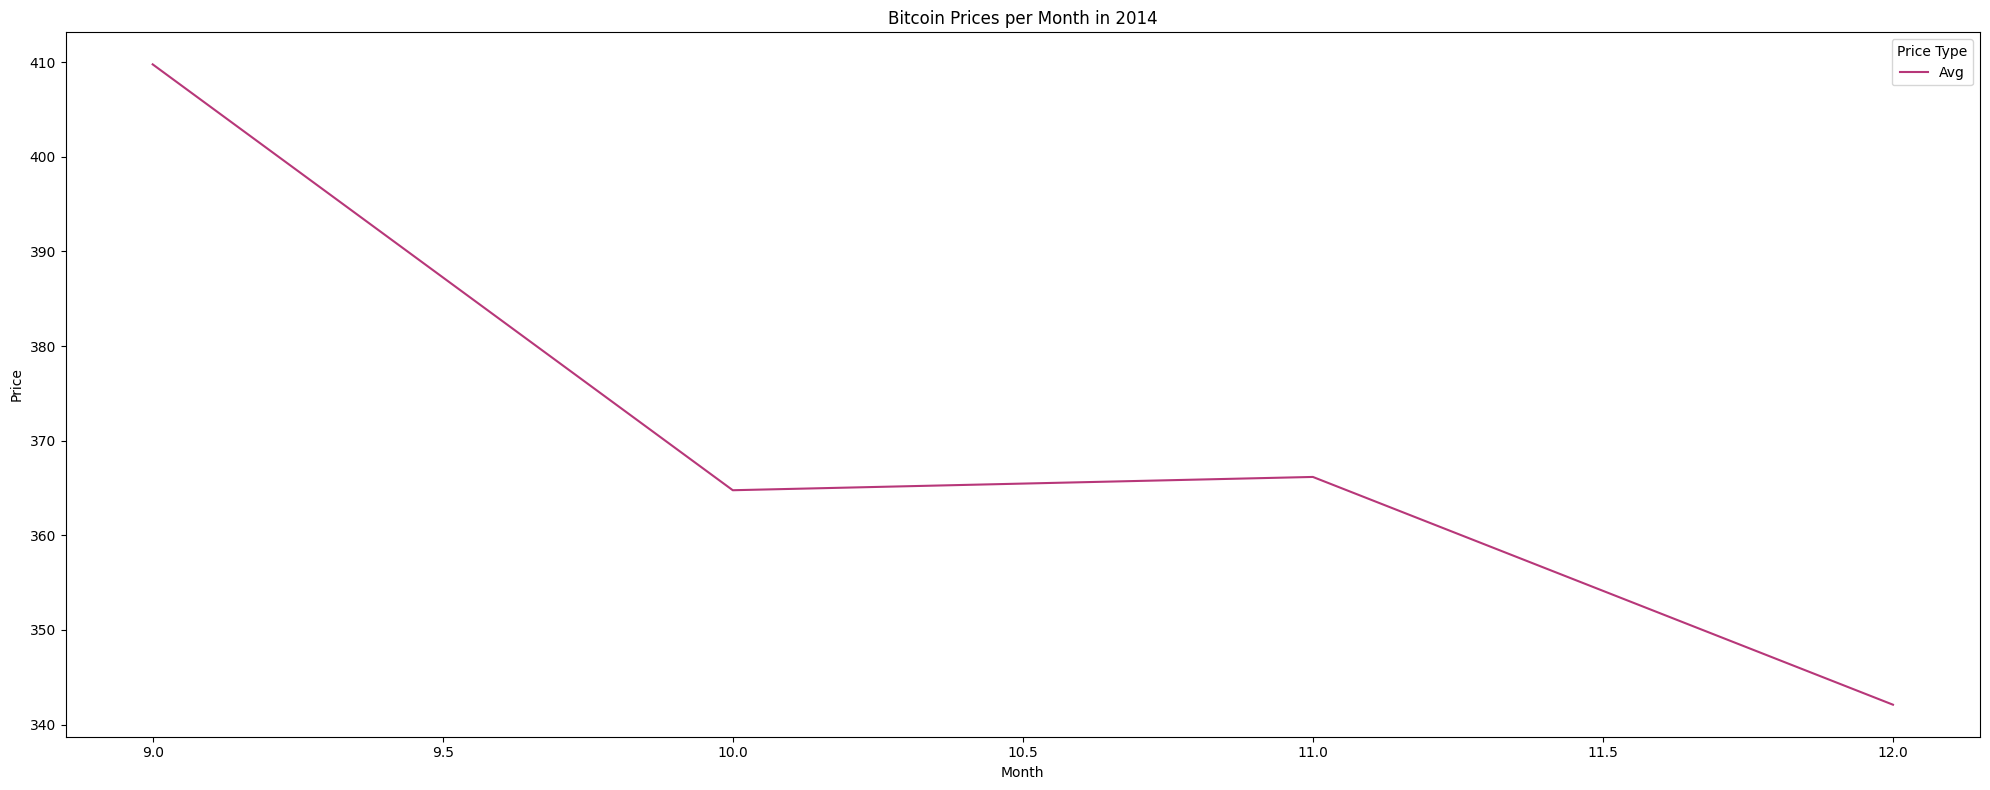

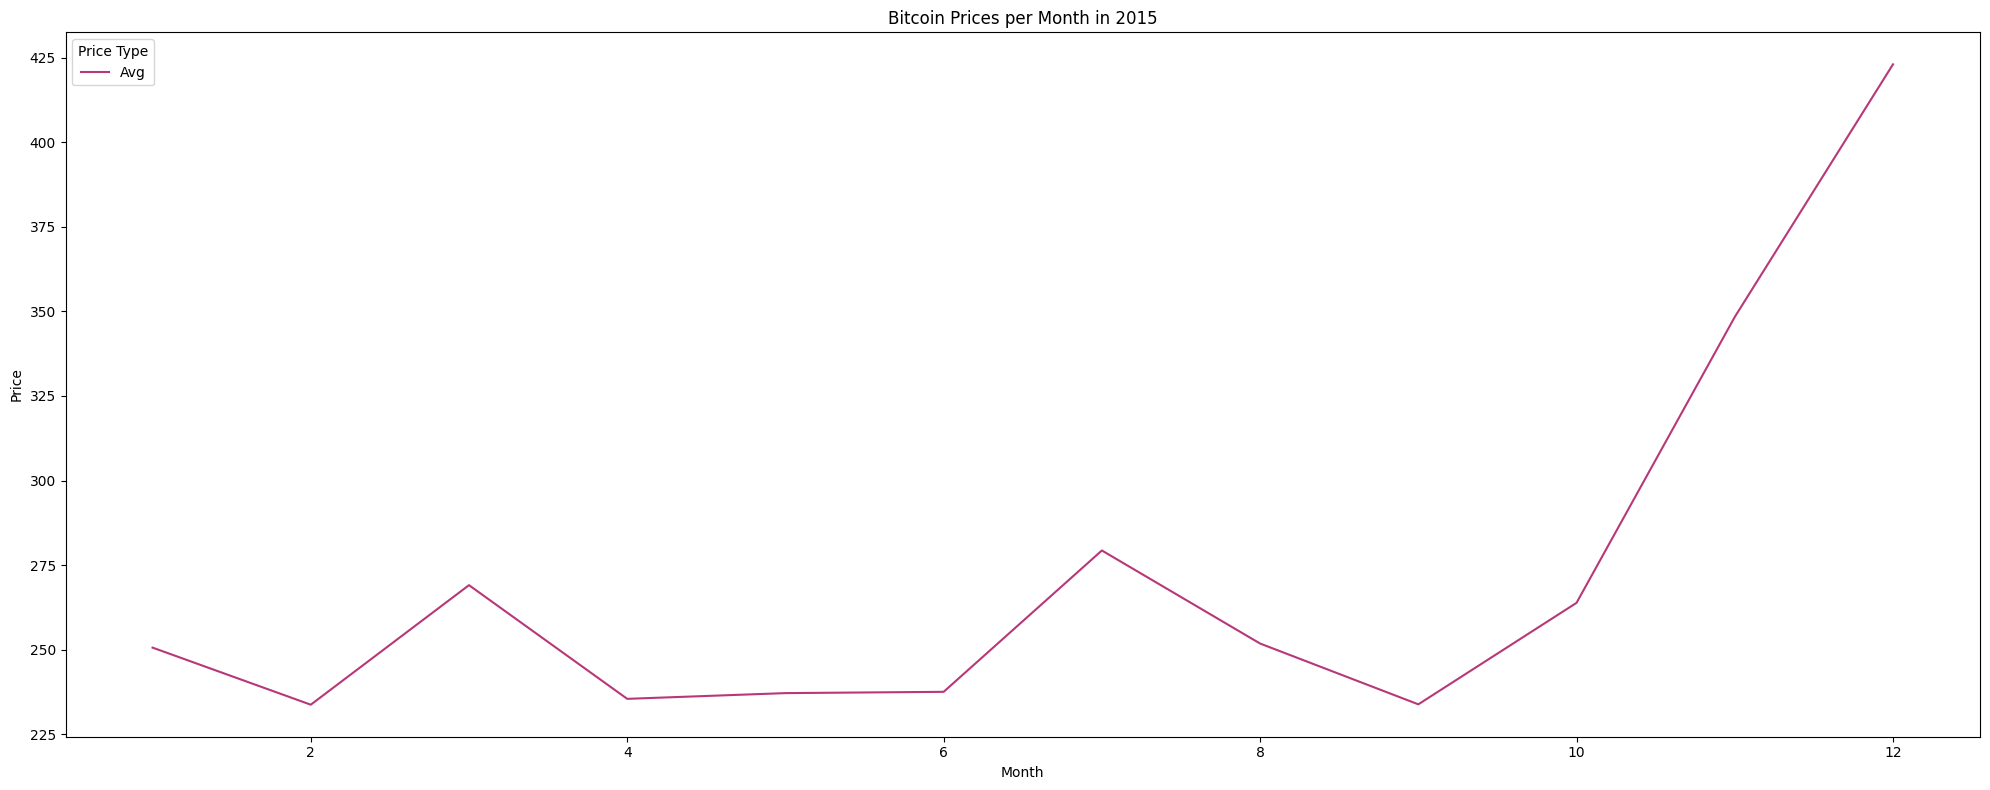

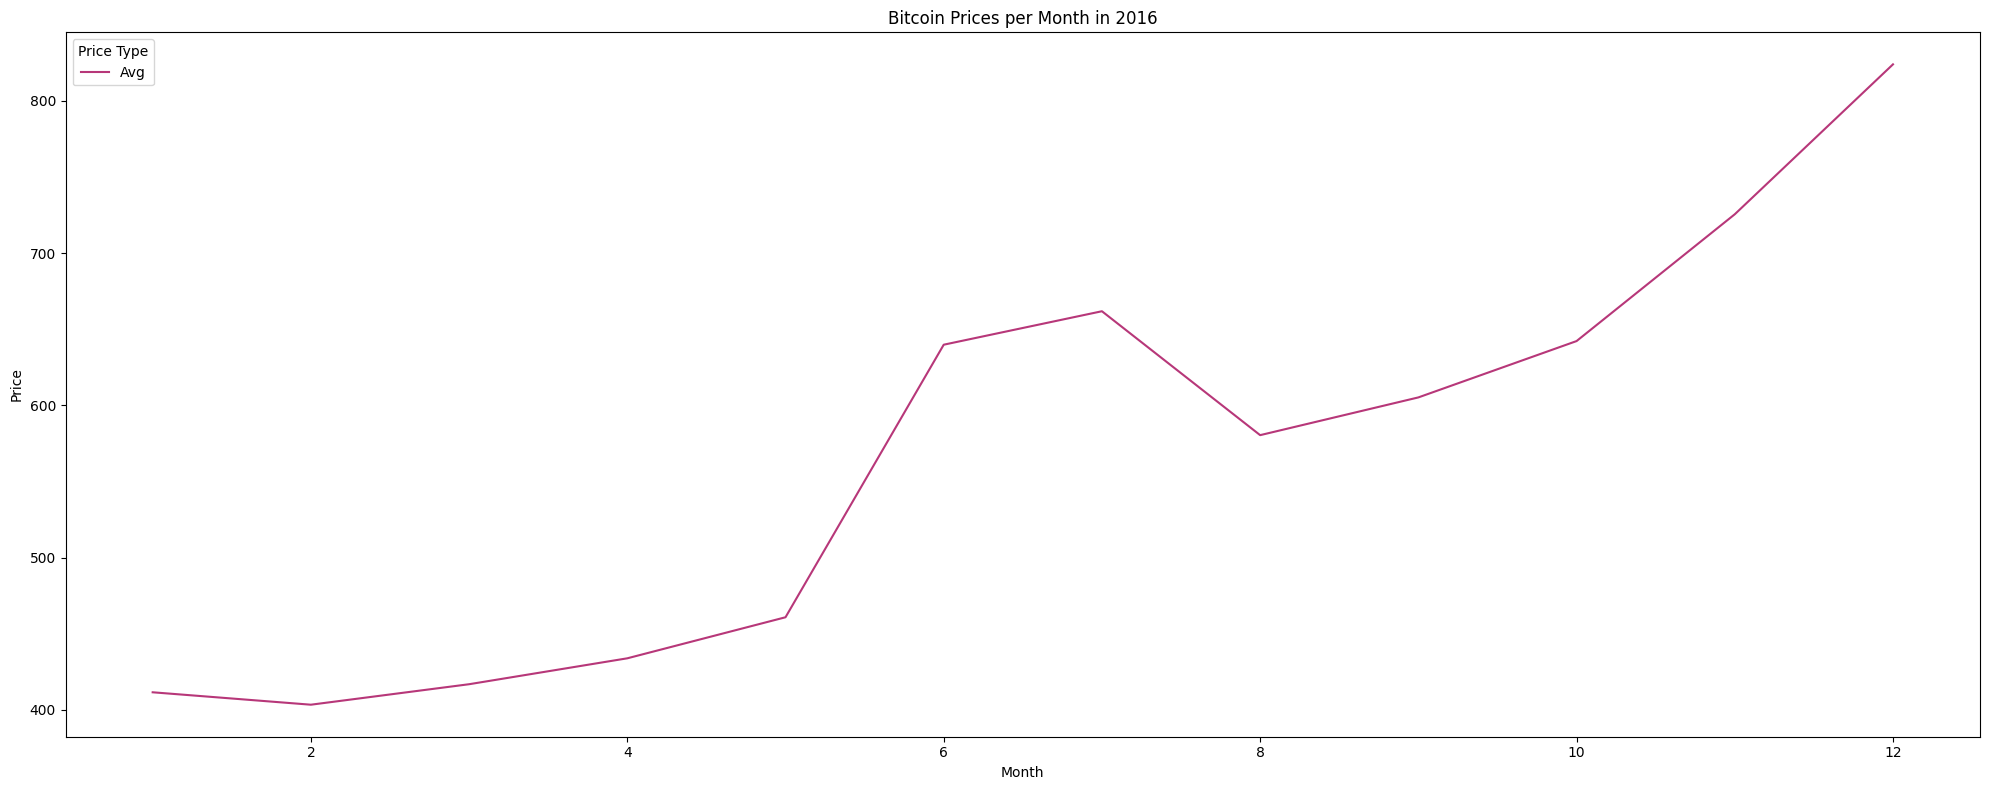

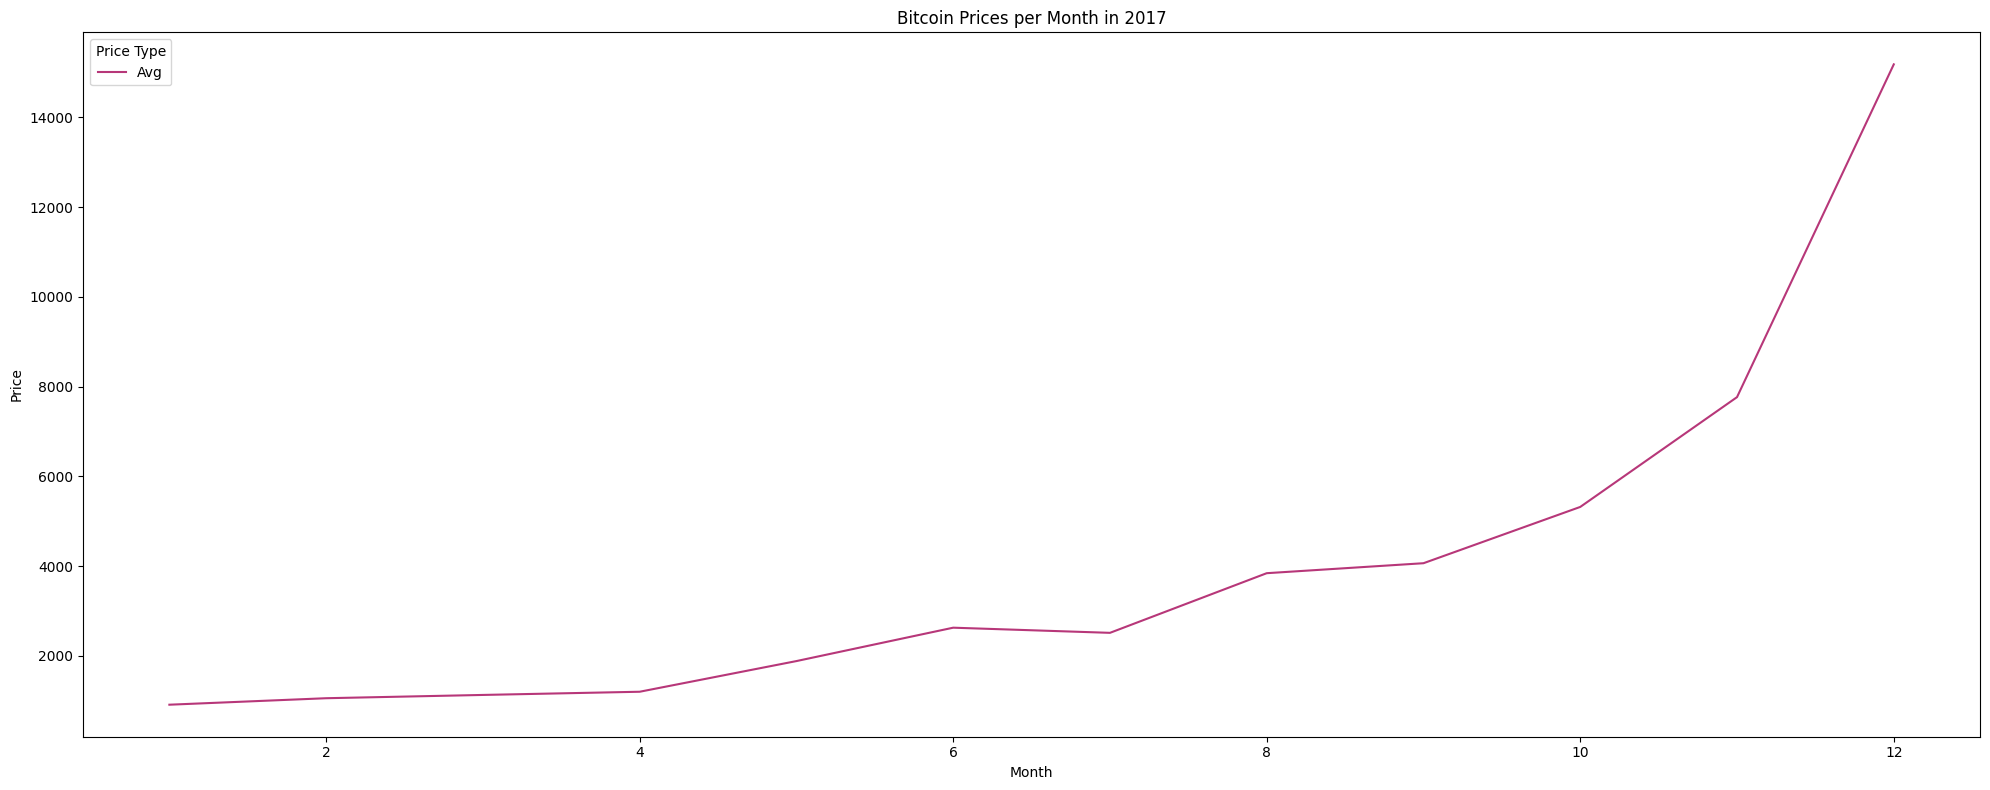

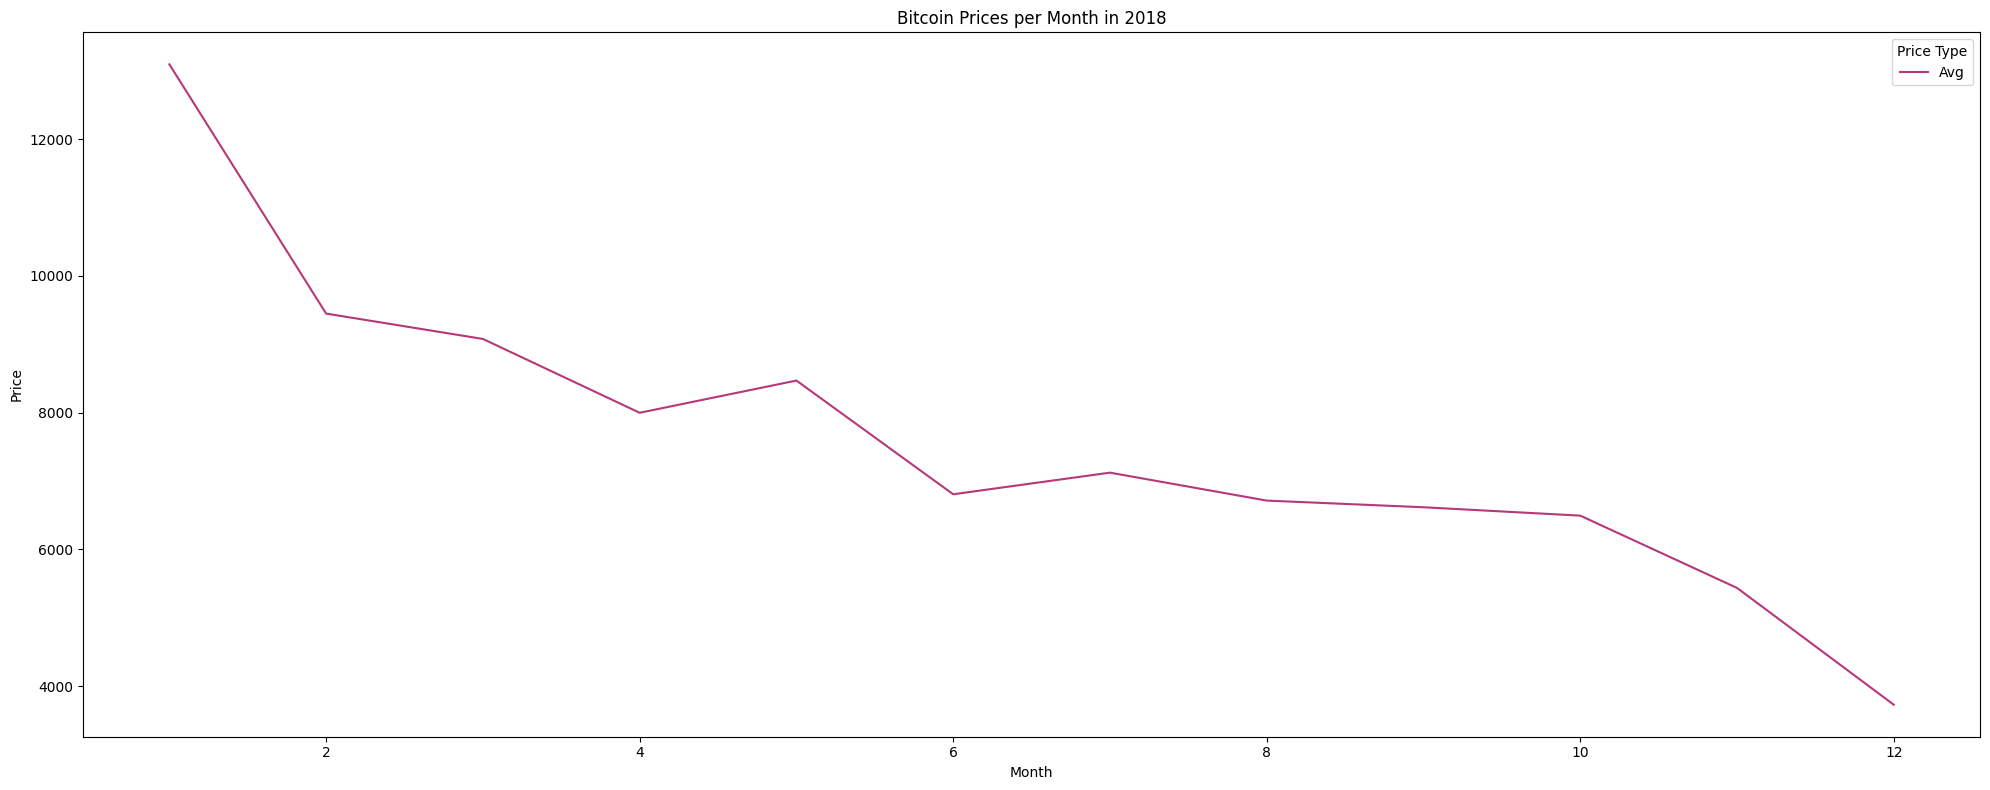

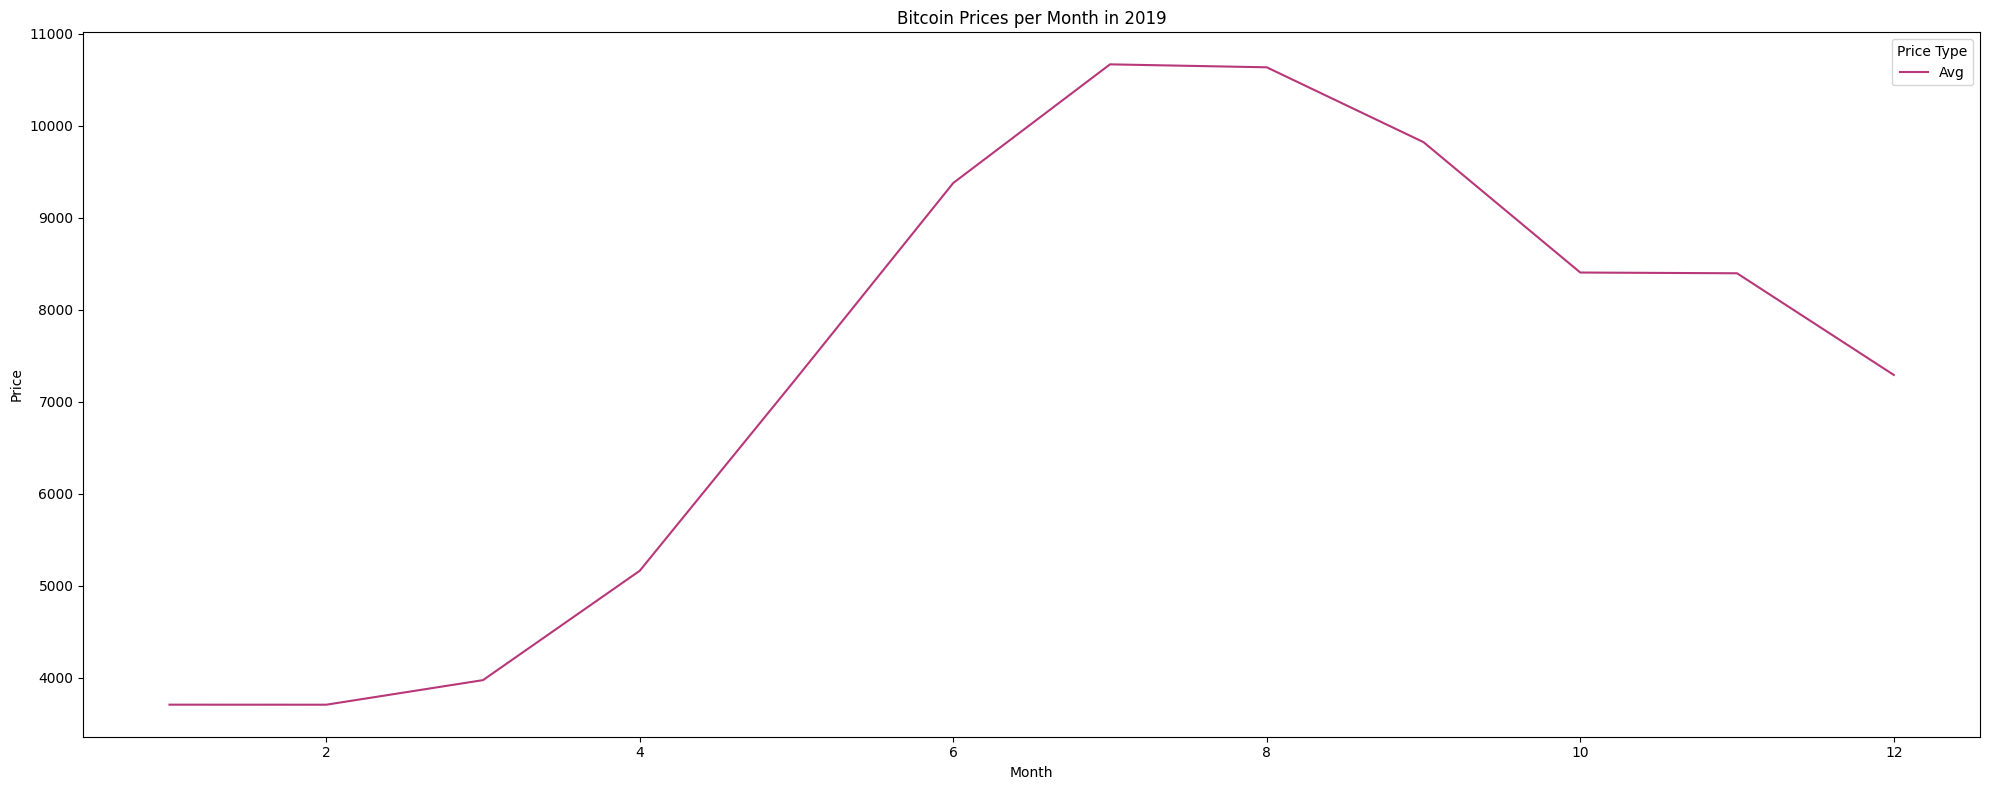

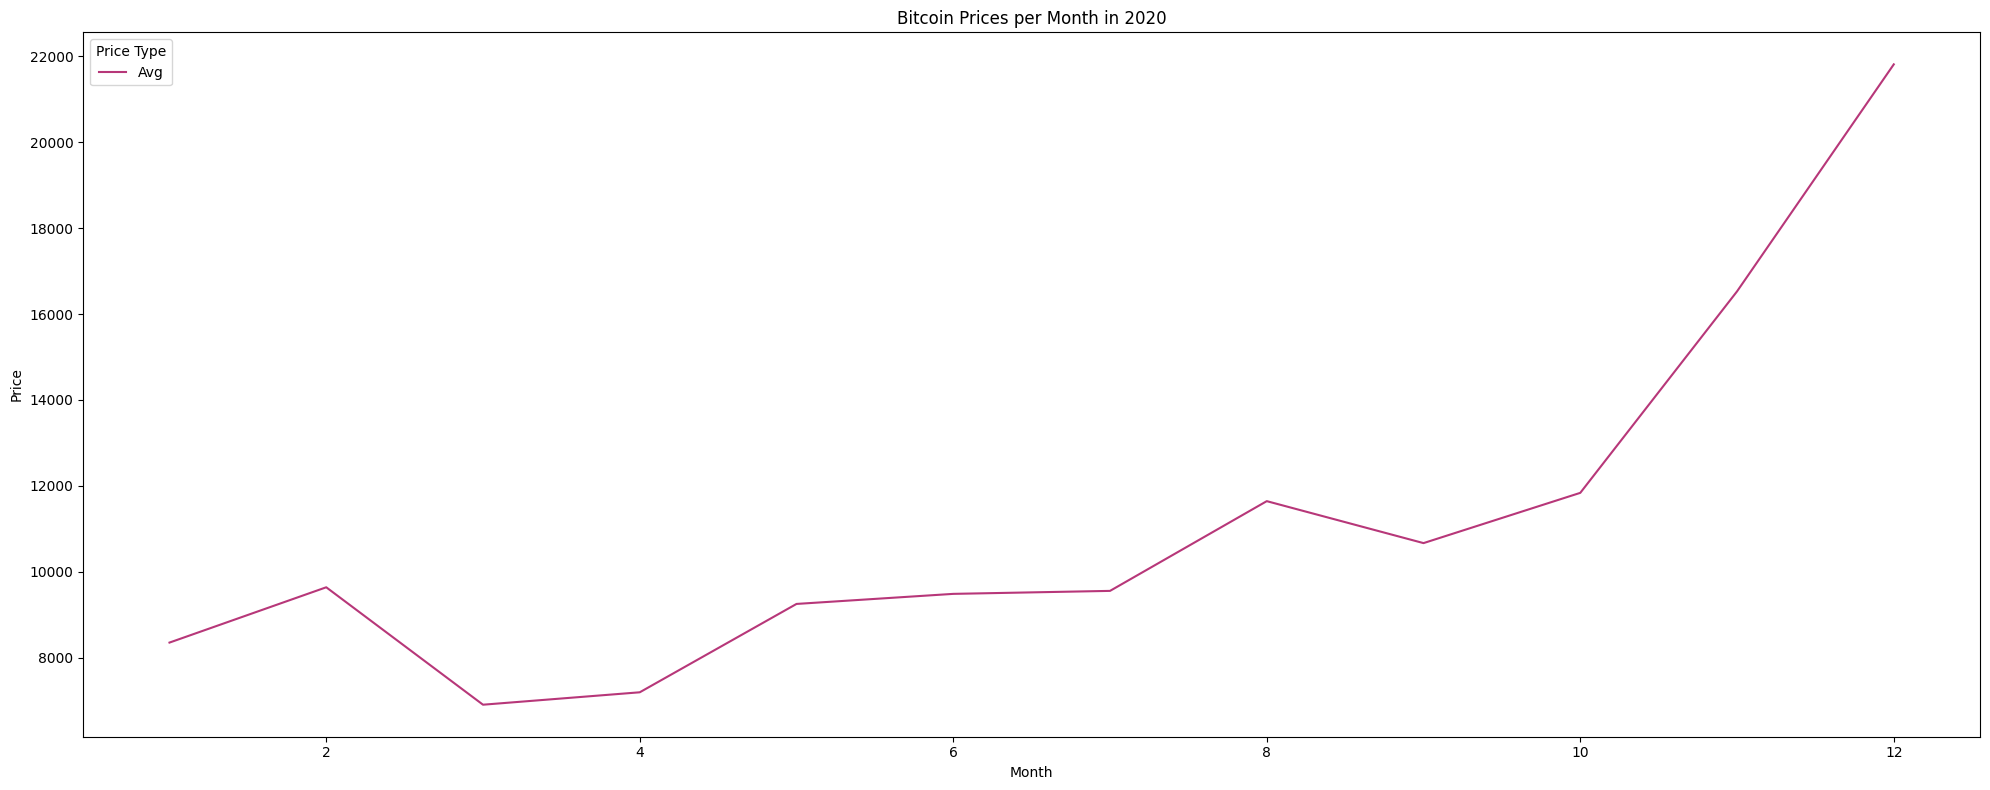

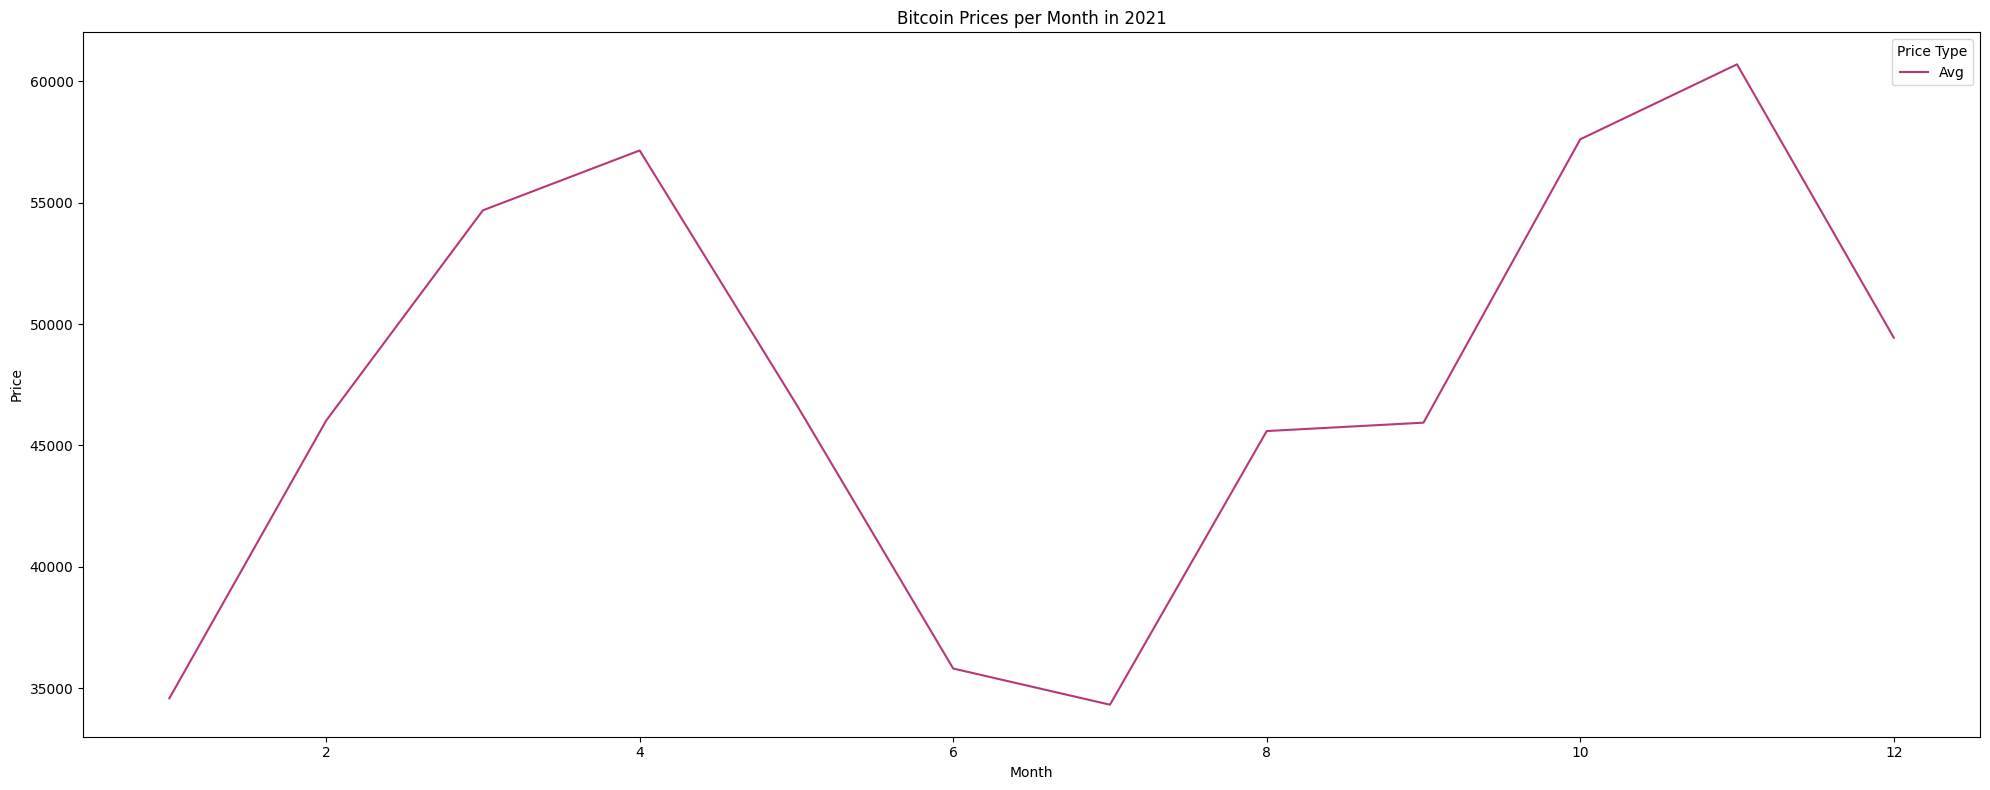

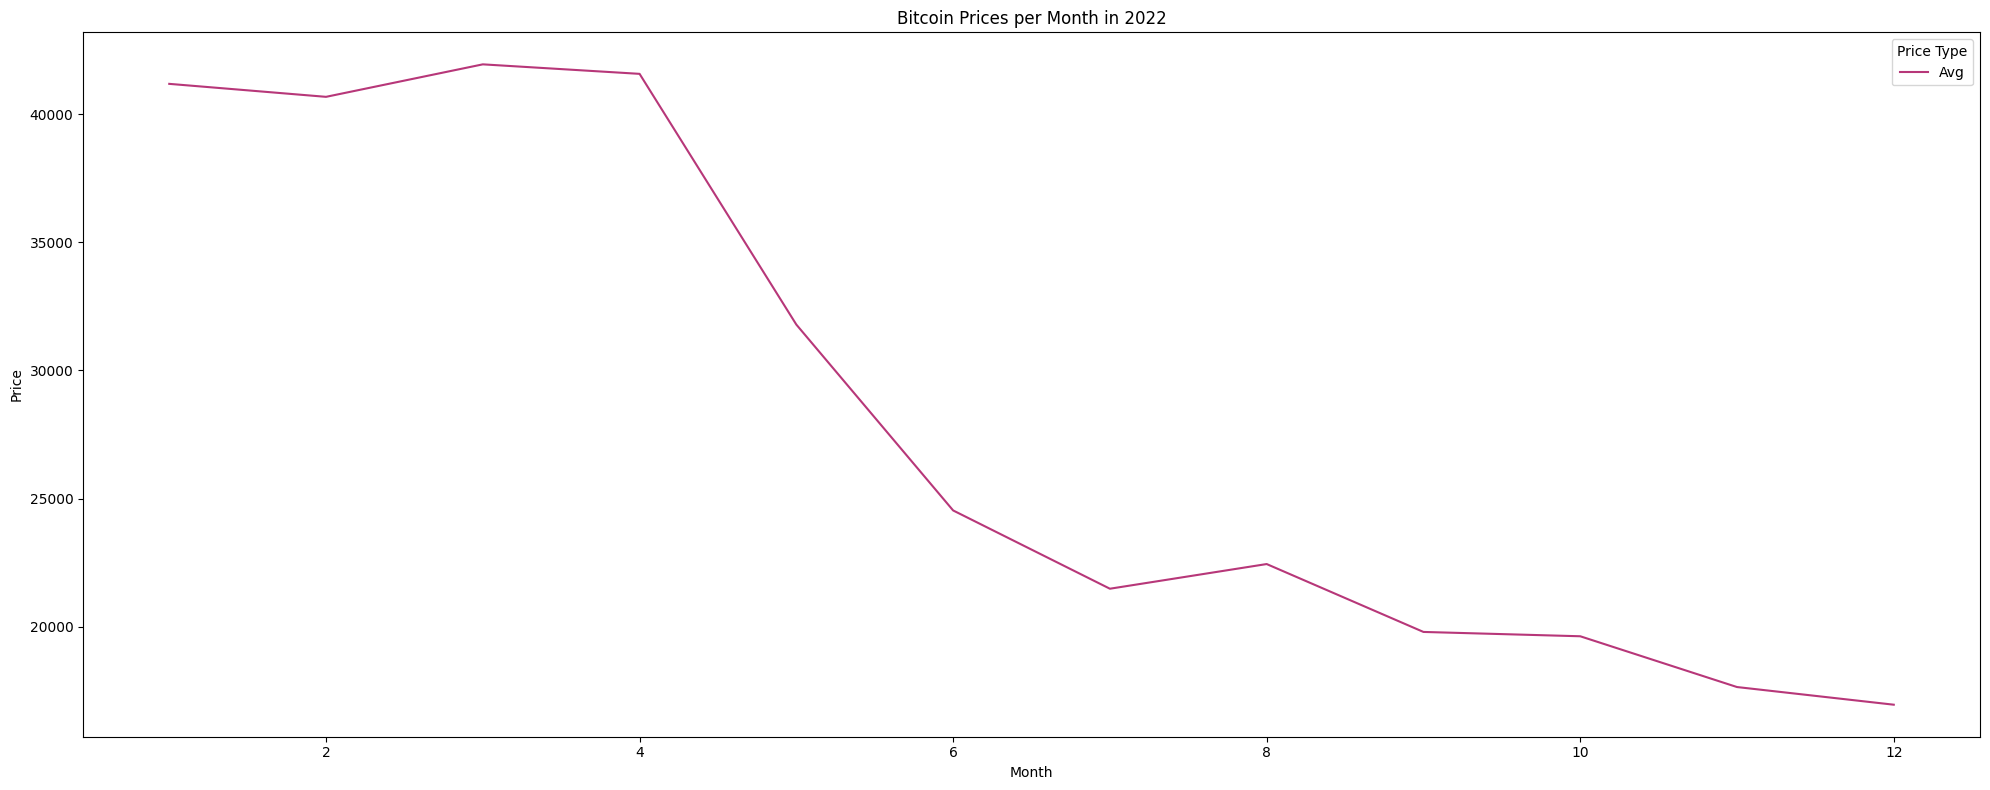

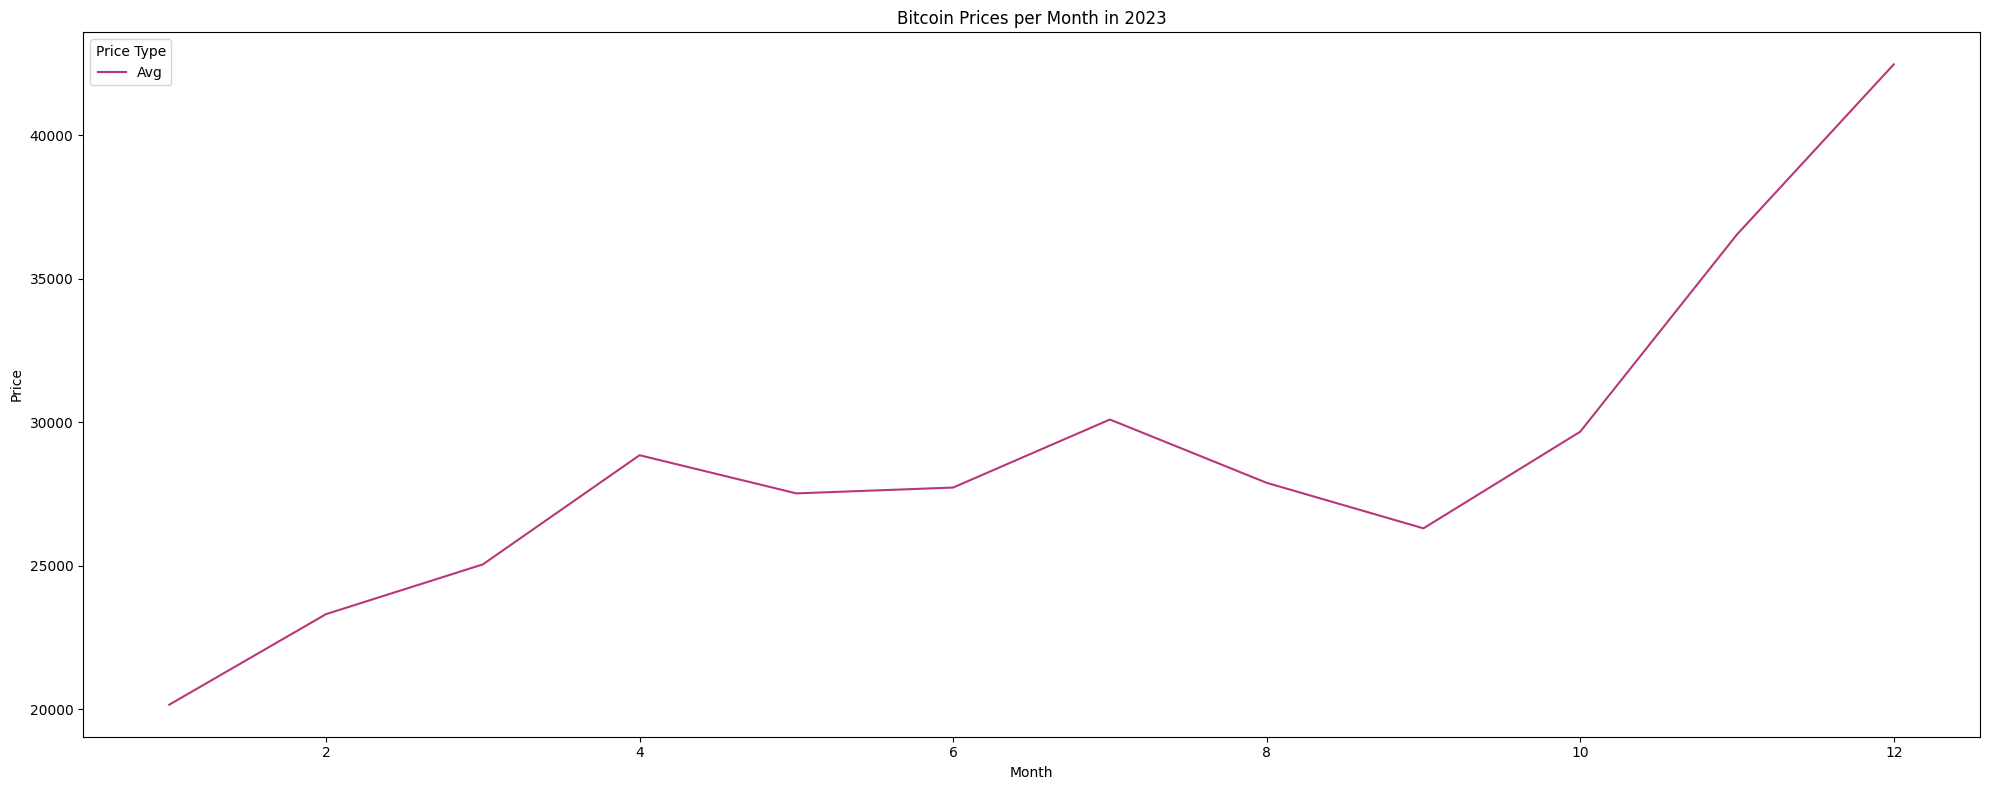

In [ ]:
# Line PLot for Average
columns = ['Open', 'High', 'Low', 'Close']

for i in range(2014, 2024):
    plt.figure(figsize=(20,8))
    df_year = bitcoin_df[bitcoin_df['Year'] == i]

    df_melted = df_year.melt(id_vars=['Month'], value_vars=['Avg'],
                             var_name='Price Type', value_name='Value')

    ax = sns.lineplot(data=df_melted, x='Month', y='Value', hue='Price Type', palette='magma', errorbar=None)
    
    for bar in ax.patches:
        height = bar.get_height()
        if not pd.isna(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=10,
                color='black'
            )

    plt.title(f'Bitcoin Prices per Month in {i}')
    plt.xlabel('Month')
    plt.ylabel('Price')
    plt.legend(title='Price Type')
    plt.tight_layout()
    plt.show()

<Axes: xlabel='Year', ylabel='Avg'>

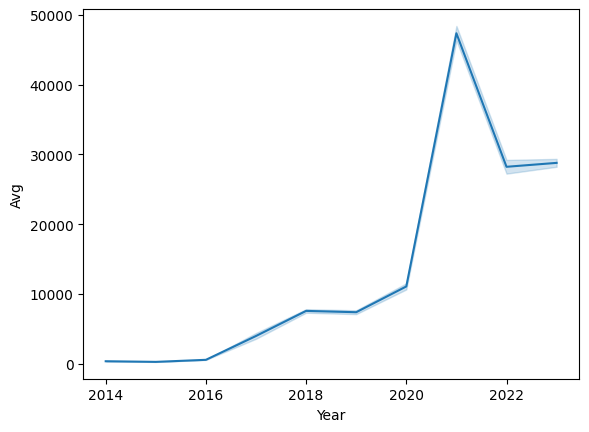

In [ ]:
sns.lineplot(data=bitcoin_df, x='Year', y='Avg')

# Coffee Shop Data

In [ ]:
coffee_df.head()

,transaction_id,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
date,,,,,,,,,
2023-01-01 07:06:11,1,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
2023-01-01 07:08:56,2,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2023-01-01 07:14:04,3,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
2023-01-01 07:20:24,4,1,5,Lower Manhattan,,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
2023-01-01 07:22:41,5,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [ ]:
coffee_df.nunique()

transaction_id      149116
transaction_qty          6
store_id                 3
store_location           3
product_id             161
unit_price              41
product_category         9
product_type            29
product_detail          80
dtype: int64

In [ ]:
coffee_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 149116 entries, 2023-01-01 07:06:11 to 2023-06-30 20:57:19
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   transaction_qty   149116 non-null  int64  
 2   store_id          149116 non-null  int64  
 3   store_location    149116 non-null  object 
 4   product_id        149116 non-null  object 
 5   unit_price        149116 non-null  float64
 6   product_category  149116 non-null  object 
 7   product_type      149116 non-null  object 
 8   product_detail    149116 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 11.4+ MB


In [ ]:
coffee_df.isnull().sum()

transaction_id      0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

### a. First Step is EDA

In [ ]:
# add columns like month, day number, day name, is weekend
coffee_df['Month'] = coffee_df.index.month
coffee_df['Day'] = coffee_df.index.day
coffee_df['Day_name'] = coffee_df.index.day_name()

coffee_df['is_weekend'] = coffee_df.index.weekday > 4

coffee_df['Hour'] = coffee_df.index.hour

coffee_df['revenue'] = coffee_df['transaction_qty'] * coffee_df['unit_price']


daily_sales = coffee_df['transaction_qty'].resample('D').sum()
missing_days = daily_sales.isna().sum()


coffee_df

,transaction_id,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Month,Day,Day_name,is_weekend,Hour,revenue
date,,,,,,,,,,,,,,,
2023-01-01 07:06:11,1,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg,1,1,Sunday,True,7,6.00
2023-01-01 07:08:56,2,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,1,1,Sunday,True,7,6.20
2023-01-01 07:14:04,3,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,1,1,Sunday,True,7,9.00
2023-01-01 07:20:24,4,1,5,Lower Manhattan,,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm,1,1,Sunday,True,7,2.00
2023-01-01 07:22:41,5,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,1,1,Sunday,True,7,6.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-06-30 20:18:41,149452,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg,6,30,Friday,False,20,5.00
2023-06-30 20:25:10,149453,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg,6,30,Friday,False,20,6.00
2023-06-30 20:31:34,149454,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg,6,30,Friday,False,20,3.00


In [ ]:
daily_summary = coffee_df.resample('D').agg({
    'transaction_qty': 'sum',
    'revenue': 'sum'
})

daily_summary

,transaction_qty,revenue
date,,
2023-01-01,802,2508.20
2023-01-02,796,2466.30
2023-01-03,968,3040.25
2023-01-04,1198,3699.90
2023-01-05,1515,4731.45
...,...,...
2023-12-02,872,2894.00
2023-12-03,947,3088.33
2023-12-04,1239,4040.18


In [ ]:
coffee_df[coffee_df['Hour'] == 7]
coffee_df['Day'].unique()

array([ 1, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28,
       29, 30, 31,  2,  3,  4,  5,  6], dtype=int32)

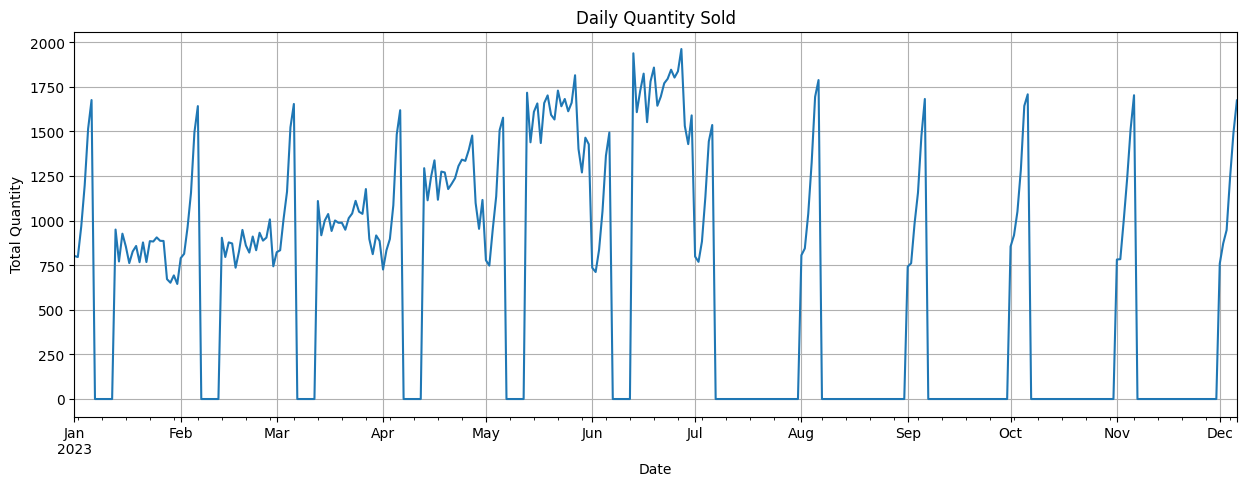

In [26]:
daily_summary['transaction_qty'].plot(figsize=(15, 5), title='Daily Quantity Sold')
plt.ylabel('Total Quantity')
plt.xlabel('Date')
plt.grid(True)
plt.show()


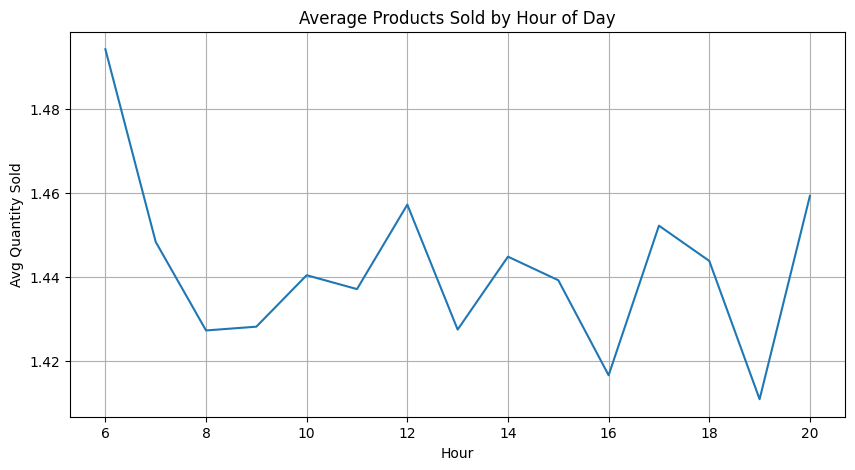

In [ ]:
hourly_avg = coffee_df.groupby('Hour')['transaction_qty'].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values)
plt.title('Average Products Sold by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Quantity Sold')
plt.grid(True)
plt.show()

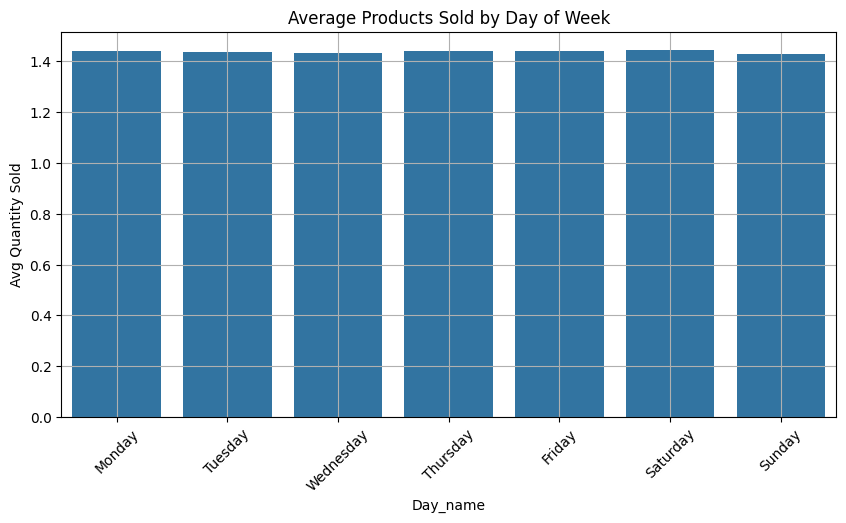

In [ ]:
dow_avg = coffee_df.groupby('Day_name')['transaction_qty'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(10,5))
sns.barplot(x=dow_avg.index, y=dow_avg.values, errorbar=None)
plt.title('Average Products Sold by Day of Week')
plt.ylabel('Avg Quantity Sold')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

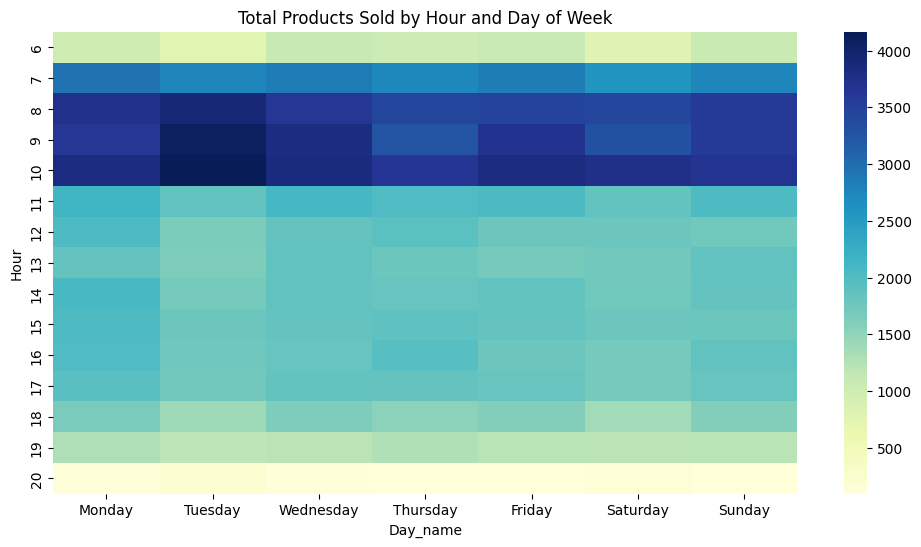

In [ ]:
pivot_table = coffee_df.pivot_table(index='Hour', columns='Day_name', values='transaction_qty', aggfunc='sum')
pivot_table = pivot_table[['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']]  # Ensure order

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, cmap="YlGnBu")
plt.title('Total Products Sold by Hour and Day of Week')
plt.show()

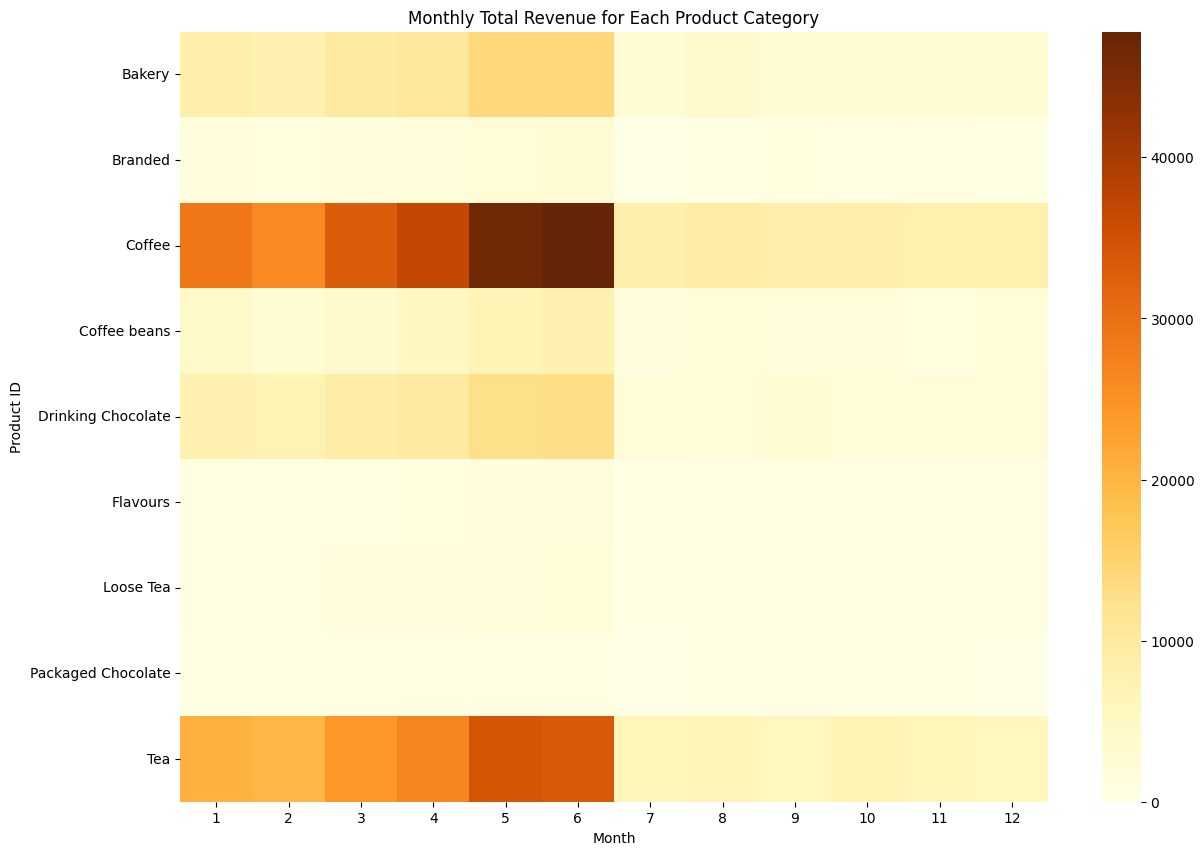

In [ ]:
monthly_revenue = coffee_df.groupby(['product_category', 'Month'])['revenue'].sum().reset_index()

pivot_rev = monthly_revenue.pivot(index='product_category', columns='Month', values='revenue').fillna(0)

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_rev, annot=False, cmap='YlOrBr')
plt.title('Monthly Total Revenue for Each Product Category')
plt.xlabel('Month')
plt.ylabel('Product ID')
plt.show()


In [ ]:
coffee_df['revenue'] = coffee_df['transaction_qty'] * coffee_df['unit_price']

# Extract additional time-based features if not present
coffee_df['Year'] = coffee_df.index.year
coffee_df['Week'] = coffee_df.index.isocalendar().week
coffee_df['Date'] = coffee_df.index.date  # For daily grouping

coffee_df

,transaction_id,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Month,Day,Day_name,is_weekend,Hour,revenue,Year,Week,Date
date,,,,,,,,,,,,,,,,,,
2023-01-01 07:06:11,1,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg,1,1,Sunday,True,7,6.00,2023,52,2023-01-01
2023-01-01 07:08:56,2,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,1,1,Sunday,True,7,6.20,2023,52,2023-01-01
2023-01-01 07:14:04,3,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,1,1,Sunday,True,7,9.00,2023,52,2023-01-01
2023-01-01 07:20:24,4,1,5,Lower Manhattan,,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm,1,1,Sunday,True,7,2.00,2023,52,2023-01-01
2023-01-01 07:22:41,5,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,1,1,Sunday,True,7,6.20,2023,52,2023-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-06-30 20:18:41,149452,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg,6,30,Friday,False,20,5.00,2023,26,2023-06-30
2023-06-30 20:25:10,149453,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg,6,30,Friday,False,20,6.00,2023,26,2023-06-30
2023-06-30 20:31:34,149454,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg,6,30,Friday,False,20,3.00,2023,26,2023-06-30


We'll go through:

1. Daily Total Revenue
2. Daily Product Quantity Sold
3. Monthly Revenue per Product
4. Revenue Trend per Store
5. Hourly Trend Over All Days (average)
6. Weekly Revenue Trend
7. Product Category Revenue Trend
8. Weekend vs Weekday Revenue
9. Revenue by Hour Across Top Products

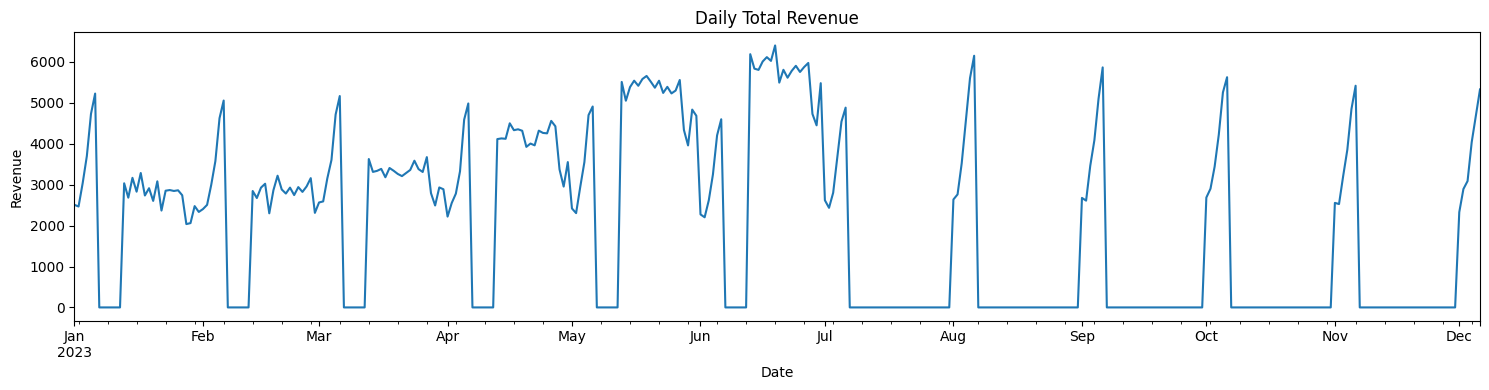

In [ ]:
# plt.style.use('seaborn-whitegrid')

# 1. Daily Total Revenue
daily_revenue = coffee_df.resample('D')['revenue'].sum()
plt.figure(figsize=(15, 4))
daily_revenue.plot()
plt.title("Daily Total Revenue")
plt.ylabel("Revenue")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

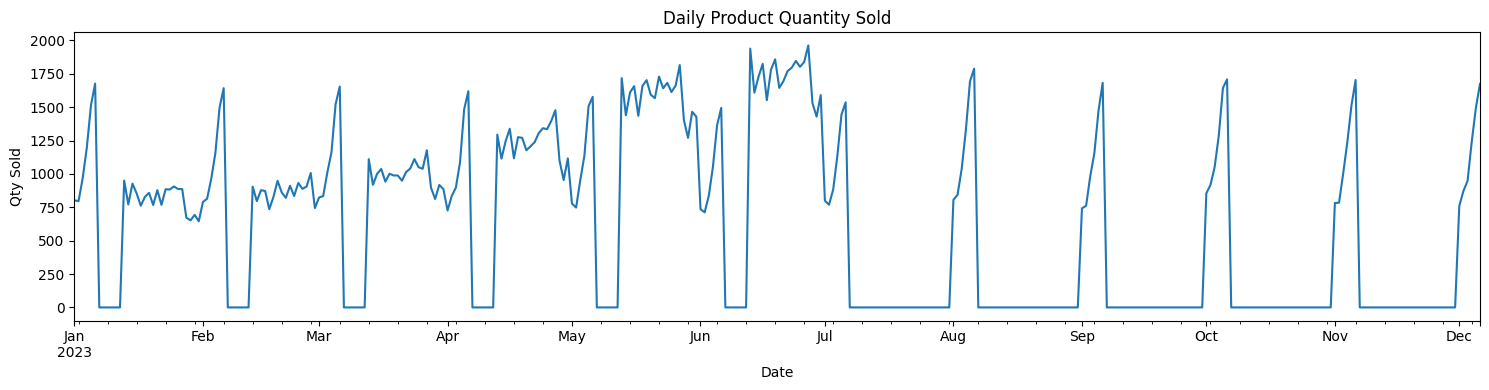

In [ ]:

# 2. Daily Quantity Sold
daily_qty = coffee_df.resample('D')['transaction_qty'].sum()
plt.figure(figsize=(15, 4))
daily_qty.plot()
plt.title("Daily Product Quantity Sold")
plt.ylabel("Qty Sold")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

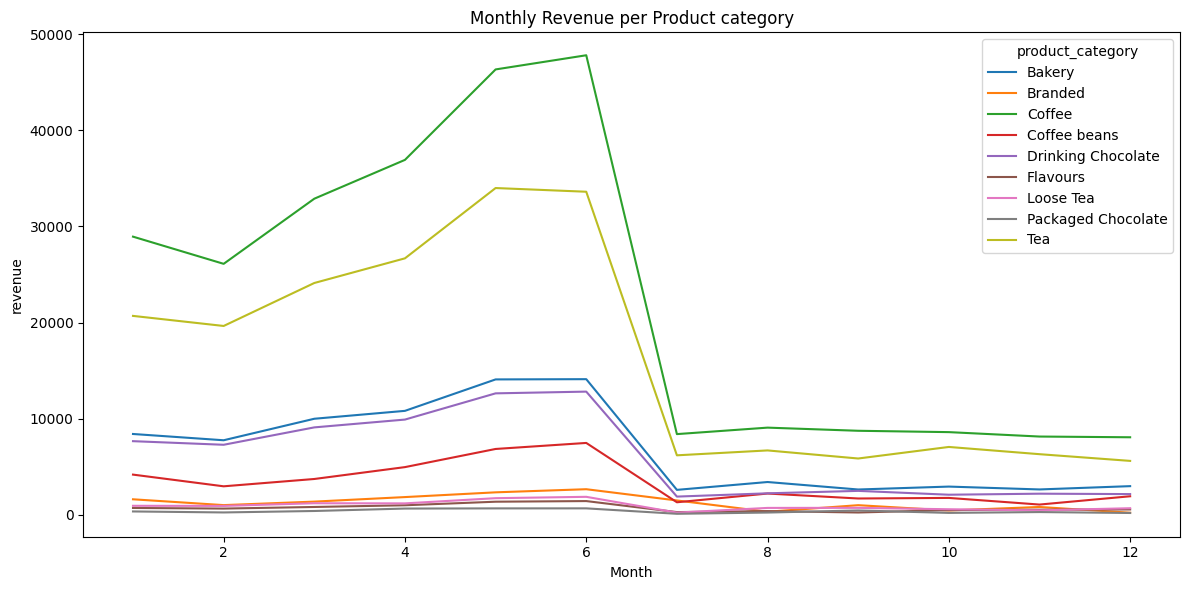

In [ ]:
# 3. Monthly Revenue per Product
monthly_product = coffee_df.groupby(['Month', 'product_category'])['revenue'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_product, x='Month', y='revenue', hue='product_category')
plt.title("Monthly Revenue per Product category")
plt.tight_layout()
plt.show()

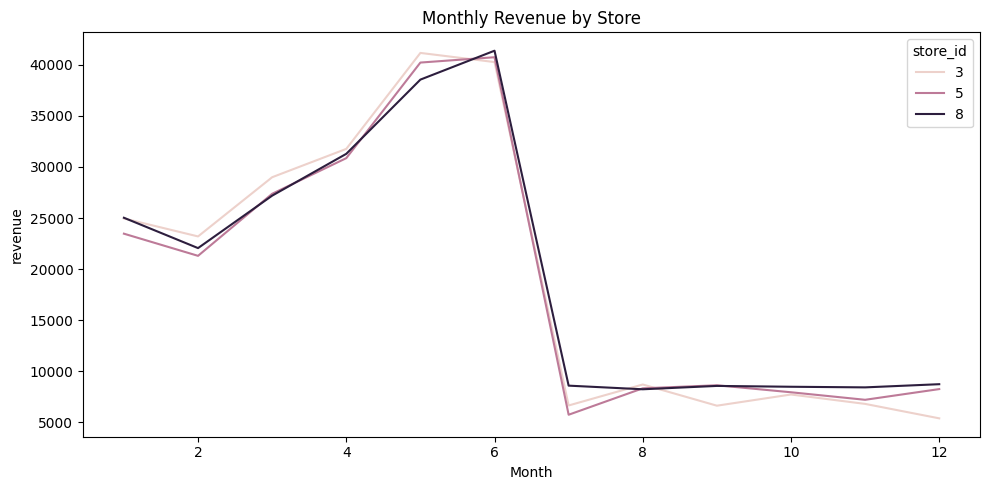

In [ ]:
# 4. Monthly Revenue per Store
monthly_store = coffee_df.groupby(['Month', 'store_id'])['revenue'].sum().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_store, x='Month', y='revenue', hue='store_id')
plt.title("Monthly Revenue by Store")
plt.tight_layout()
plt.show()

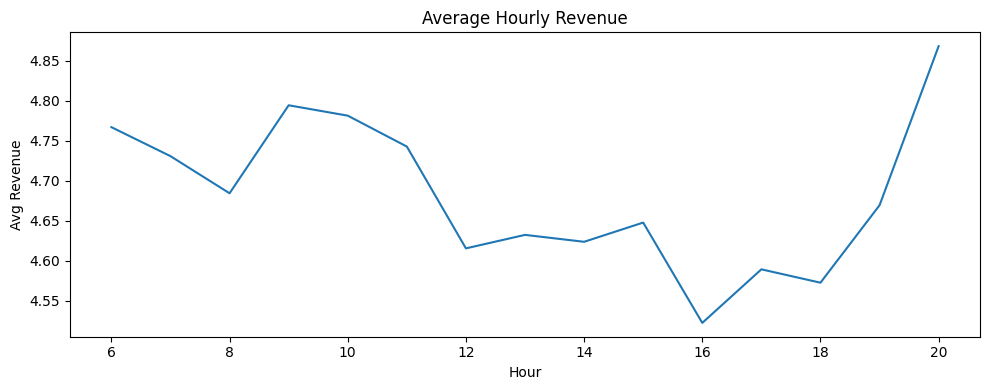

In [ ]:
# 5. Average Revenue by Hour of Day
hourly_avg = coffee_df.groupby('Hour')['revenue'].mean()
plt.figure(figsize=(10, 4))
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values)
plt.title("Average Hourly Revenue")
plt.xlabel("Hour")
plt.ylabel("Avg Revenue")
plt.tight_layout()
plt.show()

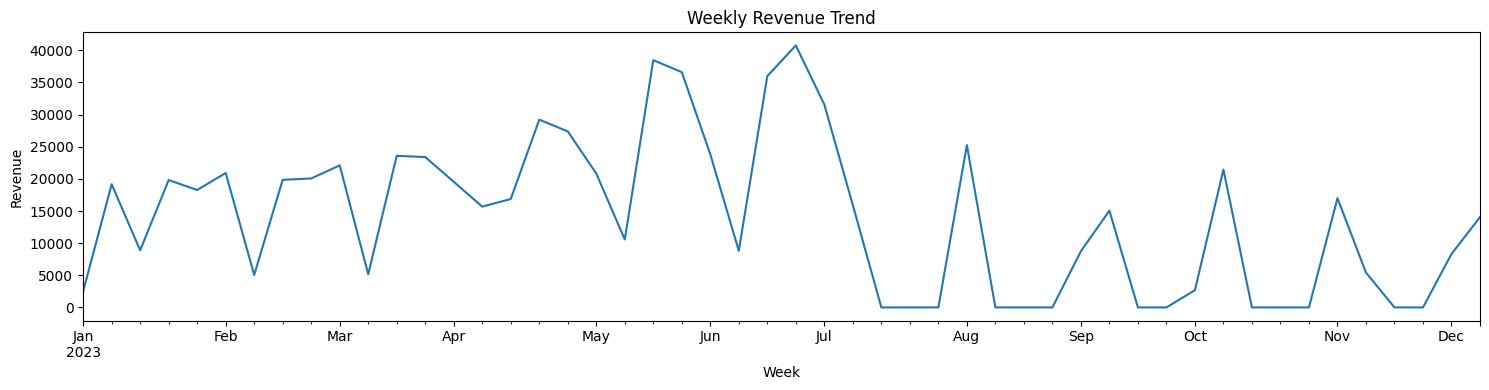

In [ ]:
# 6. Weekly Revenue Trend
weekly_revenue = coffee_df.resample('W')['revenue'].sum()
plt.figure(figsize=(15, 4))
weekly_revenue.plot()
plt.title("Weekly Revenue Trend")
plt.ylabel("Revenue")
plt.xlabel("Week")
plt.tight_layout()
plt.show()

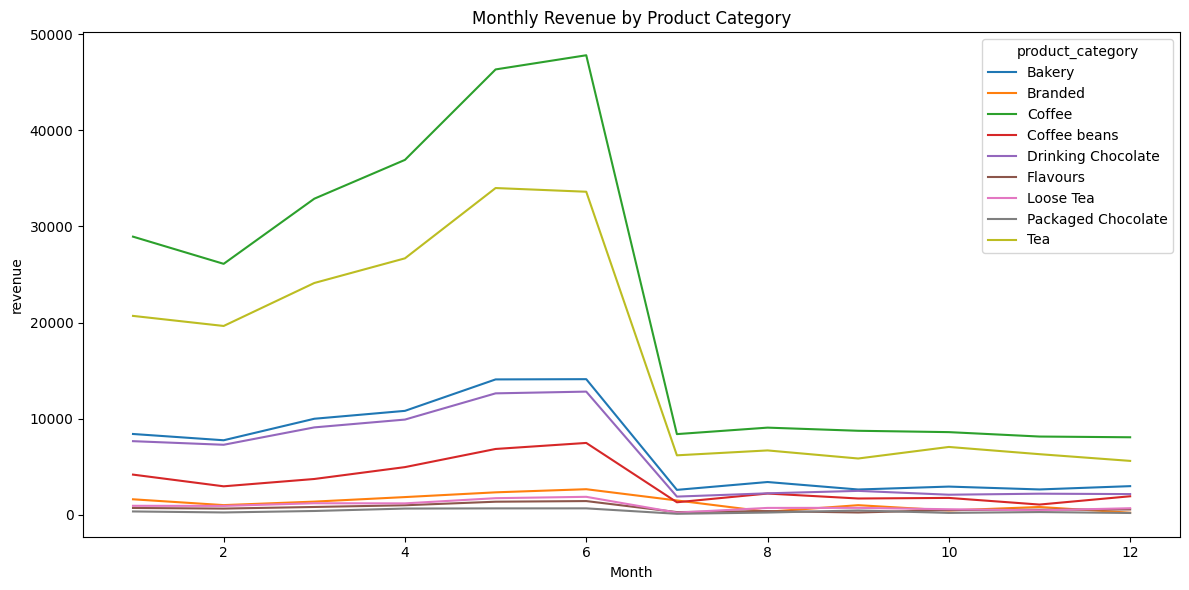

In [ ]:
# 7. Monthly Revenue by Product Category
monthly_cat = coffee_df.groupby(['Month', 'product_category'])['revenue'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_cat, x='Month', y='revenue', hue='product_category')
plt.title("Monthly Revenue by Product Category")
plt.tight_layout()
plt.show()

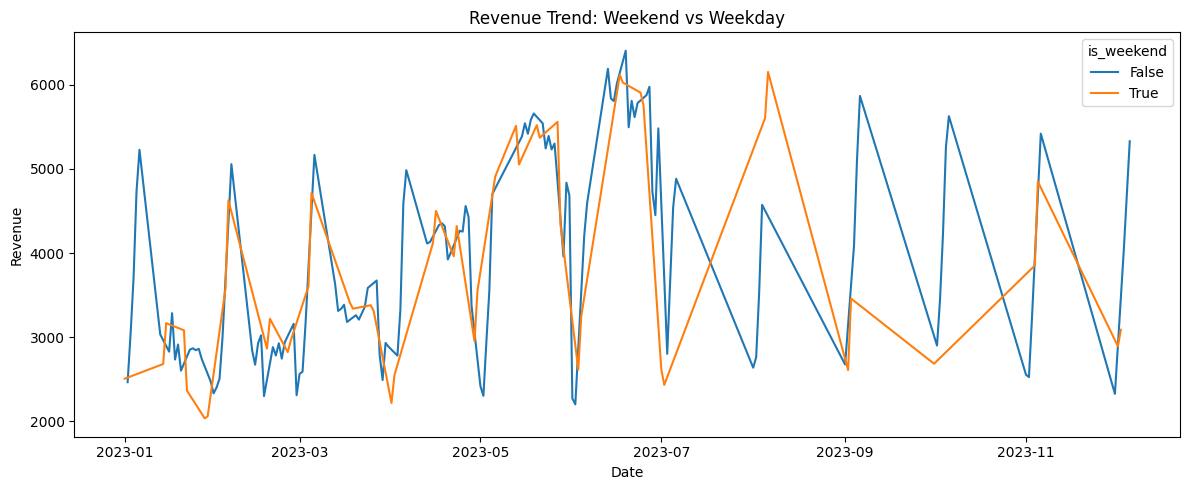

In [ ]:
# 8. Weekend vs Weekday Revenue (Grouped by Date)
daily_weekend = coffee_df.groupby(['Date', 'is_weekend'])['revenue'].sum().reset_index()
plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_weekend, x='Date', y='revenue', hue='is_weekend')
plt.title("Revenue Trend: Weekend vs Weekday")
plt.ylabel("Revenue")
plt.xlabel("Date")
plt.tight_layout()
plt.show()


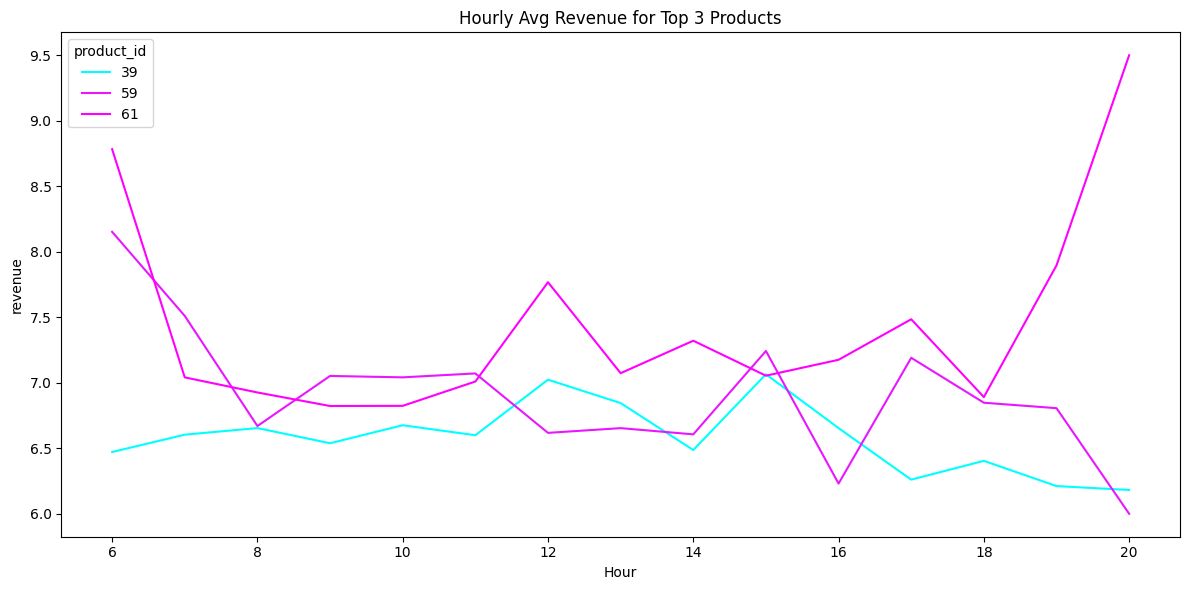

In [ ]:
# 9. Revenue by Hour for Top 3 Products
top_products = coffee_df.groupby('product_id')['revenue'].sum().nlargest(3).index
filtered = coffee_df[coffee_df['product_id'].isin(top_products)]
hourly_product = filtered.groupby(['Hour', 'product_id'])['revenue'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_product, x='Hour', y='revenue', hue='product_id', palette='cool')
plt.title("Hourly Avg Revenue for Top 3 Products")
plt.tight_layout()
plt.show()

Bar Graphs
1. Total Revenue per Product
2. Total Revenue by Product Category
3. Total Quantity Sold per Store
4. Total Revenue by Store Location
5. Average Revenue by Day of Week
6. Total Revenue per Hour (across all days)
7. Total Revenue by Month
8. Revenue: Top 10 Most Sold Product Details
9. Average Unit Price by Product Category

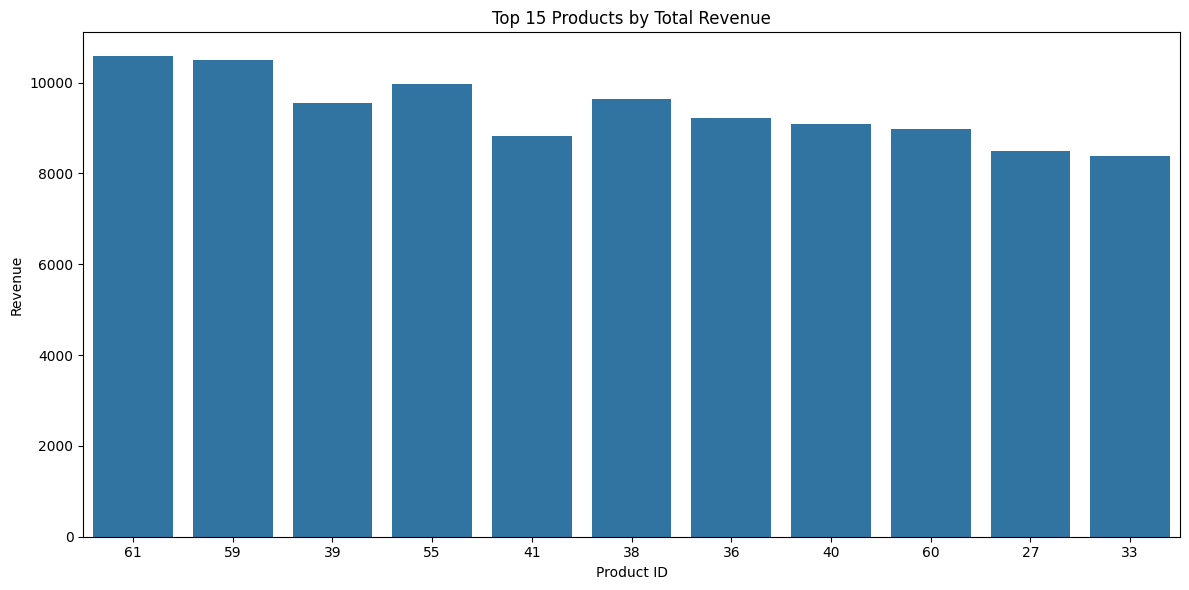

In [ ]:
# 1. Total Revenue per Product
prod_rev = coffee_df.groupby('product_id')['revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=prod_rev.index[:15], y=prod_rev.values[:15], errorbar=None)
plt.title('Top 15 Products by Total Revenue')
plt.xlabel('Product ID')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

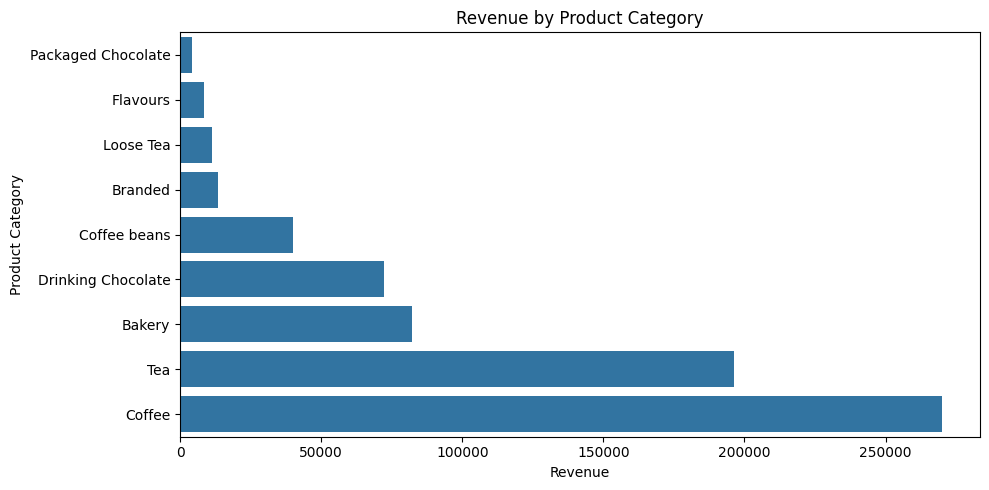

In [ ]:
# 2. Revenue by Product Category
cat_rev = coffee_df.groupby('product_category')['revenue'].sum().sort_values()
plt.figure(figsize=(10, 5))
sns.barplot(x=cat_rev.values, y=cat_rev.index)
plt.title('Revenue by Product Category')
plt.xlabel('Revenue')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

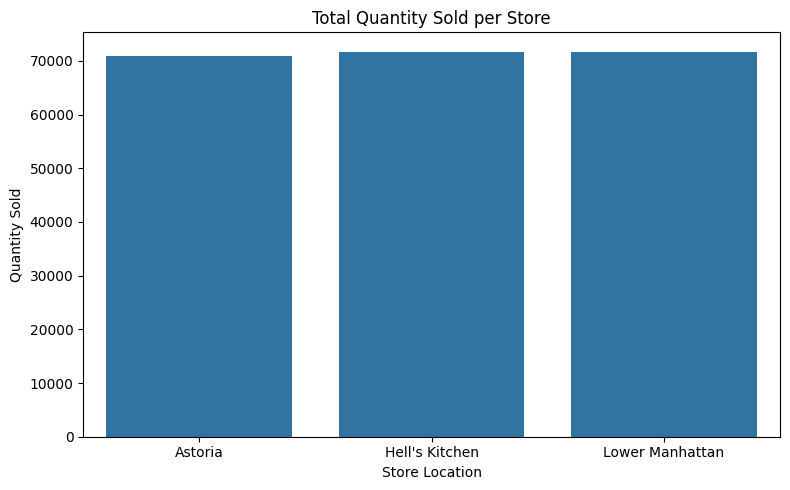

In [ ]:
# 3. Quantity Sold per Store
store_qty = coffee_df.groupby('store_location')['transaction_qty'].sum()
plt.figure(figsize=(8, 5))
sns.barplot(x=store_qty.index, y=store_qty.values)
plt.title('Total Quantity Sold per Store')
plt.xlabel('Store Location')
plt.ylabel('Quantity Sold')
plt.tight_layout()
plt.show()

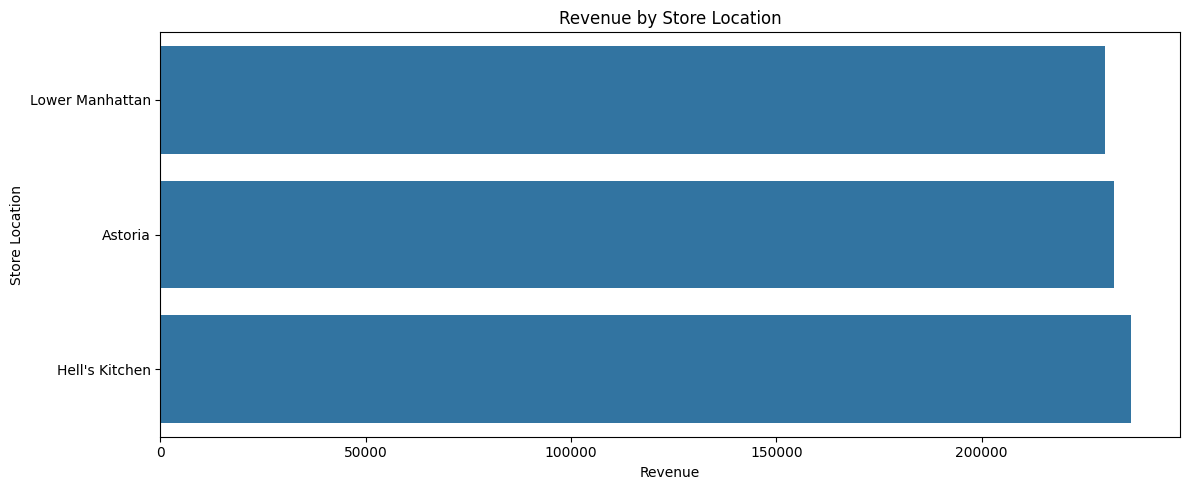

In [ ]:
# 4. Revenue by Store Location
store_loc_rev = coffee_df.groupby('store_location')['revenue'].sum().sort_values()
plt.figure(figsize=(12, 5))
sns.barplot(x=store_loc_rev.values, y=store_loc_rev.index)
plt.title('Revenue by Store Location')
plt.xlabel('Revenue')
plt.ylabel('Store Location')
plt.tight_layout()
plt.show()

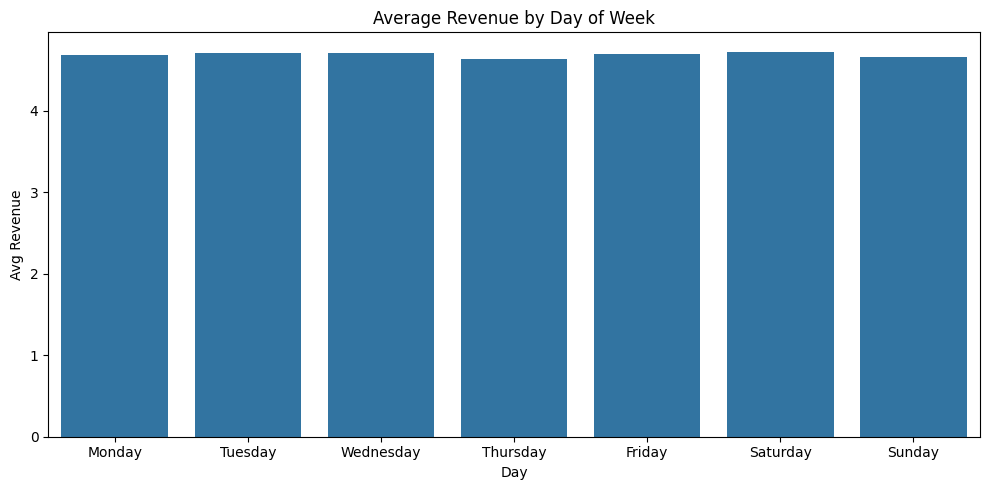

In [ ]:
# 5. Average Revenue by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_rev = coffee_df.groupby('Day_name')['revenue'].mean().reindex(day_order)
plt.figure(figsize=(10, 5))
sns.barplot(x=dow_rev.index, y=dow_rev.values)
plt.title('Average Revenue by Day of Week')
plt.ylabel('Avg Revenue')
plt.xlabel('Day')
plt.tight_layout()
plt.show()

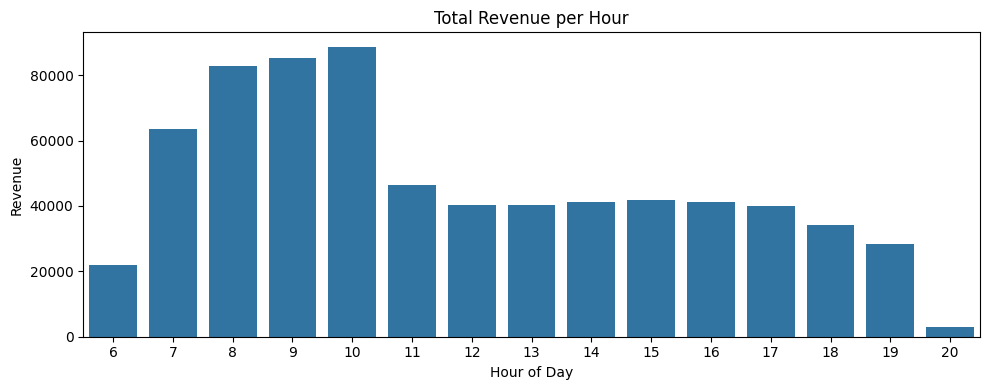

In [ ]:
# 6. Total Revenue per Hour
hour_rev = coffee_df.groupby('Hour')['revenue'].sum()
plt.figure(figsize=(10, 4))
sns.barplot(x=hour_rev.index, y=hour_rev.values)
plt.title('Total Revenue per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

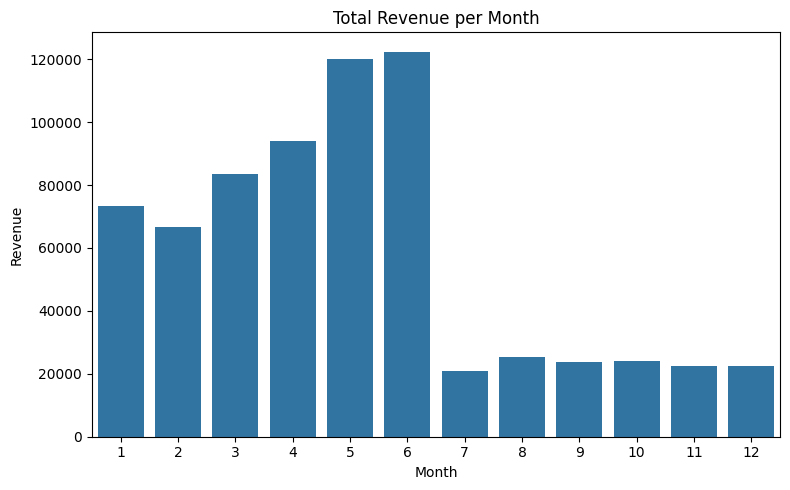

In [ ]:
# 7. Total Revenue per Month
month_rev = coffee_df.groupby('Month')['revenue'].sum()
plt.figure(figsize=(8, 5))
sns.barplot(x=month_rev.index, y=month_rev.values)
plt.title('Total Revenue per Month')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

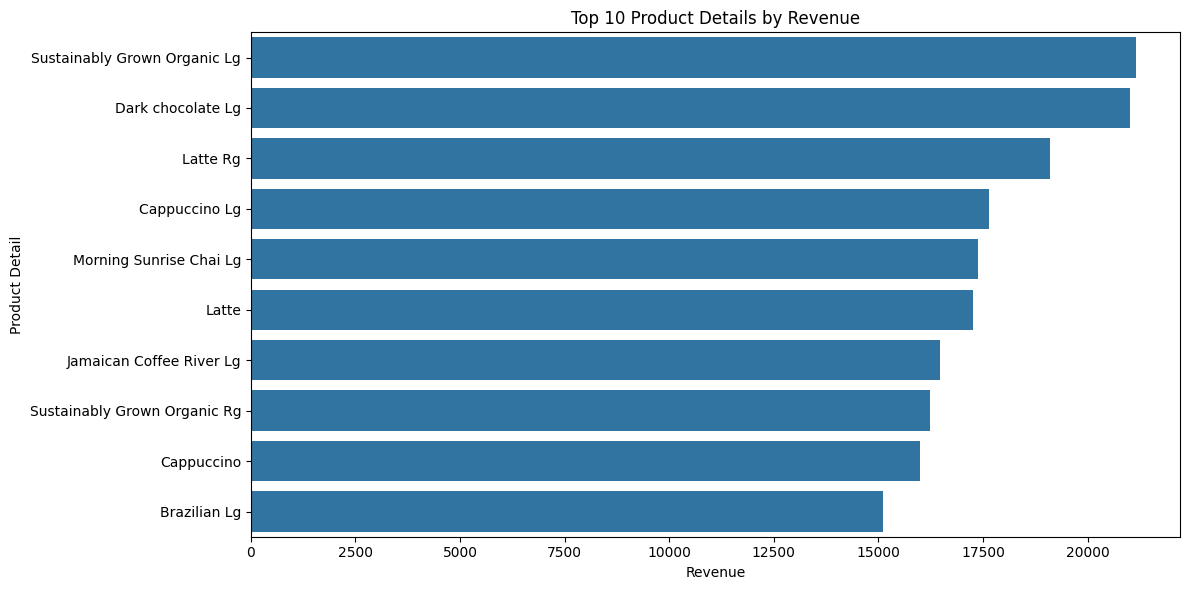

In [ ]:
# 8. Top 10 Product Details by Revenue
top_details = coffee_df.groupby('product_detail')['revenue'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(y=top_details.index, x=top_details.values)
plt.title('Top 10 Product Details by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product Detail')
plt.tight_layout()
plt.show()

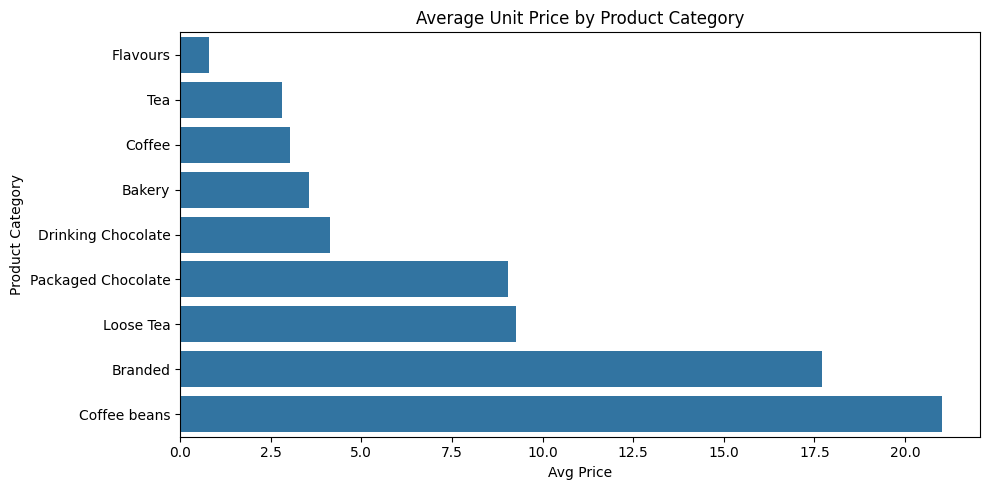

In [ ]:
# 9. Average Unit Price by Product Category
cat_price = coffee_df.groupby('product_category')['unit_price'].mean().sort_values()
plt.figure(figsize=(10, 5))
sns.barplot(x=cat_price.values, y=cat_price.index)
plt.title('Average Unit Price by Product Category')
plt.xlabel('Avg Price')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

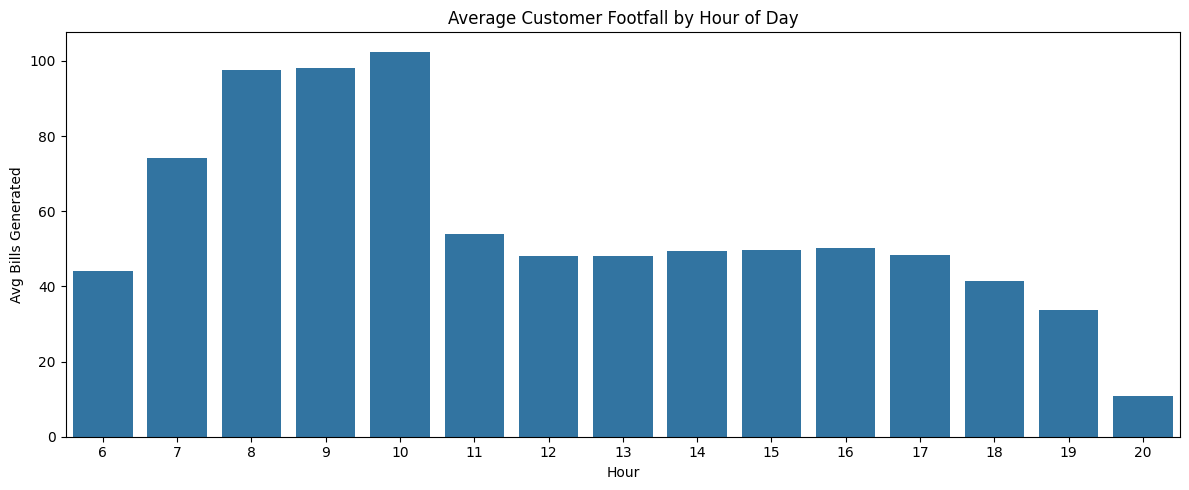

In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Average Footfall per Hour
# Count number of transactions per day per hour
hourly_counts = coffee_df.groupby([coffee_df.index.date, 'Hour'])['transaction_id'].count().reset_index()
hourly_counts.columns = ['Date', 'Hour', 'Bills']

# Now average footfall per hour across all days
avg_hourly_footfall = hourly_counts.groupby('Hour')['Bills'].mean()

# Plot
plt.figure(figsize=(12, 5))
sns.barplot(x=avg_hourly_footfall.index, y=avg_hourly_footfall.values)
plt.title("Average Customer Footfall by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Avg Bills Generated")
plt.tight_layout()
plt.show()

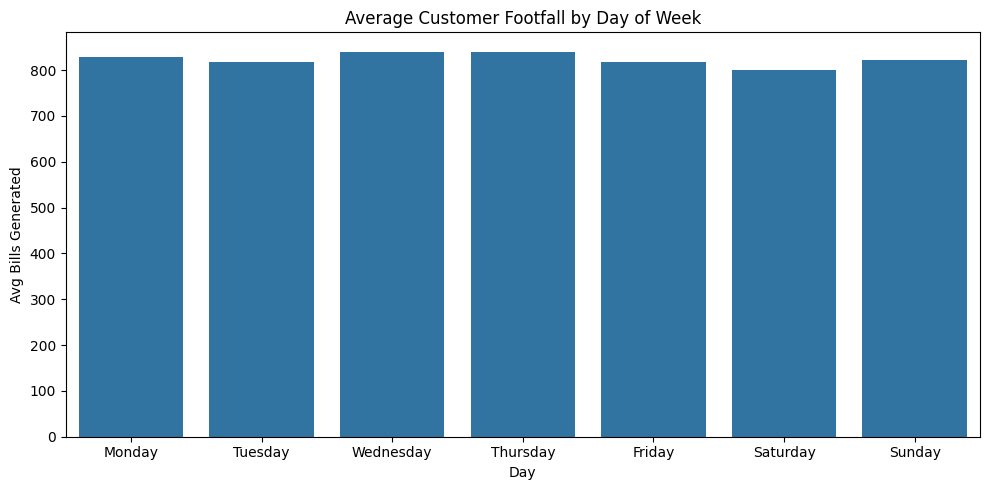

In [ ]:
# ✅ 2. Average Footfall per Day of the Week
# Add day name if not already
coffee_df['Day_name'] = coffee_df.index.day_name()

# Count number of transactions per date
daily_counts = coffee_df.groupby([coffee_df.index.date, 'Day_name'])['transaction_id'].count().reset_index()
daily_counts.columns = ['Date', 'Day_name', 'Bills']

# Now average per weekday
avg_daily_footfall = daily_counts.groupby('Day_name')['Bills'].mean().reindex(day_order)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_daily_footfall.index, y=avg_daily_footfall.values)
plt.title("Average Customer Footfall by Day of Week")
plt.xlabel("Day")
plt.ylabel("Avg Bills Generated")
plt.tight_layout()
plt.show()

# Pie Charts

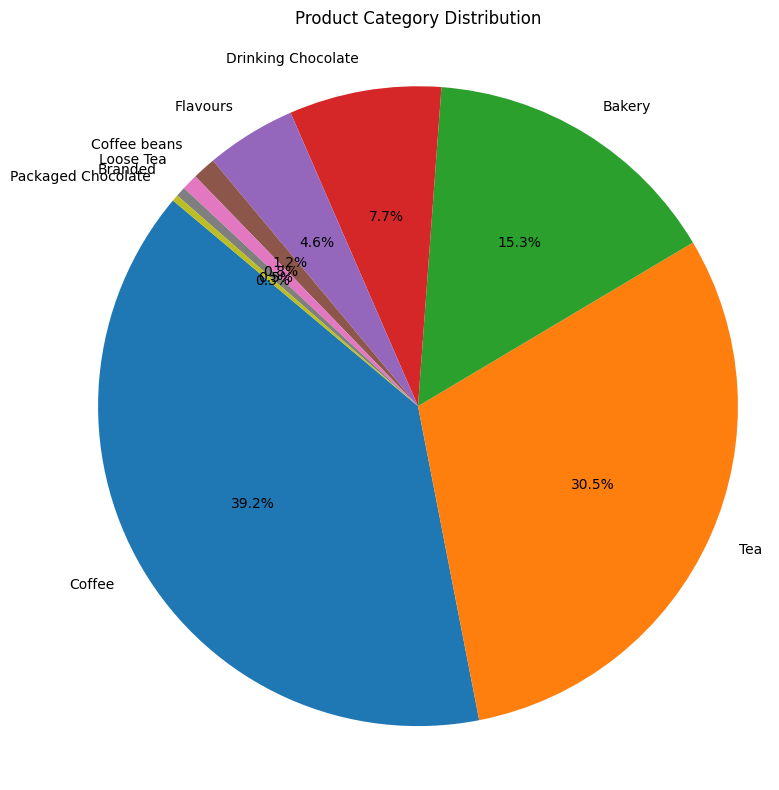

In [ ]:
category_counts = coffee_df['product_category'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140, )
plt.title('Product Category Distribution')
plt.axis('equal')
plt.tight_layout()
plt.show()

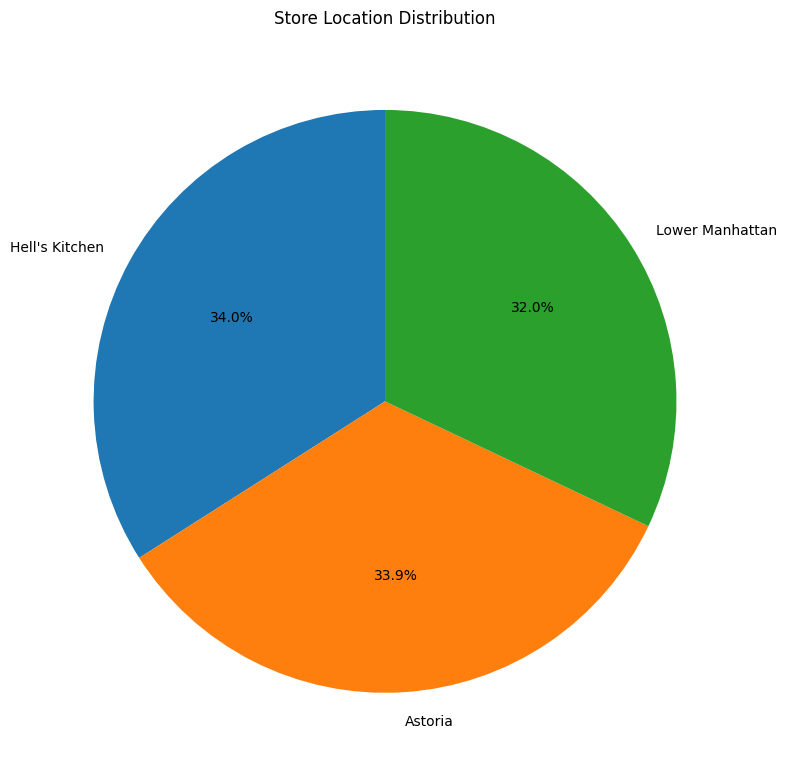

In [ ]:
store_counts = coffee_df['store_location'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(store_counts, labels=store_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Store Location Distribution')
plt.axis('equal')
plt.tight_layout()
plt.show()


# Bubble Charts

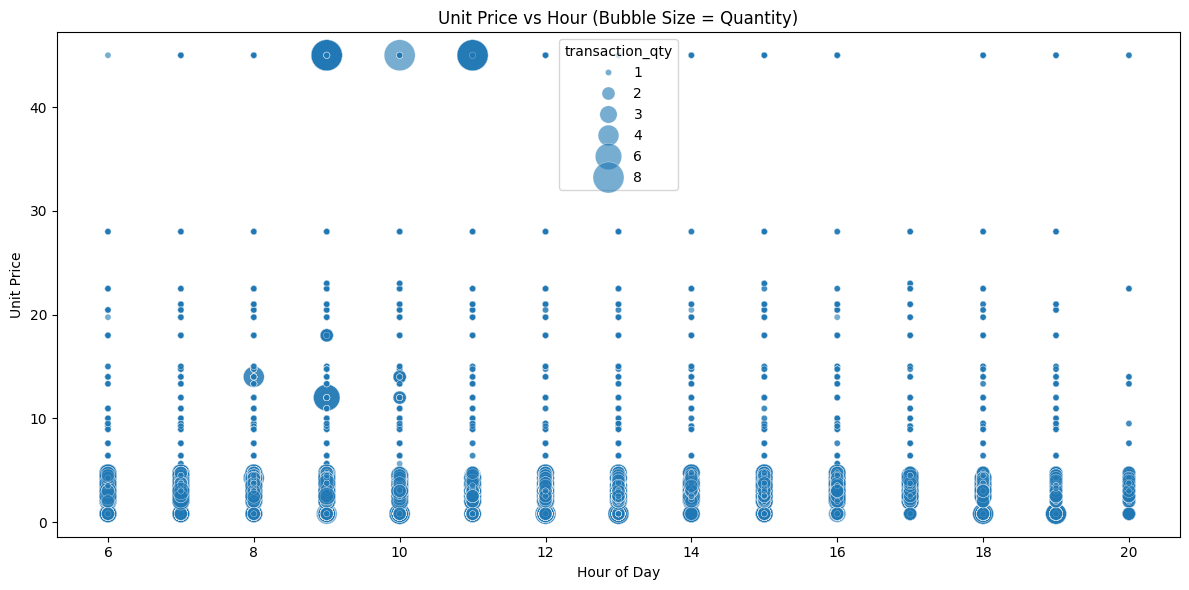

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=coffee_df, x='Hour', y='unit_price', size='transaction_qty', sizes=(20, 500), alpha=0.6)
plt.title('Unit Price vs Hour (Bubble Size = Quantity)')
plt.xlabel('Hour of Day')
plt.ylabel('Unit Price')
plt.tight_layout()
plt.show()


# Histograms

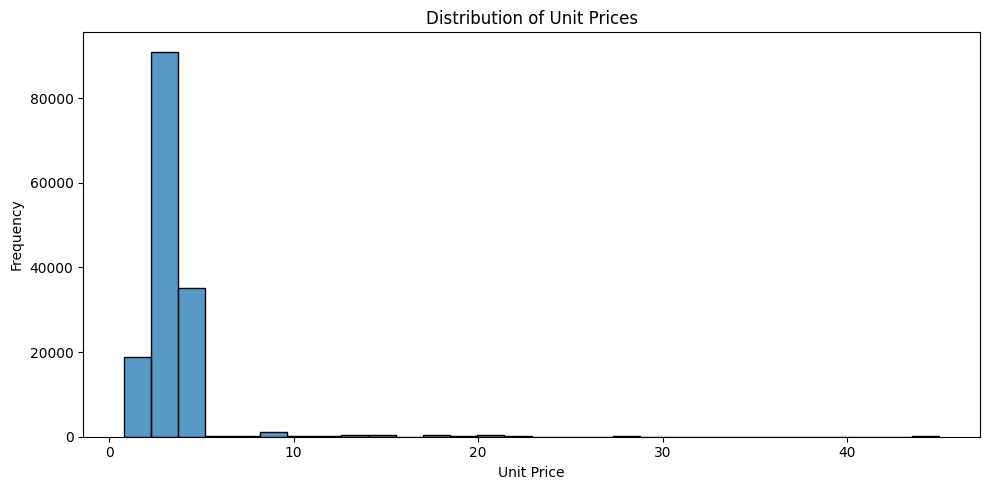

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(coffee_df['unit_price'], bins=30)
plt.title('Distribution of Unit Prices')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


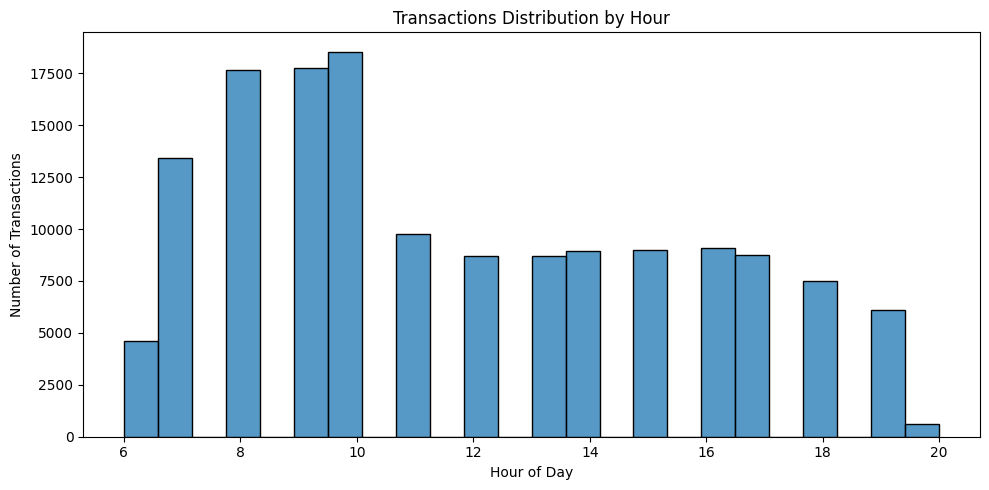

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(coffee_df['Hour'], bins=24)
plt.title('Transactions Distribution by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()


# KDE Plots

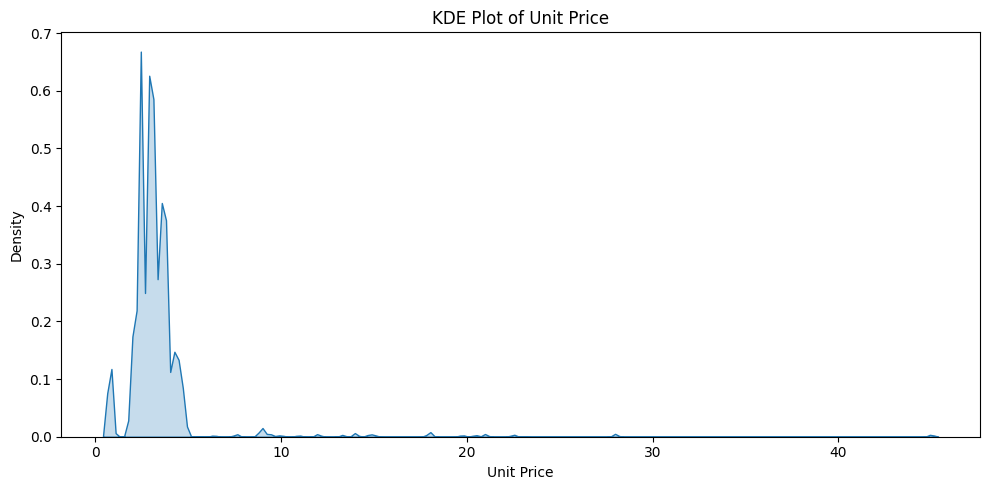

In [ ]:
plt.figure(figsize=(10, 5))
sns.kdeplot(coffee_df['unit_price'], fill=True, bw_adjust=0.5)
plt.title('KDE Plot of Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Density')
plt.tight_layout()
plt.show()


C:\Users\Siddhant\AppData\Local\Temp\ipykernel_26036\2191372712.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=coffee_df, x='unit_price', hue='product_category', fill=True, common_norm=False, alpha=0.3)


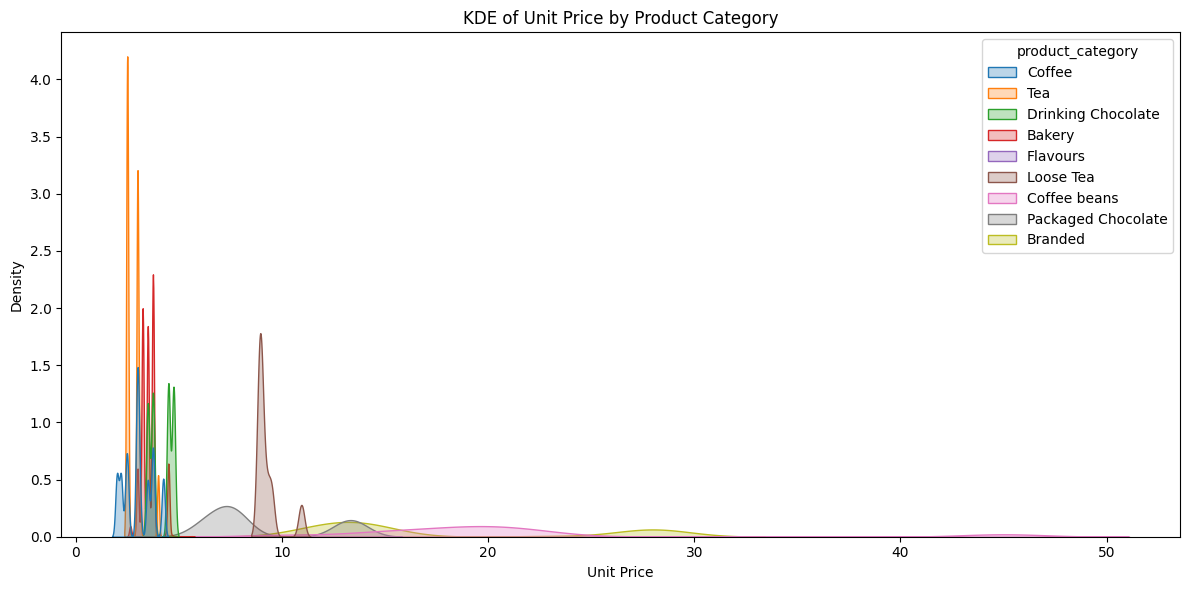

In [ ]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=coffee_df, x='unit_price', hue='product_category', fill=True, common_norm=False, alpha=0.3)
plt.title('KDE of Unit Price by Product Category')
plt.xlabel('Unit Price')
plt.ylabel('Density')
plt.tight_layout()
plt.show()


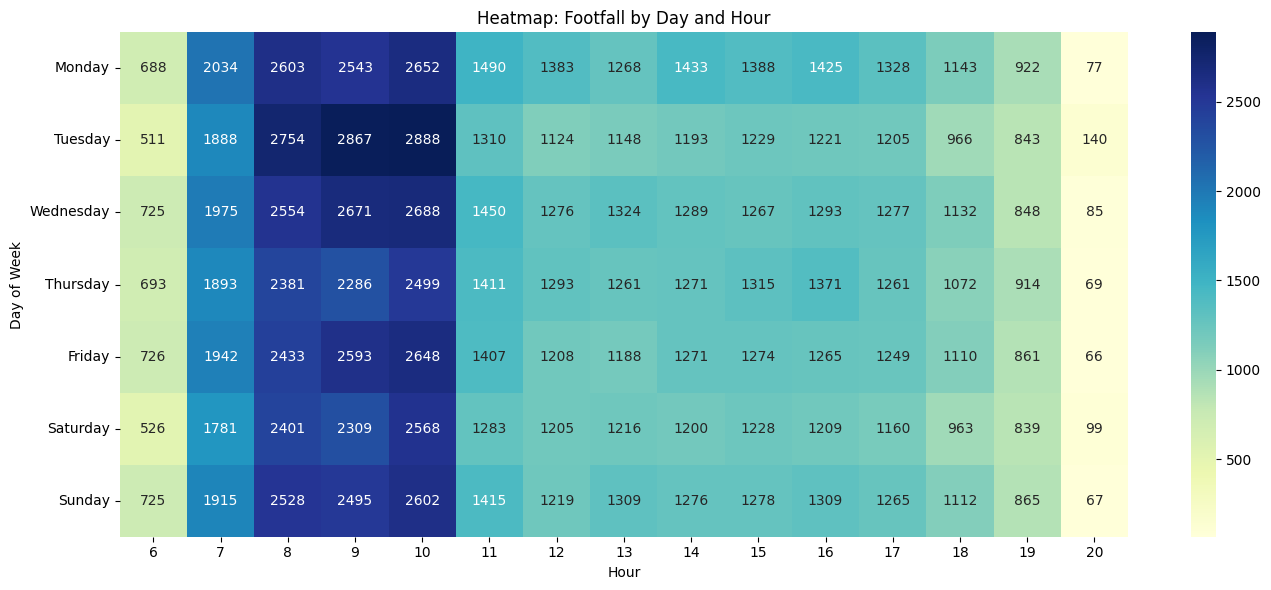

In [ ]:
# Create pivot for heatmap: average footfall by day & hour
footfall_pivot = coffee_df.groupby(['Day_name', 'Hour'])['transaction_id'].count().reset_index()
footfall_pivot = footfall_pivot.pivot(index='Day_name', columns='Hour', values='transaction_id')
footfall_pivot = footfall_pivot.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(14, 6))
sns.heatmap(footfall_pivot, cmap='YlGnBu', annot=True, fmt='.0f')
plt.title("Heatmap: Footfall by Day and Hour")
plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()


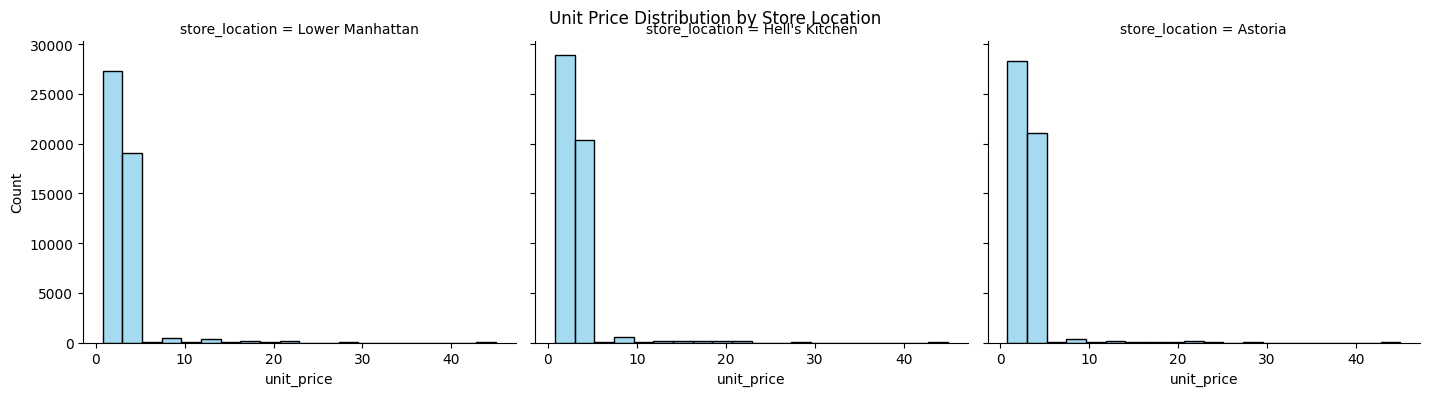

In [ ]:
g = sns.FacetGrid(coffee_df, col='store_location', col_wrap=3, height=4, aspect=1.2)
g.map_dataframe(sns.histplot, x='unit_price', bins=20, color='skyblue')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Unit Price Distribution by Store Location')
plt.show()


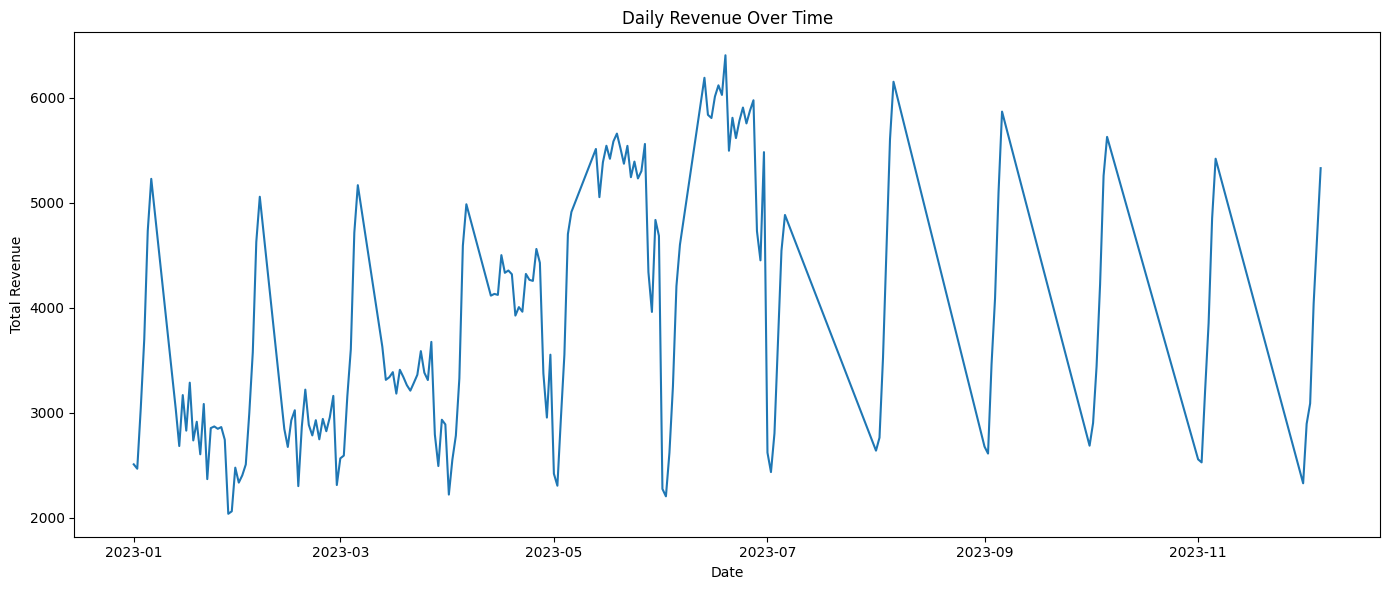

In [86]:
# Calculate total revenue per day
coffee_df['Revenue'] = coffee_df['transaction_qty'] * coffee_df['unit_price']
daily_revenue = coffee_df.groupby(coffee_df.index.date)['Revenue'].sum()

plt.figure(figsize=(14, 6))
daily_revenue.plot()
plt.title("Daily Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()


<Figure size 1400x600 with 0 Axes>

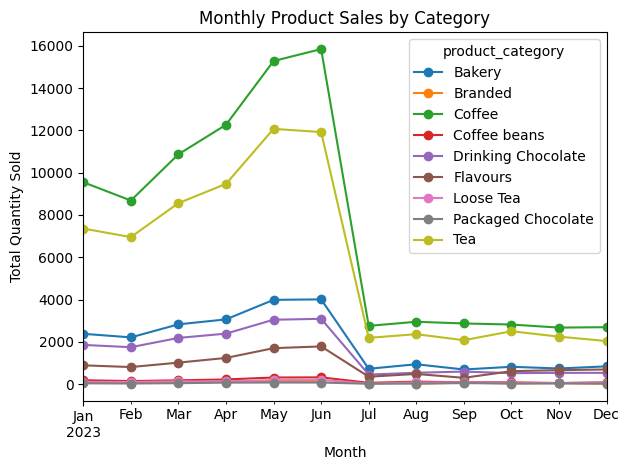

In [87]:
monthly_sales = coffee_df.groupby([coffee_df.index.to_period('M'), 'product_category'])['transaction_qty'].sum().unstack()

monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(14, 6))
monthly_sales.plot(marker='o')
plt.title("Monthly Product Sales by Category")
plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.tight_layout()
plt.show()
